# **Desenvolvido por: Leonardo Aquino**

# **1.  Pré-processamento de Dados**

## **Importando Bibliotecas e Carregando Dataset:**

Nesta etapa da pesquisa, utilizaram-se as seguintes bibliotecas Python para o processamento e organização dos dados brutos:


* **Pandas (`pandas`)**: Biblioteca fundamental para manipulação e análise de dados. Foi utilizada para carregar o dataset, realizar transformações, filtrar dados e criar novas colunas.

* **NumPy (`numpy`)**: Utilizada para operações numéricas eficientes, como cálculos matemáticos e manipulação de arrays. Foi empregada em operações estatísticas e para lidar com valores nulos ou inválidos.

* **Re (`re`)**: Biblioteca nativa para buscas, substituições e divisões de texto com expressões regulares básicas (como URLs, menções, hashtags e emojis).

* **Emoji (`emoji`)**: Biblioteca para manipulação de emojis em textos. Foi usada para remover emojis dos tweets e links, garantindo a padronização dos dados.

* **Hashlib (`hashlib`)**: Usada para gerar pseudônimos únicos por meio de funções de hash (SHA-256), garantindo a anonimização dos dados de usuários e tweets.

* **Regex (`regex`)**: Biblioteca compatível  com a sintaxe de `re`, mas traz recursos avançados: lookbehind de tamanho variável, propriedades Unicode completas (\p{Letter}), correspondência fuzzy, divisões condicionais e controle de backtracking. Útil quando padrões complexos ou suporte total a Unicode são necessários.

* **Difflib (`difflib`)**: Utilizada para comparar textos e encontrar similaridades, ajudando a identificar tweets truncados e seus originais.

* **Swifter (`swifter`)**: Biblioteca que acelera operações em `DataFrames` do Pandas, aplicando paralelismo. Foi usada para otimizar o processamento de funções em grandes volumes de dados.

* **Requests (`requests`)**: Utilizada para fazer requisições HTTP, principalmente na expansão de URLs encurtadas, seguindo redirecionamentos para obter os links originais.

* **Tqdm (`tqdm`)**: Adiciona barras de progresso para loops e operações demoradas, melhorando a visualização do andamento do processamento, como na expansão de URLs.

In [ ]:
!pip install emoji -q
!pip install swifter -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 14.9 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
^C


In [ ]:
import pandas                 as pd
import numpy                  as np
import re
import emoji
import hashlib
import regex as reg
from difflib import SequenceMatcher
import swifter
import requests
from requests.exceptions import RequestException
from tqdm import tqdm

In [ ]:
# Carreagando dataset
df = pd.read_csv(
    '/content/drive/MyDrive/TCC/Data/TUEBR22_bruto.csv',
     sep=",",
     low_memory=False)

## 1.1 *Limpeza e Padronização de Dados*

In [ ]:
df.info() # Vizualizando estrutura do dataset

In [ ]:
# Renomeando features
df = df.rename(columns={
    'tweet': 'raw_tweet',
    'created_at': 'tweet_created_at',
    'in_reply_to_status_id': 'reply_to_tweet_id',
    'in_reply_to_user_id': 'reply_to_user_id',
    'created_at.1': 'user_created_at',
    'screen_name': 'username',
    'dt_coleta': 'collection_date',
    'retweet_count': 'retweets',
    'favorite_count': 'likes',
    'verified': 'is_verified'
})

In [ ]:
df.columns.tolist() # Validando alteração

In [ ]:
# Vericando metadados
df[[
    'location',
    'geo',
    'coordinates',
    'place',
    'lang'
  ]].sample(10)

In [ ]:
"""Removendo metadados com muitos valores nulos
   ou com dados irrelevantes para a pesquisa
"""
cols_remover = [
    'location',
    'geo',
    'coordinates',
    'place',
    'lang'
]
df.drop(columns=cols_remover, inplace=True)

In [ ]:
# Convertendo para o formato Datatime
df['tweet_created_at'] = pd.to_datetime(df['tweet_created_at'])
df['user_created_at'] = pd.to_datetime(df['user_created_at'])
df['collection_date'] = pd.to_datetime(df['collection_date'])

In [ ]:
# Tweets sem data de criação
df[df['tweet_created_at'].isna()]['tweet_created_at']

In [ ]:
# Removendo tweets sem data de criação
df.drop(df[df['tweet_created_at'].isna()].index, inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
# Convertendo para o formato int
df['retweets'] = pd.to_numeric(df['retweets'], errors='coerce').astype('Int64')

In [ ]:
# Filtrando linhas onde a coluna 'raw_tweet' está vazia (string vazia ou NaN)
tweets_vazios = df.loc[
    (df['raw_tweet'].isna()) |  # Verifica valores NaN
    (df['raw_tweet'].str.strip() == '') # Verifica strings vazias ou com espaços
]

# Quantitativo de tweets vazios
len(tweets_vazios)

In [ ]:
"""
Verificando dados dos tweets vazios (ao analisar os links, observa-se que eles
diricionam para notícias relacioandas a urna, sendo assim a falta do conteúdo
do tweet deve ser por conta de falha na escrita)
"""
tweets_vazios['raw_tweet'].sample(10)

In [ ]:
# Excluindo tweets vazios
condicao_vazios = df['raw_tweet'].isna() | (df['raw_tweet'].str.strip() == '')
df.drop(df[condicao_vazios].index, inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
# Excluindo tweets muito curtos e sem link
df = df[~((df['link'].isna()) & (df['raw_tweet'].str.len() < 10))]
df = df.reset_index(drop=True)

In [ ]:
# Contar duplicatas na coluna tweet_id (chave única)
df.duplicated(subset=['tweet_id'], keep=False).sum()

In [ ]:
# Filtrar linhas duplicadas e ordenar (Erro na escrita, trucando o ID do tweet)
duplicates_df = df[df.duplicated(subset=['tweet_id'], keep=False)]\
                .sort_values(by='tweet_id', ascending=False)

# Mostrar colunas relevantes
duplicates_df[['tweet_id','collection_date']]

In [ ]:
# Excluindo tweets duplicados
df.drop_duplicates(subset='tweet_id', inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
# Contagem de contas verificadas ou não
df['is_verified'].value_counts()

In [ ]:
# Converte True/False para 1/0
df['is_verified'] = df['is_verified'].astype(int)

In [ ]:
# Validando alteração
df['is_verified'].value_counts()

In [ ]:
# Tweets sem nome do usuário, serão mantidos visto que não serão ultizados
df[df['name'].isna()]['name']

In [ ]:
# Define a máscara para identificar valores a substituir
mask = df['link'].str.len().fillna(0) < 23
# Substitui por NaN onde a máscara é True
df.loc[mask, 'link'] = np.nan

In [ ]:
# Filtra URLs com reticência ou pontos finais (concatenado)
df[df['link'].str.contains('…|\.{3}', na=False)][['link']]

In [ ]:
# URL truncada que não esta encurtada
df.iloc[92414]['link']

In [ ]:
# Substitui por NaN
df.loc[92414, 'link'] = np.nan
df.iloc[92414]['link']

In [ ]:
# Função que aplica a lógica de limpeza e validação
def limpar_validar_url(url):
    if not isinstance(url, str):
        return None  # ignora valores nulos ou não string

    # Remove reticência e pontos finais
    if url.endswith('…'):
        url = url[:-1]
    elif url.endswith('...'):
        url = url[:-3]

    clean_ = url

    # Verifica comprimento e regex
    if len(clean_) >= 23 and re.match(r'^https?://[^\s]+\.[^\s]+$', clean_):
       return clean_
    else:
        return None  # URL inválida

# Aplica à coluna 'link'
df['link'] = df['link'].apply(limpar_validar_url)

In [ ]:
# Verificando alteração
df[df['link'].str.contains('…|\.{3}', na=False)][['link']]

In [ ]:
# Removendo emojis que foram coletados por engano junto ao link
# Observado apenas um caso: 258
df['link'] = df['link'].apply(
    lambda x: emoji.replace_emoji(x, '') if pd.notnull(x) else x
)

In [ ]:
# Links com ruídos
df[df['link'].str.contains(r'[.,)\]\}]$', na=False)]['link']

In [ ]:
# Removendo ruídos (., ), ,, ]) no final dos link
# Observado em alguns caso: 1822, 2637, 24626...
df['link'] = df['link'].str.extract(r'(https://t\.co/[a-zA-Z0-9]+)')

In [ ]:
# Substitui strings vazias ou espaços por NaN
# Observado em apenas um caso: 19695
df['link'] = df['link'].replace(r'^\s*$', np.nan, regex=True)

In [ ]:
df[df['link'].isna()]['link'].sample(10) # Verificando

In [ ]:
df.info() # Validando alterações

## *1.2 Pseudonimização*

In [ ]:
# ===== Configurações =====
SALT = "34864561"

# ===== Dicionários de Mapeamento =====
user_mapping = {}           # {(user_id, username): (pseudo_id, name)}
username_to_user_id = {}    # Mapeamento reverso {username: user_id}
tweet_mapping = {}          # {tweet_id: pseudo_id}
external_ids = set()        # {(tipo, id_original)}

# ===== Funções Base =====
def generate_pseudo_id(original_id, prefix=""):
    return f"{prefix}_" + hashlib.sha256((str(original_id) + SALT).encode()
                                        ).hexdigest()[:12].upper()

# ===== Pseudonimização de Usuários =====
def pseudonymize_user(row):
    # Processa cada usuário do DataFrame e atualiza mapeamentos
    user_id = row["user_id"]
    username = row["username"].strip('@').lower() # Remove @ existente
    name = row["name"]

    # Atualiza mapeamento reverso
    if username not in username_to_user_id:
        username_to_user_id[username] = user_id

    # Cria entrada no mapeamento principal
    user_key = (user_id, username)
    if user_key not in user_mapping:
        pseudo = generate_pseudo_id(user_id, prefix="@USER")
        user_mapping[user_key] = (pseudo, name)

    return user_mapping[user_key][0]

# ===== Pseudonimização de Tweets =====
def pseudonymize_tweet(tweet_id):
    # Gera ID pseudônimo para tweets
    if pd.isna(tweet_id) or tweet_id == "":
        return np.nan
    if tweet_id not in tweet_mapping:
        tweet_mapping[tweet_id] = generate_pseudo_id(tweet_id, prefix="TWEET")
    return tweet_mapping[tweet_id]

def pseudonymize_mentions(text):
    # Substitui menções @username por pseudônimos mantendo um único @
    if pd.isna(text):
        return text

    # Extrai menção
    mentions = re.findall(r'(?<!\w)@\w{1,25}(?!\w)', text)

    for username in mentions:
        clean_username = username.strip('@').lower()
        # Usuários do dataset
        if clean_username in username_to_user_id:
            user_id = username_to_user_id[clean_username]
            pseudo = user_mapping[(user_id, clean_username)][0]
        # Usuários externos
        else:
            user_key = (None, clean_username)
            if user_key not in user_mapping:
                pseudo_ext = generate_pseudo_id(clean_username,
                                                prefix="@EXT_USER")
                user_mapping[user_key] = (pseudo_ext, None)
                external_ids.add(("user", clean_username))
            pseudo = user_mapping[user_key][0]

        # Substitui a menção completa (@username)
        pattern = rf'(?<!\w)@{re.escape(clean_username)}(?![\w_])'
        text, count = re.subn(pattern, pseudo, text, flags=re.IGNORECASE)

    return text

# ===== Processamento Principal =====

#  Pseudonimiza usuários principais
df["user_pseudo"] = df.apply(pseudonymize_user, axis=1)

#  Pseudonimiza tweets
df["tweet_id_pseudo"] = df["tweet_id"].apply(pseudonymize_tweet)

#  Processa texto dos tweets
df["tweet_pseudo"] = df["raw_tweet"].apply(pseudonymize_mentions)

#  Pseudonimiza replies
def process_reply_user(id_):
    if pd.isna(id_) or id_ == "":
        return np.nan
    if id_ in df["user_id"].values:
        return generate_pseudo_id(id_, prefix="@USER")
    else:
        external_ids.add(("reply_user", id_))
        return generate_pseudo_id(id_, prefix="@EXT_USER")

df["reply_to_user_pseudo"] = df["reply_to_user_id"].apply(process_reply_user)

def process_reply_tweet(id_):
    if pd.isna(id_) or id_ == "":
        return np.nan
    if id_ in tweet_mapping:
        return tweet_mapping[id_]
    else:
        external_ids.add(("reply_tweet", id_))
        return generate_pseudo_id(id_, prefix="EXT_TWEET")

df["reply_to_tweet_pseudo"] = df["reply_to_tweet_id"].apply(process_reply_tweet)

# ===== Exportação de Mapeamentos =====
# Mapeamento de usuários (incluindo externos)
users_data = []
for (user_id, username), (pseudo, name) in user_mapping.items():
    users_data.append({
        "user_id_original": user_id if user_id is not None else np.nan,
        "username_original": f"@{username}",
        "user_pseudo": pseudo,
        "name_original": name if name is not None else np.nan
    })
pd.DataFrame(users_data
).to_csv("/content/drive/MyDrive/TCC/Data/mapeamento_usuarios.csv", index=False)

# Mapeamento de tweets
pd.DataFrame(
    list(tweet_mapping.items()),
    columns=["tweet_id_original", "tweet_id_pseudo"]
).to_csv("/content/drive/MyDrive/TCC/Data/mapeamento_tweets.csv", index=False)

# IDs externos
if external_ids:
    pd.DataFrame(
        list(external_ids),
        columns=["tipo", "id_original"]
).to_csv("/content/drive/MyDrive/TCC/Data/ids_externos.csv", index=False)

**Validando Pseudonimização:**

In [ ]:
# Carregar os arquivos gerados
df_original = df.copy()  # Substitua pelo seu arquivo
df_map_users = pd.read_csv(
                      "/content/drive/MyDrive/TCC/Data/mapeamento_usuarios.csv")
df_map_tweets = pd.read_csv(
                      "/content/drive/MyDrive/TCC/Data/mapeamento_tweets.csv")

# ===== Validação de Usuários =====
print("\n=== Validação de Usuários ===")

# Contagem de usuários originais vs pseudônimos
original_users_count = df_original["user_id"].nunique()
pseudo_users_count = df_map_users["user_pseudo"].nunique()

print(f"Usuários originais únicos: {original_users_count}")
print(f"Pseudônimos de usuários únicos: {pseudo_users_count}")


# ===== Validação de Tweets =====
print("\n=== Validação de Tweets ===")

# Contagem de tweets originais vs pseudônimos
original_tweets_count = df_original["tweet_id"].nunique()
pseudo_tweets_count = df_map_tweets["tweet_id_pseudo"].nunique()

print(f"Tweets originais únicos: {original_tweets_count}")
print(f"Pseudônimos de tweets únicos: {pseudo_tweets_count}")


# ===== Validação de Menções e Replies =====
print("\n=== Validação de Menções/Replies ===")

# Menções externas nos textos
external_mentions_in_tweets = df_map_users[
    (df_map_users["user_pseudo"].str.contains("@EXT_USER")) &
    (df_map_users["user_id_original"].isnull())
]["username_original"].nunique()

print(f"Menções a usuários externos em textos: {external_mentions_in_tweets}")

#  Replies externos
try:
    df_ext = pd.read_csv("/content/drive/MyDrive/TCC/Data/ids_externos.csv")

    ext_user= df_ext[df_ext["tipo"] == "reply_user"]["id_original"].nunique()
    ext_tweets= df_ext[df_ext["tipo"] == "reply_tweet"]["id_original"].nunique()
    print(f"Replies para usuários externos: {ext_user}")
    print(f"Replies para tweets externos: {ext_tweets}")
except FileNotFoundError:
    print("Nenhum reply externo encontrado.")

# ===== Verificação de Duplicidades =====
print("\n=== Verificação de Duplicidades ===")

# Pseudônimos duplicados (deveria ser zero)
duplicate_pseudo_users = df_map_users["user_pseudo"].duplicated().sum()
print(f"Pseudônimos de usuários duplicados: {duplicate_pseudo_users}")

duplicate_pseudo_tweets = df_map_tweets["tweet_id_pseudo"].duplicated().sum()
print(f"Pseudônimos de tweets duplicados: {duplicate_pseudo_tweets}")

**Verificando usuários duplicados:**

In [ ]:
# Filtra e ordena as linhas com user_pseudo duplicado
dupl_order = df_map_users[
                       df_map_users["user_pseudo"].duplicated(keep=False)
                       ].sort_values(by="user_pseudo")

# Calcula o tamanho de cada grupo e reseta o índice
group = dupl_order.groupby('user_id_original').size().reset_index(name='size')

# Mescla os tamanhos dos grupos de volta ao DataFrame original
duplicados_ordenados = pd.merge(
                                 dupl_order,
                                 group, on='user_id_original', how='left')

# Filtra com base na coluna 'size'
result = duplicados_ordenados[duplicados_ordenados['size'] > 1]

result[['user_pseudo', 'size']].sample(10)

In [ ]:
# Veriifcando tweets usuários duplicados
USER = '@USER_FFC29CEF459C'
df[df['user_pseudo'].str.contains(USER)][
  ['user_pseudo','tweet_id_pseudo','tweet_created_at']]

**NOTA: Identificou-se que a causa das duplicidades foi a alteração do *username* durante o período de coleta de dados.**

**Validando Pseudonimização:**

In [ ]:
# Amostragem de validação
df[['tweet_id_pseudo','tweet_pseudo']].sample(10)

In [ ]:
# Selecionado usuário
USER = '@USER_45D2CEC77707'

In [ ]:
# Validando no dataset de mapeamento de usuários
df_map_users[df_map_users['user_pseudo'].str.contains(USER)]

In [ ]:
# Validando no dataset original, se está sendo mencionado
df[df['tweet_pseudo'].str.contains(USER)][['tweet_pseudo']].sample(10)

In [ ]:
# Validando no dataset original, se é uma respota a este usuário
df[df['reply_to_user_pseudo'].str.contains(USER, na=False)][['user_pseudo','reply_to_user_pseudo','reply_to_tweet_pseudo']].sample(10)

In [ ]:
# Validando no dataset original, se é o autor do tweet
df[df['user_pseudo'].str.contains(USER)][['user_pseudo','tweet_pseudo']]

In [ ]:
# Selecionado tweet
TWEET = 'TWEET_500CBAA5C279'
# Validando no dataset de mapeamento de tweets
df_map_tweets[df_map_tweets['tweet_id_pseudo'].str.contains(TWEET)]

In [ ]:
# Validando no dataset original, se é uma respota a este tweet
df[df['reply_to_tweet_pseudo'].str.contains(TWEET, na=False)][['tweet_id_pseudo','reply_to_tweet_pseudo']]

In [ ]:
df.info()

In [ ]:
# Calculando o tamanho do tweet bruto não pseudonimizado
df['raw_tweet_length'] = df['raw_tweet'].str.len()

In [ ]:
# ===== Remoção das colunas originais e renomeação =====
# Lista de colunas originais para remover
colunas_para_remover = [
    "user_id", "username", "name",
    "tweet_id", "raw_tweet",
    "reply_to_user_id", "reply_to_tweet_id"
]

# Remove colunas originais (ignora caso não existam)
df = df.drop(columns=colunas_para_remover, errors="ignore")

# Mapeamento de renomeação das colunas pseudonimizadas
mapeamento_renomeacao = {

    "user_pseudo": "user_id",
    "tweet_id_pseudo": "tweet_id",
    "tweet_pseudo": "raw_tweet",
    "reply_to_user_pseudo": "reply_to_user_id",
    "reply_to_tweet_pseudo": "reply_to_tweet_id"
}

# Renomeia colunas pseudonimizadas para os nomes originais
df = df.rename(columns=mapeamento_renomeacao)

# Definir a ordem das colunas
desired_order = [
    'tweet_id', 'raw_tweet','raw_tweet_length', 'link', 'tweet_created_at',
    'reply_to_tweet_id', 'reply_to_user_id', 'retweets', 'likes',
    'user_id', 'followers_count',
    'user_created_at', 'is_verified', 'collection_date'
]

# Reordenar o DataFrame
df = df[desired_order]

In [ ]:
df.info()

## *1.3 Processamento de Texto dos Tweets*

### 1.3.1 Engenharia de Features Baseadas em Texto (Tweet)

In [ ]:
#Extraíndo features dentro do texto do tweet
def extract_elements(text):

    # Extrai URLs que começam com http/https
    raw_urls = re.findall(r'http[s]?://\S+', text)

    # Filtra: sem '…' ou '...', com domínio válido, e com pelo menos um ponto
    urls = []
    for url in raw_urls:
      # Remove '…' e '...' do final da URL
      clean = url.rstrip('…').rstrip('.')
      if len(clean) >= 23 and re.match(r'^https?://[^\s]+\.[^\s]+$', clean):
        urls.append(clean)

    # Extrai hashtags válidas (não permite @ ou letras antes do #)
    raw_hashtags = reg.findall(r'(?<![@\w])#[\w\p{Emoji}]+', text)

    # Remove pontuação final
    clean_hashtags = [tag.rstrip('.!?,…') for tag in raw_hashtags]

    # Filtra hashtags com pelo menos 1 caractere após #
    hashtags = [tag for tag in clean_hashtags if len(tag) > 1]

    # Extai emojis
    # Regex para capturar sequências de emojis numéricos com keycap(1️⃣,3️⃣,etc.)
    pattern = re.compile(r'(?:[0-9]️⃣)+')
    matches = pattern.findall(text)

    # Remove as sequências para não duplicar quando extrair os demais emojis
    cleaned = pattern.sub('', text)

    # Pega os demais emojis normalmente
    other_emojis = [e['emoji'] for e in emoji.emoji_list(cleaned)]

    # emojis = [c for c in text if c in emoji.EMOJI_DATA]
    emojis = matches + other_emojis

    # Extrai menções
    mentions = re.findall(r'(?<!\w)@\w{1,25}(?!\w)', text)

    # Classifica se é um retweet ou não
    is_retweet = 1 if text.startswith('RT @') else 0

    # Extrai autor original, caso seja um retweet
    original_author = re.findall(r'^RT (@[^\s:]+):?', text)

    # Remove original_user de mentions se for um retweet
    if is_retweet and original_author:
        original_username = original_author[0]
        mentions = [user for user in mentions if user != original_username]

    # Verificar se a tweet possuim um tom de alarmismo
    words = text.split()
    valid_w = [w for w in words if w not in ["RT"]]
    upper_ratio = sum(1 for w in valid_w if w.isupper()) / max(1, len(valid_w))
    # Caso mais de 50% do texto for composto por letras maiúsculas
    # Retorna 1 (verdadeiro), e 0 (falso) caso contrário
    is_upper =  int(upper_ratio > 0.5)

    return {
        'mentions': mentions,
        'urls': urls,
        'emojis': emojis,
        'hashtags': hashtags,
        'is_retweet': is_retweet,
        'original_author': original_author,
        "is_upper": is_upper
    }

# Aplicando extração
df_elements = df['raw_tweet'].apply(lambda x: pd.Series(extract_elements(x)))
df = pd.concat([df, df_elements], axis=1)

# Converter original_user de uma lista para um valor único ou None
df['original_author'] = df['original_author'].apply(
    lambda x: x[0] if len(x) > 0 else None
)

In [ ]:
# Amostragem de dados extraíndos
df[['urls','emojis','hashtags','is_retweet','is_upper']
  ].sample(10)

In [ ]:
# Validando linhas onde pelo menos uma URL ainda contém '…' ou '...'
df[df['urls'].apply(
    lambda lista: any(('…' in url or '...' in url) for url in lista)
)][['urls']]

In [ ]:
# Adicionar link capturado na coleta aos demais
df['urls'] = [
    ([link] if isinstance(link, str) and link else []) + urls_list
    for link, urls_list in zip(df['link'], df['urls'])
]
df[['link','urls']].sample(10)

In [ ]:
# Validando junção do link capturado na coleta aos demais
df [[
    (link not in urls) if pd.notna(link) else False
    for link, urls in zip(df['link'], df['urls'])
]][['link','urls']]

In [ ]:
# Removendo coluna link
df.drop('link', axis=1, inplace=True)

**Calculando métricas relacionadas às features extraídas:**

In [ ]:
# Quantidade de URls
df['url_count'] = df['urls'].apply(len)

In [ ]:
# Quantidade de hashtags
df['hashtags_count'] = df['hashtags'].apply(lambda x: len(eval(x)) if isinstance(x, str) and x != '[]' else (len(x) if isinstance(x, list) else 0))

In [ ]:
# Quantidade de menções
df['mentions_count'] = df['mentions'].apply(lambda x: len(eval(x)) if isinstance(x, str) and x != '[]' else (len(x) if isinstance(x, list) else 0))

In [ ]:
# Quantidade de emojis
df['emoji_count'] = df['emojis'].apply(len)

### 1.3.2 Validação de Conteúdo dos Tweets

#### 1.3.2.1 Identificando Tweets Possivelmente Truncados

In [ ]:
# Classificando Tweet com reticências no final
def is_truncated(tweet):
    return (tweet.endswith("…") or tweet.endswith("..."))

df['is_truncated'] = df['raw_tweet'].apply(is_truncated).astype(int)

In [ ]:
# Conta o percentual de cada valor único na coluna 'truncated_tweet'
df['is_truncated'].value_counts(normalize=True)

**Observa-se que aproximadamente 52,5% dos tweets são marcados como possivelmente truncados, enquanto 47,4% não são. Esse percentual considerável sugere que é necessário realizar uma análise cuidadosa antes de tomar qualquer ação, a fim de entender melhor os fatores que influenciam o truncamento dos tweets.**

In [ ]:
# Amostragem após classificação
df[df['is_truncated'] == 1][['raw_tweet','urls','is_truncated']].sample(10)

In [ ]:
# Criar categorias de comprimento para tweets truncados
# Lembrando que 140 caracteres é o tamanho padrao de um tweet
(
    df[df['is_truncated'] == 1]['raw_tweet_length']
    .pipe(
        pd.cut,
        bins=[0, 140, float('inf')],
        labels=['≤140 caracteres', '>140 caracteres']
    )
    .value_counts()
    .to_frame(name='Quantidade')  # Converter para DataFrame
    .assign(
        Percentual=lambda x: (x['Quantidade'] / x['Quantidade'].sum() * 100)
                             .round(2)
                             .astype(str) + '%'
    )
)

**Como a maior parte dos tweets potencialmente truncados possui ≤140 caracteres, priorizaremos a análise detalhada dessa categoria para identificar possíveis inconsistências ou padrões específicos.**

In [ ]:
# Analisando uma pequena amostragem dos tweets ≤140 caracteres
df[(df['is_truncated'] == 1) & (df['raw_tweet_length'] <= 140) ][['raw_tweet','urls','is_truncated']].sample(10)

***NOTA: A célula acima foi executada duas vezes e, em ambas as ocasiões, o número de RTs superou o de tweets originais.***

In [ ]:
# Análise do percentual de tweets possivelmente truncados com ≤140 caracteres,
# comparando retuítes (RTs) e tweets originais
df[(df['is_truncated'] == 1) & (df['raw_tweet_length'] <= 140)
  ].groupby('is_retweet').size()

**A predominância de retuítes (RTs) entre os casos inconsistentes sugere que a API realizou truncamento automático de RTs com até 140 caracteres, sendo altamente provável que os RTs com mais de 140 caracteres também tenham sido afetados por esse padrão de truncamento.**

In [ ]:
# Verificando amostragem aleátoria de retweets com ≤140 caracteres
df[(df['is_truncated'] == 1) & (df['raw_tweet_length'] <= 140) &
  (df['is_retweet'] == 1)][['raw_tweet','urls','is_truncated']].sample(10)

***NOTA: A célula acima foi executada duas vezes. Em ambas as ocasiões, identificaram-se diversos casos de palavras incompletas, o que indica que as reticências foram utilizadas não como interrupção intencional do texto, mas sim devido a limitação técnica de caracteres da API.***

In [ ]:
# Verificando amostragem aleátoria de tweets com ≤140 caracteres
df[(df['is_truncated'] == 1) & (df['raw_tweet_length'] <= 140) &
   (df['is_retweet'] == 0)][['raw_tweet','urls','is_truncated']].sample(10)

***NOTA: A célula acima foi executada duas vezes. Em ambas as ocasiões, diferentemente dos retweets analisados anteriormente, o uso de reticências não comprometeu o sentido das frases e não houve casos de palavras incompletas, o que sugere uma aplicação deliberada pelos usuários.***

**A seguir, verficaremos os tweets > 140 caracteres (Tweets e RTs).**

In [ ]:
# Análise do percentual de tweets possivelmente truncados,
# comparando retuítes (RTs) e tweets originais
df[(df['is_truncated'] == 1) &
   (df['raw_tweet_length'] > 140) ].groupby('is_retweet').size()

In [ ]:
# Verificando amostragem aleátoria de tweets com > 140 caracteres
df[(df['is_truncated'] == 1) & (df['raw_tweet_length'] > 140) &
  (df['is_retweet'] == 1)][['raw_tweet','urls','is_truncated']].sample(10)

***NOTA: A célula acima foi executada uma única vez, devido ao tamanho reduzido da amostra. Após verificação manual no Twitter/X, constatou-se que o tweet original não apresentava reticências ao final do texto. Portanto, conclui-se que o truncamento identificado é decorrente de limitações técnicas da API.***

In [ ]:
# Verificando amostragem aleátoria de tweets com > 140 caracteres
df[(df['is_truncated'] == 1) & (df['raw_tweet_length'] > 140) &
   (df['is_retweet'] == 0)][['raw_tweet','urls','is_truncated']].sample(10)

***NOTA: A célula acima foi executada duas vezes. Em ambas as ocasiões, após verificação manual no Twitter/X, observou-se que os tweets classificados como truncados apresentavam reticências adicionadas deliberadamente pelos usuários, indicando interrupção intencional do texto (não limitação técnica de caracteres). Portanto, os tweets truncados serão reclassificados como não truncados.***

In [ ]:
# Reclassificando tweets
mask = (df['is_truncated'] == 1) & (df['is_retweet'] == 0)
df.loc[mask, 'is_truncated'] = 0

In [ ]:
# Verificar tweets não-retweetados com truncated_tweet = 0 e comprimento ≤ 140
len(df[(df['is_truncated'] == 1) & (df['raw_tweet_length'] <= 140)
      & (df['is_retweet'] == 0)])

In [ ]:
# Verificar tweets não-retweetados com truncated_tweet = 0 e comprimento > 140
len(df[(df['is_truncated'] == 1) & (df['raw_tweet_length'] > 140)
    & (df['is_retweet'] == 0)])

**CONCLUSÃO: Muitos tweets longos terminam com reticências, o que poderia indicar truncamento automático. No entanto, na maioria dos casos, as reticências foram usadas intencionalmente pelos autores, seja para sugerir continuidade ou introduzir uma thread. Por isso, esses tweets foram mantidos.  Já os retweets foram majoritariamente truncados por limitações da API e serão tratados com cuidado para evitar viés na análise.**




#### 1.3.2.2 Tratando Retweets Truncados

In [ ]:
# Quantitativo de retweets x tweets
df.groupby('is_retweet').size()

In [ ]:
# Quantitiativo de retweets truncados x não truncados
df[df['is_retweet'] == 1].groupby('is_truncated').size()

In [ ]:
# Em percentual
df[df['is_retweet'] == 1].groupby('is_truncated').size()/len(df)

**Buscar tweet original dentro do dataset:**

In [ ]:
# Subconjunto de tweets originais (não retweets)
original_tweets_df = df[df['is_retweet'] == 0].copy()

# Função que busca tweet original dentro do dataset,
# baseado na similaridade textual
def find_full_text(row):
    if pd.isna(row['original_author']):
        return np.nan

    # Busca apenas no subconjunto passado (original_tweets_df)
    # Prioriza tweets anteriores
    author_tweets = original_tweets_df[
        (original_tweets_df['user_id'] == row['original_author']) &
        (original_tweets_df['tweet_created_at'] <= row['tweet_created_at'])
    ]['raw_tweet']

    # Remove o prefixo "RT @usuario: " do texto truncado
    truncated_text = re.sub(r'^RT @\w+: ', '', row['raw_tweet']).strip()

    # Compara com os tweets originais do autor
    for original_tweet in author_tweets:
        if SequenceMatcher(None, truncated_text, original_tweet).ratio() > 0.8:
            return original_tweet

    return np.nan

# Máscara para tweets truncados que são retweets
mask = (df['is_retweet'] == 1) & (df['is_truncated'] == 1)

# Inicializa a nova coluna
df['full_text'] = np.nan

# Aplica a função somente nos truncados
df.loc[mask, 'full_text'] = df.loc[mask].swifter.apply(find_full_text, axis=1)

In [ ]:
# Total de valores nulos na coluna 'full_text'
nulos = df[(df['is_retweet'] == 1) & (df['is_truncated'] == 1)
           & (df['full_text'].isna())].shape[0]

# Total de valores não nulos na coluna 'full_text'
nao_nulos = df[(df['is_retweet'] == 1) & (df['is_truncated'] == 1)
               & (df['full_text'].notna())].shape[0]

print(f"Valores nulos: {nulos}")
print(f"Valores não nulos: {nao_nulos}")

In [ ]:
# Amostragem de tweets encontrados
df[(df['full_text'].notna()) & (df['is_retweet'] == 1) &
   (df['is_truncated'] ==1)][['raw_tweet','full_text']].sample(10)

In [ ]:
# Só para as linhas onde encontramos o full_text
mask = df['full_text'].notna()

# Extrai o usuário do texto original
user = df.loc[mask, 'raw_tweet'].str.extract(r'^RT @(\w+):')

# Reconstrói o tweet completo: RT @usuario: full_text
df.loc[mask, 'raw_tweet'] = 'RT @' + user[0] + ': ' + df.loc[mask, 'full_text']

In [ ]:
# Reclassifacando tweets
df['is_truncated'] = df['raw_tweet'].apply(is_truncated).astype(int)

In [ ]:
# Removendo coluna 'full_text'
df.drop(columns='full_text', inplace=True)

In [ ]:
df.info()

#### 1.3.2.3 Identificando Ausência de Palavras-chave (Outliers)

**NOTA: Os critérios de exclusão serão baseados no potencial informativo do tweet ou retweet. Assim, publicações sem palavras-chave, mas que contenham links, serão mantidas.**

In [ ]:
# Classificando Tweet que possui ou não as palavras-chave usadas como filtro na coleta
def contem_urna(texto):
    return int(bool(re.search(r'(?i)(#|\b)urna(s?)(\s*eletronicas?)?\b', texto)))

df['has_keywords'] = df['raw_tweet'].apply(contem_urna)

In [ ]:
# Conta o percentual de cada valor único na coluna 'has_keywords'.
df['has_keywords'].value_counts(normalize=True)

**Cerca de 77,49% dos tweets possuem palavras-chave, enquanto 22,50% não as contêm. Dado o percentual relativamente alto de tweets sem palavras-chave, a exclusão desses registros sem uma análise prévia não é recomendada, pois isso poderia resultar na perda de uma quantidade significativa de dados relevantes.**

In [ ]:
df[df['has_keywords']== 0][['raw_tweet','urls','has_keywords']]

In [ ]:
# Filtrando tweets muito curtos e com urls
df[(df['has_keywords']== 0) & (df['urls'].apply(lambda x: len(x) >= 1)) &
   (df['raw_tweet_length'] < 50) ][['raw_tweet','urls','has_keywords']]

**Observou-se que, em tweets curtos que não apresentam palavras-chave no corpo do texto, essas palavras muitas vezes estão presentes nas URLs dos links encurtados, após o redirecionamento. Embora a análise tenha focado inicialmente nesses tweets mais breves, é razoável supor que o mesmo comportamento ocorra também em tweets mais longos que contenham links. Por essa razão, optou-se por manter esses registros para análises futuras, considerando a relevância potencial das palavras-chave presentes nas URLs.**

In [ ]:
# Filtrando tweets muito curtos e sem links
df[(df['has_keywords']== 0) & (df['urls'].apply(lambda x: len(x) < 1)) &
   (df['raw_tweet_length'] < 50) ][['raw_tweet','urls','has_keywords']]

In [ ]:
# Removendo tweets muito curtos e sem links
df = df[~((df['has_keywords'] == 0) & (df['urls'].apply(lambda x: len(x) < 1)) &
          (df['raw_tweet_length'] < 50))]
df = df.reset_index(drop=True)

In [ ]:
# Validando exclusão
df[(df['has_keywords']== 0) & (df['urls'].apply(lambda x: len(x) < 1)) &
   (df['raw_tweet_length'] < 50) ][
  ['raw_tweet','urls','has_keywords','is_truncated']]

In [ ]:
# Filtrando tweets medianos, sem links e sem palavras-chave
df[(df['has_keywords']== 0) & (df['urls'].apply(lambda x: len(x) < 1)) &
   (df['raw_tweet_length'] <= 100) ][
   ['raw_tweet','urls','has_keywords']]

**NOTA: As contas dos usuários autores dos tweets acima foram retidas a pedido da Justiça brasileira.**

In [ ]:
# Classificando tweets com conta retida.
df['is_withheld'] = df['raw_tweet'].str.contains(
    "has been withheld in Brazil in response to a legal demand",
     na=False).astype(int)

In [ ]:
# Filtrando tweets ≤140 caracteres
df_f = df[
    (df['has_keywords'] == 0) &   # Tweets sem palavras-chave
    (df['urls'].apply(lambda x: len(x) < 1)) & # Sem links externos
    (df['is_withheld'] == 0) &    #  Sem tweets bloqueados/retidos
    (df['raw_tweet_length'] <= 140) & # Texto com mais de 140 caracteres
    (df['is_retweet'] == 0)
][['raw_tweet',  'urls', 'has_keywords']]

df_f

In [ ]:
# Removendo tweets
df = df[~df.index.isin(df_f.index)]
df = df.reset_index(drop=True)

In [ ]:
# Filtrando tweets ≤140 caracteres
df_f = df[
    (df['has_keywords'] == 0) &   # Tweets sem palavras-chave
    (df['urls'].apply(lambda x: len(x) >= 1)) &         # Com links externos
    (df['is_withheld'] == 0) &    #  Sem tweets bloqueados/retidos
    (df['raw_tweet_length'] <= 140) & # Texto com mais de 140 caracteres
    (df['is_retweet'] == 0)
][['raw_tweet',  'urls', 'has_keywords']]

df_f

***NOTA: Como foi dito anteriormente, apesar de não conter as palavras-chaves no corpo do tweets, estas foram identificadas nas URLs.***

In [ ]:
# Filtrando tweets >140 caracteres
df_f = df[
    (df['has_keywords'] == 0) &   # Tweets sem palavras-chave
    (df['urls'].apply(lambda x: len(x) < 1)) &         # Sem links externos
    (df['is_withheld'] == 0) &    #  Sem tweets bloqueados/retidos
    (df['raw_tweet_length'] > 140) & # Texto com mais de 140 caracteres
    (df['is_retweet'] == 0)
][['raw_tweet',  'urls', 'has_keywords']]

df_f

In [ ]:
# Removendo tweets
df = df[~df.index.isin(df_f.index)]
df = df.reset_index(drop=True)

**Verificando Retweets sem Palavras-chave:**

In [ ]:
# Filtrando retweets ≤140 caracteres
df_f = df[
    (df['has_keywords'] == 0) &
    (df['urls'].apply(lambda x: len(x) < 1)) &
    (df['is_withheld'] == 0) &
    (df['raw_tweet_length'] <= 140) &
    (df['is_retweet'] == 1) &
    (df['is_truncated'] == 0)
  ][['raw_tweet',  'urls', 'has_keywords', 'is_truncated']]

df_f

In [ ]:
# Removendo retweets
df = df[~df.index.isin(df_f.index)]
df = df.reset_index(drop=True)

In [ ]:
# Filtrando retweets >140 caracteres
df_f = df[
    (df['has_keywords'] == 0) &
    (df['urls'].apply(lambda x: len(x) < 1)) &
    (df['is_withheld'] == 0) &
    (df['raw_tweet_length'] > 140) &
    (df['is_retweet'] == 1) &
    (df['is_truncated'] == 0)
  ][['raw_tweet',  'urls', 'has_keywords', 'is_truncated']]

df_f

In [ ]:
# Filtrando retweets ≤140 caracteres
df_f = df[
    (df['has_keywords'] == 0) &
    (df['urls'].apply(lambda x: len(x) < 1)) &
    (df['is_withheld'] == 0) &
    (df['raw_tweet_length'] <= 140) &
    (df['is_retweet'] == 1) &
    (df['is_truncated'] == 1)
  ][['raw_tweet',  'urls', 'has_keywords']]

df_f

In [ ]:
# Removendo retweets
df = df[~df.index.isin(df_f.index)]
df = df.reset_index(drop=True)

In [ ]:
# Validando
df[df['is_retweet'] == 1].groupby('is_truncated').size()

In [ ]:
# Validando
df.groupby('is_retweet').size()

In [ ]:
df.info()

### 1.3.3 Remoção de Outliers Semânticos

**O objetivo de verificar se todas as menções à palavra ‘urna’ estavam relacionadas ao objeto de estudo (urna eletrônica).**

In [ ]:
palavras_outros_sentidos = [
    "funer[áa]ria", "mortu[áa]ria", "crema[cç][aã]o", "sorteio", "decorativa"
]

pattern_urna_outros = r"\burna\b.*\b(?:{})\b".format("|".join(palavras_outros_sentidos))

mask_outros = df['raw_tweet'].str.contains(pattern_urna_outros, flags=re.IGNORECASE, na=False)
mask_eletronica = df['raw_tweet'].str.contains(r"\beletr[oô]nic[ao]?\b", flags=re.IGNORECASE, na=False)

mask_final = mask_outros & ~mask_eletronica
tweets_urna_outros = df[mask_final]
tweets_urna_outros[['tweet_id','raw_tweet']]

In [ ]:
# Remover tweets inválidos
df = df[~mask_final]

### 1.3.4 Pré-processamento de Texto

In [ ]:
# Pré-processando tweets (Para aplicar técnicas de NLP)
def preprocess_tweet(text):
    text = re.sub(r"http\S+|www.\S+", "", text)  # Remove URLs
    text = re.sub(r"@\w+", "", text)  # Remove @menções
    text = re.sub(r"#", "", text)  # Remove "#" mas mantém a palavra
    text = re.sub(r'^RT\b[\s:]*([@\[].*?:\s*)?', "", text) # Remove RTs
    text = emoji.replace_emoji(text, replace='')# Removw emojis
    text = re.sub(r"\s{2,}", " ", text).strip()  # Espaços extras
    return text

In [ ]:
# Aplicando função de pré-processamento
df["preprocessed_tweet"] = df["raw_tweet"].apply(preprocess_tweet)

In [ ]:
# Amostragem após pré-processamento
df[['preprocessed_tweet']].sample(10)

## *1.4 Engenharia de Features*

### 1.4.1 Extração de Métricas e Atributos do Tweet

In [ ]:
# Taxa de engajamento
"""
 Fórmula baseada  em:
 https://www.rdstation.com/blog/marketing/taxa-de-engajamento/,
 https://www.mailmodo.com/tools/twitter-engagement-rate-calculator/

"""
# Calcular engajamento bruto
df['engagement_raw'] = df['likes'] + df['retweets']

# Normalizar por seguidores
df['engagement_rate'] = (df['engagement_raw'] / df['followers_count'].
                         replace(0, 1)).round(4)

# Aplicar log para reduzir outliers e normalizar para escala 0–100
df['engagement_index'] = (
  (np.log1p(df['engagement_rate']) - np.log1p(df['engagement_rate']).min()) /
  (np.log1p(df['engagement_rate']).max() -np.log1p(df['engagement_rate']).min())
) * 100

df['engagement_index'] = df['engagement_index'].round(2)

In [ ]:
# Amostragem após pré-processamento
df[["engagement_raw","engagement_rate",'engagement_index']].sample(10)

In [ ]:
# Idade da conta
df['account_age_days'] = (df['collection_date'] - df['user_created_at']).dt.days

In [ ]:
# Tamanho dos tweets
df['tweet_length'] = df['preprocessed_tweet'].str.len()

In [ ]:
# Referência : https://www.tre-sp.jus.br/eleicoes/eleicoes-anteriores/eleicoes-2022/calendario-eleitoral-resumido
def categorizar_fase_eleitoral(data):

    data = data.date()

    if   data < pd.to_datetime('2022-10-02').date():
        return "Campanha 1º Turno"
    elif pd.to_datetime('2022-10-02').date() == data:
        return "1º Turno (Votação)"
    elif (data > pd.to_datetime('2022-10-02').date()) and (data < pd.
    to_datetime('2022-10-30').date()):
        return "Campanha 2º Turno"
    elif pd.to_datetime('2022-10-30').date() == data:
        return "2º Turno (Votação)"
    elif data > pd.to_datetime('2022-10-30').date():
        return "Pós-eleição"

# Aplicando função de categorização
df['electoral_phase'] = df['tweet_created_at'].apply(categorizar_fase_eleitoral)

In [ ]:
# Amostragem após categorização
df[['account_age_days','engagement_rate','electoral_phase']].sample(10)

#### Validando Filtro da Fase Eleitoral (Opcional)

In [ ]:
# Amostragem após categorização
df[df['tweet_created_at'].dt.date < pd.to_datetime('2022-10-02').date()
  ][['tweet_created_at','electoral_phase']].sample(10)

In [ ]:
# Amostragem após categorização
df[df['tweet_created_at'].dt.date == pd.to_datetime('2022-10-02').date()
  ][['tweet_created_at','electoral_phase']].sample(10)

In [ ]:
# Amostragem após categorização
df[ (df['tweet_created_at'].dt.date > pd.to_datetime('2022-10-02').date()) &
    (df['tweet_created_at'].dt.date < pd.to_datetime('2022-10-30').date())
  ][['tweet_created_at','electoral_phase']].sample(10)

In [ ]:
# Amostragem após categorização
df[df['tweet_created_at'].dt.date == pd.to_datetime('2022-10-30').date()
  ][['tweet_created_at','electoral_phase']].sample(10)

In [ ]:
# Amostragem após categorização
df[df['tweet_created_at'].dt.date > pd.to_datetime('2022-10-30').date()
  ][['tweet_created_at','electoral_phase']].sample(10)

### 1.4.2 Expansão de URLs Encurtadas

In [ ]:
# Quantidade de linhas com URLs
df['urls'].apply(lambda x: isinstance(x, list) and len(x) > 0).sum()

**O código a seguir foi desenvolvido de forma empírica, com base na lógica utilizada pelo site WhereGoes, seguindo a mesma abordagem de análise e rastreamento de redirecionamentos.
Link: https://wheregoes.com/trace/20253102014/**

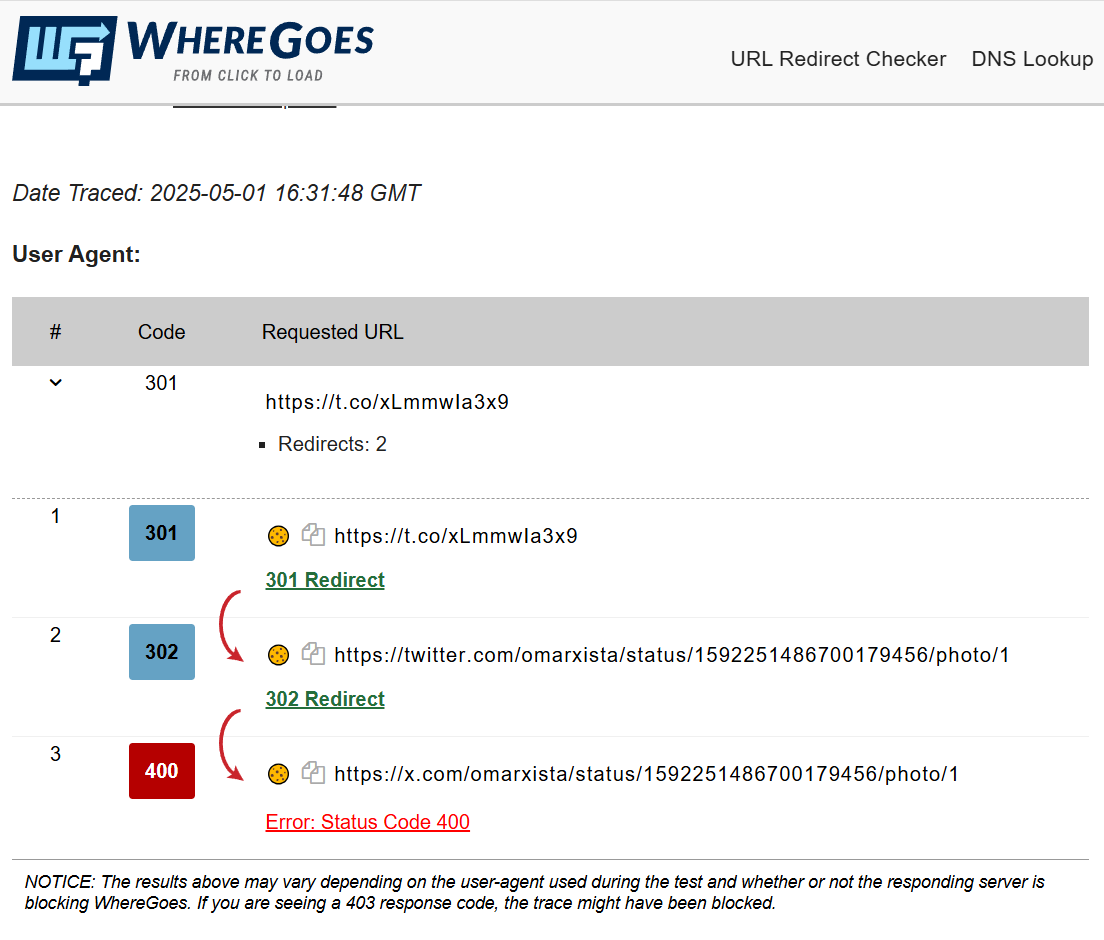

In [ ]:
# Iniciando cache
cache = {}

def expand_url(url):
    # Verifica se já está no cache
    if url in cache:
        return cache[url]
    try:
        response = requests.head(url, allow_redirects=False, timeout=5)
        # Códigos de redirecionamento:
        # https://www.baeldung.com/cs/redirection-status-codes
        if response.status_code in (301, 302, 303, 307, 308):
            # Obtém a URL de redirecionamento a partir do cabeçalho 'Location'
            location = response.headers['location']
            """
            Chama recursivamente a função expand_url para seguir a cadeia de
            redirecionamentos.Caso o 'location' também seja um link encurtado ou
            redirecionado, ele será expandido;se não for possível expandir,
            a função retornará None.
            """
            final_url = expand_url(location)
            """
            Define o resultado como a URL final expandida, se obtida
            corretamente; caso contrário, usa a URL de redirecionamento
            ('location') como fallback
            """
            result = final_url or location

            # Armazena no cache todos redirecionamentos relizados
            cache[url] = result
            return result
        """
        Quando não há redirecionamento (status diferente dos códigos acima),
        ou há sucesso direto (ex: 200), ou erro (ex: 404, 500), define como None
        """
        expanded = None
        cache[url] = expanded
        return expanded

    # Captura exceções específicas do requests
    except RequestException as e:
        expanded = None
        cache[url] = expanded
        return expanded

    # Captura outras exceções inesperadas
    except Exception as e:
        expanded = None
        cache[url] = expanded
        return expanded

def expand_url_list(url_list):
    return [expand_url(url) for url in url_list]

In [ ]:
# Cria coluna de URLs expandidas
df['urls_expand'] = None

In [ ]:
# Ativar tqdm para pandas
tqdm.pandas()

# Cria a coluna urls_expand se não existir
df['urls_expand'] = df.get('urls_expand', pd.Series([None] * len(df)))

# Função de verificação
def needs_expansion(row):
    # Verifica se urls é uma lista válida
    if not isinstance(row['urls'], list) or len(row['urls']) == 0:
        return False

    # Verifica se urls_expand precisa de processamento
    if not isinstance(row['urls_expand'], list):
        return True  # Não foi processado ainda

     # Verifica se há qualquer elemento None (expansão incompleta)
    return any(i is None for i in row['urls_expand'])


# Aplica a máscara
mask = df.apply(needs_expansion, axis=1)

# Processa apenas as linhas necessárias
df.loc[mask, 'urls_expand'] = df.loc[mask, 'urls'].progress_apply(expand_url_list)

**Validando expansão:**

In [ ]:
# Calcula a quantidade de URls expandidas
df['url_expand_count'] = df['urls_expand'].apply(
    lambda x: len([url for url in x if isinstance(url, str) and
                   url.strip()]) if isinstance(x, list) else 0
)

In [ ]:
# Amostragem de validação
df[df['url_count'] > 0][
    ['urls','url_count','urls_expand','url_expand_count']].sample(10)

In [ ]:
"""
Filtra tweets que contêm URLs, mas cuja quantidade de URLs expandidas é menor
que o total identificado. Isso pode indicar falhas na expansão; se houver muitos
casos assim, executar a função de expansão novamente.
"""
df[(df['url_count'] > 0) & (df['url_expand_count'] < df['url_count'])
  ][['urls','url_count','urls_expand','url_expand_count']]

In [ ]:
print(expand_url('https://t.co/MZ1qJPcnuf'))

In [ ]:
# Atualiza manualmente as URLs expandidas após verificação manual
df.at[1043, 'urls_expand'] = ['https://www.msn.com/pt-br/noticias/mundo/parte-2-mais-pa%C3%ADses-que-usam-urna-eletr%C3%B4nica-em-elei%C3%A7%C3%B5es/ss-AA11qCkf?ocid=ob-tw-ptbr-All']
df.at[1043, 'url_expand_count'] = 1

In [ ]:
# Trantando URLs invalidas
# url_regex = r'^(https?://)?([a-zA-Z0-9-]+\.)+[a-zA-Z]{2,}(/[\w\.-]*)*/?$'

# def validar_lista_urls(urls):
#     if not isinstance(urls, list):
#         return None

#     urls_validas = []
#     for url in urls:
#         url_str = str(url).strip()
#         if re.match(url_regex, url_str):
#             urls_validas.append(url_str)

#     return urls_validas if urls_validas else None

# df['urls_expand_valid'] = df['urls_expand'].apply(validar_lista_urls)

In [ ]:
# # Calcula a quantidade de URls validadas
# df['url_expand_count_valid'] = df['urls_expand_valid'].apply(
#     lambda x: len([url for url in x if isinstance(url, str) and
#                    url.strip()]) if isinstance(x, list) else 0
# )

In [ ]:
# Validando
df[df['url_count'] != df['url_expand_count']
  ][['urls','url_count','urls_expand', 'url_expand_count']]

In [ ]:
# Qnd de URLS
df["url_count"].sum()

In [ ]:
# Qnd de URLS
df['url_expand_count'].sum()

## *1.5 Salvar Dataset Processado*

In [ ]:
# ===== Remoção das colunas e renomeação =====
# Lista de colunas para remover
colunas_para_remover = [
 "raw_tweet_length",
 "urls",
 "url_count"
 ]

# Remove colunas (ignora caso não existam)
df = df.drop(columns=colunas_para_remover, errors="ignore")

# Mapeamento de renomeação das colunas
mapeamento_renomeacao = {
 "urls_expand": "urls",
 "url_expand_count": "url_count"
 }

# Renomeia colunas
df = df.rename(columns=mapeamento_renomeacao)

In [ ]:
new_order = [
    # Identificação do Tweet (Conteúdo e Estrutura)
    'tweet_id',
    'raw_tweet',
    'preprocessed_tweet',
    'urls',
    'hashtags',
    'mentions',
    'emojis',
    'is_retweet',
    'original_author',
    'is_truncated',
    'is_upper',
    'tweet_length',
    'has_keywords',

    # Metadados do Tweet (Engajamento e Estatísticas)
    'tweet_created_at',
    'reply_to_tweet_id',
    'reply_to_user_id',
    'retweets',
    'likes',
    'engagement_raw',
    'engagement_rate',
    'engagement_index',
    'url_count',
    'hashtags_count',
    'mentions_count',
    'emoji_count',

    # Informações do Usuário (Perfil e Conta)
    'user_id',
    'followers_count',
    'user_created_at',
    'is_verified',
    'account_age_days',

    # Metadados da Coleta (Contexto e Status)
    'collection_date',
    'is_withheld',
    'electoral_phase'
]

# Reordenar o DataFrame
df = df[new_order]

In [ ]:
df.info()

In [ ]:
df.to_csv("/content/drive/MyDrive/TCC/Data/TUEBR22.csv", index=False)

# **2. Detecção de Contas Automatizadas**

***NOTA: SERÃO CLASSIFICADOS PARA ANÁLISE APENAS OS USUÁRIOS AUTORES DE TWEETS PRESENTES NO CORPUS. MENÇÕES E RESPOSTAS A USUÁRIOS EXTERNOS NÃO SERÃO INCLUÍDAS NESTA ETAPA.***

## **Importando Bibliotecas e Carregando Dataset:**

In [ ]:
!pip install botometer

In [ ]:
import pandas as pd
import re
import numpy as np
import time
import botometer
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import matplotlib.dates as mdates

In [ ]:
# Carreagando dataset
df = pd.read_csv('/content/drive/MyDrive/TCC/Data/TUEBR22.csv',
                 sep=",", low_memory=False,
                 parse_dates=['tweet_created_at', 'user_created_at', 'collection_date'])

In [ ]:
# Carreagando dataset de mapeamento dos usuários
df_users = pd.read_csv('/content/drive/MyDrive/TCC/Data/mapeamento_usuarios.csv',
                 sep=",", low_memory=False)

## *2.1 Classificação Heurística*

Esta classificação identifica contas automatizadas (bots) usando 7 indicadores comportamentais com base em padrões típicos de atividade não-humana no Twitter/X. Cada indicador gera pontos que compõem o bot_score heurístico.

 DOTTO, C.; CUBBON, S. Detectar un bot en redes sociales: 3 formas
 efectivas de identificarlos. 2019. Disponível em: <https://firstdraftnews.org/articles/how-to-spot-a-bot-or-not-the-main-indicators-of-online-automation-co-ordination-and-inauthentic-activity/>. Acesso em: 28 mar. 2025

RIDGE, B. V. Detectar un bot en redes sociales: 3 formas efectivas
 de identificarlos. 2024. Disponível em: <https://www.mediummultimedia.com/social-media/cuales-son-las-3-formas-en-que-puedes-detectar-un-bot/>. Acesso em: 28
 mar. 2025

In [ ]:
# Total de usuários
df['user_id'].nunique()

In [ ]:
# Função para avaliar o username
def is_obvious_sequence(s):
    # Detecta sequências numéricas óbvias, repetitivas ou relacionadas a anos
    if len(s) < 4:
        return False

    # Sequência crescente
    if s in '0123456789' * 2:
        return True

    # Sequência decrescente
    if s in '9876543210' * 2:
        return True

    # Todos os dígitos iguais
    if len(set(s)) == 1:
        return True

    # Padrões repetitivos
    if re.match(r'^(\d\d)\1+$', s) or re.match(r'^(\d\d\d)\1+$', s):
        return True

    # Verifica se é um ano entre 1900 e 2099
    if 1900 <= int(s) <= 2099:
        return True


    return False


def has_random_numbers(username):

    # Verifica se um username contém padrões de números aleatórios.
    # Extrair todos os grupos de 4+ dígitos
    digit_groups = re.findall(r'\d{4,}', username)
    for group in digit_groups:
        if not is_obvious_sequence(group):
            return True

    # Proporção de dígitos > 50%
    digit_count = sum(c.isdigit() for c in username)
    total_chars = len(username)
    if digit_count >= 5 and digit_count / total_chars > 0.5:
        return True

    return False

In [ ]:
# Testando com diferentes padrões
test_cases = [
    "Joao_39472",    # True (Critério 1)
    "Maria_123",     # False (poucos dígitos)
    "User92741",     # True (Critério 2 - sufixo aleatório)
    "1234_User",     # False (números no início)
    "NormalUser",    # False (sem números)
    "XyZ_123",       # False (poucos dígitos)
    "Bt_111",        # False (Critério 3 - dígitos repetidos)
    "user5656",      # False (Critério 4 - sequência interna)
    "john2023",      # False (Critério 5 - ano)
    "rand_4683",     # True (sufixo aleatório)
    "user_24601",    # True (Critério 1)
    "random_9182"    # True (sufixo aleatório)
]

for username in test_cases:
    print(f"{username}: {has_random_numbers(username)}")

In [ ]:
# Aplicando a função
df_users['has_random_numbers'] = df_users['username_original'].apply(has_random_numbers)

In [ ]:
# Obtém os IDs pseudônimos únicos de usuários
users_in_df = df['user_id'].unique()

# Filtra df_users para manter apenas linhas onde 'user_pseudo' está na lista de usuários
result_df = df_users[df_users['user_pseudo'].isin(users_in_df)][
    ['user_id_original','user_pseudo','has_random_numbers']]

In [ ]:
# Deriva colunas auxiliares para análise temporal
df['data'] = df['tweet_created_at'].dt.date
df['hora'] = df['tweet_created_at'].dt.hour
df['atividade_madrugada'] = df['hora'].between(2, 5)

# Agregações por usuário
usuarios = df.groupby('user_id').agg(
    total_tweets=('tweet_id', 'count'),
    retweet_ratio=('is_retweet', 'mean'),
    madrugada_ratio=('atividade_madrugada', 'mean'),
    hashtags_media=('hashtags_count', 'mean'),
    account_age_days=('account_age_days', 'first'),
    data_min=('tweet_created_at', 'min'),
    data_max=('tweet_created_at', 'max')
)


# Calcula o limite do top 5% de atividade
limite_top_5 = usuarios['total_tweets'].quantile(0.95)

# Prepara result_df
result_df = result_df[result_df['user_pseudo'].isin(usuarios.index)]
result_df = result_df.drop_duplicates(subset='user_pseudo', keep='first')

# Merge e preenchimento de valores ausentes
usuarios = usuarios.merge(result_df.set_index('user_pseudo'), left_index=True, right_index=True, how='left')
usuarios['has_random_numbers'] = usuarios['has_random_numbers'].fillna(False)

# Usar total absoluto de hashtags
usuarios['hashtags_total'] = usuarios['hashtags_media'] * usuarios['total_tweets']

def bot_score(row):
    score = 0
    categorias = []

    # 1. Alto volume (top 5%)
    if row['total_tweets'] > limite_top_5:
        score += 1.5
        categorias.append("volume_alto")

    # 2. Alta proporção de retweets
    if row['retweet_ratio'] > 0.8:
        if row['total_tweets'] > 30:
            score += 1.5
            categorias.append("retweet_alto")
        else:
            score += 0.5
            categorias.append("retweet_medio")

    # 3. Padrões irregulares de atividade (coeficiente de variação)
    user_data = df[df['user_id'] == row.name]
    daily_activity = user_data.groupby('data').size()

    if len(daily_activity) > 3:  # suficiente para calcular variação
        mean = daily_activity.mean()
        std = daily_activity.std()
        if mean > 0:
            cv = std / mean
            if cv > 1.0:
                score += 1
                categorias.append("atividade_irreg")

    # 4. Conta nova
    if row['account_age_days'] < 15:
        score += 1
        categorias.append("nova_15d")
    elif row['account_age_days'] < 30:
        score += 0.5
        categorias.append("nova_30d")

    # 5. Muitas hashtags
    if row['hashtags_total'] > 50:
        score += 1
        categorias.append("hashtags_excesso")

    # 6. Username com números aleatórios
    if row['has_random_numbers']:
        score += 0.5
        categorias.append("username_num")

    # 7. Atividade concentrada na madrugada
    if row['madrugada_ratio'] > 0.5:
        score += 0.5
        categorias.append("atividade_madruga")

    return pd.Series({'bot_score': score, 'categorias_pontuadas': categorias})

# Aplica a função
usuarios[['bot_score', 'categorias_pontuadas']] = usuarios.apply(bot_score, axis=1)

# E para merge final:
df = df.merge(
    usuarios[['bot_score', 'categorias_pontuadas']],
    on='user_id',
    how='left'
)

In [ ]:
# Reinciando índice
usuarios = usuarios.rename_axis('user_id').reset_index()

In [ ]:
# Verificando se todos usuários foram classificados
usuarios['user_id'].unique().size

In [ ]:
# Função para converter a escala de classificação para variar de 0 a 1
# Com objetivo de facilitar a comparação com Botometer
def converter_escala(valor, casas=2):
    return round(valor / 7, casas)

In [ ]:
# Aplicando função
usuarios['bot_score'] = usuarios['bot_score'].apply(converter_escala)

In [ ]:
usuarios['bot_score'].max()

In [ ]:
usuarios['bot_score'].value_counts().sort_index()

In [ ]:
# Salvando scores
usuarios.to_csv("/content/drive/MyDrive/TCC/Data/bot_score.csv", index=False)

## *2.2 Classificação via Botometer X (NÃO EXECUTAR BLOCO DE UMA VEZ)*

### 2.2.1 Função para Acessar API do Botometer X



**Devido a limitações recentes no uso da API do Twitter/X (encerramento da API gratuita em 31/05/2023), a versão atual do Botometer, a Botometer X, opera exclusivamente em modo de arquivamento com as seguintes características:**

**Restrições Fundamentais**

**Janela temporal fixa**  
- Dados históricos congelados (atividade até maio de 2023)  
- Contas criadas após 31/05/2023 **não são analisáveis**  
- Atualizações de perfil pós-limite não refletidas  

**Restrições operacionais**  
- O ponto final do Botometer X está disponível em todos os planos  
- **Plano gratuito:** 50 solicitações/mês (50 × 100 = 5.000 contas)  
- **Plano PRO:** 50 solicitações/dia gratuitamente; excedente cobrado a US$ 1/100 solicitações.

- **Plano ULTRA:**  US\$ 50/mês, com 250 solicitações/dia; excedente cobrado a US$ 1/100 solicitações  
- Máximo de 100 contas por requisição  
- Necessidade de desduplicação manual quando enviados `user_id` + `username`  

---


**Estrutura da Resposta**

A resposta será uma lista de objetos JSON. Significados dos elementos no objeto:

- `bot_score`: Pontuação do bot (número entre 0 e 1; redimensionado para 1 a 5 no site do Botometer X)  
- `timestamp`: Hora em que a pontuação foi calculada  
- `user_id`: ID da conta  
- `username`: Nome de usuário da conta  


Referências:
https://rapidapi.com/OSoMe/api/botometer-pro

In [ ]:
# Função que busca em Lote
def get_bot_scores(user_ids):

    # Configuração da API
    # rapidapi_key = "############################################"
    # rapidapi_key = "9a7426b921mshe34e9d4435ff790p1d4515jsn059177ad8dc8"

    bomx = botometer.BotometerX(rapidapi_key=rapidapi_key)

    # Resultado acumulado
    resultados = []

    # Processar em lotes de até 100
    batch_size = 100
    for i in range(0, len(user_ids), batch_size):
        batch_ids = user_ids[i:i+batch_size]

        try:
            print(f"🔍 Processando {len(batch_ids)} contas (lote {i//batch_size + 1})...")
            data = bomx.get_botscores_in_batch(user_ids=batch_ids)

            # Se a API já retorna os dados do lote, não precisa fatiar
            response = {"results": data}

            for result in response.get("results", []):
                if isinstance(result, dict):
                    resultados.append({
                        "user_id": result.get("user_id"),
                        "username": result.get("username"),
                        "bot_score": result.get("bot_score"),
                        "timestamp": result.get("timestamp")
                    })
                else:
                    print(f"⚠️ Formato inesperado no resultado: {result}")

        except Exception as e:
            print(f"❌ Erro no lote {i//batch_size + 1}: {e}")

        time.sleep(2)

    # Salva os resultados em CSV
    resultados = pd.DataFrame(resultados)
    # resultados.to_csv("/content/drive/MyDrive/TCC/Data/resultados_botometer_lote.csv", index=False)
    print("✅ Resultados salvos em 'resultados_botometer_lote.csv'")

    return resultados

### 2.2.2 Aplicacar Função

####2.2.2.1 Busca Inicial (Filtragem Básica)

In [ ]:
# Carregando dataset com as classificação anterior
usuarios = pd.read_csv('/content/drive/MyDrive/TCC/Data/bot_score.csv',
                 sep=",", low_memory=False)
usuarios['user_id'].size

In [ ]:
# Filtrando IDs corrompidos
amostra_filtrada = usuarios[usuarios['user_id_original'].str.contains(',', na=False)]
amostra_filtrada['user_id_original'].size

In [ ]:
# Remever usuários com ID corrompido
# Converter as colunas para string
todos_usuarios = usuarios.astype({'user_id_original': str})
amostra_filtrada = amostra_filtrada.astype({'user_id_original': str})

# Criar um conjunto  com os IDs
ids_amostra = set(amostra_filtrada['user_id_original'])

# Filtrar linhas onde user_id_original NÃO está no conjunto
amostra = todos_usuarios[~todos_usuarios['user_id_original'].isin(ids_amostra)]

amostra['user_id_original'].size

In [ ]:
# Sorteia 5000 (LIMITE DE REQUEST POR DIA DA API DO BOTOMETER X)
# Determina um tamanho de amostra seguro (o menor entre 5000 e o tamanho real do DataFrame)
sample_size = min(5000, len(amostra))

# Realiza a amostragem sem reposição usando o tamanho seguro
amostra = amostra.sample(n=sample_size, random_state=42)
amostra['user_id_original'].size

In [ ]:
# Buscar na API do Botometer
user_ids = amostra['user_id_original'].dropna().astype(str).unique().tolist()
resultados = get_bot_scores(user_ids)

In [ ]:
resultados['user_id'].size

In [ ]:
# (APENAS SE A BUSCA OCORRER SEM ERROS)
# Filtrando usuários que não foram encontrados
# Converter as colunas para string
amostra = amostra.astype({'user_id_original': str})
resultados = resultados.astype({'user_id': str})

# Criar um conjunto  com os IDs
ids = set(resultados['user_id'])

# Filtrar linhas onde user_id_original NÃO está no conjunto de IDs
sem_score = amostra[~amostra['user_id_original'].isin(ids)]

sem_score['user_id_original'].size

In [ ]:
# (APENAS SE A BUSCA OCORRER SEM ERROS)
# Salvando usuários que não foram encontrados (para evitar reconsulta)
sem_score.to_csv("/content/drive/MyDrive/TCC/Data/amostra_sem_score.csv", index=False)

In [ ]:
# Salvando
resultados.to_csv("/content/drive/MyDrive/TCC/Data/bot_score_botometer.csv", index=False)

####2.2.2.2 Loop de Busca Final (Filtragem Otimizada)

In [ ]:
# Carregando dataset com as classificação anterior
usuarios = pd.read_csv('/content/drive/MyDrive/TCC/Data/bot_score.csv',
                 sep=",", low_memory=False)
usuarios['user_id'].size

In [ ]:
# Usuários já possuem score
score_botometer = pd.read_csv('/content/drive/MyDrive/TCC/Data/bot_score_botometer.csv',
                 sep=",", low_memory=False)
score_botometer['user_id'].size

In [ ]:
# Usuários já possuem score
score_botometer = pd.read_csv('/content/drive/MyDrive/TCC/Data/bot_score_botometer.csv',
                 sep=",", low_memory=False)
score_botometer['user_id'].size

In [ ]:
# Remever usuários que já foram classificados
# Converter as colunas para string
amostra = usuarios.astype({'user_id_original': str})
score_botometer = score_botometer.astype({'user_id': str})

# Criar um conjunto  com os IDs do score_botometer para busca
ids_botometer = set(score_botometer['user_id'])

# Filtrar linhas onde user_id_original NÃO está no conjunto de IDs
amostra_nao_classificada = amostra[~amostra['user_id_original'].isin(ids_botometer)]

amostra_nao_classificada['user_id_original'].size

In [ ]:
# Usuários que não contam na base do Botometer X
amostra_sem_score = pd.read_csv('/content/drive/MyDrive/TCC/Data/amostra_sem_score.csv',
                 sep=",", low_memory=False)
amostra_sem_score['user_id_original'].size

In [ ]:
# Remever usuários que não possuem score registrado no Botometer
# Converter as colunas para string
todos_usuarios = amostra_nao_classificada.astype({'user_id_original': str})
amostra_sem_score = amostra_sem_score.astype({'user_id_original': str})

# Criar um conjunto  com os IDs
ids_sem_score = set(amostra_sem_score['user_id_original'])

# Filtrar linhas onde user_id_original NÃO está no conjunto de IDs
amostra_sem_invalidos = todos_usuarios[~todos_usuarios['user_id_original'].isin(ids_sem_score)]

amostra_sem_invalidos['user_id_original'].size

In [ ]:
# Usuários com IDs corrompidos
usuarios_com_id_corrompido = amostra_sem_invalidos[amostra_sem_invalidos['user_id_original'].str.contains(',', na=False)]
usuarios_com_id_corrompido['user_id_original'].size

In [ ]:
# Remever usuários com ID corrompido
# Converter as colunas para string
amostra = amostra_sem_invalidos.astype({'user_id_original': str})
usuarios_com_id_corrompido = usuarios_com_id_corrompido.astype({'user_id_original': str})

# Criar um conjunto  com os IDs
ids = set(usuarios_com_id_corrompido['user_id_original'])

# Filtrar linhas onde user_id_original NÃO está no conjunto
amostra = amostra[~amostra['user_id_original'].isin(ids)]

amostra['user_id_original'].size

In [ ]:
# Sorteia 5000 (LIMITE DE REQUEST POR DIA DA API DO BOTOMETER X)
# Determina um tamanho de amostra seguro (o menor entre 5000 e o tamanho real do DataFrame)
sample_size = min(5000, len(amostra))

# Realiza a amostragem sem reposição usando o tamanho seguro
amostra = amostra.sample(n=sample_size, random_state=42)
amostra['user_id_original'].size

In [ ]:
# Buscar na API do Botometer
user_ids = amostra['user_id_original'].dropna().astype(str).unique().tolist()
resultados = get_bot_scores(user_ids)

In [ ]:
resultados['user_id'].size

In [ ]:
# (APENAS SE A BUSCA OCORRER SEM ERROS)
# Filtrando usuários que não foram encontrados
# Converter as colunas para string
amostra = amostra.astype({'user_id_original': str})
resultados = resultados.astype({'user_id': str})

# Criar um conjunto  com os IDs
ids = set(resultados['user_id'])

# Filtrar linhas onde user_id_original NÃO está no conjunto de IDs
sem_score = amostra[~amostra['user_id_original'].isin(ids)]

sem_score['user_id_original'].size

In [ ]:
# Concatenado dataframes
frames = [sem_score, amostra_sem_score]
sem_score = pd.concat(frames)
sem_score.reset_index(drop=True)
sem_score['user_id'].size

In [ ]:
# (APENAS SE A BUSCA OCORRER SEM ERROS)
# Salvando usuários que não foram encontrados (para evitar reconsulta)
sem_score.to_csv("/content/drive/MyDrive/TCC/Data/amostra_sem_score.csv", index=False)

In [ ]:
# Usuários já possuem score
score_botometer = pd.read_csv('/content/drive/MyDrive/TCC/Data/bot_score_botometer.csv',
                 sep=",", low_memory=False)
score_botometer['user_id'].size

In [ ]:
# Concatenar dataframes (Nova busca + Antiga)
frames = [score_botometer, resultados]
df0 = pd.concat(frames)
df0.reset_index(drop=True)
df0['user_id'].size

In [ ]:
# Verificar se há dados duplicados
duplicatas = df0[df0.duplicated('user_id', keep=False)]
duplicatas['user_id'].size

In [ ]:
# Salvando
df0.to_csv("/content/drive/MyDrive/TCC/Data/bot_score_botometer.csv", index=False)

####2.2.2.3 Buscar de Usuários com IDs Corrompidos pelo Username

In [ ]:
# Carregando dataset com as classificação anterior
usuarios = pd.read_csv('/content/drive/MyDrive/TCC/Data/bot_score.csv',
                 sep=",", low_memory=False)
usuarios['user_id'].size

In [ ]:
# Usuários já possuem score
score_botometer = pd.read_csv('/content/drive/MyDrive/TCC/Data/bot_score_botometer.csv',
                 sep=",", low_memory=False)
score_botometer['user_id'].size

In [ ]:
# Usuários que não contam na base do Botometer X
amostra_sem_score = pd.read_csv('/content/drive/MyDrive/TCC/Data/amostra_sem_score.csv',
                 sep=",", low_memory=False)
amostra_sem_score['user_id_original'].size

In [ ]:
# Remever usuários que já foram classificados
# Converter as colunas para string
amostra = usuarios.astype({'user_id_original': str})
score_botometer = score_botometer.astype({'user_id': str})

# Criar um conjunto  com os IDs do score_botometer para busca
ids_botometer = set(score_botometer['user_id'])

# Filtrar linhas onde user_id_original NÃO está no conjunto de IDs
amostra_nao_classificada = amostra[~amostra['user_id_original'].isin(ids_botometer)]

amostra_nao_classificada['user_id_original'].size

In [ ]:
# Usuários com IDs corrompidos
usuarios_com_id_corrompido = amostra_nao_classificada[
    amostra_nao_classificada['user_id_original'].astype(str).str.contains(',', na=False)]

usuarios_com_id_corrompido['user_id_original'].size

In [ ]:
# Obter username original
amostra = df_users[
df_users['user_id_original'].isin(usuarios_com_id_corrompido['user_id_original'])].copy()

amostra['user_id_original'].size

In [ ]:
# Removendo '@' do username
amostra["username_original"] = amostra["username_original"].str.replace(r"^@", "", regex=True)

In [ ]:
# Extraindo os digitos mais significtivos do User ID corrompidos
amostra["valor_significativo"] = amostra["user_id_original"].apply(
    lambda x: str(x).split("E")[0].replace(",", "").replace(".", "")
)

In [ ]:
# Buscar na API do Botometer pelo username

# Lista de usernames
usernames = amostra['username_original'].dropna().astype(str).unique().tolist()

# Chave da API
# rapidapi_key = "############################################"
# rapidapi_key = "7f9c34c29emsh04b17a9a771dcdep14a155jsn03390eda32e9"

# Inicializar o BotometerX
bomx = botometer.BotometerX(rapidapi_key=rapidapi_key)

resultados = []

try:
    # Obter os scores em lote
    data = bomx.get_botscores_in_batch(usernames=usernames)

    for result in data:
        try:
            # Verifica se o resultado é um dicionário válido
            if isinstance(result, dict):
                resultados.append({
                    "user_id": result.get("user_id", None),
                    "username": result.get("username", None),
                    "bot_score": result.get("bot_score", None),
                    "timestamp": result.get("timestamp", None)
                })
            else:
                print(f"⚠️ Formato inesperado: {result}")
        except Exception as e:
            print(f"❌ Erro ao processar resultado individual: {e}")

except botometer.BotometerException as e:
    print(f"❌ Erro na API do Botometer: {e}")
except Exception as e:
    print(f"❌ Erro geral: {e}")

# Converter resultados válidos em DataFrame
if resultados:
    resultados = pd.DataFrame(resultados)
    print("✅ Dados processados com sucesso!")
else:
    resultados = pd.DataFrame(columns=["user_id", "username", "bot_score", "timestamp"])
    print("⚠️ Nenhum resultado válido foi retornado.")

In [ ]:
resultados["username"].size

In [ ]:
# Colocar username em 'lower case' para comparar
resultados["username"] = resultados["username"].str.lower()
score_botometer["username"] = score_botometer["username"].str.lower()

In [ ]:
merge = pd.merge(resultados, amostra, left_on='username', right_on='username_original', how='left')

In [ ]:
filtr_invalidos = merge[
    merge.apply(lambda row: str(row["user_id"]).startswith(row["valor_significativo"][:3]), axis=1)
]
filtr_invalidos['user_id'].size

In [ ]:
users_classificados = filtr_invalidos[
    filtr_invalidos['username_original'].isin(filtr_invalidos['username'])]

users_classificados['user_id'].size

In [ ]:
# Selecioando as features corretas
users_classificados = users_classificados[
    ['user_id_original', 'username', 'bot_score', 'timestamp']].copy()
users_classificados['user_id_original'].size

In [ ]:
# Renomeando features
users_classificados.rename(columns={"user_id_original": "user_id", "bot_score": "bot_score_botometer"}, inplace=True)

In [ ]:
# Concatenar dataframes
frames = [score_botometer, users_classificados]
df0 = pd.concat(frames)
df0.reset_index(drop=True)
df0['user_id'].size

In [ ]:
# Verificar se há dados duplicados
duplicatas = df0[df0.duplicated('user_id', keep=False)]
duplicatas['user_id'].size

In [ ]:
#Salvando
df0.to_csv("/content/drive/MyDrive/TCC/Data/bot_score_botometer.csv", index=False)

## *2.3 Gerar Score Final*

### 2.3.1 Unificando Datasets

In [ ]:
# Carreando dataset com scores do Heurística
score_heuristica = pd.read_csv('/content/drive/MyDrive/TCC/Data/bot_score.csv',
                 sep=",", low_memory=False)
score_heuristica['user_id'].size

In [ ]:
# Renomeando feature
score_heuristica.rename(columns={"bot_score": "bot_score_heuristica"}, inplace=True)

In [ ]:
# Carreando dataset com scores do Botometer X
score_botometer = pd.read_csv('/content/drive/MyDrive/TCC/Data/bot_score_botometer.csv',
                 sep=",", low_memory=False)
score_botometer['user_id'].size

In [ ]:
# Renomeando feature
score_botometer.rename(columns={"bot_score": "bot_score_botometer"}, inplace=True)

In [ ]:
score_botometer[['bot_score_botometer','timestamp']]

In [ ]:
# Cria uma nova coluna 'date_calculated' copiando os valores de 'timestamp'
score_botometer['date_calculated'] = score_botometer['timestamp']

# Formata  para "AAAA-MM-DD HH:MM:SS"
score_botometer['date_calculated'] = pd.to_datetime(score_botometer['date_calculated'])

In [ ]:
# Validando
score_botometer[['bot_score_botometer','timestamp','date_calculated']]

In [ ]:
# Unindo datasets de scores
score_heuristica['user_id_original'] = score_heuristica['user_id_original'].astype(str)
score_botometer['user_id'] = score_botometer['user_id'].astype(str)

df_merged = pd.merge(score_heuristica, score_botometer, left_on='user_id_original', right_on='user_id', how='left')
df_merged[['user_id_x','bot_score_heuristica','bot_score_botometer','date_calculated']]

In [ ]:
# Validando dados
USER = ['1588992749184974850', '38739271', '339712378']

In [ ]:
score_heuristica[score_heuristica['user_id_original'].isin(USER)
][['user_id','bot_score_heuristica']]

In [ ]:
score_botometer[score_botometer['user_id'].isin(USER)
][['bot_score_botometer','date_calculated']]

In [ ]:
df_merged[df_merged['user_id_original'].isin(USER)
][['user_id_x','bot_score_heuristica','bot_score_botometer','date_calculated']]

In [ ]:
# Usuários não encontrados na API do Botometer X (Deve ser 208)
df_conf = df_merged[df_merged['bot_score_botometer'].isna()
][['user_id_x','bot_score_heuristica','bot_score_botometer','date_calculated']]
df_conf

In [ ]:
# Selecionando colunas importantes
df_merged = df_merged[['user_id_x','bot_score_heuristica','bot_score_botometer','date_calculated']]

# Renomenado coluna
df_merged.rename(columns={"user_id_x": "user_id"}, inplace= True)

In [ ]:
df.info()

In [ ]:
# Unindo dataset de score com dataset principal
df_merged_final = pd.merge(df, df_merged, left_on='user_id', right_on='user_id', how='left')
df = df_merged_final

In [ ]:
# Validando
df.info()

### 2.3.2 Calculando Score Final

O **score final** de cada conta será calculado como uma combinação ponderada entre:

- **Score Heurístico** (10% de peso) – baseado em regras de classificação customizadas.  
- **Score Botometer X** (90% de peso) – obtido da API.

A fórmula é:

<br>


$       Score Final = (Score Botometer \times 0.9 \times Confiabilidade) + (Score Heurístico \times 0.1) $

<br>


Como o Botometer X utiliza dados pré-calculados (até maio de 2023), um **fator de confiabilidade** será aplicado para penalizar scores baseados em tweets distantes do período eleitoral de 2022. Esse fator segue um **decaimento exponencial**:

<br>


$
 Confiabilidade = e^{-k \cdot Distância Média (dias)}
$

<br>

- **Distância Média**: média dos dias entre a data de cálculo e os tweets analisados.  
- **k**: constante de decaimento que define a penalização temporal.



A **meia-vida** ( $ t_{1/2} $ ) é o tempo necessário para que a confiabilidade caia pela metade, e está relacionada à constante ($k$ ) por:

<br>
$
t_{1/2} = \frac{\ln(2)}{k}
$
<br>

No contexto da pesquisa, definir uma meia-vida permite calibrar intuitivamente a penalização. Por exemplo, uma meia-vida de 180 dias implica que a confiabilidade de um conjunto de tweets cairá para 50% após cerca de seis meses de diferença temporal.


Referências:

https://www.gauthmath.com/knowledge/What-is-exponential-decay--7389727628099764234

https://www.geeksforgeeks.org/maths/real-world-examples-of-exponential-decay/

https://mathcracker.com/pt/formula-decaimento-exponencial


**A seguir, será definido empiricamente o valor da meia-vida com base na distribuição de date_calculated, de forma a refletir a concentração temporal dos dados.**

In [ ]:
# Calcula a diferença em dias
time_difference_days = (df['tweet_created_at'].min() - df['date_calculated'].min()).days

# Converte a diferença em dias para anos
time_difference_years = time_difference_days / 365

print(f"Diferença aproximada em dias: {time_difference_days:.0f}")
print(f"Diferença aproximada em anos: {time_difference_years:.0f}")

In [ ]:
# Agrupamento por ano
df.groupby(df['date_calculated'].dt.year).size()

**A maior parte dos scores foi calculada em período próximo ao intervalo de interesse (2022–2023), embora existam registros significativamente mais antigos. Uma escolha adequada de meia-vida deve manter alta confiabilidade para dados temporalmente próximos, ao mesmo tempo em que preserva, com peso reduzido, a contribuição de observações mais distantes no tempo.**

In [ ]:
# Plotar a curva baseado na meia-vida informada
def plot_curva_meia_vida(meia_vida, dias_max):
    dias = np.arange(0, dias_max + 1)
    confiabilidade = 0.5 ** (dias / meia_vida)

    plt.figure(figsize=(10, 6))
    plt.plot(dias, confiabilidade, 'b-', linewidth=2)

    # Destacar pontos-chave
    pontos = [meia_vida,0, 180, 365,545, 730, 1095, 1460, 1825 , 2190, 2555, dias_max ]
    for d in pontos:
        if d <= dias_max:
            conf = 0.5 ** (d / meia_vida)
            plt.plot(d, conf, 'ro')
            plt.text(d, conf + 0.05, f'{d} dias\n({conf:.1%})', ha='center', size=8 )

    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
    plt.axvline(x=meia_vida, color='r', linestyle='--', alpha=0.5)

    plt.xlabel('Dias desde o cálculo do score')
    plt.ylabel('Confiabilidade')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.ylim(0, 1)
    plt.xlim(0, dias_max)
    plt.show()

In [ ]:
# Gerar gráfico meia vida em 180 dias
plot_curva_meia_vida(meia_vida=180, dias_max=3085)

In [ ]:
# Gerar gráfico meia vida em 365 dias
plot_curva_meia_vida(meia_vida=365, dias_max=3285)

In [ ]:
# Gerar gráfico meia vida em 545 dias
plot_curva_meia_vida(meia_vida=545, dias_max=3285)

**Dentre as opções avaliadas, adota-se meia-vida de 365 dias (um ano), por preservar o peso do período de interesse (2022–início de 2023) e ao mesmo tempo penalizar de forma progressiva observações temporalmente distantes.**

In [ ]:
# Configuração clara da meia-vida (em dias)
HALF_LIFE = 365  # Dias para confiabilidade cair 50%
lambda_decay = np.log(2) / HALF_LIFE

In [ ]:
lambda_decay

In [ ]:
def calcular_score_final(score_heuristica, score_botometer, date_calculated, user_tweet_dates):

    # Converter datas
    data_calculo = datetime.datetime.strptime(date_calculated, '%Y-%m-%d').date()

    if not user_tweet_dates:
        return score_heuristica, 0.0, float('inf')

    # Converter datas dos tweets
    tweet_dates = [datetime.datetime.strptime(d, '%Y-%m-%d').date() for d in user_tweet_dates]

    # Calcular distância temporal média
    distancias = []
    for data_tweet in tweet_dates:
        # Distância absoluta (independente de ser antes ou depois)
        distancia = abs((data_calculo - data_tweet).days)
        distancias.append(distancia)

    distancia_media = round(np.mean(distancias), 2)

    # Calcular fator de confiabilidade baseado na distância média
    confiabilidade = round(np.exp(-lambda_decay * distancia_media), 2)

    # Peso do Botometer e da Heurística
    peso_botometer = 0.9
    peso_heuristica = 0.1

    # Calcular score final
    score_bruto = ((peso_botometer * score_botometer) * confiabilidade) + (peso_heuristica * score_heuristica)
    score_final = round(score_bruto, 2)

    return score_final, confiabilidade, distancia_media, peso_botometer, peso_heuristica

In [ ]:
# Função para classificação
def classificar_conta(score_final):
    if score_final >= 0.7:
        return "Alto"
    elif score_final >= 0.4:
        return "Médio"
    else:
        return "Baixo"

In [ ]:
# Agrupar por user_id e coletar todas as datas de tweets
user_tweet_dates_dict = df.groupby('user_id')['tweet_created_at'].apply(
    lambda x: [d.strftime('%Y-%m-%d') for d in x]
).to_dict()

In [ ]:
len(user_tweet_dates_dict)

In [ ]:
# Selecionar apenas colunas relevantes e remover duplicatas por user_id
df_users = df[['user_id', 'bot_score_heuristica',
               'bot_score_botometer',
               'date_calculated']].drop_duplicates(subset='user_id')

# Remover linhas com dados ausentes
df_users = df_users.dropna(subset=['bot_score_botometer', 'date_calculated'])

In [ ]:
# Aplicar as funções em cada linha
def aplicar_scores(row):
    user_id = row['user_id']
    score_heuristica = row['bot_score_heuristica']
    score_botometer = row['bot_score_botometer']
    date_calculated = row['date_calculated'].strftime('%Y-%m-%d')
    tweet_dates = user_tweet_dates_dict.get(user_id, [])

    try:
        score_final, confiabilidade, distancia_media, _, _ = calcular_score_final(
            score_heuristica, score_botometer, date_calculated, tweet_dates
        )
        classificacao = classificar_conta(score_final)
    except Exception as e:
        score_final, confiabilidade, distancia_media, classificacao = None, None, None, f"ERRO: {str(e)}"

    return pd.Series({
        'score_final': score_final,
        'reliability': confiabilidade,
        'average_distance': distancia_media,
        'automation_level': classificacao
    })

# Aplicar
df_users[['score_final', 'reliability',
          'average_distance',
          'automation_level']] = df_users.apply(aplicar_scores, axis=1)

In [ ]:
df_users

In [ ]:
df = df.merge(df_users[['user_id', 'score_final', 'reliability', 'average_distance', 'automation_level']], on='user_id', how='left')

In [ ]:
# Verificando usuários sem classificação (Deve ser 208)
df[df['automation_level'].isna()] \
    .groupby('user_id') \
    .size() \
    .reset_index(name='qtd') \
    .sort_values(by='qtd', ascending=False)

In [ ]:
df.info()

In [ ]:
# Salvando
df.to_csv("/content/drive/MyDrive/TCC/Data/TUEBR22.csv", index=False)

# **3. Classificação de Conteúdo dos Tweets**

Nesta etapa da pesquisa, foram utilizadas as seguintes bibliotecas Python com objetivo de transformar os textos limpos em insights semânticos: polaridade de sentimentos, entidades mencionadas, tópicos latentes e detecção de desinformação.

- **Pandas (pandas)**: Biblioteca fundamental para manipulação e análise de dados. Foi utilizada para carregar o dataset, armazenar os resultados das classificações (sentimentos, entidades, tópicos e desinformação), consolidar os dados de checagem de fatos e gerenciar os DataFrames de treino, validação e teste.

- **NumPy (numpy)**: Utilizada para operações numéricas eficientes e manipulação de arrays. Foi empregada para calcular probabilidades (softmax), métricas de avaliação (F1, AUC-ROC, matriz de confusão) e operações vetorizadas nos embeddings para a modelagem de tópicos.

- **Re (re)**: Biblioteca nativa para buscas e substituições com expressões regulares básicas. Foi usada na limpeza final dos textos antes das classificações, na data augmentation e no pré-processamento para o BERTopic.

- **Emoji (emoji)**: Biblioteca para manipulação de emojis em textos. Foi utilizada para remover emojis dos tweets antes das análises de sentimentos e desinformação, evitando vieses nos modelos.

- **Hashlib (hashlib)**: Usada para gerar hashes criptográficos (SHA-256). Foi empregada para anonimizar identificadores de tweets e usuários durante a classificação e evitar duplicatas no corpus de fine-tuning.

- **Regex (regex)**: Biblioteca com suporte avançado a Unicode e padrões complexos. Foi utilizada para identificar corretamente letras acentuadas na remoção de stopwords e para mascarar entidades políticas ("Lula" e "Bolsonaro") nos textos de treino.

- **Difflib (difflib)**: Utilizada para comparar textos e encontrar similaridades. Foi empregada para mesclar tópicos semanticamente próximos e auxiliar na criação de hard negatives no fine-tuning.

- **Swifter (swifter)**: Biblioteca que acelera operações em DataFrames aplicando paralelismo. Foi usada para otimizar a inferência de sentimentos e NER em todo o dataset de 111 mil tweets.

- **Requests (requests)**: Utilizada para fazer requisições HTTP. Foi empregada na raspagem automatizada de checagens de fatos nos sites Projeto Comprova, Aos Fatos, Agência Lupa, E-Farsas e Boatos.org.

- **Tqdm (tqdm)**: Adiciona barras de progresso para loops e operações demoradas. Foi utilizada para monitorar a análise de sentimentos, o treinamento do BERTopic, o fine-tuning e a inferência final em lote.

- **Torch (torch)**: Framework de deep learning utilizado como backend para os modelos da Hugging Face. Foi empregado para executar inferências na GPU, aplicar softmax e manipular tensores durante o fine-tuning.

- **Transformers (transformers)**: Biblioteca para modelos de linguagem baseados em Transformer. Foi utilizada para carregar os modelos de sentimentos e desinformação, seus tokenizadores e configurar o Trainer durante o fine-tuning.

- **spaCy (spacy)**: Biblioteca para processamento de linguagem natural industrial. Foi utilizada para carregar o modelo pt_core_news_lg e extrair entidades nomeadas (pessoas, locais, organizações e outros) dos tweets.

- **NLTK (nltk)**: Biblioteca clássica para PLN. Foi utilizada para baixar e carregar stopwords em português, expandidas com gírias e termos de redes sociais para a modelagem de tópicos e fine-tuning.

- **BERTopic (bertopic)**: Biblioteca para modelagem de tópicos baseada em embeddings. Foi utilizada para extrair automaticamente tópicos dos tweets combinando UMAP e HDBSCAN.

- **UMAP (umap)**: Algoritmo de redução de dimensionalidade. Foi utilizado para reduzir os embeddings de 384 para 13 dimensões, preparando os dados para o agrupamento no BERTopic.

- **HDBSCAN (hdbscan)**: Algoritmo de clustering baseado em densidade. Foi utilizado para agrupar tweets semanticamente semelhantes e identificar tópicos coesos no BERTopic.

- **BeautifulSoup (bs4)**: Biblioteca para parsing de HTML. Foi utilizada para extrair títulos, descrições, datas e links das páginas de checagem de fatos durante a composição do corpus de fine-tuning.

- **Scikit-learn (sklearn)**: Biblioteca para aprendizado de máquina. Foi utilizada para dividir os dados, calcular métricas (matriz de confusão, ROC-AUC, precisão, recall, F1), gerar curvas ROC e Precision-Recall.

- **Evaluate (evaluate)**: Biblioteca da Hugging Face para avaliação de modelos. Foi utilizada para carregar e calcular métricas padrão (accuracy, f1, precision, recall) durante o fine-tuning.

- **Matplotlib (matplotlib)**: Biblioteca para visualização de dados. Foi utilizada para plotar gráficos de perda e acurácia, matriz de confusão e curva ROC do classificador.

- **Seaborn (seaborn)**: Biblioteca para visualização estatística. Foi utilizada para plotar a matriz de confusão com heatmaps estilizados, facilitando a interpretação dos resultados.

- **Unicodedata (unicodedata)**: Biblioteca nativa para manipulação de caracteres Unicode. Foi utilizada para remover acentos dos textos durante o pré-processamento para a modelagem de tópicos.

- **Time (time)**: Biblioteca nativa para manipulação de tempo. Foi utilizada para adicionar pausas (sleep) entre as requisições HTTP durante a raspagem, evitando bloqueios.

- **CSV (csv)**: Biblioteca nativa para leitura e escrita de arquivos CSV. Foi utilizada para salvar os datasets de checagem de fatos e o corpus final UEFactsBR.csv.

- **OS (os)**: Biblioteca nativa para manipulação de arquivos e diretórios. Foi utilizada para criar pastas para os experimentos, salvar os modelos treinados e gerenciar caminhos de arquivos.

- **Datetime (datetime)**: Biblioteca nativa para manipulação de datas e horários. Foi utilizada para gerar timestamps únicos para nomear as pastas de cada experimento de fine-tuning.

- **Urllib.parse (urllib.parse)**: Biblioteca nativa para manipulação de URLs. Foi utilizada para codificar parâmetros de consulta (urlencode) e construir URLs dinâmicas durante a raspagem.

- **Scipy (scipy)**: Biblioteca para computação científica. Foi utilizada para aplicar a função softmax nos logits durante a avaliação e calibração de probabilidades do classificador.

- **JSON (json)**: Biblioteca nativa para manipulação de dados JSON. Utilizada para salvar e carregar arquivos de configuração dos experimentos, incluindo hiperparâmetros, temperatura calibrada e limiar de decisão, garantindo a reprodutibilidade e o versionamento dos modelos treinados.

### **Importando Bibliotecas e Carregando Dataset:**

In [ ]:
!python --version

Python 3.12.13


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.3 MB/s eta 0:00:00


In [ ]:
# Instalação
!pip install bertopic -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.3 MB/s eta 0:00:00


In [ ]:
!pip install -q evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm.notebook import tqdm
import spacy


import re
import unicodedata
import nltk
from nltk.corpus import stopwords
from bertopic import BERTopic
import hdbscan
import umap

import requests
from bs4 import BeautifulSoup
import time
from urllib.parse import urlencode, urljoin

# ==================================================
# IMPORTAÇÕES DE BIBLIOTECAS FINE-TUNING
# ==================================================
import torch
import numpy as np
import evaluate
from evaluate import load
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import csv
from tqdm import tqdm
import os
from datetime import datetime

from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    recall_score,
    precision_recall_curve,
    precision_score,
    average_precision_score,
    auc
)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from scipy.special import softmax

import transformers

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)
from datasets import Dataset
from nltk.corpus import stopwords



import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import json


In [ ]:
# Instalação
!python -m spacy download pt_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 3.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Carreagando dataset
df = pd.read_csv('/content/drive/MyDrive/TCC/Data/TUEBR22.csv',
                 sep=",", low_memory=False,
                 parse_dates=['tweet_created_at', 'user_created_at', 'collection_date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111217 entries, 0 to 111216
Data columns (total 45 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tweet_id              111217 non-null  object        
 1   raw_tweet             111217 non-null  object        
 2   preprocessed_tweet    111193 non-null  object        
 3   urls                  17025 non-null   object        
 4   hashtags              111217 non-null  object        
 5   mentions              111217 non-null  object        
 6   emojis                111217 non-null  object        
 7   is_retweet            111217 non-null  int64         
 8   original_author       69620 non-null   object        
 9   is_truncated          111217 non-null  int64         
 10  is_upper              111217 non-null  int64         
 11  tweet_length          111217 non-null  int64         
 12  has_keywords          111217 non-null  int64         
 13 

## 3.1 *Análise de Sentimentos*

**Modelo Utilizado: `tabularisai/multilingual-sentiment-analysis`**

Para a etapa de classificação de sentimentos, foi utilizado o modelo `tabularisai/multilingual-sentiment-analysis`, disponível na plataforma Hugging Face.  

Esse modelo é uma versão ajustada do DistilBERT multilingue, otimizado para classificação de textos em 23 idiomas, incluindo o português, o que o torna adequado para a análise dos tweets coletados neste trabalho.  

**Principais características do modelo: **
- Base: `distilbert-base-multilingual-cased`  
- Idiomas suportados: 23 (Inglês, Português, Espanhol, Francês, Alemão, Russo, Chinês, Árabe, entre outros).  
- Categorias de saída: 5 classes — Muito Negativo, Negativo, Neutro, Positivo, Muito Positivo.  
- Dados de treinamento: gerados de forma sintética e balanceados para garantir robustez em diferentes contextos linguísticos.  
- Acurácia: o modelo alcançou aproximadamente 93% de acerto (train_acc_off_by_one ≈ 0.93) em seu conjunto de validação.  

A escolha por esse modelo se deve à sua boa avaliação pela comunidade, à atualização constante e ao fato de ser multilíngue, garantindo maior flexibilidade. Dessa forma, evitou-se o alto custo computacional e a necessidade de criação de um dataset específico em português, utilizando-se uma solução já consolidada e validada pela comunidade de PLN.


**Referências:**

**tabularisai, Samuel Gyamfi, Vadim Borisov, Richard H. Schreiber.** *multilingual-sentiment-analysis (Revision 69afb83)*. Hugging Face, 2025. (https://huggingface.co/tabularisai/multilingual-sentiment-analysis).


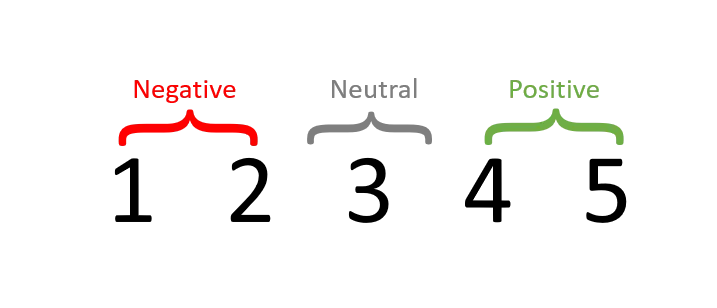

**As cinco classes originais do modelo (`Muito Negativo`, `Negativo`, `Neutro`, `Positivo` e `Muito Positivo`) foram agrupadas em três: `Negativo`, `Neutro` e `Positivo`, simplificando a análise da polaridade dos textos.**




In [ ]:
# Configurar modelo
model_name = "tabularisai/multilingual-sentiment-analysis"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Função para classificar sentimento
def predict_sentiment(texts):
    inputs = tokenizer(texts, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    sentiment_map = {0: "Negativo", 1: "Negativo", 2: "Neutro", 3: "Positivo", 4: "Positivo"}
    return [sentiment_map[p] for p in torch.argmax(probabilities, dim=-1).tolist()]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/851 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

In [ ]:
# Seleciona tweets unicos
unique_tweets = df["preprocessed_tweet"].astype(str).unique()

sentiments = {}
for tweet in tqdm(unique_tweets, desc="Analisando sentimentos"):
    sentiments[tweet] = predict_sentiment([tweet])[0]

df["sentiment"] = df["preprocessed_tweet"].astype(str).map(sentiments)

Analisando sentimentos:   0%|          | 0/46045 [00:00<?, ?it/s]

In [ ]:
df[["preprocessed_tweet", "sentiment"]]

,preprocessed_tweet,sentiment
0,"O Instagram agora virou urna eletrônica, todo ...",Neutro
1,Eu sempre voto logo pela manhã já deixo meu vo...,Neutro
2,Vai no Google e busca Simone / urna eletrônica...,Neutro
3,A urna eletrônica é segura? Confira neste vídeo.,Neutro
4,"Opa. E seu vizinho chinês, pode votar? Tem urn...",Neutro
...,...,...
111212,Quando o meio para depositar o voto não é a sa...,Neutro
111213,Quando o meio para depositar o voto não é a sa...,Neutro
111214,"Na minha cessão não registra ele, ele só ficam...",Negativo
111215,"Pergunta sincera, porque não teve todo esse tr...",Negativo


In [ ]:
# Salvando
df.to_csv("/content/drive/MyDrive/TCC/Data/TUEBR22.csv", index=False)

## 3.2 *Reconhecimento de Entidades Nomeadas*

**Modelo Utilizado:** `pt_core_news_lg-3.8.0`

Para a etapa de reconhecimento de entidades nomeadas (NER), foi utilizado o modelo `pt_core_news_lg` da biblioteca *spaCy*, especificamente desenvolvido para processamento de textos em português.

Este modelo é um *pipeline* completo para processamento de linguagem natural em português, treinado pela *Explosion AI* com base em corpora de referência como o UD Portuguese Bosque e WikiNER, utilizando vetores fastText gerados a partir do OSCAR Common Crawl e Wikipedia.

**Principais características do modelo:**

- Base Arquitetural: Pipeline com componentes tok2vec, morphologizer, parser, lemmatizer, senter, attribute_ruler e ner

- Idioma: Português (especializado)

- Gênero: Textos jornalísticos (notícias, mídia)

- Tamanho: 541 MB (large)

- Vetores: 500k chaves, 500k vetores únicos (300 dimensões)

- Categorias de entidades: 4 classes — PESSOAS (PER), LOCAIS (LOC), ORGANIZAÇÕES (ORG) e OUTROS (MISC)

- Desempenho e Métricas de Avaliação para NER: Precisão 90%, Recall 90% e F-score 90%

A escolha por esse modelo justifica-se pela sua excelente performance em textos em português, e pela cobertura abrangente das entidades mais relevantes para análise de mídia social.

**Referências:**

https://spacy.io/models/pt/

https://frankalcantara.com/Introdu%C3%A7%C3%A3o-ao-Spacy-2/

https://www.youtube.com/watch?v=iGXLX7b41DQ

In [ ]:
# Carregar modelo
nlp = spacy.load("pt_core_news_lg")

# Função para extrair entidades
def extract_entities(text):
    doc = nlp(text)
    entities = {
        "PESSOAS": [ent.text for ent in doc.ents if ent.label_ == "PER"],
        "LOCAIS": [ent.text for ent in doc.ents if ent.label_ in ["LOC"]],
        "ORGANIZAÇÕES": [ent.text for ent in doc.ents if ent.label_ == "ORG"],
        "OUTROS": [ent.text for ent in doc.ents if ent.label_ == "MISC"]
    }
    return entities

In [ ]:
# Preencher os valores ausentes com uma string vazia antes de aplicar a função
df["preprocessed_tweet"] = df["preprocessed_tweet"].fillna("")

# Aplicar ao DataFrame
df["entities"] = df["preprocessed_tweet"].apply(extract_entities)

In [ ]:
df[['preprocessed_tweet', 'entities']]

,preprocessed_tweet,entities
0,"O Instagram agora virou urna eletrônica, todo ...","{'PESSOAS': ['Instagram'], 'LOCAIS': [], 'ORGA..."
1,Eu sempre voto logo pela manhã já deixo meu vo...,"{'PESSOAS': [], 'LOCAIS': [], 'ORGANIZAÇÕES': ..."
2,Vai no Google e busca Simone / urna eletrônica...,"{'PESSOAS': ['Simone'], 'LOCAIS': [], 'ORGANIZ..."
3,A urna eletrônica é segura? Confira neste vídeo.,"{'PESSOAS': [], 'LOCAIS': [], 'ORGANIZAÇÕES': ..."
4,"Opa. E seu vizinho chinês, pode votar? Tem urn...","{'PESSOAS': [], 'LOCAIS': [], 'ORGANIZAÇÕES': ..."
...,...,...
111212,Quando o meio para depositar o voto não é a sa...,"{'PESSOAS': [], 'LOCAIS': ['Ministro Barroso']..."
111213,Quando o meio para depositar o voto não é a sa...,"{'PESSOAS': [], 'LOCAIS': ['Ministro Barroso']..."
111214,"Na minha cessão não registra ele, ele só ficam...","{'PESSOAS': [], 'LOCAIS': [], 'ORGANIZAÇÕES': ..."
111215,"Pergunta sincera, porque não teve todo esse tr...","{'PESSOAS': [], 'LOCAIS': [], 'ORGANIZAÇÕES': ..."


In [ ]:
# Salvando
df.to_csv("/content/drive/MyDrive/TCC/Data/TUEBR22.csv", index=False)

## 3.3 *Modelagem de Tópicos*

**Modelo Utilizado:** `BERTopic versão 0.17.4` com `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`

Para a etapa de **modelagem de tópicos**, foi utilizada a biblioteca **BERTopic**, um framework avançado para extração automática de tópicos baseado em *transformers* e aprendizado não supervisionado. O modelo combina representações semânticas densas com técnicas de agrupamento para identificar padrões temáticos latentes em conjuntos textuais.

A representação semântica dos documentos foi realizada por meio de *sentence embeddings* multilíngues, com suporte nativo ao português, amplamente empregados em tarefas de similaridade semântica, agrupamento textual e análise temática. Esses vetores permitem capturar relações semânticas profundas entre os textos, mesmo em cenários com documentos curtos e heterogêneos.

Os embeddings gerados são utilizados pelo **BERTopic** para agrupar documentos semanticamente semelhantes e extrair tópicos coerentes e interpretáveis, sem a necessidade de definição prévia do número de temas, característica especialmente relevante para análise exploratória de dados textuais.

**Principais características dos modelos**

i) **BERTopic**
  - Abordagem: Modelagem de tópicos baseada em embeddings semânticos
  - Tipo: Não supervisionado
  - Capacidade de identificação automática de tópicos
  - Extração de tópicos coerentes e interpretáveis
  - Robustez a ruído textual

ii) **paraphrase-multilingual-MiniLM-L12-v2**
  - Arquitetura: MiniLM (Transformer)
  - Camadas: 12
  - Dimensionalidade dos embeddings: 384
  - Idioma: Multilíngue, com suporte ao português
  - Foco: Similaridade semântica e representação textual

A escolha desses modelos justifica-se por sua capacidade conjunta de capturar relações semânticas profundas entre documentos, oferecendo maior coerência temática quando comparados a métodos tradicionais de modelagem de tópicos.

**Referências:**

https://bertopic.com/

https://github.com/MaartenGr/BERTopic?tab=readme-ov-file

https://colab.research.google.com/drive/1BoQ_vakEVtojsd2x_U6-_x52OOuqruj2?usp=sharing#scrollTo=91_cyh9MGOaC

https://colab.research.google.com/drive/1BoQ_vakEVtojsd2x_U6-_x52OOuqruj2?usp=sharing#scrollTo=meEM585mCk7a

https://www.youtube.com/watch?v=B_AMcT2uSlA

https://www.youtube.com/watch?v=v3SePt3fr9g

https://www.youtube.com/watch?v=8TBaLWvJBuE&t=2s


### 3.3.1 Processamento Adicional

In [ ]:
# Baixar stopwords em português
nltk.download('stopwords')
stopwords_pt = set(stopwords.words('portuguese'))

# Expandir stopwords significativamente
custom_stopwords = {
    "pq", "sim", "então", "aí", "tá", "tipo", "rt", "ser", "haver", "pra", "de",
    "hahaha", "em", "ohhhhhh", "aaahhhh", "nao", "pro", "vc", "voce", "ta", "to",
    "so", "ja","pra", "pro", "pros", "pras", "ta", "tá", "to", "tô", "tamo",
    "tava", "tavam", "aff", "blz", "bjs", "bj", "fds",
    "eh", "ne", "ai", "la", "lo", "meu", "minha", "nos", "vos", "lhe", "lhes",
    "te", "ti", "lhe", "nos", "vos", "lhes", "o", "a", "os", "as", "um", "uma",
    "uns", "umas", "ate", "para", "por", "com", "sem", "sob", "sobre", "entre",
    "ante", "apos", "ate", "com", "contra", "desde", "em", "entre", "para", "per",
    "perante", "por", "sem", "sob", "sobre", "tras", "durante", "exceto", "salvo",
    "segundo", "consoante", "mediante", "tirante", "visto", "dado", "feito", "menos",
    "mais", "muito", "pouco", "todo", "toda", "todos", "todas", "cada", "algum",
    "alguma", "alguns", "algumas", "nenhum", "nenhuma", "nenhuns", "nenhumas",
    "outro", "outra", "outros", "outras", "qual", "quais", "quanto", "quantos",
    "quantas", "tal", "tais", "qualquer", "quaisquer", "tanto", "tantos", "tantas",
    "quando", "onde", "como", "porque", "porquê", "porquanto", "pois", "embora",
    "conquanto", "se", "caso", "contanto", "salvo", "exceto", "menos", "mas", "porem",
    "todavia", "contudo", "entretanto", "no entanto", "ainda", "alias", "ademais",
    "outrossim", "entao", "assim", "logo", "portanto", "por conseguinte",
    "consequentemente","isto", "isso", "aquilo", "este", "esta", "estes", "estas",
    "esse", "essa", "esses",  "vc", "vcs", "voce", "voces", "tb", "tbm", "q", "pq",
    "ql", "qnd", "cm", "td",  "pdc", "smpls", "d", "p",  "sdds",  "sla",
    "essas", "aquele", "aquela", "aqueles", "aquelas", "aquilo", "mesmo", "mesma",
    "mesmos", "mesmas", "proprio", "propria", "proprios", "proprias", "tal", "tais",
    "qual", "quais", "certo", "certa", "certos", "certas", "vario", "varia", "varios",
    "varias", "outro", "outra", "outros", "outras", "tudo", "nada", "algo", "alguem",
    "ninguem", "cada", "qualquer", "quaisquer", "ambos", "ambas", "todo", "toda",
    "todos", "todas", "quantos", "quantas", "tantos", "tantas", "poucos", "poucas",
    "muitos", "muitas", "alguns", "algumas", "nenhum", "nenhuma", "nenhuns", "nenhumas",
    "outros", "outras", "certos", "certas", "varios", "varias", "diversos", "diversas",
    "cada", "qual", "quais", "qualquer", "quaisquer", "todo", "toda", "todos", "todas",
    "um", "uma", "uns", "umas", "outro", "outra", "outros", "outras", "tal", "tais",
    "qual", "quais", "certo", "certa", "certos", "certas", "vario", "varia", "varios",
    "varias", "diverso", "diversa", "diversos", "diversas", "muito", "muita", "muitos",
    "muitas", "pouco", "pouca", "poucos", "poucas", "tanto", "tanta", "tantos", "tantas",
    "quanto", "quanta", "quantos", "quantas", "algum", "alguma", "alguns", "algumas",
    "nenhum", "nenhuma", "nenhuns", "nenhumas", "todo", "toda", "todos", "todas",
    "outro", "outra", "outros", "outras", "qual", "quais", "cada", "qualquer", "quaisquer",
    "acontecer", "acreditar", "adiantar", "achar", "agora", "amanhã", "apenas", "ano",
    "antes", "aqui", "beleza", "bem", "bora", "bom", "cara", "caso", "coisa",
    "colocar", "começar", "conseguir", "continuar", "criar", "dar", "dia",
    "decidir", "deixar", "depois", "dever", "dentro", "dizer", "entender",
    "entrar", "estado", "estar", "esperar", "existir", "falar", "favor",
    "final", "forma", "formar", "fazer", "ficar", "funcionar", "galera",
    "gente", "gostar", "grande", "haver", "hora", "hoje", "igual", "lembrar",
    "lado", "lugar", "meio", "mesmo", "modo", "mostrar", "mudar", "nunca",
    "novo", "ontem", "parecer", "parte", "passar", "permitir", "pensar",
    "pessoa", "pessoal", "poder", "ponto", "precisar", "primeiro", "querer",
    "real", "saber", "sair", "semana", "sentir", "ser", "será", "seguir",
    "sempre", "somente", "são", "tão", "tá", "talvez", "tambem", "tar", "tempo",
    "tentar", "ter", "tipo", "usar", "vão", "vcs", "ver", "vez", "vir", "voltar",
    "vdd", "vao", "sao", "tao", "sera", "fiz", "cade","irao", "pqp", "msm", "senao",
    "comum", "dai", "via", "farao","opcao", "acima", "diante", "etc", "ali",
    "mano", "alem", "serao", "terao", "enquanto", "voces", "exemplo", "tbm",
    "quase", "qdo", "tda", "tds", "tdas", "vlw", "obg", "dps", "hj", "amanha",
    "dnv", "plmdds", "mds", "pfv", "pls", "oq", "nd", "ngm", "mt", "mto", "pd",
    "nossaaaaa", "amarelokkkkkkkkkkkkkkaos", "kkkm", "qqr", "demais", "kkkkkkkl",


}

stopwords_pt.update(custom_stopwords)

# Carregar modelo de linguagem português
nlp = spacy.load("pt_core_news_lg")

# Função auxiliar: remover acentos
def remover_acentos(texto):
    return ''.join(
        c for c in unicodedata.normalize("NFD", texto)
        if unicodedata.category(c) != "Mn"
    )

# Melhorar a função de pré-processamento
def preprocessar_texto(texto):
    if not isinstance(texto, str):
        return ""

    # Lowercase
    texto = texto.lower()

    # Remover acentos
    texto = remover_acentos(texto)

    # Remover menções, URLs, números
    texto = re.sub(r'@\w+', '', texto)  # menções
    texto = re.sub(r'http\S+', '', texto)  # URLs
    texto = re.sub(r'\d+', '', texto)  # números

    # Remover risadas variadas
    texto = re.sub(r'\b(?:a{2,}|h{2,}|k{2,}|r{2,})\b', '', texto)

    # Remove padrões de onomatopeias e risadas
    texto = re.sub(r'\b(?:a+h+|h+a+|e+h+|o+h+|u+h+|ha+|he+|hi+|ho+|hu+|hahaha+|aa+|ii+|uu+|mmm+)\b', '', texto, flags=re.IGNORECASE)

    # Remove onomatopeias e repetições separadas por vírgula ou espaço
    texto = re.sub(r'\b[ahmetn]{0,2}(?:[aeiouh]{2,})(?:[mtphn]{0,2})\b', '', texto, flags=re.IGNORECASE)

    # Remover caracteres especiais mas manter espaços
    texto = re.sub(r'[^\w\s]', ' ', texto)

    # Remover espaços extras
    texto = re.sub(r'\s+', ' ', texto).strip()

    # Processar com spaCy
    doc = nlp(texto)

    # Lematizar e filtrar
    palavras = []
    for token in doc:
        lemma = token.lemma_.lower().strip()

        # Critérios mais rigorosos
        if (len(lemma) > 2 and
            lemma not in stopwords_pt and
            not token.is_punct and
            not token.is_space and
            lemma.isalpha() and
            not any(char.isdigit() for char in lemma)):
            palavras.append(lemma)

    return " ".join(palavras)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Filtrar apenas linhas com texto válido
df_valid = df[df["preprocessed_tweet"].notna()].copy()

# Agrupar textos ORIGINAIS idênticos
grupos_originais = df_valid.groupby("preprocessed_tweet").groups

# Criar lista de textos ORIGINAIS únicos
textos_originais_unicos = list(grupos_originais.keys())
indices_representativos = [idxs[0] for idxs in grupos_originais.values()]

print(f"Textos totais: {len(df_valid)}")
print(f"Textos únicos para processar: {len(textos_originais_unicos)}")
print(f"Redução de processamento: {100*(1-len(textos_originais_unicos)/len(df_valid)):.1f}%")

# APLICAR PRÉ-PROCESSAMENTO APENAS NOS TEXTOS ÚNICOS
textos_limpos_unicos = [preprocessar_texto(texto) for texto in textos_originais_unicos]

# Criar dicionário de mapeamento texto_original -> texto_limpo
mapeamento_limpeza = dict(zip(textos_originais_unicos, textos_limpos_unicos))

# Aplicar o mapeamento para obter a coluna clean_tweet no DataFrame
df_valid["clean_tweet"] = df_valid["preprocessed_tweet"].map(mapeamento_limpeza)

# SALVAR NO DATASET ORIGINAL
# Criar coluna clean_tweet no DataFrame original
df["clean_tweet"] = None  # ou np.nan

# Preencher apenas as linhas processadas com os valores limpos
df.loc[df_valid.index, "clean_tweet"] = df_valid["clean_tweet"]

Textos totais: 111193
Textos únicos para processar: 46044
Redução de processamento: 58.6%


In [ ]:
# Salvando
df.to_csv("/content/drive/MyDrive/TCC/Data/TUEBR22.csv", index=False)

### 3.3.2 Modelagem de Tópicos

In [ ]:
# Versão Ultilizada
import bertopic
bertopic.__version__

'0.17.4'

In [ ]:
# Agrupar por textos limpos para o BERTopic
grupos_limpos = df.groupby("clean_tweet").groups
textos_limpos_para_modelo = list(grupos_limpos.keys())

print(f"Textos únicos após limpeza: {len(textos_limpos_para_modelo)}")

Textos únicos após limpeza: 43479


In [ ]:
embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
docs = textos_limpos_para_modelo

In [ ]:
# Preparar os sub-models
umap_model = umap.UMAP(n_components=13, n_neighbors=8,min_dist=0.0, random_state = 42)
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=90, gen_min_span_tree=True, prediction_data=True)

# Fit BERTopic
topic_model = BERTopic(
    embedding_model = embedding_model,
    language="portuguese",
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    nr_topics= "auto"          # Reduz automaticamente tópicos similares

)

topics, probs = topic_model.fit_transform(docs)

In [ ]:
len(topics)

43479

In [ ]:
# Visualizar tópicos
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,21705,-1_urna_voto_votar_eletronico,"[urna, voto, votar, eletronico, bolsonaro, lul...",[bolsonarista votar tse anular eleicao exercit...
1,0,7821,0_voto_votar_urna_eleitor,"[voto, votar, urna, eleitor, presidente, fraud...",[povo reclamar problema urna voto momento vota...
2,1,3312,1_apertar_urna_boca_forca,"[apertar, urna, boca, forca, dedo, roubar, dig...","[urna, bolsonaro apertar urna, urna apertar]"
3,2,2728,2_brasil_brasileiro_eletronico_urna,"[brasil, brasileiro, eletronico, urna, povo, v...","[apertar urna lula presidente brasil, urna ele..."
4,3,2274,3_eletronico_urna_eleicoe_confiar,"[eletronico, urna, eleicoe, confiar, seguro, t...","[urna eletronico eleger bolsonaro, urna eletro..."
5,4,478,4_lula_urna_paulista_pai,"[lula, urna, paulista, pai, outubro, ultimo, p...",[golpe urna eletronico falhar golpe setembro f...
6,5,464,5_codigo_fonte_acesso_binario,"[codigo, fonte, acesso, binario, compilar, lin...",[verificar claro codigo fonte versao codigo fo...
7,6,428,6_lula_urna_bolsonaro_turno,"[lula, urna, bolsonaro, turno, apertar, frente...","[lula turno urna, urna lula bolsonaro, lula urna]"
8,7,335,7_domingo_apertar_aniversario_urna,"[domingo, apertar, aniversario, urna, presente...","[apertar urna domingo lula, domingo apertar ur..."
9,8,323,8_numero_digitar_urna_apertar,"[numero, digitar, urna, apertar, arrancar, nul...","[urna apertar numero, urna numero, numero urna]"


In [ ]:
# Reduzir outliers
new_topics = topic_model.reduce_outliers(docs, topics)

In [ ]:
topic_model.update_topics(docs, topics=new_topics)

2025-12-13 12:31:33,664 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [ ]:
# Visualizar tópicos após redução de outliers
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2,-1_loki_error__,"[loki, error, , , , , , , , ]",[bolsonarista votar tse anular eleicao exercit...
1,0,12419,0_voto_votar_urna_eleitor,"[voto, votar, urna, eleitor, presidente, candi...",[povo reclamar problema urna voto momento vota...
2,1,7178,1_apertar_urna_boca_forca,"[apertar, urna, boca, forca, meter, dedo, roub...","[urna, bolsonaro apertar urna, urna apertar]"
3,2,2981,2_brasil_brasileiro_povo_eletronico,"[brasil, brasileiro, povo, eletronico, urna, v...","[apertar urna lula presidente brasil, urna ele..."
4,3,4392,3_eletronico_urna_confiar_seguro,"[eletronico, urna, confiar, seguro, eleicoe, c...","[urna eletronico eleger bolsonaro, urna eletro..."
5,4,2013,4_perder_urna_pai_golpe,"[perder, urna, pai, golpe, acabar, rua, urnar,...",[golpe urna eletronico falhar golpe setembro f...
6,5,1063,5_codigo_fonte_acesso_software,"[codigo, fonte, acesso, software, linha, tse, ...",[verificar claro codigo fonte versao codigo fo...
7,6,1707,6_lula_bolsonaro_bolso_urna,"[lula, bolsonaro, bolso, urna, vencer, turno, ...","[lula turno urna, urna lula bolsonaro, lula urna]"
8,7,623,7_domingo_apertar_urna_proximo,"[domingo, apertar, urna, proximo, aniversario,...","[apertar urna domingo lula, domingo apertar ur..."
9,8,956,8_numero_digitar_urna_apertar,"[numero, digitar, urna, apertar, candidato, se...","[urna apertar numero, urna numero, numero urna]"


In [ ]:
topics_to_merge = [[0, 2, 3], # urna
                   [1, 7, 8, 18, 25, 26, 30], # uso (ato de votar)
                   [9, 12, 14], # multimidia e mídias sociais
                   [15, 16, 4, 20]] # política

topic_model.merge_topics(docs, topics_to_merge)

In [ ]:
# Visualizar tópicos após união de tópicos semelhantes
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2,-1_loki_error__,"[loki, error, , , , , , , , ]","[error, loki]"
1,0,19792,0_voto_urna_eletronico_votar,"[voto, urna, eletronico, votar, brasil, presid...",[votar voto votar bolsonaro candidatar comprar...
2,1,9987,1_apertar_urna_numero_domingo,"[apertar, urna, numero, domingo, boca, forca, ...","[aparecer urna apertar, apertar urna lula dedo..."
3,2,3019,2_urna_chorar_vacina_perder,"[urna, chorar, vacina, perder, pai, golpe, stf...",[correr afeganistao urna stf mundo andar armar...
4,3,1707,3_lula_bolsonaro_bolso_urna,"[lula, bolsonaro, bolso, urna, vencer, turno, ...","[lula bolso urna, lula turno urna, urna votar ..."
5,4,1420,4_pesquisa_boca_resultado_turno,"[pesquisa, boca, resultado, turno, urna, errar...","[pesquisa boca urna voto, boca urna pesquisa, ..."
6,5,1386,5_foto_video_twitter_aparecer,"[foto, video, twitter, aparecer, tirar, urna, ...","[tirar foto boletim urna, votar tirar foto urn..."
7,6,1097,6_fraude_fraudar_urna_eletronico,"[fraude, fraudar, urna, eletronico, prova, gan...",[fraude urna eletronico fraude voto duvida arg...
8,7,1063,7_codigo_fonte_acesso_software,"[codigo, fonte, acesso, software, urna, linha,...",[codigo fonte codigo fonte codigo constroir pr...
9,8,786,8_auditar_auditavel_auditoria_urna,"[auditar, auditavel, auditoria, urna, modelo, ...","[urna auditavel, auditar urna, auditar urna au..."


In [ ]:
# Adcionar nomes mais legíveis
topic_model.set_topic_labels({
    -1: "Outlier",
     0: "Urna Eletrônica",
     1: "Uso da Urna",
     2: "Narrativa Política",
     3: "Disputa Eleitoral",
     4: "Pesquisas Eleitorais",
     5: "Mídias Sociais",
     6: "Fraude",
     7: "Código-Fonte",
     8: "Auditoria",
     9: "Voto Impresso",
    10: "Narrativa Religiosa",
    11: "Celular na Cabine",
    12: "Fake News",
    13: "Logs da Urna",
    14: "Militares e Fiscalização",
    15: "Conexão com a Internet",
    16: "Ataque Hacker",
    17: "Live do Argentino"
})

In [ ]:
# Visualizar tópicos após redução de outliers
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,2,-1_loki_error__,Outlier,"[loki, error, , , , , , , , ]","[error, loki]"
1,0,19792,0_voto_urna_eletronico_votar,Urna Eletrônica,"[voto, urna, eletronico, votar, brasil, presid...",[votar voto votar bolsonaro candidatar comprar...
2,1,9987,1_apertar_urna_numero_domingo,Uso da Urna,"[apertar, urna, numero, domingo, boca, forca, ...","[aparecer urna apertar, apertar urna lula dedo..."
3,2,3019,2_urna_chorar_vacina_perder,Narrativa Política,"[urna, chorar, vacina, perder, pai, golpe, stf...",[correr afeganistao urna stf mundo andar armar...
4,3,1707,3_lula_bolsonaro_bolso_urna,Disputa Eleitoral,"[lula, bolsonaro, bolso, urna, vencer, turno, ...","[lula bolso urna, lula turno urna, urna votar ..."
5,4,1420,4_pesquisa_boca_resultado_turno,Pesquisas Eleitorais,"[pesquisa, boca, resultado, turno, urna, errar...","[pesquisa boca urna voto, boca urna pesquisa, ..."
6,5,1386,5_foto_video_twitter_aparecer,Mídias Sociais,"[foto, video, twitter, aparecer, tirar, urna, ...","[tirar foto boletim urna, votar tirar foto urn..."
7,6,1097,6_fraude_fraudar_urna_eletronico,Fraude,"[fraude, fraudar, urna, eletronico, prova, gan...",[fraude urna eletronico fraude voto duvida arg...
8,7,1063,7_codigo_fonte_acesso_software,Código-Fonte,"[codigo, fonte, acesso, software, urna, linha,...",[codigo fonte codigo fonte codigo constroir pr...
9,8,786,8_auditar_auditavel_auditoria_urna,Auditoria,"[auditar, auditavel, auditoria, urna, modelo, ...","[urna auditavel, auditar urna, auditar urna au..."


In [ ]:
topic_info = topic_model.get_topic_info()

# Obter os novos tópicos do modelo atualizado
new_topics = topic_model.topics_

# Criar mapeamento de número do tópico para CustomName
mapa_topico_para_custom = dict(zip(topic_info['Topic'], topic_info['CustomName']))

# Criar mapeamento de clean_tweet para número do tópico
mapa_topicos_numerico = dict(zip(textos_limpos_para_modelo, new_topics))

# Mapear para o DataFrame original - primeiro para número do tópico, depois para CustomName
df['topic_num'] = df['clean_tweet'].map(mapa_topicos_numerico)
df['topic'] = df['topic_num'].map(mapa_topico_para_custom)

In [ ]:
#
mask = df['topic_num'].isna()
df.loc[mask, ['topic_num', 'topic']] = [-1, "Outlier"]

In [ ]:
df[['topic_num', 'topic']]

,topic_num,topic
0,0.0,Urna Eletrônica
1,0.0,Urna Eletrônica
2,0.0,Urna Eletrônica
3,5.0,Mídias Sociais
4,0.0,Urna Eletrônica
...,...,...
111212,0.0,Urna Eletrônica
111213,0.0,Urna Eletrônica
111214,0.0,Urna Eletrônica
111215,0.0,Urna Eletrônica


In [ ]:
# Salvar o modelo BERTopic
topic_model.save("/content/drive/MyDrive/TCC/Data/TUEBR22_topics")

2025-12-13 14:18:45,388 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [ ]:
# Salvando
df.to_csv("/content/drive/MyDrive/TCC/Data/TUEBR22.csv", index=False)

## 3.4 *Identificação de Desinformação*

**Modelo Utilizado:** `neuralmind/bert-large-portuguese-cased`

Para a etapa de classificação binária, foi utilizado o modelo de linguagem `neuralmind/bert-large-portuguese-cased`, uma das principais referências para Processamento de Linguagem Natural (PLN) em português brasileiro. Este modelo, também conhecido como BERTimbau Large, é uma adaptação da arquitetura BERT original, especificamente pré‑treinada em um corpus de grande escala do português do Brasil (BrWaC).

Principais características do modelo:

* Arquitetura: BERT‑Large (Transformer)
* Camadas: 24
* Cabeças de atenção: 16
* Parâmetro:s ~335 milhões
* Idioma: Português brasileiro
* Pré‑treinamento: BrWaC (corpus brasileiro de grande escala)
* Tamanho máximo de tokens:	512


**Referências:**

https://huggingface.co/learn/llm-course/en/chapter3/5

https://github.com/rasbt/LLM-finetuning-scripts/tree/main/conventional/distilbert-movie-review/layerwise-experiment

https://github.com/rasbt/LLMs-from-scratch/blob/main/ch06/01_main-chapter-code/ch06.ipynb

https://magazine.sebastianraschka.com/p/finetuning-large-language-models

https://medium.com/@heyamit10/fine-tuning-bert-for-classification-a-practical-guide-b8c1c56f252c

https://stackoverflow.com/questions/69907682/what-are-differences-between-automodelforsequenceclassification-vs-automodel

https://huggingface.co/learn/llm-course/chapter2/2?fw=pt

https://github.com/lucazav/binclass-tools

https://www.datacamp.com/tutorial/complete-guide-data-augmentation

https://medium.com/@tubelwj/several-text-data-augmentation-methods-in-nlp-cc610135779b

https://medium.com/@anthony.demeusy/machine-learning-tips-adjusting-decision-threshold-for-binary-classification-c937d7046a43

https://medium.com/data-hackers/principais-m%C3%A9tricas-de-classifica%C3%A7%C3%A3o-de-modelos-em-machine-learning-94eeb4b40ea9

https://medium.com/data-science/what-is-label-smoothing-108debd7ef06

https://medium.com/gsgcommunity/m%C3%A9tricas-de-avalia%C3%A7%C3%A3o-de-modelos-de-classifica%C3%A7%C3%A3o-bin%C3%A1ria-5c9b0ce786fa

https://github.com/gpleiss/temperature_scaling/blob/master/temperature_scaling.py

https://arxiv.org/pdf/1706.04599

https://medium.com/data-science/expected-calibration-error-ece-a-step-by-step-visual-explanation-with-python-code-c3e9aa12937d

https://medium.com/@harshit158/softmax-temperature-5492e4007f71

https://www.youtube.com/watch?v=oOZr4kRJgFE

https://www.youtube.com/watch?v=SFsc2P240rw

https://www.youtube.com/watch?v=oJU6-qW6xZU

#### 3.4.1 Compor Corpus

##### 3.4.1.1 Raspagem de Checagens

In [ ]:
# 1. Projeto Comprova
def coletar_comprova(paginas=36):
    dados = []

    for p in range(1, paginas + 1):

        for t in range(3):
            try:
                r = requests.get(f"https://projetocomprova.com.br/page/{p}/?s=urna",
                                headers={"User-Agent": "Mozilla/5.0"}, timeout=15)

                if r.status_code == 200:
                    soup = BeautifulSoup(r.text, "html.parser")

                    arts = soup.find_all("article", class_="answer-french")

                    if not arts:
                        arts = soup.find_all("article")
                        arts = [a for a in arts if a.find("h2", class_="answer__title")]

                    if arts:


                        for artigo in arts:
                            try:
                                titulo_tag = artigo.find("h2", class_="answer__title")
                                if not titulo_tag:
                                    continue

                                link = titulo_tag.find("a")["href"]
                                titulo = titulo_tag.get_text(strip=True)

                                descricao_tag = artigo.find("div", class_="answer__content")
                                text = descricao_tag.get_text(strip=True) if descricao_tag else ""

                                data_tag = soup.find("span", class_="answer__credits__date")
                                data = data_tag.get_text(strip=True)

                                dados.append({
                                    "titulo": titulo,
                                    "text": text,
                                    "data_publicacao": data,
                                    "link": link
                                })

                            except Exception as e:
                                print(f"  Erro artigo: {e}")
                                continue
                        break
                    else:
                        print("vazia")
                        break
                else:
                    raise Exception(f"HTTP {r.status_code}")
            except Exception as e:
                if t == 2:
                    print(f"erro ({str(e)})")
                time.sleep(2)
        time.sleep(1)

    return pd.DataFrame(dados)

# Buscar
print(f"📄 Coletando páginas...")
df_comprova = coletar_comprova(36)  # Coletar todas as páginas

df_comprova.to_csv("/content/drive/MyDrive/TCC/Data/UEFactsBR/FactCheckingUE/comprova.csv", index=False, encoding="utf-8-sig")
print(f"✅ Total de {len(df_comprova)} checagens salvas.")

📄 Coletando páginas...
✅ Total de 349 checagens salvas.


In [ ]:
df_comprova

,titulo,text,data_publicacao,link
0,Urnas eletrônicas brasileiras não foram frauda...,Diferentemente do que sugere um vídeo que circ...,07/11/2025,https://projetocomprova.com.br/publicações/urn...
1,Volta a circular mentira sobre urnas terem sid...,Conteúdo investigado: Post que mostra trecho d...,07/11/2025,https://projetocomprova.com.br/publicações/vol...
2,Fortaleza não teve troca de 6 mil urnas nem de...,Conteúdo investigado: Publicação no Kwai afirm...,07/11/2025,https://projetocomprova.com.br/publicações/for...
3,Alexandre de Moraes não é mais do TSE e não tr...,Conteúdo investigado: Um vídeo mostra o minist...,07/11/2025,https://projetocomprova.com.br/publicações/ale...
4,Comlurb participa de distribuição de urnas no ...,Conteúdo analisado: Vídeo mostra trabalhadores...,07/11/2025,https://projetocomprova.com.br/publicações/com...
...,...,...,...,...
344,Uso de camiseta com inscrição de candidato não...,Estão circulando no WhatsApp dois textos que p...,26/10/2018,https://projetocomprova.com.br/post/re_2b5w8xn...
345,Voto não é invalidado se eleitor votar em um s...,É falsa a informação de que votar apenas para ...,26/10/2018,https://projetocomprova.com.br/post/re_2b5w8xb...
346,Vídeos foram alterados para parecerem gravaçõe...,Um vídeo que está sendo difundido nas redes so...,26/10/2018,https://projetocomprova.com.br/post/re_2b5w8xz...
347,"Sonia Guajajara, vice de Boulos, usa nome indí...",Publicações nas redes sociais acusam a candida...,26/10/2018,https://projetocomprova.com.br/post/re_2b5w8xz...


In [ ]:
# 2. AOS FATOS
def coletar_aosfatos(query="urna", paginas=17):
    base_url = "https://www.aosfatos.org/noticias/"
    headers = {"User-Agent": "Mozilla/5.0"}
    artigos = []

    for p in range(1, paginas + 1):
        url = f"{base_url}?q={query}&page={p}"

        r = requests.get(url, headers=headers)
        if r.status_code != 200:
            print("Erro:", r.status_code)
            continue

        soup = BeautifulSoup(r.text, "html.parser")
        blocos = soup.select("div.group.relative")

        if not blocos:
            print("Nenhum artigo encontrado nesta página.")
            break

        for bloco in blocos:
            titulo_tag = bloco.select_one("p.block")
            titulo = titulo_tag.get_text(strip=True) if titulo_tag else None

            link_tag = bloco.select_one("a.absolute")
            link = "https://www.aosfatos.org" + link_tag["href"] if link_tag else None

            # Extrair selo/veredito (ex: “falso”, “verdadeiro”, “não é bem assim”)
            selo_tag = bloco.select_one("span.rounded-full.border-px")
            veredito = selo_tag.get_text(strip=True).lower() if selo_tag else "sem selo"

            artigos.append({
                "titulo": titulo,
                "lable": veredito,
                "link": link

            })

        time.sleep(2)  # pausa para não sobrecarregar o servidor

    return pd.DataFrame(artigos)


# Buscar
print(f"📄 Coletando página...")
df_aosfatos = coletar_aosfatos("urnas", paginas=34)

df_aosfatos.to_csv("/content/drive/MyDrive/TCC/Data/UEFactsBR/FactCheckingUE/aosfatos.csv", index=False)
print(f"✅ Total de {len(df_aosfatos)} checagens salvas.")

📄 Coletando página...
✅ Total de 401 checagens salvas.


In [ ]:
df_aosfatos

,titulo,lable,link
0,Fotos que mostram Nikolas Ferreira caminhando ...,falso,https://www.aosfatos.org/noticias/fotos-que-mo...
1,Não é verdade que TSE contabilizou voto de ele...,falso,https://www.aosfatos.org/noticias/nao-e-verdad...
2,Lula não se irritou com pergunta sobre prisão ...,falso,https://www.aosfatos.org/noticias/lula-nao-se-...
3,Vídeos de protestos contra Maduro em 2024 circ...,sem selo,https://www.aosfatos.org/noticias/videos-prote...
4,MPF investiga desinformação sobre expulsão de ...,sem selo,https://www.aosfatos.org/noticias/mpf-investig...
...,...,...,...
396,Site publica informações falsas e distorcidas ...,distorcido,https://www.aosfatos.org/noticias/site-publica...
397,Aos Fatosfaz três anos com três novidades na m...,sem selo,https://www.aosfatos.org/noticias/aos-fatos-fa...
398,O que dizem os políticos e as redes sobre o ju...,sem selo,https://www.aosfatos.org/noticias/o-que-dizem-...
399,Haddad atribui derrota em 2016 a divisão de vo...,sem selo,https://www.aosfatos.org/noticias/haddad-atrib...


In [ ]:
# 3. E-farsas.com
def coletar_e_farsas(termo="urna", paginas=3):
    resultados = []

    for pagina in range(1, paginas + 1):
        url = f"https://www.e-farsas.com/page/{pagina}/?s={termo}"

        try:
            response = requests.get(url, timeout=30)
            soup = BeautifulSoup(response.text, "html.parser")

            # Encontrar todos os artigos
            for article in soup.find_all("li", class_="infinite-post"):
                # Título e link: a tag com href que contém o h2
                a_tag = article.find("a", href=True)
                if a_tag and a_tag.find("h2"):
                    titulo = a_tag.find("h2").get_text(strip=True)
                    link = a_tag["href"]
                else:
                    # Tentar encontrar de outra forma
                    h2_tag = article.find("h2")
                    if h2_tag:
                        a_tag = h2_tag.find_parent("a")
                        titulo = h2_tag.get_text(strip=True) if h2_tag else None
                        link = a_tag["href"] if a_tag and a_tag.has_attr("href") else None
                    else:
                        titulo = link = None

                # Categoria
                cat_tag = article.find("h3", class_="mvp-main-blog-cat")
                categoria = cat_tag.get_text(strip=True) if cat_tag else None

                # Data
                data_tag = article.find("span", class_="mvp-blog-time")
                data = data_tag.get_text(strip=True) if data_tag else None

                # Autor
                autor_tag = article.find("span", class_="mvp-blog-author")
                autor = autor_tag.get_text(strip=True) if autor_tag else None

                if titulo and link:
                    resultados.append({
                        "titulo": titulo,
                        "link": link,
                        "categoria": categoria,
                        "data": data
                    })

        except Exception as e:
            print(f"Erro página {pagina}: {e}")
            break

    return pd.DataFrame(resultados)

# Coletar dados
print("📄 Coletando dados do E-farsas.com...")
df_urna = coletar_e_farsas("urna", 5)
df_urnas = coletar_e_farsas("urnas", 5)

# Combinar e remover duplicados
df = pd.concat([df_urna, df_urnas], ignore_index=True)
df_efarcas = df.drop_duplicates()
df_efarcas = df_efarcas.reset_index(drop=True)

# Salvar
df_efarcas.to_csv("/content/drive/MyDrive/TCC/Data/UEFactsBR/FactCheckingUE/e_farsas.csv", index=False, encoding="utf-8-sig")
print(f"✅ Salvo: {len(df_efarcas)} registros em 'e_farsas.csv'")

📄 Coletando dados do E-farsas.com...
✅ Salvo: 114 registros em 'e_farsas.csv'


In [ ]:
df_efarcas

,titulo,link,categoria,data
0,Alexandre de Moraes determinou que o criador d...,http://www.e-farsas.com/alexandre-de-moraes-de...,Conspirações,29 de dezembro de 2025
1,O TSE destruiu 200 mil urnas eletrônicas após ...,http://www.e-farsas.com/o-tse-destruiu-200-mil...,Falso,6 de março de 2025
2,É verdade que Fortaleza teve mais de 6.000 urn...,http://www.e-farsas.com/e-verdade-que-fortalez...,Conspirações,29 de outubro de 2024
3,A urna eletrônica brasileira foi invadida por ...,http://www.e-farsas.com/a-urna-eletronica-bras...,Conspirações,27 de abril de 2024
4,A prefeitura de Belo Horizonte (MG) anulou ele...,http://www.e-farsas.com/a-prefeitura-de-belo-h...,Conspirações,10 de outubro de 2023
...,...,...,...,...
109,Aécio Neves pediu para obstruir todos os traba...,http://www.e-farsas.com/aecio-neves-pediu-para...,Falso,30 de março de 2018
110,Quem não cadastrar a biometria vai ter que pag...,http://www.e-farsas.com/quem-nao-cadastrar-bio...,Dinheiro,21 de novembro de 2017
111,Esposa de Aécio Neves gravou vídeo xingando os...,http://www.e-farsas.com/esposa-de-aecio-neves-...,Falso,20 de maio de 2017
112,20 Boatos que circularam durante as eleições d...,http://www.e-farsas.com/20-boatos-que-circular...,Política,27 de outubro de 2014


In [ ]:
# 4. Agência Lupa
def coletar_agencia_lupa(termo_busca="urna", max_paginas=5, categoria=142, ordem="DESC"):
    headers = {"User-Agent": "Mozilla/5.0"}
    resultados = []
    base_url = "https://www.agencialupa.org"

    for pagina in range(1, max_paginas + 1):
        params = {'s': termo_busca, 'order': ordem, 'cat-list': categoria}
        url = f"{base_url}/page/{pagina}/?{urlencode(params)}"

        try:
            response = requests.get(url, headers=headers, timeout=30)
            if response.status_code != 200:
                break

            soup = BeautifulSoup(response.text, "html.parser")


            grid_div = soup.find("div", class_="grid gap-row-5 lg:gap-row-6")

            if not grid_div:
                break

            articles = grid_div.find_all("article", class_="feed")

            if not articles:
                break

            for article in articles:
                link_tag = article.find("a", class_="feed-link")
                link = link_tag["href"] if link_tag and link_tag.get("href") else None

                titulo_tag = article.find("h2", class_="post-title-feed-lg")
                titulo = titulo_tag.get_text(strip=True) if titulo_tag else None

                descricao_tag = article.find("p", class_="feed-excert")
                descricao = descricao_tag.get_text(strip=True) if descricao_tag else None

                data_tag = article.find("span", class_="feed-datetime")
                data = data_tag.get_text(strip=True) if data_tag else None

                categoria_tag = article.find("p", class_="post-hat-feed-lg")
                categoria_artigo = categoria_tag.get_text(strip=True) if categoria_tag else None

                resultados.append({
                    "titulo": titulo,
                    "data": data,
                    "categoria_artigo": categoria_artigo,
                    "link": link

                })

            time.sleep(1)

        except:
            break

    return pd.DataFrame(resultados)


# Buscar
print(f"📄 Coletando páginas...")
df_urna = coletar_agencia_lupa(termo_busca="urna", max_paginas=17)
df_urnas = coletar_agencia_lupa(termo_busca="urnas", max_paginas=14)

# Combinar todos os resultados
df_completo = pd.concat([df_urna, df_urnas], ignore_index=True)
df_lupa = df_completo.drop_duplicates()
df_lupa  = df_lupa.reset_index(drop=True)

# Salvar resultados
df_lupa.to_csv("/content/drive/MyDrive/TCC/Data/UEFactsBR/FactCheckingUE/agencia_lupa.csv", index=False, encoding="utf-8-sig")
print(f"✅ Salvo {len(df_lupa)} registros em 'agencia_lupa.csv'")

📄 Coletando páginas...
✅ Salvo 231 registros em 'agencia_lupa.csv'


In [ ]:
df_lupa

,titulo,data,categoria_artigo,link
0,É falso que Lula só venceu eleições com voto e...,15 dez. 2025 às 16h15,Política,https://www.agencialupa.org/verificacao/2025/1...
1,Não existem provas de que as eleições de 2022 ...,19 set. 2025 às 14h51,Política,https://www.agencialupa.org/jornalismo/2025/09...
2,TSE não destruiu milhares de urnas para “queim...,07 mar. 2025 às 16h53,Eleições,https://www.agencialupa.org/jornalismo/2025/03...
3,É falso que STF e TSE manipularam a eleição de...,17 fev. 2025 às 16h26,Eleições,https://www.agencialupa.org/jornalismo/2025/02...
4,É falso que urnas de Kentucky estejam trocando...,01 nov. 2024 às 18h58,Eleições EUA,https://www.agencialupa.org/jornalismo/2024/11...
...,...,...,...,...
226,É falso que Bolsonaro foi diplomado presidente...,06 dez. 2022 às 17h30,Eleições 2022,https://www.agencialupa.org/jornalismo/2022/12...
227,É falso que site de biografias anunciou vitóri...,06 dez. 2022 às 14h38,Eleições 2022,https://www.agencialupa.org/jornalismo/2022/12...
228,Homem que denuncia fraude eleitoral em vídeo n...,01 dez. 2022 às 17h33,Eleições 2022,https://www.agencialupa.org/jornalismo/2022/12...
229,É falso que urnas eletrônicas foram descartada...,22 nov. 2022 às 17h38,Eleições,https://www.agencialupa.org/jornalismo/2022/11...


In [ ]:
# 5. Boatos.org
def coletar_boatos(termo_busca="urna", max_paginas=5):
    headers = {"User-Agent": "Mozilla/5.0"}
    resultados = []
    base_url = "https://www.boatos.org"

    for pagina in range(1, max_paginas + 1):
        params = {'s': termo_busca}
        url = f"{base_url}/page/{pagina}/?{urlencode(params)}"

        try:
            response = requests.get(url, headers=headers, timeout=30)
            if response.status_code != 200:
                break

            soup = BeautifulSoup(response.text, "html.parser")

            # Encontrar a div que contém todos os artigos
            posts_wrapper = soup.find("div", class_="posts-wrapper")

            if not posts_wrapper:
                break

            # Encontrar todos os artigos
            articles = posts_wrapper.find_all("article")

            if not articles:
                break

            for article in articles:
                # Título e link
                title_tag = article.find("h2", class_="blog-entry-title")
                if title_tag:
                    link_tag = title_tag.find("a")
                    titulo = link_tag.get_text(strip=True) if link_tag else None
                    link = link_tag["href"] if link_tag and link_tag.get("href") else None
                else:
                    titulo = None
                    link = None

                # Categoria
                categoria_tag = article.find("li", class_="meta category")
                if categoria_tag:
                    categoria_link = categoria_tag.find("a")
                    categoria = categoria_link.get_text(strip=True) if categoria_link else None
                else:
                    categoria = None

                # Data
                data_tag = article.find("time", class_="updated")
                if data_tag:
                    # Pega o atributo datetime (formato ISO) ou o texto
                    data = data_tag.get("datetime", data_tag.get_text(strip=True))
                else:
                    data = None

                # Autor
                autor_tag = article.find("span", class_="author-name")
                if autor_tag:
                    autor = autor_tag.get_text(strip=True)
                else:
                    autor = None

                # Extrair o "veredito" do título (se contém #boato)
                veredito = "Boato" if titulo and "#boato" in titulo.lower() else "Notícia"

                resultados.append({
                    "titulo": titulo,
                    "categoria": categoria,
                    "data": data,
                    "link": link
                })

            time.sleep(1)

        except Exception as e:
            print(f"Erro na página {pagina}: {e}")
            break

    return pd.DataFrame(resultados)


# Buscar notícias sobre urnas
print(f"📄 Coletando páginas do Boatos.org...")
df_urna = coletar_boatos(termo_busca="urna", max_paginas=23)
df_urnas = coletar_boatos(termo_busca="urnas", max_paginas=16)

# Combinar todos os resultados
df_completo = pd.concat([df_urna, df_urnas], ignore_index=True)
df_boatos = df_completo.drop_duplicates(subset=["link", "titulo"])
df_boatos  = df_boatos.reset_index(drop=True)

# Salvar resultados
df_boatos.to_csv("/content/drive/MyDrive/TCC/Data/UEFactsBR/FactCheckingUE/boatos_org.csv", index=False, encoding="utf-8-sig")
print(f"✅ Salvo {len(df_boatos)} registros em 'boatos_org.csv'")

📄 Coletando páginas do Boatos.org...
✅ Salvo 573 registros em 'boatos_org.csv'


In [ ]:
# Verificando categorias
df_boatos['categoria'].unique()

array(['Política', 'Mundo', 'Esporte', 'Fast-Checking', 'Opinião',
       'Tecnologia', 'Brasil', 'Saúde', 'English', 'Español', 'Ciência',
       'Lista', 'Notícia falsa', 'Entretenimento', 'Religião'],
      dtype=object)

In [ ]:
# Filtrando por categorias relevantes
df_boatos  = df_boatos[(df_boatos['categoria'] == 'Política') | (df_boatos['categoria'] == 'Fast-Checking')]
df_boatos  = df_boatos.reset_index(drop=True)
df_boatos.to_csv("/content/drive/MyDrive/TCC/Data/UEFactsBR/FactCheckingUE/boatos_org.csv", index=False, encoding="utf-8-sig")

In [ ]:
df_boatos

,titulo,categoria,data,link
0,É falso que Maduro tenha entregado código-font...,Política,None,https://www.boatos.org/politica/maduro-entrego...
1,É falso que o Wall Street Journal tenha public...,Política,2025-09-25T17:17:13-03:00,https://www.boatos.org/politica/wall-street-jo...
2,História que aponta que câmera oculta flagrou ...,Política,None,https://www.boatos.org/politica/camera-oculta-...
3,É falso que Nikolas descobriu que Janja financ...,Política,None,https://www.boatos.org/politica/janja-deu-r-50...
4,É falso que os EUA descobriram que Barroso pag...,Política,None,https://www.boatos.org/politica/eua-descobrira...
...,...,...,...,...
316,Joaquim Barbosa será ministro da Justiça de Aé...,Política,2014-10-07T17:50:52-03:00,https://www.boatos.org/politica/joaquim-barbos...
317,Congresso cria projeto de lei que prevê confis...,Política,2018-09-26T01:02:47-03:00,https://www.boatos.org/politica/mentira-congre...
318,Notícia falsa: político é amarrado em poste po...,Política,2019-07-07T11:00:50-03:00,https://www.boatos.org/politica/noticia-falsa-...
319,O falso poder do voto nulo: 51% de votos nulos...,Política,2017-11-24T15:32:34-03:00,https://www.boatos.org/politica/falso-voto-nul...


In [ ]:
# 6. Fato ou Boato (Justiça Eleitoral)
def coletar_fato_ou_boato(termo_busca="urna", max_paginas=5):

    headers = {"User-Agent": "Mozilla/5.0"}
    resultados = []
    pagina_atual = 0
    base_url = "https://www.justicaeleitoral.jus.br"

    while True:
        # Construir URL
        params = {
            'periodo_inicial': '',
            'periodo_final': '',
            'b_start:int': pagina_atual * 20,
            'SearchableText': termo_busca
        }
        url = f"{base_url}/fato-ou-boato/@@pesquisar?{urlencode(params)}"


        try:
            response = requests.get(url, headers=headers, timeout=30)
            if response.status_code != 200:
                break

            soup = BeautifulSoup(response.text, "html.parser")
            cards = soup.select("div.check.has-img, div.check.has-img.has-video")

            if not cards:
                break

            for card in cards:
                try:
                    # Título e link
                    titulo_tag = card.select_one("p.check-title a")
                    titulo = titulo_tag.get_text(strip=True) if titulo_tag else None

                    link = None
                    if titulo_tag and titulo_tag.get("href"):
                        link = urljoin(base_url, titulo_tag["href"])

                    # Descrição
                    descricao_tag = card.select_one("p.check-text a")
                    descricao = descricao_tag.get_text(strip=True) if descricao_tag else None

                    # Data
                    data_tag = card.select_one("time.check-time")
                    data = data_tag.get("datetime") if data_tag else None
                    if not data and data_tag:
                        data = data_tag.get_text(strip=True)

                    # Fontes
                    fontes = []
                    for fonte_tag in card.select("div.check-labels a[target='_blank']"):
                        href = fonte_tag.get("href", "").strip()
                        if href:
                            fontes.append(href)

                    resultados.append({
                        "titulo": titulo,
                        "descricao": descricao,
                        "link": link,
                        "data": data,
                        "fontes": "; ".join(fontes),
                    })

                except Exception as e:
                    continue

            # Verificar próxima página
            if max_paginas and pagina_atual >= max_paginas - 1:
                break

            proxima_pagina = soup.select_one("a.next")
            if not proxima_pagina:
                break

            pagina_atual += 1
            time.sleep(1)

        except Exception as e:
            break

    return pd.DataFrame(resultados)


# Buscar
print(f"📄 Coletando páginas...")
df_urna = coletar_fato_ou_boato(termo_busca="urna", max_paginas=17)
df_urnas = coletar_fato_ou_boato(termo_busca="urnas", max_paginas=14)

# Salvar resultados
df_completo = pd.concat([df_urna, df_urnas], ignore_index=True)
df_fato_ou_boato = df_completo.drop_duplicates()
df_fato_ou_boato  = df_fato_ou_boato.reset_index(drop=True)

df_fato_ou_boato.to_csv("/content/drive/MyDrive/TCC/Data/UEFactsBR/FactCheckingUE/fato_ou_boato.csv", index=False, encoding="utf-8-sig")
print(f"✅ Salvo {len(df_fato_ou_boato)} registros em 'fato_ou_boato.csv'")

📄 Coletando páginas...
✅ Salvo 365 registros em 'fato_ou_boato.csv'


In [ ]:
df_fato_ou_boato

,titulo,descricao,link,data,fontes
0,É falso que boletins de urna em posse de eleit...,Em vídeo publicado no Kwai e que circula no Wh...,https://www.justicaeleitoral.jus.br/fato-ou-bo...,2022-10-03,https://gralhaconfere.tre-pr.jus.br/index.php/...
1,Fake news: vídeo de urna autocompletando voto ...,Perito em edição analisou a gravação e constat...,https://www.justicaeleitoral.jus.br/fato-ou-bo...,2018-10-11,https://g1.globo.com/fato-ou-fake/noticia/2018...
2,Vídeo que mostra divergência entre Boletim de ...,"No caso que ocorreu no Acre, em novembro de 20...",https://www.justicaeleitoral.jus.br/fato-ou-bo...,2020-11-20,https://www.e-farsas.com/video-mostra-divergen...
3,Eleições 2018: é falso que boletim de urna ten...,Montagem foi compartilhada para lançar dúvida ...,https://www.justicaeleitoral.jus.br/fato-ou-bo...,2018-10-11,https://www.tse.jus.br/hotsites/esclarecimento...
4,Urna eletrônica que travou no voto para Presid...,Eleitor foi convidado para concluir a votação ...,https://www.justicaeleitoral.jus.br/fato-ou-bo...,2022-10-03,https://www.justicaeleitoral.jus.br/fato-ou-bo...
...,...,...,...,...,...
360,Presença de público em desfiles de 7 de setemb...,"Em vídeo enganoso, homem afirmou que menor par...",https://www.justicaeleitoral.jus.br/fato-ou-bo...,2023-09-20,https://www.justicaeleitoral.jus.br/fato-ou-bo...
361,É falso que eleitores que apoiam candidatos ad...,Todo o eleitorado deve comparecer às urnas no ...,https://www.justicaeleitoral.jus.br/fato-ou-bo...,2022-09-30,https://www.justicaeleitoral.jus.br/fato-ou-bo...
362,Eleições 2022: não é verdade que fala de minis...,"Durante entrevista, ele se referiu aos eleitor...",https://www.justicaeleitoral.jus.br/fato-ou-bo...,2024-02-22,https://www.justicaeleitoral.jus.br/fato-ou-bo...
363,Decreto que prevê atuação das Forças Armadas n...,Apoio da instituição para a garantia da segura...,https://www.justicaeleitoral.jus.br/fato-ou-bo...,2022-08-17,https://www.tse.jus.br/comunicacao/noticias/20...


##### 3.4.1.2 Tweets

In [ ]:
import kagglehub
import os
import pandas as pd

# Download
path = kagglehub.dataset_download("lucasranire/tweets-2022-brazilian-presidential-elections")
print("Path:", path)

# Ver arquivos dentro da pasta
print(os.listdir(path))

100%|██████████| 855M/855M [00:14<00:00, 60.2MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/lucasranire/tweets-2022-brazilian-presidential-elections/versions/1
['2022-12-29-Faltam 72.parquet', '2022-09-26-Faltam 6.parquet', '2022-11-15-PERDEU MANE.parquet', '2022-11-30-HAARP.parquet', '2022-12-12-Infiltrados.parquet', '2022-11-16-PERDEU MANE.parquet', '2022-12-12-Indio.parquet', '2022-11-17-ORCAMENTO SECRETO NAO.parquet', '2022-11-19-RENUNCIA BOLSONARO.parquet', '2022-11-19-BRAGA NETO NA CADEIA.parquet', '2022-11-23-Faz o 22.parquet', '2022-11-18-APOIO LULA.parquet', '2022-11-04-BOLSONARO QUEBROU O BRASIL.parquet', '2022-12-13-Terroristas.parquet', '2022-09-26-LULA NO PRIMEIRO TURNO.parquet', '2022-12-13-Bolsonaristas.parquet', '2022-11-23-EU AUTORIZO.parquet', '2022-09-26-BRASIL RESISTE.parquet', '2022-12-13-Patriotas.parquet', '2022-09-24-MEU VOTO NAO ANISTIA BANDIDO.parquet', '2022-12-12-bolsonaristas.parquet', '2022-10-30-Policia Rodoviaria Federal.parquet', '2022-12-02-ORCAMENTO SECRETO NAO.parquet', '2022-09-26-Bolsonaro 31.parquet'

In [ ]:
import pandas as pd
import glob
import os

parquet_files = glob.glob(os.path.join(path, "*.parquet"))

dfs = [pd.read_parquet(f) for f in parquet_files]
df_all = pd.concat(dfs, ignore_index=True)
df_all['tweet_content']

,tweet_content
0,"Faltam 72 horas para a posse de @LulaOficial, ..."
1,Faltam 72 horas para o fim do governo Bolsonaro.
2,@AleGZahra38 @FoxNews @foxnewspolitics Boas no...
3,Faltam aproximadamente 72 horas para o Jair… J...
4,O tempo do genocida no governo está acabando: ...
...,...
5533839,"📍Momento emocionante agora no Alvorada , predi..."
5533840,Bolsonaro libera portões do Alvorada para mani...
5533841,"Momento emocionante agora no Alvorada , predid..."
5533842,URGENTE! REPASSEM! 🔄\n\n1ª dama Michelle Bolso...


In [ ]:
df = df_all[['tweet_content']]

In [ ]:
df = df.drop_duplicates(subset="tweet_content", keep="first").reset_index(drop=True)
df

,tweet_content
0,"Faltam 72 horas para a posse de @LulaOficial, ..."
1,Faltam 72 horas para o fim do governo Bolsonaro.
2,@AleGZahra38 @FoxNews @foxnewspolitics Boas no...
3,Faltam aproximadamente 72 horas para o Jair… J...
4,O tempo do genocida no governo está acabando: ...
...,...
826256,"Momento emocionante agora no Alvorada , predid..."
826257,@DNavegacao @rmotta2 A nossa “ofensa” é você n...
826258,Manifestantes se reúnem na Esplanada dos Minis...
826259,Manifestantes iranianos correm risco iminente ...


In [ ]:
# Filtro de tamanho (tweets muito curtos)
df = df[df['tweet_content'].str.len() > 20]
df

,tweet_content
0,"Faltam 72 horas para a posse de @LulaOficial, ..."
1,Faltam 72 horas para o fim do governo Bolsonaro.
2,@AleGZahra38 @FoxNews @foxnewspolitics Boas no...
3,Faltam aproximadamente 72 horas para o Jair… J...
4,O tempo do genocida no governo está acabando: ...
...,...
826256,"Momento emocionante agora no Alvorada , predid..."
826257,@DNavegacao @rmotta2 A nossa “ofensa” é você n...
826258,Manifestantes se reúnem na Esplanada dos Minis...
826259,Manifestantes iranianos correm risco iminente ...


In [ ]:
search_name = r'\burnas?\b'
df = df[df['tweet_content'].str.contains(search_name, case=False, na=False, regex=True)]
df

,tweet_content
545,Finalmente faltam apenas 72 HORAS.\nMas para a...
1495,"Faltam 6 dias!\nNo dia 02 de outubro, conto co..."
1509,Faltam 6 dias para ver essa foto quando digita...
1517,FALTAM 6 DIAS PRA GENTE JAMBROLHAR O BOLZI NA ...
1518,"""Faltam 6 dias pra terra voltar a ser redonda,..."
...,...
825204,"JP se tornou lixo iguais as outras mídias, usa..."
825541,2 professores petistas atropelaram manifestant...
825720,@RoLuchsinger Infelizmente para seu conhecimen...
826113,@blogdopannunzio Ninguém está pedindo golpe de...


In [ ]:
import re

In [ ]:
# Pré-processando tweets (Para aplicar técnicas de NLP)
def preprocess_tweet(text):
    text = re.sub(r"http\S+|www.\S+", "", text)  # Remove URLs
    text = re.sub(r"@\w+", "", text)  # Remove @menções
    # text = re.sub(r"#", "", text)  # Remove "#" mas mantém a palavra
    text = re.sub(r'^RT\b[\s:]*([@\[].*?:\s*)?', "", text) # Remove RTs
    # text = emoji.replace_emoji(text, replace='')# Removw emojis
    text = re.sub(r"\s{2,}", " ", text).strip()  # Remove múltiplos espaços em branco
    text = re.sub(r'\r\n|\n|\r|\t', " ", text) # Remove quebras de linha e tabulações
    text = text.strip()  # Remove espaços no início e fim
    return text

In [ ]:
# Aplicando função de pré-processamento
df["text"] = df["tweet_content"].apply(preprocess_tweet)
df

/tmp/ipykernel_194/684468276.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["text"] = df["tweet_content"].apply(preprocess_tweet)


,tweet_content,text
545,Finalmente faltam apenas 72 HORAS.\nMas para a...,Finalmente faltam apenas 72 HORAS. Mas para a ...
1495,"Faltam 6 dias!\nNo dia 02 de outubro, conto co...","Faltam 6 dias! No dia 02 de outubro, conto com..."
1509,Faltam 6 dias para ver essa foto quando digita...,Faltam 6 dias para ver essa foto quando digita...
1517,FALTAM 6 DIAS PRA GENTE JAMBROLHAR O BOLZI NA ...,FALTAM 6 DIAS PRA GENTE JAMBROLHAR O BOLZI NA ...
1518,"""Faltam 6 dias pra terra voltar a ser redonda,...","""Faltam 6 dias pra terra voltar a ser redonda,..."
...,...,...
825204,"JP se tornou lixo iguais as outras mídias, usa...","JP se tornou lixo iguais as outras mídias, usa..."
825541,2 professores petistas atropelaram manifestant...,2 professores petistas atropelaram manifestant...
825720,@RoLuchsinger Infelizmente para seu conhecimen...,"Infelizmente para seu conhecimento, o que não ..."
826113,@blogdopannunzio Ninguém está pedindo golpe de...,"Ninguém está pedindo golpe de estado não, mané..."


In [ ]:
df = df.drop_duplicates(subset="text", keep="first").reset_index(drop=True)
df

,tweet_content,text
0,Finalmente faltam apenas 72 HORAS.\nMas para a...,Finalmente faltam apenas 72 HORAS. Mas para a ...
1,"Faltam 6 dias!\nNo dia 02 de outubro, conto co...","Faltam 6 dias! No dia 02 de outubro, conto com..."
2,Faltam 6 dias para ver essa foto quando digita...,Faltam 6 dias para ver essa foto quando digita...
3,FALTAM 6 DIAS PRA GENTE JAMBROLHAR O BOLZI NA ...,FALTAM 6 DIAS PRA GENTE JAMBROLHAR O BOLZI NA ...
4,"""Faltam 6 dias pra terra voltar a ser redonda,...","""Faltam 6 dias pra terra voltar a ser redonda,..."
...,...,...
6595,"JP se tornou lixo iguais as outras mídias, usa...","JP se tornou lixo iguais as outras mídias, usa..."
6596,2 professores petistas atropelaram manifestant...,2 professores petistas atropelaram manifestant...
6597,@RoLuchsinger Infelizmente para seu conhecimen...,"Infelizmente para seu conhecimento, o que não ..."
6598,@blogdopannunzio Ninguém está pedindo golpe de...,"Ninguém está pedindo golpe de estado não, mané..."


In [ ]:
df = df[['text']]

In [ ]:
df["label"] = -1
df

In [ ]:
df["source"] = "https://www.kaggle.com/datasets/lucasranire/tweets-2022-brazilian-presidential-elections"
df

,text,created_at,source
0,O Bolsonaro fez um milhão de idosos ir “votar ...,2022-11-05 02:57:36,https://www.kaggle.com/datasets/lucasranire/tw...
1,Então quer dizer que os bolsonaristas estão ju...,2022-11-05 02:56:02,https://www.kaggle.com/datasets/lucasranire/tw...
2,"Depois dessas manifestações, esse é o segredo ...",2022-11-05 02:55:36,https://www.kaggle.com/datasets/lucasranire/tw...
3,Não foi os bolsonaristas que falaram que Lula ...,2022-11-05 02:45:38,https://www.kaggle.com/datasets/lucasranire/tw...
4,"300k de pessoas na live dele, o tanto de dinhe...",2022-11-05 02:45:20,https://www.kaggle.com/datasets/lucasranire/tw...
...,...,...,...
4267,Essa repórter de novo falando besteira!!!! Não...,2022-12-13 01:07:14,https://www.kaggle.com/datasets/lucasranire/tw...
4268,O Mundo amanhã vai gostar de saber que existe ...,2022-12-13 00:37:48,https://www.kaggle.com/datasets/lucasranire/tw...
4269,Chega Carlos! Não aguentamos mais! Tomaram nos...,2022-12-13 00:17:49,https://www.kaggle.com/datasets/lucasranire/tw...
4270,"Quem tem grave ""distúrbio de raciocínio"" são a...",2022-12-12 16:31:53,https://www.kaggle.com/datasets/lucasranire/tw...


In [ ]:
df.to_csv("/content/drive/MyDrive/TCC/Data/UEFactsBR/tweets-2022-brazilian-presidential-elections/tweets-2022-brazilian-presidential-elections.csv")

In [ ]:
amostra = df.sample(n=2000, random_state=1)
amostra

In [ ]:
amostra.to_csv("/content/drive/MyDrive/TCC/Data/UEFactsBR/tweets-2022-brazilian-presidential-elections/amostra.csv")

##### 3.4.1.3 UEFactsBR

In [ ]:
# Carregar dataset de fact-checking
dfFact = pd.read_csv('./dataset/FactCheckUE2022.csv')
dfFact

,text,label,source
0,A carga das urnas é a inserção de dados como: ...,0,https://bibliotecadigital.tse.jus.br/server/ap...
1,As entidades fiscalizadoras podem acompanhar p...,0,https://bibliotecadigital.tse.jus.br/server/ap...
2,As entidades fiscalizadoras podem acompanhar p...,0,https://bibliotecadigital.tse.jus.br/server/ap...
3,A lista dos resumos (hashes) é publicada no po...,0,https://bibliotecadigital.tse.jus.br/server/ap...
4,o TSE coloca os programas (assinados e lacrado...,0,https://bibliotecadigital.tse.jus.br/server/ap...
...,...,...,...
1464,O código-fonte da urna eletrônica é secreto e ...,1,https://www.justicaeleitoral.jus.br/urna-eletr...
1465,"Para votar em um candidato a Deputado Federal,...",1,https://www.tse.jus.br/hotsites/simulador-de-v...
1466,"Para votar em um candidato a Presidência, é ne...",1,https://www.tse.jus.br/hotsites/simulador-de-v...
1467,O voto em branco é confirmado automaticamente ...,1,https://www.tse.jus.br/hotsites/simulador-de-v...


In [ ]:
dfFact_ = dfFact

# Mapeamento das Fontes
mapa_categorias = {
    'www.tse.jus.br': 'TSE',
    'aosfatos.org': 'Aos Fatos',
    'projetocomprova.com': 'Projeto Comprova',
    'agencialupa.org': 'Agência Lupa',
    'justicaeleitoral.jus.br/fato-ou-boato': 'Fato ou Boato (JE)',
    'justicaeleitoral.jus.br/urna-eletronica': 'Urna Eletrônica (JE)',
    'boatos.org': 'Boatos.org',
    'e-farsas.com': 'E-Farsas',

    'www.atitudeto.com.br': 'Relatório Apócrifo (2022)',
    'https://sbseg2019.ime.usp.br': 'Artigo - José et al. (2019)',
    'bibliotecadigital.tse.jus.br': 'GUIA DA URNA (TSE, 2022)',
    'www2.ifsc.usp.br': 'Relatório - Shiraishi (2022)'
}
palavras = list(mapa_categorias.keys())

def categorizar(texto):
    if pd.isna(texto):
        return 'Outros'
    texto_lower = texto.lower()
    for p in palavras:
        if p in texto_lower:
            return mapa_categorias[p]
    return 'Outros'

dfFact_['Fonte'] = dfFact_['source'].apply(categorizar)

# Tabela de contagem cruzada (Fonte x label)
tabela = pd.crosstab(dfFact_['Fonte'], dfFact_['label'])

# Adicionar coluna de total por categoria
tabela['Total'] = tabela.sum(axis=1)

# Ordenar as demais linhas pela coluna 'Total' em ordem decrescente
tabela = tabela.sort_values(by='Total', ascending=False)

# Adicionar linha de total geral (soma de todas as Fonte)
tabela.loc['Total Geral'] = tabela.sum(numeric_only=True)

print(tabela)

label                           0    1  Total
Fonte                                        
Aos Fatos                     165  329    494
Projeto Comprova              145  130    275
GUIA DA URNA (TSE, 2022)      132    0    132
Agência Lupa                   50   65    115
Urna Eletrônica (JE)           80   13     93
Boatos.org                     24   62     86
Fato ou Boato (JE)             67    6     73
TSE                            52   16     68
E-Farsas                       21   42     63
Outros                         25   19     44
Artigo - José et al. (2019)    13    0     13
Relatório Apócrifo (2022)       0    8      8
Relatório - Shiraishi (2022)    0    5      5
Total Geral                   774  695   1469


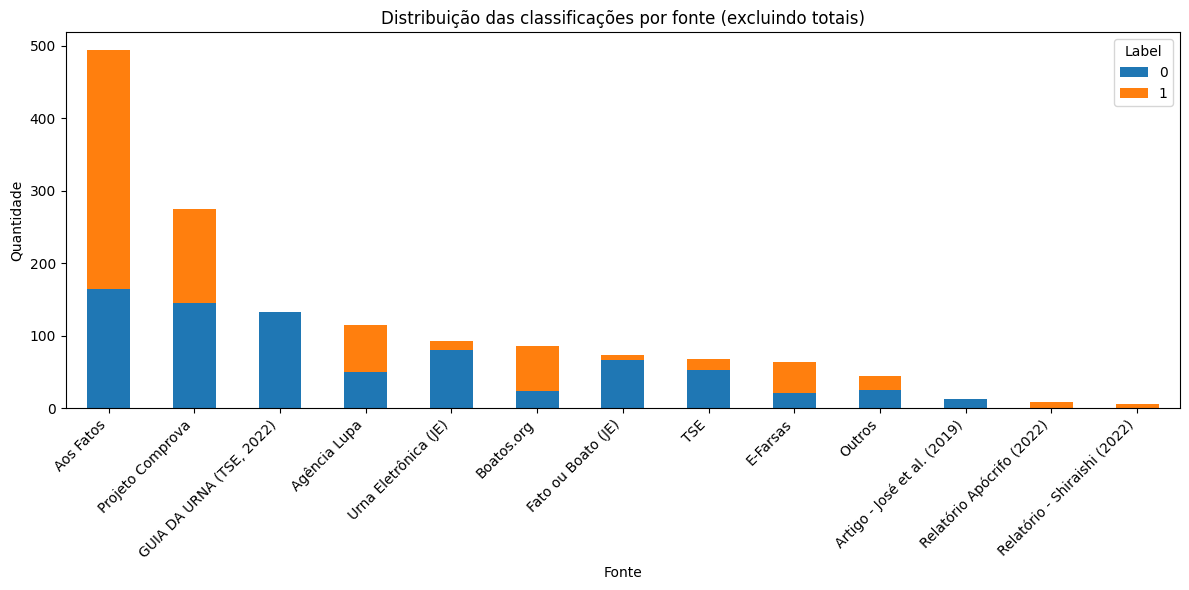

In [ ]:
import matplotlib.pyplot as plt

# Preparar dados
tabela_plot = tabela.drop('Total Geral', errors='ignore').drop(columns='Total', errors='ignore')

# Plotar
ax = tabela_plot.plot(kind='bar', stacked=True, figsize=(12, 6))

# Ajustes estéticos
plt.title('Distribuição das classificações por fonte (excluindo totais)')
plt.xlabel('Fonte')
plt.ylabel('Quantidade')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Label')
plt.tight_layout()
plt.show()

In [ ]:
# Distribuição de labels no fact-checking
dfFact['label'].value_counts()

label
0    774
1    695
Name: count, dtype: int64

In [ ]:
# Carregar dataset de tweets
dfTweets = pd.read_csv('./dataset/TweetsUE2022.csv')
dfTweets["source"] = "https://www.kaggle.com/datasets/lucasranire/tweets-2022-brazilian-presidential-elections"
dfTweets

,text,label,source
0,"""O LULA TÁ ELEITO"" por mais triste que isso se...",0,https://www.kaggle.com/datasets/lucasranire/tw...
1,A diplomação oficializa o resultado das urnas ...,0,https://www.kaggle.com/datasets/lucasranire/tw...
2,Acabo de ver que o PL vai pagar uma multa de 2...,0,https://www.kaggle.com/datasets/lucasranire/tw...
3,"Acreditaram em mamadeira erótica, banheiro uni...",0,https://www.kaggle.com/datasets/lucasranire/tw...
4,Alexander de Moraes foi genial! Até no valor d...,0,https://www.kaggle.com/datasets/lucasranire/tw...
...,...,...,...
3258,"""Lula ladrão"", ""urnas fraudadas"", ""Bolsonaro h...",0,https://www.kaggle.com/datasets/lucasranire/tw...
3259,"E pq quando ""milhões de brasileiros indignados...",0,https://www.kaggle.com/datasets/lucasranire/tw...
3260,DITADORES DISFARÇADOS!!! DEVOLVAM O CACIQUE!!!...,1,https://www.kaggle.com/datasets/lucasranire/tw...
3261,"Sra, esse feitos foram da esquerda!! Esqueceu ...",1,https://www.kaggle.com/datasets/lucasranire/tw...


In [ ]:
# Distribuição de labels nos tweets
dfTweets['label'].value_counts()

label
0    1693
1    1570
Name: count, dtype: int64

In [ ]:
# Concatenar datasets
df = pd.concat([dfFact, dfTweets], axis=0, ignore_index=True)
df

,text,label,source,Fonte
0,A carga das urnas é a inserção de dados como: ...,0,https://bibliotecadigital.tse.jus.br/server/ap...,"GUIA DA URNA (TSE, 2022)"
1,As entidades fiscalizadoras podem acompanhar p...,0,https://bibliotecadigital.tse.jus.br/server/ap...,"GUIA DA URNA (TSE, 2022)"
2,As entidades fiscalizadoras podem acompanhar p...,0,https://bibliotecadigital.tse.jus.br/server/ap...,"GUIA DA URNA (TSE, 2022)"
3,A lista dos resumos (hashes) é publicada no po...,0,https://bibliotecadigital.tse.jus.br/server/ap...,"GUIA DA URNA (TSE, 2022)"
4,o TSE coloca os programas (assinados e lacrado...,0,https://bibliotecadigital.tse.jus.br/server/ap...,"GUIA DA URNA (TSE, 2022)"
...,...,...,...,...
4727,"""Lula ladrão"", ""urnas fraudadas"", ""Bolsonaro h...",0,https://www.kaggle.com/datasets/lucasranire/tw...,NaN
4728,"E pq quando ""milhões de brasileiros indignados...",0,https://www.kaggle.com/datasets/lucasranire/tw...,NaN
4729,DITADORES DISFARÇADOS!!! DEVOLVAM O CACIQUE!!!...,1,https://www.kaggle.com/datasets/lucasranire/tw...,NaN
4730,"Sra, esse feitos foram da esquerda!! Esqueceu ...",1,https://www.kaggle.com/datasets/lucasranire/tw...,NaN


In [ ]:
import csv

df_ordenado = df.sort_values(by=['label', 'source']).reset_index(drop=True)

# Converter colunas específicas
df_ordenado['text'] = df_ordenado['text'].astype(str)
df_ordenado['source'] = df_ordenado['source'].astype(str)

# Para label, converter primeiro para numérico
df_ordenado['label'] = pd.to_numeric(df_ordenado['label'], errors='coerce').astype('Int64')  # Int64 permite NaN

# Manter apenas as colunas desejadas
df_ordenado = df_ordenado[['text', 'label', 'source']]

# Salvar
df_ordenado.to_csv(
    './UEFactsBRc.csv',
    index=False,
    quoting=csv.QUOTE_NONNUMERIC  # Aspas apenas em campos não numéricos
)

print("Arquivo salvo com sucesso!")

Arquivo salvo com sucesso!


In [ ]:
# Verificar distribuição final
df_ordenado['label'].value_counts()

label
0    2467
1    2265
Name: count, dtype: Int64

#### 3.4.2 Fine-tuning

##### 3.4.2.1 Configurações Globais

In [ ]:
EXPERIMENT_BASE = "./experimentos"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
experiment_dir = os.path.join(EXPERIMENT_BASE, f"rodada_{timestamp}")
os.makedirs(experiment_dir, exist_ok=True)

print(f"Resultados serão salvos em: {experiment_dir}")

# Atualizar caminhos
model_path = os.path.join(experiment_dir, "UrnaBERTClassifier")
output_dir = os.path.join(experiment_dir, "UrnaBERT-Classifier")


Resultados serão salvos em: ./experimentos\rodada_20260725_203510


In [ ]:
# Configurações globais do experimento
test= True
balance_ds = False

data_augmentation = True

mask_entities = True

file_path = './UEFactsBR.csv'
# model_path = './UrnaBERTClassifier'

#model_checkpoint = 'neuralmind/bert-base-portuguese-cased'
model_checkpoint = 'neuralmind/bert-large-portuguese-cased'

n_last_blocks= 8
pooler= True


train_batch_size=8
eval_batch_size=8

label_sf=0.01

epochs=2
l_rate=3e-5
w_decay=0.1

In [ ]:

import torch, psutil

if torch.cuda.is_available():
    print(f"GPU alocada: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    mem = psutil.virtual_memory()
    print(f"RAM usada: {mem.used / 1024**3:.2f} GB / {mem.total / 1024**3:.2f} GB ({mem.percent}%)")

GPU alocada: 0.00 MB
RAM usada: 12.91 GB / 15.69 GB (82.3%)


##### 3.4.2.2 Preparação dos Dados e Configuração do Modelo

###### 3.4.2.2.1 Carregar e dividir dataset

In [ ]:
# Carregar dataset
df_rumor_election = pd.read_csv(file_path, sep=',')
df_rumor_election

,text,label,source
0,A carga das urnas é a inserção de dados como: ...,0,https://bibliotecadigital.tse.jus.br/server/ap...
1,As entidades fiscalizadoras podem acompanhar p...,0,https://bibliotecadigital.tse.jus.br/server/ap...
2,As entidades fiscalizadoras podem acompanhar p...,0,https://bibliotecadigital.tse.jus.br/server/ap...
3,A lista dos resumos (hashes) é publicada no po...,0,https://bibliotecadigital.tse.jus.br/server/ap...
4,o TSE coloca os programas (assinados e lacrado...,0,https://bibliotecadigital.tse.jus.br/server/ap...
...,...,...,...
4727,trava que não deixa a soma [do total de votos ...,1,https://www2.ifsc.usp.br/portal-ifsc/wp-conten...
4728,"há, confirmadamente, ao menos dois softwares n...",1,https://www2.ifsc.usp.br/portal-ifsc/wp-conten...
4729,existem diferenças sutis entre os entre os arq...,1,https://www2.ifsc.usp.br/portal-ifsc/wp-conten...
4730,as diferenças observadas em arquivos de log im...,1,https://www2.ifsc.usp.br/portal-ifsc/wp-conten...


In [ ]:
# Exibir informações do dataset
df_rumor_election.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4732 entries, 0 to 4731
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    4732 non-null   object
 1   label   4732 non-null   int64 
 2   source  4732 non-null   object
dtypes: int64(1), object(2)
memory usage: 111.0+ KB


In [ ]:
# Verificar distribuição das classes
df_rumor_election['label'].value_counts()

label
0    2467
1    2265
Name: count, dtype: int64

In [ ]:
# Ver distribuição geral
print(df_rumor_election['label'].value_counts(normalize=True))

label
0    0.521344
1    0.478656
Name: proportion, dtype: float64


In [ ]:
df_rumor_election[df_rumor_election['text'].str.endswith('.')]['label'].value_counts()

label
0    910
1    785
Name: count, dtype: int64

In [ ]:
# Remove o último caractere (ponto final) de todas as linhas cujo texto termina com '.'
df_rumor_election['text'] = df_rumor_election['text'].str.replace(r'\.+$', '', regex=True)

In [ ]:
df_rumor_election[df_rumor_election['text'].str.endswith('.')]['label'].value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
if balance_ds:
    # Verificar a distribuição das classes
    print(df_rumor_election['label'].value_counts())

    # Encontrar o tamanho da menor classe
    min_size = df_rumor_election['label'].value_counts().min()
    print(f"Tamanho da menor classe: {min_size}")

    # Para cada classe, selecionar aleatoriamente 'min_size' amostras
    df_balanced = pd.DataFrame()
    for classe in df_rumor_election['label'].unique():
        df_classe = df_rumor_election[df_rumor_election['label'] == classe]
        # Amostragem aleatória sem reposição (se houver amostras suficientes)
        df_amostra = df_classe.sample(n=min_size, random_state=42)
        df_balanced = pd.concat([df_balanced, df_amostra])

    # embaralhar o dataset final
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

    # Verificar o novo balanceamento
    df_rumor_election = df_balanced
    print(df_rumor_election['label'].value_counts())

In [ ]:
df_rumor_election['label'].value_counts()

label
0    2467
1    2265
Name: count, dtype: int64

In [ ]:
# Dividir dataset
from sklearn.model_selection import train_test_split

if test:
    # treino + resto
    train_df, temp_df = train_test_split(
        df_rumor_election,
        test_size=0.3,
        random_state=42,
        # stratify=df_rumor_election["label"]
    )

    # validação + teste (mantendo o mesmo critério)
    eval_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=42,
        # stratify=temp_df["label"]
    )

    print('Split com teste')
else:
    train_df, eval_df = train_test_split(
        df_rumor_election,
        test_size=0.2,
        random_state=42,
        # stratify=df_rumor_election["label"]
    )

    print('Split sem teste')

Split com teste


In [ ]:
# Verificar distribuição no treino
train_df['label'].value_counts()

label
0    1708
1    1604
Name: count, dtype: int64

In [ ]:
train_df['label'].info()

<class 'pandas.core.series.Series'>
Index: 3312 entries, 58 to 860
Series name: label
Non-Null Count  Dtype
--------------  -----
3312 non-null   int64
dtypes: int64(1)
memory usage: 51.8 KB


In [ ]:
# Verificar distribuição na validação
eval_df['label'].value_counts()

label
0    370
1    340
Name: count, dtype: int64

In [ ]:
if test:
  print('Split com teste')
  # Verificar distribuição no teste
  print(test_df['label'].value_counts())

Split com teste
label
0    389
1    321
Name: count, dtype: int64


###### 3.4.2.2.2 Data augmentation

In [ ]:
if data_augmentation:

# ============================================================
# 3. RUÍDOS TECNOLÓGICOS (software, hardware, segurança, mas sem relação com urnas)
# ============================================================
# Objetivo: Evitar que o modelo confunda tecnologia em geral com urna eletrônica.
#           Termos como "criptografia", "firewall", "código", "atualização" aparecem
#           tanto em discussões sobre urnas eletrônicas quanto em tecnologia cotidiana.
# Falso positivo evitado: "Firewall bloqueou um ping suspeito" → urna eletrônica vulnerável
# Contexto real: atualizações de celular, roteador, smart TV, antivírus, APIs, etc.
# ============================================================

    ruidos_tecnologicos = [
    "A atualização do software do meu celular melhorou a bateria. #TechLife",
    "O código do aplicativo de clima está no GitHub. #OpenSource",
    "A cafeteira inteligente tem um código de erro E4 no visor",
    "O firewall corporativo bloqueou um acesso suspeito. #Segurança",
    "A máquina de lavar louça detectou vazamento e parou o ciclo",
    "O desenvolvedor corrigiu o bug que fechava o programa. #DevLife",
    "A geladeira smart avisa quando a porta fica aberta",
    "O algoritmo de recomendação da loja online aprende meus gostos. #IA",
    "A atualização de segurança do roteador foi instalada automaticamente.",
    "O antivírus removeu um malware baixado por engano",
    "A autenticação em dois fatores protege minhas contas. #2FA",
    "A smart TV atualizou o sistema operativo à noite",
    "O código do robô aspirador permite programar a limpeza. #Robot",
    "A lâmpada inteligente tem um código de conexão Wi-Fi",
    "O software de edição de fotos ganhou um novo filtro. #Photoshop",
    "A base de dados da empresa precisa de manutenção preventiva",
    "O sensor da máquina de lavar detectou excesso de espuma. #Eficiência",
    "A criptografia de arquivos impede a leitura não autorizada. 🔒",
    "O sistema de pagamentos foi integrado com sucesso ao site. #Fintech",
    "O micro-ondas tem um modo de descongelamento programável.",
    "O firewall pessoal bloqueou um ping estranho. #CyberSeg",
    "O algoritmo de compressão reduziu o tamanho do vídeo",
    "A impressora smart notifica quando o toner está baixo.",
    "O sistema de irrigação automática atualizou a programação",
    "O código da fechadura digital permite várias senhas temporárias. #SmartHome",
    "A campainha com câmera tem criptografia de vídeo🔔📹",
    "O software do termostato inteligente aprende minha rotina. #Automação",
    "A atualização do sistema do carro melhorou o consumo",
    "O código de rastreamento dos Correios mostra a localização",
    "O antivírus verificou o pendrive em segundos",
    "A atualização do software do meu aspirador robô falhou. #Falha",
    "O código QR do Wi-Fi da smart TV está na etiqueta. #Conectividade",
    "O firewall do Windows alertou sobre um programa desconhecido",
    "O micro-ondas tem um código de segurança para crianças. #SegurançaDoméstica",
    "A máquina de lavar atualizou o ciclo de enxágue via Wi-Fi",
    "O software de gestão financeira exporta dados em CSV. #Finanças",
    "O algoritmo de busca do site melhorou os resultados. #SEO",
    "A cafeteira inteligente avisa quando o café está pronto",
    "A geladeira smart tem um código de economia de energia. #Eco",
    "O código do carregador sem fio foi atualizado. 🔋",
    "A campainha inteligente tem criptografia de ponta a ponta. #Privacidade",
    "O termostato Wi-Fi pode ser controlado por voz",
    "A máquina de costura digital tem um código de ponto. #DIY",
    "O software da esteira registra a quilometragem. #Fitness",
    "A balança inteligente sincroniza os dados com o app. ⚖️📲",
    "O código do ventilador smart permite programar horários. #HomeAuto",
    "A fechadura de porta de vidro tem código numérico",
    "O sistema de irrigação usou dados de previsão do tempo",
    "A cafeteira tem um código de manutenção para limpeza. #Cuidados",
    "O micro-ondas smart tem um sensor de umidade. #Tech",
    "A lava-louças tem um código de erro de drenagem",
    "O purificador de ar smart exibe a qualidade do ar. #Saúde",
    "O aspirador robô mapeia a casa via software. #Mapeamento",
    "A torradeira inteligente tem perfis de tostagem.",
    "O fogão smart avisa se o forno está pré-aquecido. #CozinhaTech",
    "O exaustor automático liga quando detecta fumaça",
    "A fechadura de maleta tem código de segurança. #Viagem",
    "O software de biometria do notebook é rápido. #Login",
    "A política de senhas exige 12 caracteres. #SegurançaDaInformação",
    "O software de gerenciamento de senhas é seguro",
    "A chave de API foi revogada por segurança. #Dev",
    "O código de verificação em duas etapas salvou a conta. #2FA",
    "O sistema de prevenção a perda de dados alertou. #DLP",
    "A assinatura digital do e-mail é válida",
    "O código hash do arquivo corresponde ao original. #Integridade",
    "A atualização de segurança do Windows foi instalada 🖥️",
    "O firewall bloqueou uma tentativa de port scan. #Rede",
    "O antivírus colocou o arquivo em quarentena",
    "O software de assinatura digital é certificado. #Documentos",
    "O código de verificação do Google Authenticator muda a cada 30s. #TOTP",
    "A proteção contra phishing do navegador foi ativada. #Phishing",
    "O firewall pessoal registrou uma conexão suspeita. 📡",
    "O antivírus identificou um vírus de macro. #MacroVirus",
    "A autenticação por token USB é robusta. #Token 🔑",
    "O código de desbloqueio do computador é PIN. #Login",
    "O sistema de log alerta sobre tentativas de login. #Auditoria",
    "A criptografia do banco de dados é transparente.",
    "O código de acesso à API é rotacionado. #API",
    "A atualização de segurança do servidor foi aplicada. #Server",
    "O firewall de aplicação web bloqueou SQL injection. #WAF",
    "O antivírus em nuvem é leve e eficaz.",
    "A autenticação por reconhecimento de voz é experimental.",
    "O código de ativação do produto foi enviado por e-mail. #Licença",
    "O software de segurança bloqueou um ransomware. #Ransomware",
    "A chave de criptografia é armazenada no HSM. #HardwareSecurity",
    "O sistema de prevenção de intrusão aprende com o tráfego. #IPS",
    "O código de verificação do cartão de crédito é estático",
    "A política de senhas força troca a cada 90 dias. #Cyber",
    "O software de cofre digital guarda documentos",
    "A assinatura digital do contrato é válida legalmente. #AssinaturaDigital",
    "O código de autenticação do aplicativo é numérico. #Auth",
    "A criptografia do Wi-Fi é WPA3. #WiFi",
    "O firewall do Windows é configurável. #Windows",
    "O antivírus gratuito tem boa detecção. #Free",
    "A autenticação por padrão é senha + token. #MFA",
    "O código de segurança do celular é padrão 0000. #Alerta",
    "O firewall de rede doméstica bloqueou um ping da China. #RedeDoméstica",
    "O antivírus detectou um potencial keylogger. #Keylogger",
    "A autenticação por hardware token é cara mas segura. #Token",
    "O código de desbloqueio do dispositivo é padrão 1234. #TroqueJá"
   ]

    print(f"Total de ruídos tecnologicos gerados: {len(ruidos_tecnologicos)}")

# ============================================================
# 1. RUÍDOS SOBRE URNAS FÍSICAS (não eletrônicas)
# ============================================================
# Objetivo: Evitar que o modelo classifique qualquer menção à palavra "urna"
#           como sendo sobre urna eletrônica.
# Falso positivo evitado: "Deposite seu cupom na urna da recepção" → urna eletrônica
# Contexto real: urnas funerárias, de sorteio, de coleta, de votação em condomínio, etc.
# ============================================================

    ruidos_urna = [
    "A urna funerária marajoara é um tesouro da arqueologia brasileira.",
    "Deposite seu cupom de sorteio na urna da recepção.",
    "O sorteio será realizado retirando um papel da urna de acrílico.",
    "A urna com as cinzas do imperador está exposta no museu.",
    "Para participar da promoção, basta colocar o recibo na urna.",
    "A urna de barro encontrada na escavação data do período pré-colonial.",
    "Os arqueólogos identificaram uma urna funerária com pinturas geométricas.",
    "Coloque a nota fiscal na urna de vidro para concorrer a um carro.",
    "A urna de cerâmica foi restaurada pelo laboratório de conservação.",
    "O templo grego guardava uma urna com oferendas aos deuses.",
    "A urna de prata contém as relíquias do santo padroeiro.",
    "Os visitantes podem depositar sugestões na una de feedback do museu.",
    "A urna eleitoral romana era feita de madeira e selada com cera.",
    "No condomínio, há uma urna para coleta de tampinhas de garrafa.",
    "A urna de bronze foi saqueada do túmulo real no século XIX.",
    "Cada funcionário deve colocar o voto secreto na urna da comissão interna.",
    "A urna de porcelana com a assinatura do artista vale uma fortuna.",
    "Os etruscos produziam urnas com tampas esculpidas em forma humana.",
    "A urna de madeira entalhada está no altar-mor da igreja matriz.",
    "O sistema de coleta usa uma urna metálica para lacrar os envelopes.",
    "A urna de osso foi datada por carbono-14 em 800 a.C.",
    "Os organizadores do bingo lacraram a una com os números sorteados.",
    "A una de alabastro pertencia a uma princesa da dinastia ptolomaica.",
    "Para doar brinquedos, use a urna azul localizada no estacionamento.",
    "A urna cinerária romana trazia uma inscrição em latim.",
    "Os competidores colocam seus palpites na una da loteria esportiva.",
    "A urna de chumbo foi encontrada dentro de um sarcófago de pedra.",
    "O pregão eletrônico não tem relação com essa urna de coleta física.",
    "A una de vidro temperado é à prova de violação para sorteios oficiais.",
    "Os artefatos incluem uma una antropomórfica da cultura marajoara.",
    "Cada sócio deposita o comprovante de pagamento na una da tesouraria.",
    "A urna de vidro da portaria recebe os cartões de visita.",
    "O concurso cultural utiliza uma urna lacrada para os votos do público.",
    "A urna funerária etrusca tinha relevos que contavam histórias.",
    "Depois da gincana, os alunos colocaram os comprovantes na urna.",
    "A urna de prata do século XVIII foi leiloada por milhões.",
    "Os fiéis depositam seus pedidos de oração na una do santuário.",
    "A urna de osso decorada foi achada em uma caverna no Pará.",
    "O regulamento diz que todos os cupons devem ir para a una oficial.",
    "A urna de cerâmica vidrada pertenceu a um faraó da 19ª dinastia.",
    "No clube, há uma urna para sugestões de melhorias na piscina.",
    "A urna com as cinzas do poeta está no jardim de esculturas.",
    "Os arqueólogos restauraram uma una antropomórfica com dentes de jade.",
    "A comissão organizadora lacrou a urna de acrílico às 14h.",
    "A urna funerária grega continha uma coroa de louro de ouro.",
    "Os moradores colocam pilhas usadas na urna de coleta seletiva.",
    "A urna de barro cozido apresentava inscrições em escrita cuneiforme.",
    "Para o amigo secreto, todos os nomes vão para uma una de papelão.",
    "A urna de mármore foi esculpida por um artista renascentista.",
    "A exposição do museu inclui uma una cinerária romana intacta.",
    "Os funcionários depositaram o vale-transporte na urna do RH.",
    "A urna de madeira de lei foi encontrada em um naufrágio do século XVI.",
    "O sorteio da rifa será com uma una giratória transparente.",
    "A urna funerária maia tinha tampa em forma de cabeça de deus.",
    "Os associados colocam as cédulas de voto na urna metálica trancada.",
    "A una de porcelana chinesa foi restaurada com laca dourada.",
    "A igreja mantém uma urna para doação de alimentos não perecíveis.",
    "A urna de chumbo com inscrições malditas foi selada novamente.",
    "Os participantes do concurso de redação usam a una do pátio central.",
    "A urna de bronze com figuras mitológicas está no museu arqueológico.",
    "O condomínio instalou uma urna para coleta de tampas de garrafa pet.",
    "Acabei de ver uma urna funerária indígena no museu. Coisa linda! 😍 #Arqueologia #Marajoara",
    "Alguém aí já depositou voto em urna de vidro da portaria? O síndico que inventou isso…",
    "Minha avó guardava as cinzas do meu avô numa urna de porcelana azul. 🕊️",
    "Bora lá, galera! Tô participando do sorteio da loja. Já coloquei 3 cupons na urna. 🎫📦",
    "O templo grego tinha uma urna com oferendas pros deuses. Imagina se a gente acha isso hoje? 🏺",
    "Depois do enterro, a urna com as cinzas ficou no columbário. Muita paz ali. 🙏",
    "PQ o condomínio colocou uma urna pra coletar pilha? Alguém recicla isso mesmo? #Dúvida",
    "Urna de chumbo com inscrição maldita? Parede de filme de terror kkkk #ArqueologiaMeme",
    "Fui votar no clube – na urna de papelão pro amigo secreto. Tirei o João. 😂",
    "Que absurdo! A urna de bronze do museu foi furtada na madrugada. 😡 #PatrimônioPerdido",
    "Alguém sabe me dizer se a urna da recepção é pra currículo ou pra sugestão? 🤔",
    "Mano, os arqueólogos acharam uma urna com dentes de jade. Isso é loucura. 🦷💚",
    "Partiu depositar o comprovante na urna da tesouraria. ODEIO fila. 😤 #Burocracia",
    "Eu: 'Cadê a urna?' Atendente: 'A de votar ou a de coleta de tampinha?' 🤡",
    "Hoje lacraram a urna do bingo. Torcendo pra ganhar a cesta de natal! 🎄🎲",
    "A urna de barro que eu achei na escavação tem 3 mil anos. Me sinto o Indiana Jones. 🧭",
    "Gente, como assim tem urna de prata com relíquia de santo? Igreja guarda cada coisa… ⛪",
    "Fiscais do concurso, por favor, cuidem da una (sim, escreveram errado) de vidro. #ProvaDePortuguês",
    "O que vocês colocariam numa urna do tempo pra ser aberta em 2124? Eu: um meme. 🕰️📦",
    "Meu tio achou que era urna de votação eletrônica, mas era só a urna de sugestões da biblioteca. 😅",
    "Essa urna funerária etrusca tem relevo de uma festa. Até na morte os caras queriam festa. 🎉💀",
    "Alô, administração: a urna de feedback tá cheia de bituca de cigarro. Respeito, pô. 🚬❌",
    "#Sextou com cultura: fui ver a exposição de urnas marajoaras. Detalhes impressionantes.",
    "Aviso: quem não colocar o voto na urna lacrada até às 17h perde o direito. ⏰🗳️",
    "Tô olhando pra uma urna de osso decorado. É macabro ou é arte? Os dois. 🦴🎨",
    "Meu avô disse que na Roma antiga a urna eleitoral era selada com cera. Mais confiável que muito sistema atual? 😂",
    "A urna de vidro da portaria quebrou com o calor. Os cupons voaram tudo. Que caos. 🌪️📄",
    "#CurtiçãoDeArqueólogo: acabei de restaurar uma urna de cerâmica com pintura geométrica.",
    "Será que a urna de madeira entalhada na igreja matriz é do século XVII? Vou perguntar pro padre.",
    "Hoje tem sorteio da rifa! A urna giratória transparente é muito bonita. 🎡🎟️",
    "Atenção condôminos: a urna azul é pra brinquedo, a verde é pra pilha. Não confundam! ♻️🧸",
    "Tô assistindo um documentário sobre urnas cinerárias romanas. Muito mais legal do que novela.",
    "O que essa urna de chumbo fazia dentro de um sarcófago? Mistério. 🕵️‍♂️",
    "Colei meu adesivo na urna de acrílico do concurso. Agora é torcer. 🤞 #SorteioCultural",
    "#ArqueologiaBR – a urna antropomórfica da cultura tapajônica tem olhos de concha. Inacreditável.",
    "No Japão, as urnas funerárias são minimalistas. Já no Brasil, a gente faz umas de barro gigantes. 🇯🇵🇧🇷",
    "Gente, a urna de porcelana chinesa da exposição tem mais de 500 anos. Que privilégio ver isso de perto. 🏺🇨🇳",
    "O síndico mandou lacrar a urna das assembleias. 'Pra evitar fraude'. Tá bom, né… 🤨",
    "Eu achando que era urna de votação de verdade… Era uma urna de coleta de tampinhas de PET. Tô indo embora. 🫠",
    "Último dia pra depositar sua redação na urna do pátio central. Correi! 🏃‍♀️📝"
    ]

    print(f"Total de ruídos sobre a urnas gerados: {len(ruidos_urna)}")

# ============================================================
# 2. RUÍDOS ALEATÓRIOS (assuntos diversos sem relação com tecnologia ou votação)
# ============================================================
# Objetivo: Ensinar o modelo a não associar palavras genéricas ("voto", "sistema",
#           "fraude", "segurança") automaticamente ao tema das urnas eletrônicas.
# Falso positivo evitado: "Meu voto de confiança no novo técnico" → desinformação eleitoral
# Contexto real: comida, esportes, clima, família, entretenimento, etc.
# ============================================================

    ruidos_aleatorios  = [
    "Acordei com dor nas costas, dormi errado de novo.",
    "Hoje tem promoção de sorvete na esquina. Vou sem falta",
    "Alguém já assistiu à nova série da Apple TV? Vale a pena?",
    "Meu cachorro não para de latir para o vento. #Paciência",
    "Paguei o IPVA atrasado. Adeus, décimo terceiro 💸",
    "Fui correr no parque e encontrei um amigo que não via há anos.",
    "Essa atualização do Instagram deixou tudo pior",
    "Bolo de laranja com calda de chocolate é meu ponto fraco.",
    "Por que toda novela das seis tem uma mocinha sofrida?",
    "Minha avó ensinou a reutilizar vidro de pepino. Economia criativa.",
    "Qual streaming vai passar o próximo show da Anitta?",
    "Fazer jejum intermitente é fácil até dar 11h da manhã.",
    "Meu chefe pediu relatório às 18h de sexta. Inacreditável.",
    "O Brasil tem cachoeiras lindas que pouca gente conhece.",
    "Tentei comprar ingresso para o show do Coldplay e o site travou😭",
    "Cuidar de suculenta é quase impossível se você regar demais.",
    "Ansioso por 2026, esse ano foi pesado.",
    "Ventilador no talo é a única solução no verão.",
    "Meu vizinho decidiu fazer festa na quarta-feira👎",
    "Zerei Red Dead Redemption 2 depois de meses. Obra-prima.",
    "Café com leite e pão na chapa é café da manhã raiz ☕",
    "Propaganda de cerveja sempre tem um cachorro engraçado.",
    "O preço do tomate subiu muito, vou plantar no vaso.",
    "Quem não gosta de doce de leite não confio.",
    "Praia em feriado é só estresse e areia no olho.",
    "Assisti àquele filme da Barbie e gostei mais do que esperava",
    "Minha internet caiu no meio do jogo online.",
    "Dia de faxina: colocar podcast e fingir que é prazeroso",
    "Saudades do saudoso Orkut. As comunidades eram ótimas.",
    "Comer hambúrguer artesanal no domingo é terapia.",
    "Meu time empatou em casa. Mais um jogo sem vitória",
    "Tentei meditar e o barulho da rua atrapalhou.",
    "Fila do supermercado está quilométrica. Paciência.",
    "Macarrão com molho branco e brócolis é jantar rápido.",
    "Essa trend de dançar no escritório não pega pra mim.",
    "Homem que não para para perguntar o endereço é teimoso.",
    "Minha sogra disse que meu bolo estava 'fofo'. Bom sinal?",
    "Voltei à academia e já estou arrependido 😅😅",
    "Ainda existe gente que joga lixo na rua? Absurdo.",
    "Dia nublado é desculpa perfeita para série e coberta.",
    "Comprei um fone Bluetooth e ele descarrega rápido demais.",
    "Notebook básico não roda nada além do Excel.",
    "Trânsito na saída do feriado é infernal 🚗🚗",
    "Minha mãe manda foto da comida pelo WhatsApp. Amo.",
    "Plantei manjericão na janela, deu certo.",
    "Cortar cebola sem chorar é lenda urbana",
    "Rodízio de massas é meu esporte favorito.",
    "Meu sobrinho pediu um desenho de unicórnio. Saquei",
    "Beber água gelada salva vidas no calor.",
    "Ganhei uma caixa de morangos na feira. Sorvete caseiro?",
    "Reality show de culinária sempre tem briga na cozinha.",
    "Meu cachorro late para o próprio reflexo no espelho.",
    "Tentei trocar a resistência do chuveiro e tomei choque 😵",
    "Calça mom jeans é confortável, mas não combina com tudo.",
    "No Rio de Janeiro, guarda-chuva é inútil, vento quebra.",
    "Esperança para 2025? Tô tentando.",
    "Arrependimentos da vida são mais que areia na praia.",
    "Meu avô fala com as plantas e a horta é invejável.",
    "Abri a geladeira cinco vezes, nada novo apareceu.",
    "Leite quente com Nescau e pão doce é nostalgia pura.",
    "Webcam de notebook parece que filma no escuro 📸",
    "Vou aprender a tocar teclado no YouTube. Missão possível?",
    "Meu primo só joga jogos de celular. Coitado.",
    "Pão de queijo quentinho é perfeito com café.",
    "A lua estava linda hoje. Alguém viu?",
    "Reunião 'rápida' de 2 horas. Já me acostumei.",
    "Estou lendo um livro de 400 páginas, na metade.",
    "Formigas invadem quando chove. Lei da natureza.",
    "Airfryer fez batata frita perfeita hoje",
    "Achei 5 reais no bolso do casaco. Lucro.",
    "Meu namorado ronca baixo, mas constante.",
    "Dieta low carb é difícil, mas funciona.",
    "No ônibus sempre tem alguém vendo vídeo sem fone.",
    "Cortei o cabelo sozinho. Erro fatal",
    "Sobremesa sempre cabe, é fato científico.",
    "Meu pai tem um carro híbrido, economiza gasolina.",
    "Assisti Soul e refleti sobre a vida",
    "Tentei fazer pão integral e ficou parecendo tijolo.",
    "Ver lives de gente jogando é estranho, mas viciante.",
    "Domingo à tarde: soneca ou filme? Dilema.",
    "Meu vizinho tem um periquito que fala palavrão.",
    "Plano de streaming com anúncio é tortura psicológica.",
    "Tentei fazer dobradura de coração, virou chapéu.",
    "Netflix lança série boa e cancela. Ciclo vicioso.",
    "Meu gato dorme dentro da caixa de papelão📦",
    "Fui num show de samba e dancei muito.",
    "Despertador do celular é confiável, mas eu snooze.",
    "Suco de limão com hortelã é refrescante.",
    "Meu irmão acredita em signo. Cada um.",
    "Cadeira de escritório comum dói as costas.",
    "Palavras como 'mindset' infestam o LinkedIn.",
    "Escova de dente elétrica vale o investimento.",
    "Documentário sobre abelhas é fascinante",
    "Celular caiu e trincou a tela. Triste.",
    "Esqueci o protetor solar e queimei",
    "Desembolar fone é teste de paciência.",
    "Minha sogra usa filtro de rosto no WhatsApp.",
    "Troquei o açúcar pelo adoçante no café. Erro.",
    "Casais felizes no Instagram brigam por motivo bobo.",
    "Meu sobrinho de 4 anos sabe desbloquear meu celular."

    ]


    # Ruídos (classe 0) – tudo que NÃO é desinformação sobre urna eletrônica
    # ------------------------------------------------------------------
    # 1. Urnas físicas: evitam falso positivo pela palavra "urna"
    # 2. Assuntos aleatórios: evitam falso positivo por palavras genéricas
    # 3. Tecnologia geral: evitam falso positivo por jargão técnico

    print(f"Total de ruídos aleatórios gerados: {len(ruidos_aleatorios )}")




    ruidos = ruidos_tecnologicos + ruidos_urna + ruidos_aleatorios
    print(f"Total de ruídos gerados: {len(ruidos)}")

    df_ruidos= pd.DataFrame({'text': ruidos, 'label': [0]*len(ruidos)})

Total de ruídos tecnologicos gerados: 100
Total de ruídos sobre a urnas gerados: 101
Total de ruídos aleatórios gerados: 100
Total de ruídos gerados: 301


In [ ]:
import pandas as pd

# ============================================================
# NOVOS HARD NEGATIVES SINTÉTICOS (classe 0)
# Baseados nos padrões de erro do stress test
# ============================================================

synthetic_hard_negatives = [
    # Padrão: NEGAÇÃO (ex: "ninguém conseguiu fraudar a urna")
    "nunca houve comprovação de adulteração na urna eletrônica",
    "não existe registro de invasão ao sistema eleitoral",
    "nenhum perito independente encontrou indícios de fraude",
    "jamais se provou que a urna pode ser hackeada",
    "não há um único caso confirmado de manipulação de votos",

    # Padrão: INSINUAÇÃO VAGA (ex: "tem coisa errada com essas urnas")
    "não sei, algo parece estranho nessas máquinas de votar",
    "muita gente desconfia da lisura do processo",
    "parece que há algo esquisito na apuração dos votos",
    "sinto que falta transparência no sistema eletrônico",
    "não me passa segurança essa urna digital",

    # Padrão: IRONIA (ex: "sim, com certeza tem um hacker escondido dentro de cada urna né")
    "ah, claro, tem um chip chinês escondido dentro da urna, confia",
    "com certeza o fantasma da urna muda os votos à meia-noite",
    "é, todos os fiscais são cegos e ninguém viu a fraude, aham",
    "órbvio, a urna tem um botão secreto que troca o voto pra quem o TSE quiser",
    "boa, o vírus vai entrar pela tela de LCD, faz todo sentido",

    # Padrão: NOTÍCIA FACTUAL SOBRE FALHAS TÉCNICAS (ex: "TSE informa que algumas urnas apresentaram falhas técnicas")
    "Tribunal Superior Eleitoral confirma instabilidade pontual em lotes de urnas",
    "Defeito em fonte de alimentação afeta 0,1% das urnas em três estados",
    "Técnicos realizam manutenção corretiva em urnas com problema de leitura biométrica",
    "Justiça Eleitoral substitui equipamentos com falha no display em 15 zonas",
    "Relatório interno aponta necessidade de recalibração em urnas do modelo 2020",

    # Padrão: OPINIÃO LEGÍTIMA (ex: "prefiro voto impresso")
    "na minha opinião, o voto impresso traria mais confiança",
    "eu me sentiria mais seguro se houvesse um comprovante físico",
    "acho que deveria ter um papel de verificação, mesmo que opcional",
    "pra mim, a transparência aumentaria com um segundo método de auditoria",
    "sou favorável ao voto impresso para dar mais credibilidade ao processo",

    # Padrão: RELATO DE PROBLEMA OPERACIONAL (ex: "a votação foi lenta na minha zona eleitoral")
    "na minha seção, a urna demorou quase um minuto pra liberar o voto",
    "o mesário teve que reinicar a urna duas vezes aqui no meu local",
    "fiquei 40 minutos na fila porque algumas urnas estavam com lentidão",
    "relatam que em várias cidades o equipamento travou durante a votação",
    "aqui no bairro, três urnas foram substituídas devido a erro de inicialização",

    # Padrão: CITAÇÃO DE BOATO (ex: "comentaram que poderia ter fraude")
    "tem gente comentando que houve manipulação em algumas seções",
    "ouvi dizer que um fiscal teria flagrado inconsistência",
    "circula uma mensagem no zap sobre suposta adulteração",
    "alguns perfis estão insinuando que os números não batem",
    "se espalhou a informação de que as urnas teriam sido violadas",
]

# Criar DataFrame
df_synthetic_hard_negatives = pd.DataFrame({
    'text': synthetic_hard_negatives,
    'label': 0
})

# Ver resultado
print(f"✅ {len(df_synthetic_hard_negatives)} novos hard negatives sintéticos gerados.")
print(df_synthetic_hard_negatives.head(10))

✅ 35 novos hard negatives sintéticos gerados.
                                                text  label
0  nunca houve comprovação de adulteração na urna...      0
1  não existe registro de invasão ao sistema elei...      0
2  nenhum perito independente encontrou indícios ...      0
3      jamais se provou que a urna pode ser hackeada      0
4  não há um único caso confirmado de manipulação...      0
5  não sei, algo parece estranho nessas máquinas ...      0
6        muita gente desconfia da lisura do processo      0
7  parece que há algo esquisito na apuração dos v...      0
8  sinto que falta transparência no sistema eletr...      0
9           não me passa segurança essa urna digital      0


In [ ]:
import random
import pandas as pd


fake_news_list = [

    # ---------------------------------
    # FRAUDE DIRETA
    # ---------------------------------

    "A urna eletrônica tem um código secreto para desviar votos",
    "O software da urna foi programado para mudar votos do candidato A para o B",
    "Mais de 10 milhões de votos foram fraudados na última eleição",
    "A urna foi programada para favorecer um partido político",
    "O TSE manipulou a totalização dos votos",
    "A urna muda votos automaticamente sem o eleitor perceber",
    "A urna ignora votos para candidatos da oposição",
    "A urna transfere votos nulos para determinados candidatos",

    # ---------------------------------
    # HACKERS / INVASÃO
    # ---------------------------------

    "Hackers invadiram o TSE e alteraram o resultado das eleições",
    "As urnas são conectadas à internet e podem ser hackeadas remotamente",
    "Hackers estrangeiros controlam o sistema eleitoral brasileiro",
    "A Venezuela invadiu o sistema eleitoral brasileiro",
    "A China consegue acessar os votos brasileiros",
    "As urnas transmitem votos por satélite",
    "Existe um chip escondido dentro da urna eletrônica",

    # ---------------------------------
    # CÓDIGO-FONTE / BACKDOOR
    # ---------------------------------

    "O código-fonte da urna nunca foi mostrado para ninguém",
    "O TSE escondeu um backdoor no sistema de totalização",
    "O software da urna possui funções secretas",
    "O código da urna tem uma função para alterar votos",
    "Os técnicos do TSE conseguem mudar votos manualmente",
    "Existe uma senha mestra da urna eletrônica",

    # ---------------------------------
    # AUDITORIA / TRANSPARÊNCIA
    # ---------------------------------

    "Não existe auditoria independente das urnas",
    "Os partidos não podem auditar a urna eletrônica",
    "A urna não permite recontagem dos votos",
    "O voto impresso foi proibido para esconder fraudes",
    "A zerésima já sai preenchida com votos escondidos",
    "A Justiça Eleitoral apaga os logs após a eleição",

    # ---------------------------------
    # TOTALIZAÇÃO
    # ---------------------------------

    "A fraude acontece durante a totalização dos votos",
    "Os votos são alterados no caminho até Brasília",
    "O sistema central do TSE modifica os resultados",
    "O resultado divulgado pelo TSE é diferente do registrado na urna",
    "O aplicativo do TSE mostra números falsos",

    # ---------------------------------
    # MILITARES / FORÇAS ARMADAS
    # ---------------------------------

    "Os militares encontraram provas de fraude nas urnas",
    "O Exército descobriu vulnerabilidades escondidas pelo TSE",
    "As Forças Armadas provaram que houve manipulação",
    "Os militares foram impedidos de auditar as urnas",

    # ---------------------------------
    # NARRATIVAS POLÍTICAS
    # ---------------------------------

    "Bolsonaro venceu no primeiro turno mas roubaram votos",
    "A eleição foi roubada para favorecer Lula",
    "O sistema eleitoral foi comprado pela esquerda",
    "O STF controla o resultado das eleições",
    "O TSE trabalha para um partido político",
    "A eleição foi decidida antes da votação",

    # ---------------------------------
    # TEORIAS SEMI-TÉCNICAS
    # ---------------------------------

    "Os votos ficam armazenados em um pendrive manipulável",
    "O cartão de memória da urna pode ser trocado facilmente",
    "As urnas antigas não são auditáveis",
    "A biometria da urna permite identificar o voto",
    "A urna registra a ordem dos votos e quebra o sigilo",

    # ---------------------------------
    # DESINFORMAÇÃO COMUM DE REDES
    # ---------------------------------

    "Encontraram urnas com votos já preenchidos",
    "Vídeos mostram urnas mudando votos sozinhas",
    "Existem urnas que já chegam prontas para fraude",
    "As urnas foram fabricadas por empresas ligadas ao governo",
    "Especialistas internacionais denunciaram fraude nas urnas brasileiras",

    # ---------------------------------
    # DISCURSO MAIS REALISTA DE TWITTER
    # ---------------------------------

    "Não confio nessa urna eletrônica",
    "Essa urna aí tá estranha",
    "Confia na urna kkkkk",
    "Só acredita na urna quem é inocente",
    "A urna só funciona quando é pro lado deles",
    "Tem caroço nesse angu da urna eletrônica",
    "A conta não fecha nessa eleição",
    "Essa eleição tá muito esquisita",
]

# -----------------------------
# TEMPLATES
# -----------------------------

NEGATION_TEMPLATES = [
    "Não há evidências de que {}",
    "Foi desmentido que {}",
    "É falso afirmar que {}",
    "Não existe prova de que {}",
    "Nunca comprovaram que {}",
    "Não é verdade que {}",
]

REPORTED_SPEECH_TEMPLATES = [
    "Tem gente dizendo que {}",
    "Circula nas redes que {}",
    "Há quem acredite que {}",
    "Alguns perfis afirmam que {}",
    "Segundo boatos, {}",
]

CRITICISM_TEMPLATES = [
    "É absurdo acreditar que {}",
    "Teoria conspiratória diz que {}",
    "Não faz sentido afirmar que {}",
    "Só acredita nisso quem acha que {}",
    "Espalhar que {} é desinformação",
]

IRONY_TEMPLATES = [
    "kkkk agora dizem que {}",
    "aham, claro que {} 😂",
    "confia kkkkk {}",
    "engraçado como falam que {}",
    "do nada inventaram que {} 🤡",
]

COUNTER_ARGUMENT_TEMPLATES = [
    "Se isso fosse verdade, Bolsonaro não teria sido eleito pela urna eletrônica",
    "Se a urna fosse fraudada, nenhuma eleição anterior teria valido",
    "Bolsonaro venceu em 2018 usando a mesma urna que critica",
    "Até hoje ninguém provou fraude real nas urnas",
]

NOISE_PATTERNS = [
    lambda x: x,
    # lambda x: x.upper(),
    lambda x: x + " 😂",
    lambda x: x + " kkkkk",
    lambda x: x.replace("não", "nao"),
    lambda x: x.replace("eletrônica", "eletronica"),
]

# -----------------------------
# FUNÇÕES
# -----------------------------

def apply_noise(text):
    return random.choice(NOISE_PATTERNS)(text)

def generate_variations(text):

    text = text.lower().strip()

    samples = []

    # Negação explícita
    for t in NEGATION_TEMPLATES:
        samples.append(t.format(text))

    # Discurso reportado
    for t in REPORTED_SPEECH_TEMPLATES:
        samples.append(t.format(text))

    # Crítica
    for t in CRITICISM_TEMPLATES:
        samples.append(t.format(text))

    # Ironia
    for t in IRONY_TEMPLATES:
        samples.append(t.format(text))

    # contraposição
    samples.extend(COUNTER_ARGUMENT_TEMPLATES)

    return samples

# -----------------------------
# DATASET FINAL
# -----------------------------

def generate_hard_negative_dataset(fake_news_list):

    data = []

    for fake_text in fake_news_list:

        augmented = generate_variations(fake_text)

        for text in augmented:

            text = apply_noise(text)

            data.append({
                "text": text,
                "label": 0
            })

    return pd.DataFrame(data)

# -----------------------------
# EXECUÇÃO
# -----------------------------

df_hard_negative = generate_hard_negative_dataset(fake_news_list)

print(f"\nTotal exemplos gerados: {len(df_hard_negative)}")


Total exemplos gerados: 1500


In [ ]:
import random
import unicodedata

# ------------------------------------------------------------
# Funções de augmentation
# ------------------------------------------------------------

def random_case_tweet(text):
    """Retorna o texto em maiúsculas ou minúsculas aleatoriamente.
       Se o texto já estiver em uma das formas, tenta a outra."""
    # Embaralha a ordem das conversões
    converters = [str.upper, str.lower]
    random.shuffle(converters)
    for conv in converters:
        converted = conv(text)
        if converted != text:  # só retorna se houve mudança
            return converted
    return text  # se ambas não mudaram (ex: texto sem letras)

def random_case(text, p=0.2):
    """Muda cada caractere para maiúscula com probabilidade p."""
    return ''.join(c.upper() if random.random() < p else c.lower() for c in text)

def random_word_case(text, p=0.1):
    """Coloca palavras inteiras em maiúscula com prob p."""
    words = text.split()
    new_words = [w.upper() if random.random() < p else w for w in words]
    return ' '.join(new_words)

def remove_accents(text):
    """Remove acentos de caracteres, mantendo letras base e demais símbolos."""
    # Normaliza para forma NFD (decomposição canônica)
    nfkd = unicodedata.normalize('NFKD', text)
    # Filtra apenas os caracteres que não são marcas diacríticas (categoria Mn)
    without_accents = ''.join(ch for ch in nfkd if not unicodedata.combining(ch))
    return without_accents

def remove_punctuation(text):
    return re.sub(r'[!.]', '', text)

def leet_augment(text, p=0.3):
    """
    Substitui aleatoriamente algumas letras por caracteres especiais/números (leet).
    """
    # Mapeamento de letras (minúsculas e maiúsculas) para alternativas
    leet_map = {
        'a': ['@', '4'],
        'e': ['3', '€'],
        'i': ['1', '!'],
        'o': ['0', 'Ø'],
        's': ['$'],
        't': ['7'],
        'c': ['¢']

    }

    result = []
    for ch in text:
        lower_ch = ch.lower()
        if lower_ch in leet_map and random.random() < p:
            # Escolhe uma substituição aleatória
            sub = random.choice(leet_map[lower_ch])
            result.append(sub)
        else:
            result.append(ch)
    return ''.join(result)

def punctuation_augment(text):
    """Apenas aumenta repetição de exclamações/interrogações, sem trocar tipo."""
    # Repetir ou reduzir exclamações
    if '!' in text:
        if random.random() < 0.5:
            text = re.sub(r'!+', lambda m: '!' * min(3, len(m.group(0)) + 1), text)
        else:
            text = re.sub(r'!+', '!', text)
    if '?' in text:
        if random.random() < 0.5:
            text = re.sub(r'\?+', lambda m: '?' * min(3, len(m.group(0)) + 1), text)
        else:
            text = re.sub(r'\?+', '?', text)
    return text

# Mapeamento de teclas vizinhas (ABNT2 simplificado)
KEYBOARD_NEIGHBORS = {
    'a': ['s', 'q', 'z', 'w'], 'b': ['v', 'g', 'h', 'n'], 'c': ['x', 'd', 'f', 'v'],
    'd': ['s', 'f', 'e', 'c', 'x'], 'e': ['w', 'r', 'd', 's'], 'f': ['d', 'g', 'r', 'v', 'c'],
    'g': ['f', 'h', 't', 'b', 'v'], 'h': ['g', 'j', 'y', 'n', 'b'], 'i': ['u', 'o', 'k', 'j'],
    'j': ['h', 'k', 'u', 'm', 'n'], 'k': ['j', 'l', 'i', 'm'], 'l': ['k', 'ç', 'o', 'p'],
    'm': ['n', 'j', 'k'], 'n': ['b', 'h', 'm', 'j'], 'o': ['i', 'p', 'l', 'k'],
    'p': ['o', '[', 'ç', 'l'], 'q': ['w', 'a', 's'], 'r': ['e', 't', 'f', 'd'],
    's': ['a', 'd', 'w', 'x', 'z'], 't': ['r', 'y', 'g', 'f'], 'u': ['y', 'i', 'j', 'h'],
    'v': ['c', 'b', 'f', 'g'], 'w': ['q', 'e', 's', 'a'], 'x': ['z', 'c', 's', 'd'],
    'y': ['t', 'u', 'h', 'j'], 'z': ['x', 's', 'a'], 'ç': ['l', 'p', '[', ']']
}

def typo_substitution(word, p=0.05):
    if len(word) < 2 or random.random() > p:
        return word
    idx = random.randint(0, len(word)-1)
    char = word[idx].lower()
    if char in KEYBOARD_NEIGHBORS and KEYBOARD_NEIGHBORS[char]:
        new_char = random.choice(KEYBOARD_NEIGHBORS[char])
        if word[idx].isupper():
            new_char = new_char.upper()
        return word[:idx] + new_char + word[idx+1:]
    return word

def typo_omission(word, p=0.02):
    if len(word) <= 2 or random.random() > p:
        return word
    idx = random.randint(0, len(word)-1)
    return word[:idx] + word[idx+1:]

def typo_repetition(word, p=0.02):
    if len(word) < 2 or random.random() > p:
        return word
    idx = random.randint(0, len(word)-1)
    return word[:idx] + word[idx] + word[idx:]

def typo_swap(word, p=0.02):
    if len(word) < 3 or random.random() > p:
        return word
    idx = random.randint(0, len(word)-2)
    return word[:idx] + word[idx+1] + word[idx] + word[idx+2:]

def apply_typos(text, p_per_word=0.03):
    words = text.split()
    new_words = []
    for w in words:
        #Evita nomes próprios e palavras-chave
        if w.lower() in ['bolsonaro', 'lula', 'urna', 'voto', 'eleição']:
            new_words.append(w)
            continue
        w2 = typo_substitution(w, p_per_word)
        w2 = typo_omission(w2, p_per_word * 0.5)
        w2 = typo_repetition(w2, p_per_word * 0.5)
        w2 = typo_swap(w2, p_per_word * 0.3)
        new_words.append(w2)
    return ' '.join(new_words)


In [ ]:
# Aplicar um subconjunto aleatório de augmentações ao tweet
def transform_tweet(tweet, probs=None, max_attempts=5):
    """
    Aplica um subconjunto aleatório de augmentações ao tweet.

    A função tenta gerar uma versão modificada do texto.
    Caso nenhuma transformação altere o tweet, novas tentativas
    são realizadas até atingir max_attempts.
    """

    # Probabilidades padrão de seleção de cada augmentação
    if probs is None:
        probs = {
            'random_case_tweet': 0.8, #0.6
            'random_case': 0.3,
            'random_word_case': 0.3,
            'remove_accents': 0.4,
            'remove_punctuation': 0.4,
            'punctuation_augment': 0.5,
            'apply_typos': 0.5,
            'leet_augment': 0.2
        }

    # Lista de augmentações disponíveis
    augmentations = [
        ('random_case_tweet', lambda t: random_case_tweet(t)),
        ('random_case', lambda t: random_case(t, p=0.1)),
        ('random_word_case', lambda t: random_word_case(t, p=0.1)),
        ('remove_punctuation', remove_punctuation),
        ('punctuation_augment', punctuation_augment),
        ('apply_typos', lambda t: apply_typos(t, p_per_word=0.03)),
        ('remove_accents', remove_accents),
        ('leet_augment', lambda t: leet_augment(t, p=0.3))
    ]

    # Realiza várias tentativas para garantir alguma modificação
    for _ in range(max_attempts):

        # Seleciona aleatoriamente quais augmentações serão aplicadas
        selected = [
            func
            for name, func in augmentations
            if random.random() < probs.get(name, 0.5)
        ]

        # Se nenhuma augmentação foi escolhida,
        # força a seleção de uma augmentação aleatória
        if not selected:
            selected = [random.choice(augmentations)[1]]

        # Embaralha a ordem para aumentar a variabilidade
        random.shuffle(selected)

        # Texto que será transformado
        result = tweet

        # Aplica todas as augmentações selecionadas
        # de forma sequencial
        for aug_func in selected:
            result = aug_func(result)

        # Se houve alguma alteração no texto,
        # retorna imediatamente o resultado
        if result != tweet:
            return result

    # Caso todas as tentativas falhem,
    # retorna o último resultado gerado
    return result

In [ ]:
transform_tweet('fraude na urna! roubaram meu voto!')

'fraude na urna!! roubaram meu voto!!'

In [ ]:
def transform_dataset(df, text_col='text', label_col='label', num_copies=2, fraction=0.5, seed=None):
    """
    Aplica transformação apenas a uma fração aleatória das linhas.
    """
    if seed is not None:
        random.seed(seed)

    augmented_rows = []

    # Seleciona aleatoriamente quais índices serão transformados
    indices = df.index.tolist()
    num_to_augment = int(len(indices) * fraction)
    indices_to_augment = set(random.sample(indices, num_to_augment))

    for idx, row in df.iterrows():
        original_text = row[text_col]
        label = row[label_col]

        # Sempre adiciona a linha original
        augmented_rows.append({text_col: original_text, label_col: label})

        # Se este índice foi sorteado, gera cópias transformados
        if idx in indices_to_augment:
            for _ in range(num_copies):
                aug_text = transform_tweet(original_text)
                augmented_rows.append({text_col: aug_text, label_col: label})

    return pd.DataFrame(augmented_rows)

In [ ]:
from sklearn.utils import resample

def transform_per_label(df, text_col, label_col, config_by_label):
    """
    config_by_label: dicionário {label: {'fraction': float, 'num_copies': int, 'seed': int, ...}}
    """
    transformed_dfs = []
    for label, cfg in config_by_label.items():
        df_label = df[df[label_col] == label]
        if len(df_label) == 0:
            continue
        df_transformed = transform_dataset(
            df_label,
            text_col=text_col,
            label_col=label_col,
            num_copies=cfg.get('num_copies', 3),
            fraction=cfg.get('fraction', 0.2),
            seed=cfg.get('seed', 42)
        )
        transformed_dfs.append(df_transformed)
    return pd.concat(transformed_dfs, ignore_index=True)

In [ ]:
train_df['label'].value_counts()

label
0    1708
1    1604
Name: count, dtype: int64

In [ ]:
if data_augmentation:

    print(f"Tamanho original: {len(train_df)}")

    train_df = pd.concat([train_df, df_ruidos], ignore_index=True)
    print(f"Tamanho após adição de ruído: {len(train_df)}")

    train_df = pd.concat([train_df, df_synthetic_hard_negatives], ignore_index=True)
    print(f"Tamanho após adição de df_synthetic_hard_negatives: {len(train_df)}")

    train_df = pd.concat([train_df, df_hard_negative], ignore_index=True)
    print(f"Tamanho após adição de hard negative: {len(train_df)}")

    #Aplica transformação em 30% das linhas da classe 0, cada uma gerando 3 cópias
    #Aplica transformação em 10% das linhas da classe 1, cada uma gerando 2 cópias
    config = {
    0: {'fraction': 0.3, 'num_copies': 3, 'seed': 123},
    1: {'fraction': 0.1, 'num_copies': 2, 'seed': 456}
    }
    train_df = transform_per_label(train_df, 'text', 'label', config)

    print(f"Tamanho final após augmentation: {len(train_df)}")

    # Embaralhar
    train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

Tamanho original: 3312
Tamanho após adição de ruído: 3613
Tamanho após adição de df_synthetic_hard_negatives: 3648
Tamanho após adição de hard negative: 5148
Tamanho final após augmentation: 8657


In [ ]:
train_df['label'].value_counts()

label
0    6733
1    1924
Name: count, dtype: int64

In [ ]:
train_df

,text,label
0,É hoje ….habemus PRESIDENTE ❤️ Diplomação marc...,0
1,@ ¢ONFERÊN¢IA D0S RESULT4DØS D4 URNA É D1$PONI...,0
2,"Ele está negociando, para ser o presidente de ...",1
3,"AHAM, CLARO QUE EXISTEM URNAS QUE JA CHEGAM PR...",0
4,"Perdeu mané, não amola! Palavras de Barroso, n...",1
...,...,...
8652,Não há evidências de que o stf controla o resu...,0
8653,Alguns perfis afirmam que a fraude acontece du...,0
8654,3$palhar que 0 4plicativ0 do 7$e mostra numero...,0
8655,diplomacao oficiializa o resultado das urnas e...,0


In [ ]:
def is_mostly_upper(text):
    return text.isupper() if text else False

train_df['is_upper'] = train_df['text'].apply(is_mostly_upper)
print(train_df.groupby(['label', 'is_upper']).size())

label  is_upper
0      False       5493
       True        1240
1      False       1749
       True         175
dtype: int64


In [ ]:
# Ver distribuição geral
print(train_df['label'].value_counts(normalize=True))

label
0    0.777752
1    0.222248
Name: proportion, dtype: float64


In [ ]:
train_df[train_df['text'].str.endswith('.')]['label'].value_counts()

label
0    225
Name: count, dtype: int64

In [ ]:
train_df['text'] = train_df['text'].str.replace(r'\.+$', '', regex=True)

In [ ]:
train_df[train_df['text'].str.endswith('.')]['label'].value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
train_df[train_df['text'].str.endswith('?')]['label'].value_counts()

label
1    93
0    91
Name: count, dtype: int64

In [ ]:
train_df[train_df['text'].str.endswith('!')]['label'].value_counts()

label
0    270
1    181
Name: count, dtype: int64

In [ ]:
train_df['label'].value_counts()

label
0    6733
1    1924
Name: count, dtype: int64

In [ ]:
# Função para verificar se o texto está totalmente em maiúsculo
def is_uppercase(text):
    return isinstance(text, str) and text.isupper()

# Criar coluna booleana
train_df["totalmente_maiusculo"] = train_df["text"].apply(is_uppercase)

# Contagem por label
resultado = (
    train_df.groupby("label")["totalmente_maiusculo"]
      .sum()
      .reset_index(name="qtd_maiusculos")
)

print(resultado)

   label  qtd_maiusculos
0      0            1240
1      1             175


In [ ]:
# Aplica remoção fixa de acentos (usando sua função 'remove_accents')
# train_df['text'] = train_df['text'].apply(remove_accents)
# eval_df['text'] = eval_df['text'].apply(remove_accents)
# test_df['text'] = test_df['text'].apply(remove_accents)

In [ ]:
train_df

,text,label,is_upper,totalmente_maiusculo
0,É hoje ….habemus PRESIDENTE ❤️ Diplomação marc...,0,False,False
1,@ ¢ONFERÊN¢IA D0S RESULT4DØS D4 URNA É D1$PONI...,0,True,True
2,"Ele está negociando, para ser o presidente de ...",1,False,False
3,"AHAM, CLARO QUE EXISTEM URNAS QUE JA CHEGAM PR...",0,True,True
4,"Perdeu mané, não amola! Palavras de Barroso, n...",1,False,False
...,...,...,...,...
8652,Não há evidências de que o stf controla o resu...,0,False,False
8653,Alguns perfis afirmam que a fraude acontece du...,0,False,False
8654,3$palhar que 0 4plicativ0 do 7$e mostra numero...,0,False,False
8655,diplomacao oficiializa o resultado das urnas e...,0,False,False


###### 3.4.2.2.1 Mascarar Entidades

Nesta etapa, foram anonimizados apenas Bolsonaro e Lula, pois foram os dois candidatos que avançaram para o segundo turno das eleições presidenciais de 2022.

In [ ]:
def count_words(words, df=train_df):
    resultados = []

    for word in words:
        pattern = rf'\b{word}\b'

        counts = (
            df[df['text'].str.contains(pattern, case=False, regex=True, na=False)]
            ['label']
            .value_counts()
        )

        resultados.append({
            'palavra': word,
            'label_0': counts.get(0, 0),
            'label_1': counts.get(1, 0),
            'total': counts.sum()
        })

    return pd.DataFrame(resultados)

In [ ]:
words = ['Lula', 'PT', '13']

resultadoLula = count_words(words)

resultadoLula = resultadoLula.set_index('palavra').reindex(words).reset_index()

resultadoLula

,palavra,label_0,label_1,total
0,Lula,885,390,1275
1,PT,35,66,101
2,13,253,115,368


In [ ]:
words = ['Bolsonaro', 'PL', '22']

resultadoBolsonaro = count_words(words)

resultadoBolsonaro = resultadoBolsonaro.set_index('palavra').reindex(words).reset_index()

resultadoBolsonaro

,palavra,label_0,label_1,total
0,Bolsonaro,659,493,1152
1,PL,253,58,311
2,22,317,226,543


In [ ]:
def m_entities(text):
    # Normalizar caixa
    text = text.lower()

    # Mascarar candidatos (inclui variações simples)
    text = re.sub(r"\blula\b", "<CANDIDATO_1>", text, flags=re.IGNORECASE)
    text = re.sub(r"\bbolsonaro\b", "<CANDIDATO_2>", text, flags=re.IGNORECASE)

    # Partidos
    text = re.sub(r"\bpt\b", "<PARTIDO_1>", text, flags=re.IGNORECASE)
    text = re.sub(r"\bpl\b", "<PARTIDO_2>", text, flags=re.IGNORECASE)

    # Porcentagens
    text = re.sub(r"\d+%", "<PERCENT>", text)

    #Hashtags
    text = re.sub(r"#\w+", "<HASHTAG>", text)


    return text

In [ ]:
if mask_entities:

    train_df['text'] = train_df['text'].apply(m_entities)

In [ ]:
words = ['Lula', 'PT', '13']

resultadoLula = count_words(words)

resultadoLula = resultadoLula.set_index('palavra').reindex(words).reset_index()

resultadoLula

,palavra,label_0,label_1,total
0,Lula,0,0,0
1,PT,0,0,0
2,13,253,115,368


In [ ]:
words = ['Bolsonaro', 'PL', '22']

resultadoBolsonaro = count_words(words)

resultadoBolsonaro = resultadoBolsonaro.set_index('palavra').reindex(words).reset_index()

resultadoBolsonaro

,palavra,label_0,label_1,total
0,Bolsonaro,0,0,0
1,PL,0,0,0
2,22,317,225,542


In [ ]:
train_df['label'].value_counts()

label
0    6733
1    1924
Name: count, dtype: int64

In [ ]:
# eval_df['text'] = eval_df['text'].apply(mask_entities)

In [ ]:
# eval_df['text']

In [ ]:
# words = ['Lula', 'PT', '13']

# resultadoLula = count_words(words, eval_df)

# resultadoLula = resultadoLula.set_index('palavra').reindex(words).reset_index()

# resultadoLula

In [ ]:
# words = ['Bolsonaro', 'PL', '22']

# resultadoBolsonaro = count_words(words, eval_df)

# resultadoBolsonaro = resultadoBolsonaro.set_index('palavra').reindex(words).reset_index()

# resultadoBolsonaro

###### 3.4.2.2.3 Carregar tokenizador

In [ ]:
# Carregar tokenizador
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

In [ ]:
# Converter DataFrames para Dataset do Hugging Face
train_dataset = Dataset.from_pandas(train_df)
eval_dataset = Dataset.from_pandas(eval_df)

In [ ]:
if test:
    # Se test=True, criar dataset de teste
    test_dataset = Dataset.from_pandas(test_df)

In [ ]:
# Tokenizar dados
def preprocess_function(examples):
    #return tokenizer(examples["text"], truncation=True, padding="max_length")
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=256)

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_eval = eval_dataset.map(preprocess_function, batched=True)

Map: 100%|██████████| 710/710 [00:00<00:00, 5653.66 examples/s]


In [ ]:
if test:
    # Tokenizar dataset de teste
    tokenized_test = test_dataset.map(preprocess_function, batched=True)

Map: 100%|██████████| 710/710 [00:00<00:00, 4215.79 examples/s]


In [ ]:
# Criar data collator para padding dinâmico
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

###### 3.4.2.2.4 Configuração do modelo

In [ ]:
# Carregar modelo
num_labels = 2
id2label = {0: "Não Desinformação", 1: "Desinformação"}
label2id = {"Não Desinformação": 0, "Desinformação": 1}

model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint,
                                                           num_labels=num_labels,
                                                           id2label=id2label,
                                                           label2id=label2id
                                                          )

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 744.42it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: neuralmind/bert-large-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from diffe

In [ ]:
# Congelamento de Camadas
def freeze_layers(model, pooler=False, n_last_blocks=None):

    # Congela tudo primeiro
    for param in model.parameters():
        param.requires_grad = False

    # Sempre descongela o classifier
    for param in model.classifier.parameters():
        param.requires_grad = True

    # Descongela o pooler
    if pooler:
        print('teste')
        if hasattr(model.bert, "pooler"):
            for param in model.bert.pooler.parameters():
                param.requires_grad = True

    # Se n_last_blocks for especificado, descongela os últimos N blocos
    if n_last_blocks is not None and n_last_blocks > 0:
        encoder_layers = model.bert.encoder.layer
        total_layers = len(encoder_layers)

        for layer in encoder_layers[total_layers - n_last_blocks:]:
            for param in layer.parameters():
                param.requires_grad = True

In [ ]:
# Aplicar congelamento de camadas conforme configuração
freeze_layers(model, pooler=pooler, n_last_blocks=n_last_blocks)

teste


In [ ]:
# Função para verificar quais camadas estão congeladas ou treináveis
def check_frozen_layers(model):

    print("-"*60)

    # Determina o número de camadas do encoder
    num_layers = 0
    for name, _ in model.named_parameters():
        if "encoder.layer." in name:
            layer_num = int(name.split("encoder.layer.")[1].split(".")[0])
            num_layers = max(num_layers, layer_num + 1)

    print(f"{'CAMADA':<30} | {'PARÂMETROS':>10} | {'STATUS':<15}")
    print("-"*60)

    total_trainable = 0
    total_params = 0

    # 1. Embeddings
    emb_params = 0
    emb_trainable = False
    for name, param in model.named_parameters():
        if "embeddings" in name:
            emb_params += 1
            if param.requires_grad:
                emb_trainable = True

    status = "✅ TREINÁVEL" if emb_trainable else "❄️ CONGELADO"
    print(f"{'Embeddings':<30} | {emb_params:>10} | {status:<15}")
    if emb_trainable:
        total_trainable += emb_params
    total_params += emb_params

    # 2. Encoder Layers em ordem
    for layer_idx in range(num_layers):
        layer_params = 0
        layer_trainable = False
        for name, param in model.named_parameters():
            if f"encoder.layer.{layer_idx}." in name:
                layer_params += 1
                if param.requires_grad:
                    layer_trainable = True

        if layer_params > 0:
            status = "✅ TREINÁVEL" if layer_trainable else "❄️ CONGELADO"
            print(f"{f'Encoder Layer {layer_idx:02d}':<30} | {layer_params:>10} | {status:<15}")
            if layer_trainable:
                total_trainable += layer_params
            total_params += layer_params

    # 3. Pooler
    pooler_params = 0
    pooler_trainable = False
    for name, param in model.named_parameters():
        if "pooler" in name:
            pooler_params += 1
            if param.requires_grad:
                pooler_trainable = True

    if pooler_params > 0:
        status = "✅ TREINÁVEL" if pooler_trainable else "❄️ CONGELADO"
        print(f"{'Pooler':<30} | {pooler_params:>10} | {status:<15}")
        if pooler_trainable:
            total_trainable += pooler_params
        total_params += pooler_params

    # 4. Classifier
    class_params = 0
    class_trainable = False
    for name, param in model.named_parameters():
        if "classifier" in name:
            class_params += 1
            if param.requires_grad:
                class_trainable = True

    status = "✅ TREINÁVEL" if class_trainable else "❄️ CONGELADO"
    print(f"{'Classifier':<30} | {class_params:>10} | {status:<15}")
    if class_trainable:
        total_trainable += class_params
    total_params += class_params

    # 5. Outros
    outros_params = 0
    outros_trainable = False
    for name, param in model.named_parameters():
        if not any(x in name for x in ["embeddings", "encoder.layer", "pooler", "classifier"]):
            outros_params += 1
            if param.requires_grad:
                outros_trainable = True

    if outros_params > 0:
        status = "✅ TREINÁVEL" if outros_trainable else "❄️ CONGELADO"
        print(f"{'Outros':<30} | {outros_params:>10} | {status:<15}")
        if outros_trainable:
            total_trainable += outros_params
        total_params += outros_params

    print("-"*60)

    # Totais gerais
    total_frozen = total_params - total_trainable

    print(f"\n📊 RESUMO FINAL:")
    print(f"   ✅ Parâmetros treináveis: {total_trainable}/{total_params} ({total_trainable/total_params*100:.1f}%)")
    print(f"   ❄️ Parâmetros congelados:  {total_frozen}/{total_params} ({total_frozen/total_params*100:.1f}%)")

# Chamando função
check_frozen_layers(model)

------------------------------------------------------------
CAMADA                         | PARÂMETROS | STATUS         
------------------------------------------------------------
Embeddings                     |          5 | ❄️ CONGELADO   
Encoder Layer 00               |         16 | ❄️ CONGELADO   
Encoder Layer 01               |         16 | ❄️ CONGELADO   
Encoder Layer 02               |         16 | ❄️ CONGELADO   
Encoder Layer 03               |         16 | ❄️ CONGELADO   
Encoder Layer 04               |         16 | ❄️ CONGELADO   
Encoder Layer 05               |         16 | ❄️ CONGELADO   
Encoder Layer 06               |         16 | ❄️ CONGELADO   
Encoder Layer 07               |         16 | ❄️ CONGELADO   
Encoder Layer 08               |         16 | ❄️ CONGELADO   
Encoder Layer 09               |         16 | ❄️ CONGELADO   
Encoder Layer 10               |         16 | ❄️ CONGELADO   
Encoder Layer 11               |         16 | ❄️ CONGELADO   
Encoder La

In [ ]:
# Verificar contagem total de parâmetros e treináveis
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {
        "Total": total_params,
        "Trainable": trainable_params,
        "Frozen": total_params - trainable_params
    }

# Exemplo:
param_counts = count_parameters(model)
print("Model Parameter Counts:")
for k, v in param_counts.items():
    print(f"{k}: {v:,}")

Model Parameter Counts:
Total: 334,398,466
Trainable: 101,821,442
Frozen: 232,577,024


In [ ]:
# Exibir configuração do modelo
model.config

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "directionality": "bidi",
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 1024,
  "id2label": {
    "0": "N\u00e3o Desinforma\u00e7\u00e3o",
    "1": "Desinforma\u00e7\u00e3o"
  },
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "is_decoder": false,
  "label2id": {
    "Desinforma\u00e7\u00e3o": 1,
    "N\u00e3o Desinforma\u00e7\u00e3o": 0
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 16,
  "num_hidden_layers": 24,
  "output_past": true,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "tie_word_embeddings": true,
  "tr

###### 3.4.2.2.5 Métricas de Avaliação

In [ ]:
# Conf. métricas para avalição
from evaluate import load
from scipy.special import softmax
from sklearn.metrics import roc_auc_score, confusion_matrix
import numpy as np

# Carrega as métricas
metric_f1 = load("f1")
metric_acc = load("accuracy")
metric_precision = load("precision")
metric_recall = load("recall")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)
    probabilities = softmax(logits, axis=-1)

    f1 = metric_f1.compute(predictions=predictions, references=labels)["f1"]
    acc = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    pre = metric_precision.compute(predictions=predictions, references=labels, average="binary")["precision"]
    rec = metric_recall.compute(predictions=predictions, references=labels, average="binary")["recall"]

    roc_auc = roc_auc_score(labels, probabilities[:, 1])

    # Matriz de confusão: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "f1": f1,
        "accuracy": acc,
        "precision": pre,
        "recall": rec,
        "roc_auc": roc_auc,
        "specificity": specificity
    }

###### 3.4.2.2.6 Hiperparâmetros

In [ ]:
# Define argumentos de treinamento
has_gpu = torch.cuda.is_available()

training_args = TrainingArguments(

    output_dir=output_dir,

    eval_strategy="epoch",                 # avalia ao final de cada época
    save_strategy="epoch",                 # salva checkpoint a cada época
    save_total_limit=2,
    logging_strategy="epoch",

    dataloader_pin_memory=has_gpu,

    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=eval_batch_size,

    num_train_epochs=epochs,
    learning_rate=l_rate,
    weight_decay=w_decay,

    label_smoothing_factor=label_sf,

    load_best_model_at_end=True,             # carrega o melhor modelo ao final
    metric_for_best_model="f1",              # métrica para selecionar melhor modelo
    greater_is_better=True,

    report_to="none",

)

##### 3.4.2.3 Treinamento

In [ ]:
# Inicializar o Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    #callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# Treinar modelo
trainer.train()

Epoch,Training Loss,Validation Loss,F1,Accuracy,Precision,Recall,Roc Auc,Specificity
1,0.274240,0.608311,0.806838,0.840845,0.963265,0.694118,0.949698,0.975676
2,0.111589,0.356855,0.900302,0.907042,0.925466,0.876471,0.961097,0.935135


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.33s/it]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=2166, training_loss=0.19291461581778768, metrics={'train_runtime': 1593.4557, 'train_samples_per_second': 10.866, 'train_steps_per_second': 1.359, 'total_flos': 8067729812330496.0, 'train_loss': 0.19291461581778768, 'epoch': 2.0})

###### 3.4.2.3.1 Métricas de Treinamento

In [ ]:
# Avaliar modelo no conjunto de validação
trainer.evaluate()

{'eval_loss': 0.35685479640960693,
 'eval_f1': 0.9003021148036254,
 'eval_accuracy': 0.9070422535211268,
 'eval_precision': 0.9254658385093167,
 'eval_recall': 0.8764705882352941,
 'eval_roc_auc': 0.9610969793322736,
 'eval_specificity': 0.9351351351351351,
 'eval_runtime': 34.4594,
 'eval_samples_per_second': 20.604,
 'eval_steps_per_second': 2.583,
 'epoch': 2.0}

In [ ]:
# Extrair histórico de treinamento
log_history = trainer.state.log_history
df = pd.DataFrame(log_history)

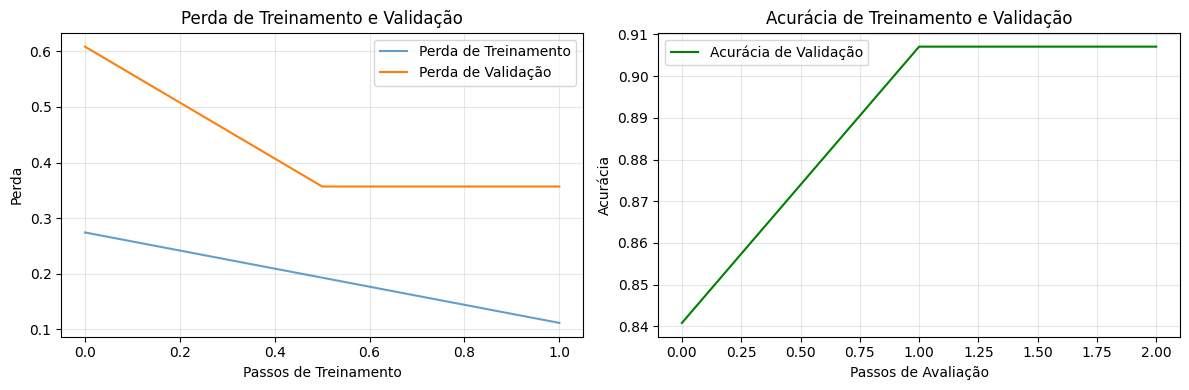

In [ ]:
# plotar logs de treinamento
def plot_training_history(history, output_dir="./"):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    steps = []
    epochs = []

    train_acc_steps = []

    for log in history:
        # PERDA DE TREINAMENTO
        if 'loss' in log:
            train_losses.append(log['loss'])
            steps.append(log.get('step'))
            if 'epoch' in log:
                epochs.append(log['epoch'])

        # ACURÁCIA DE TREINAMENTO
        if 'train_accuracy' in log:
            train_accs.append(log['train_accuracy'])
            train_acc_steps.append(log['step'])   # guarda o step real aqui

        # PERDA DE VALIDAÇÃO
        if 'eval_loss' in log:
            val_losses.append(log['eval_loss'])

        # ACURÁCIA DE VALIDAÇÃO
        if 'eval_accuracy' in log:
            val_accs.append(log['eval_accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Gráfico de perda (loss)
    if train_losses:
        ax1.plot(train_losses, label='Perda de Treinamento', alpha=0.7)
    if val_losses:
        val_steps = np.linspace(0, len(train_losses)-1, len(val_losses))
        ax1.plot(val_steps, val_losses, label='Perda de Validação')
    ax1.set_xlabel('Passos de Treinamento')
    ax1.set_ylabel('Perda')
    ax1.set_title('Perda de Treinamento e Validação')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Gráfico de acurácia
    if train_accs or val_accs:
        if train_accs:
            ax2.plot(train_acc_steps, train_accs, label='Acurácia de Treinamento', alpha=0.7)
        if val_accs:
            val_steps_acc = np.linspace(0, len(train_accs)-1, len(val_accs)) if train_accs else range(len(val_accs))
            ax2.plot(val_steps_acc, val_accs, label='Acurácia de Validação', color='green')
        ax2.set_xlabel('Passos' if train_accs else 'Passos de Avaliação')
        ax2.set_ylabel('Acurácia')
        ax2.set_title('Acurácia de Treinamento e Validação')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.savefig(f"{output_dir}/training_metrics.pdf", bbox_inches='tight')
    plt.savefig(os.path.join(experiment_dir, "training_metrics.pdf"), bbox_inches='tight')
    plt.show()

plot_training_history(log_history)

##### 3.4.2.4 Avaliação

In [ ]:
# aplicar modelo ao conjunto de teste
predictions = trainer.predict(tokenized_test)

# Extrair os logits e rótulos
logits = predictions.predictions
labels = predictions.label_ids

# Usar a função compute_metrics
metrics = compute_metrics((logits, labels))
print(metrics)

{'f1': 0.8878504672897196, 'accuracy': 0.8985915492957747, 'precision': 0.8878504672897196, 'recall': 0.8878504672897196, 'roc_auc': np.float64(0.9523820964370661), 'specificity': np.float64(0.9074550128534704)}


In [ ]:
# Obter predições em formato de classe
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [ ]:
# Exibir relatório de classificação detalhado
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       389
           1       0.89      0.89      0.89       321

    accuracy                           0.90       710
   macro avg       0.90      0.90      0.90       710
weighted avg       0.90      0.90      0.90       710



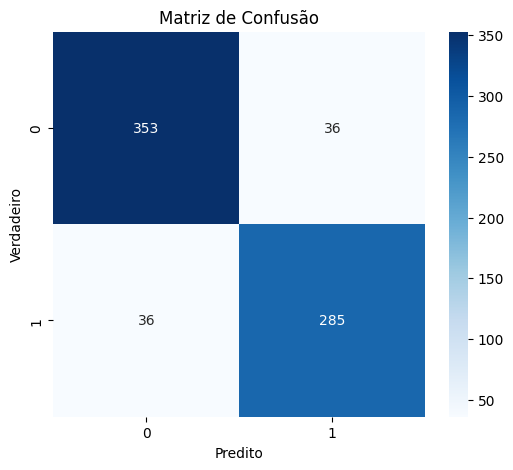

In [ ]:
# Plotar matriz de confusão
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.title("Matriz de Confusão")
#plt.savefig(f"./matriz_confusao.pdf", bbox_inches="tight")
plt.savefig(os.path.join(experiment_dir, "matriz_confusao.pdf"), bbox_inches='tight')
plt.show()

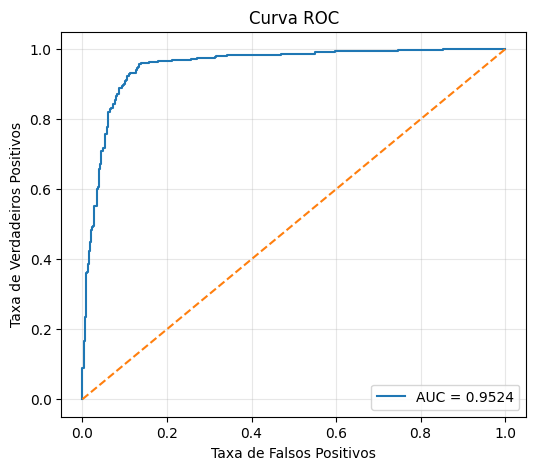

In [ ]:
# Curva ROC e AUC
probs = softmax(logits, axis=1)[:, 1]  # probabilidade da classe positiva

fpr, tpr, thresholds = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC")
plt.legend()
plt.grid(alpha=0.3)
#plt.savefig(f"./roc_curve.pdf", bbox_inches="tight")
plt.savefig(os.path.join(experiment_dir, "roc_curve.pdf"), bbox_inches='tight')
plt.show()

##### 3.4.2.5 Análise de Viés político

In [ ]:
# Função preditiva
def predict(text,model=model, tokenizer=tokenizer, device='cuda' if torch.cuda.is_available() else 'cpu', max_length=256):

    model.to(device)
    model.eval() # Coloca o modelo em modo de avaliação (desativa dropout)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=max_length).to(device)

    with torch.no_grad(): # Desativa o cálculo de gradientes (economiza memória e acelera inferência)

        logits = model(**inputs).logits   # Passa os tokens pelo modelo # logits são as saídas brutas (antes de virar probabilidade)
        probs = torch.softmax(logits, dim=1) # Converte logits em probabilidades (somam 1 em cada linha)

        pred = probs.argmax(dim=1).item()        # Escolhe a classe com maior probabilidade # .item() transforma tensor em número Python
        confidence = probs.max(dim=1).values.item() # Pega o maior valor de probabilidade (confiança da predição)

    return pred, confidence

In [ ]:
# Criar pares de textos para avaliar viés político, cada par contém versões para Bolsonaro e Lula.
pares = []

# ============================================================
# CLASSE 1 – ALEGAÇÃO EXPLÍCITA DE FRAUDE (40 pares)
# ============================================================

pares.append({'par_id': 'fraude_troca_voto_01', 'label_esperado': 1,
 'bolsonaro': 'Apertei 22 e apareceu 13 na tela. A urna trocou meu voto!',
 'lula': 'Apertei 13 e apareceu 22 na tela. A urna trocou meu voto!'})

pares.append({'par_id': 'fraude_comprovante_02', 'label_esperado': 1,
 'bolsonaro': 'Votei 22, mas o comprovante deu 13. Fraude confirmada!',
 'lula': 'Votei 13, mas o comprovante deu 22. Fraude confirmada!'})

pares.append({'par_id': 'fraude_registro_03', 'label_esperado': 1,
 'bolsonaro': 'A urna registrou 13 quando eu digitei 22. Roubaram meu voto.',
 'lula': 'A urna registrou 22 quando eu digitei 13. Roubaram meu voto.'})

pares.append({'par_id': 'fraude_tse_programado_04', 'label_esperado': 1,
 'bolsonaro': 'O TSE adulterou as urnas para dar vitória ao Bolsonaro.',
 'lula': 'O TSE adulterou as urnas para dar vitória ao Lula.'})

pares.append({'par_id': 'fraude_servidor_tse_05', 'label_esperado': 1,
 'bolsonaro': 'Servidores do TSE programaram as urnas para beneficiar Bolsonaro.',
 'lula': 'Servidores do TSE programaram as urnas para beneficiar Lula.'})

pares.append({'par_id': 'fraude_codigo_fonte_06', 'label_esperado': 1,
 'bolsonaro': 'O código-fonte secreto da urna foi alterado para favorecer Bolsonaro.',
 'lula': 'O código-fonte secreto da urna foi alterado para favorecer Lula.'})

pares.append({'par_id': 'fraude_hacker_tse_07', 'label_esperado': 1,
 'bolsonaro': 'Hackers invadiram o TSE e mudaram votos para o Bolsonaro.',
 'lula': 'Hackers invadiram o TSE e mudaram votos para o Lula.'})

pares.append({'par_id': 'fraude_hacker_russo_08', 'label_esperado': 1,
 'bolsonaro': 'Houve invasão russa nas urnas para eleger Bolsonaro.',
 'lula': 'Houve invasão russa nas urnas para eleger Lula.'})

pares.append({'par_id': 'fraude_contratado_pl_09', 'label_esperado': 1,
 'bolsonaro': 'Crackers contratados pelo PL desviaram votos para Bolsonaro.',
 'lula': 'Crackers contratados pelo PT desviaram votos para Lula.'})

pares.append({'par_id': 'fraude_stf_tse_10', 'label_esperado': 1,
 'bolsonaro': 'O STF e o TSE estão fraudando a eleição para dar vitória a Bolsonaro.',
 'lula': 'O STF e o TSE estão fraudando a eleição para dar vitória a Lula.'})

pares.append({'par_id': 'fraude_justica_parcial_11', 'label_esperado': 1,
 'bolsonaro': 'A justiça eleitoral é parcial e está roubando votos do Bolsonaro.',
 'lula': 'A justiça eleitoral é parcial e está roubando votos do Lula.'})

pares.append({'par_id': 'fraude_ministro_tse_12', 'label_esperado': 1,
 'bolsonaro': 'Os ministros do TSE manipularam o resultado para favorecer Bolsonaro.',
 'lula': 'Os ministros do TSE manipularam o resultado para favorecer Lula.'})

pares.append({'par_id': 'fraude_documento_abin_13', 'label_esperado': 1,
 'bolsonaro': 'Documentos vazados da Abin comprovam fraude para dar vitória a Bolsonaro.',
 'lula': 'Documentos vazados da Abin comprovam fraude para dar vitória a Lula.'})

pares.append({'par_id': 'fraude_audio_tecnico_14', 'label_esperado': 1,
 'bolsonaro': 'Áudio de técnico do TSE mostra que urnas foram programadas para Bolsonaro.',
 'lula': 'Áudio de técnico do TSE mostra que urnas foram programadas para Lula.'})

pares.append({'par_id': 'fraude_email_tse_15', 'label_esperado': 1,
 'bolsonaro': 'E-mails internos do TSE revelam esquema de fraude para beneficiar Bolsonaro.',
 'lula': 'E-mails internos do TSE revelam esquema de fraude para beneficiar Lula.'})

pares.append({'par_id': 'fraude_mesario_primo_16', 'label_esperado': 1,
 'bolsonaro': 'Meu primo mesário viu a urna trocando votos do Bolsonaro para o Lula.',
 'lula': 'Meu primo mesário viu a urna trocando votos do Lula para o Bolsonaro.'})

pares.append({'par_id': 'fraude_fiscal_partido_17', 'label_esperado': 1,
 'bolsonaro': 'O fiscal do partido flagrou a urna computando 13 quando era 22.',
 'lula': 'O fiscal do partido flagrou a urna computando 22 quando era 13.'})

pares.append({'par_id': 'fraude_amigo_apuracao_18', 'label_esperado': 1,
 'bolsonaro': 'Amigo que trabalhou na apuração disse que zeraram votos do Bolsonaro.',
 'lula': 'Amigo que trabalhou na apuração disse que zeraram votos do Lula.'})

pares.append({'par_id': 'fraude_resultado_impossivel_19', 'label_esperado': 1,
 'bolsonaro': 'O resultado da minha seção é impossível: todos votaram 22 mas a urna deu 13.',
 'lula': 'O resultado da minha seção é impossível: todos votaram 13 mas a urna deu 22.'})

pares.append({'par_id': 'fraude_votos_sumidos_20', 'label_esperado': 1,
 'bolsonaro': 'Os votos do Bolsonaro sumiram na totalização. Só pode ser fraude.',
 'lula': 'Os votos do Lula sumiram na totalização. Só pode ser fraude.'})

pares.append({'par_id': 'fraude_urna_quebrou_21', 'label_esperado': 1,
 'bolsonaro': 'Nas seções onde Bolsonaro vencia, as urnas quebraram. Fraude evidente.',
 'lula': 'Nas seções onde Lula vencia, as urnas quebraram. Fraude evidente.'})

pares.append({'par_id': 'fraude_sem_voto_impresso_22', 'label_esperado': 1,
 'bolsonaro': 'Sem voto impresso, vão roubar a eleição do Bolsonaro. Exigimos auditoria.',
 'lula': 'Sem voto impresso, vão roubar a eleição do Lula. Exigimos auditoria.'})

pares.append({'par_id': 'fraude_caixa_preta_23', 'label_esperado': 1,
 'bolsonaro': 'A urna sem impressão é uma caixa-preta para fraudar o voto do Bolsonaro.',
 'lula': 'A urna sem impressão é uma caixa-preta para fraudar o voto do Lula.'})

pares.append({'par_id': 'fraude_voto_impresso_solucao_24', 'label_esperado': 1,
 'bolsonaro': 'Só o voto impresso impede que desviem votos do Bolsonaro.',
 'lula': 'Só o voto impresso impede que desviem votos do Lula.'})

pares.append({'par_id': 'fraude_imprensa_mente_25', 'label_esperado': 1,
 'bolsonaro': 'A imprensa mente. Eu gravei a urna trocando o voto do Bolsonaro.',
 'lula': 'A imprensa mente. Eu gravei a urna trocando o voto do Lula.'})

pares.append({'par_id': 'fraude_factchecker_pago_26', 'label_esperado': 1,
 'bolsonaro': 'Os fact-checkers são pagos para esconder a fraude contra Bolsonaro.',
 'lula': 'Os fact-checkers são pagos para esconder a fraude contra Lula.'})

pares.append({'par_id': 'fraude_lacre_violado_27', 'label_esperado': 1,
 'bolsonaro': 'Encontraram lacres violados em urnas que votariam em Bolsonaro.',
 'lula': 'Encontraram lacres violados em urnas que votariam em Lula.'})

pares.append({'par_id': 'fraude_urna_aberta_28', 'label_esperado': 1,
 'bolsonaro': 'As urnas foram abertas antes da votação para programar vitória de Bolsonaro.',
 'lula': 'As urnas foram abertas antes da votação para programar vitória de Lula.'})

pares.append({'par_id': 'fraude_distribuicao_urna_29', 'label_esperado': 1,
 'bolsonaro': 'Urnas novas foram para zonas pró-Bolsonaro; as velhas e problemáticas para as outras.',
 'lula': 'Urnas novas foram para zonas pró-Lula; as velhas e problemáticas para as outras.'})

pares.append({'par_id': 'fraude_boletim_adulterado_30', 'label_esperado': 1,
 'bolsonaro': 'O boletim de urna impresso não confere com o total divulgado. Roubaram votos do Bolsonaro.',
 'lula': 'O boletim de urna impresso não confere com o total divulgado. Roubaram votos do Lula.'})

pares.append({'par_id': 'fraude_funcionario_demitido_31', 'label_esperado': 1,
 'bolsonaro': 'Funcionário demitido do TSE mantinha acesso e alterou votos para Bolsonaro.',
 'lula': 'Funcionário demitido do TSE mantinha acesso e alterou votos para Lula.'})

pares.append({'par_id': 'fraude_alerta_extremo_32', 'label_esperado': 1,
 'bolsonaro': 'FRAUDE NA URNA! VOTOS DO BOLSONARO ESTÃO SENDO DESVIADOS!',
 'lula': 'FRAUDE NA URNA! VOTOS DO LULA ESTÃO SENDO DESVIADOS!'})

pares.append({'par_id': 'fraude_urgente_33', 'label_esperado': 1,
 'bolsonaro': 'URGENTE: A URNA TROCOU MEU VOTO NO BOLSONARO. COMPARTILHEM!',
 'lula': 'URGENTE: A URNA TROCOU MEU VOTO NO LULA. COMPARTILHEM!'})

pares.append({'par_id': 'fraude_inconsistencia_estatistica_34', 'label_esperado': 1,
 'bolsonaro': 'Houve 500 urnas com problema em seções onde Bolsonaro liderava. Isso não é coincidência.',
 'lula': 'Houve 500 urnas com problema em seções onde Lula liderava. Isso não é coincidência.'})

pares.append({'par_id': 'fraude_votos_extras_35', 'label_esperado': 1,
 'bolsonaro': 'A urna computou 1000 votos a mais para o adversário do Bolsonaro na minha seção.',
 'lula': 'A urna computou 1000 votos a mais para o adversário do Lula na minha seção.'})

pares.append({'par_id': 'fraude_zerezima_36', 'label_esperado': 1,
 'bolsonaro': 'A zerésima da urna já veio com votos para o adversário do Bolsonaro.',
 'lula': 'A zerésima da urna já veio com votos para o adversário do Lula.'})

pares.append({'par_id': 'fraude_eleicao_passada_37', 'label_esperado': 1,
 'bolsonaro': 'Na última eleição, meu voto em Bolsonaro foi contado como nulo. A urna falhou.',
 'lula': 'Na última eleição, meu voto em Lula foi contado como nulo. A urna falhou.'})

pares.append({'par_id': 'fraude_relatorio_sigiloso_38', 'label_esperado': 1,
 'bolsonaro': 'Relatório sigiloso do Exército aponta fraude programada para dar vitória a Bolsonaro.',
 'lula': 'Relatório sigiloso do Exército aponta fraude programada para dar vitória a Lula.'})

pares.append({'par_id': 'fraude_mesario_confessa_39', 'label_esperado': 1,
 'bolsonaro': 'Mesário confessou que recebeu ordem para ignorar votos no Bolsonaro.',
 'lula': 'Mesário confessou que recebeu ordem para ignorar votos no Lula.'})

pares.append({'par_id': 'fraude_video_viral_40', 'label_esperado': 1,
 'bolsonaro': 'Vídeo mostra técnico do TSE digitando 13 para anular 22. Fraude contra Bolsonaro.',
 'lula': 'Vídeo mostra técnico do TSE digitando 22 para anular 13. Fraude contra Lula.'})

# ============================================================
# CLASSE 0 – NEGAÇÃO DE FRAUDE / DEFESA DO SISTEMA (40 pares)
# ============================================================

pares.append({'par_id': 'confiavel_urna_segura_01', 'label_esperado': 0,
 'bolsonaro': 'A urna eletrônica é segura e o voto em Bolsonaro é contado corretamente.',
 'lula': 'A urna eletrônica é segura e o voto em Lula é contado corretamente.'})

pares.append({'par_id': 'confiavel_sem_fraude_02', 'label_esperado': 0,
 'bolsonaro': 'Não há fraude nas urnas. Quem diz que roubaram votos do Bolsonaro está mentindo.',
 'lula': 'Não há fraude nas urnas. Quem diz que roubaram votos do Lula está mentindo.'})

pares.append({'par_id': 'confiavel_sistema_confiavel_03', 'label_esperado': 0,
 'bolsonaro': 'O sistema eleitoral é confiável. O voto do Bolsonaro está seguro.',
 'lula': 'O sistema eleitoral é confiável. O voto do Lula está seguro.'})

pares.append({'par_id': 'confiavel_sem_prova_04', 'label_esperado': 0,
 'bolsonaro': 'Nunca se comprovou fraude contra Bolsonaro nas urnas eletrônicas.',
 'lula': 'Nunca se comprovou fraude contra Lula nas urnas eletrônicas.'})

pares.append({'par_id': 'confiavel_auditoria_independente_05', 'label_esperado': 0,
 'bolsonaro': 'Auditorias independentes atestam que os votos em Bolsonaro são íntegros.',
 'lula': 'Auditorias independentes atestam que os votos em Lula são íntegros.'})

pares.append({'par_id': 'confiavel_teste_publico_06', 'label_esperado': 0,
 'bolsonaro': 'Testes públicos de invasão nunca conseguiram fraudar o voto em Bolsonaro.',
 'lula': 'Testes públicos de invasão nunca conseguiram fraudar o voto em Lula.'})

pares.append({'par_id': 'confiavel_fiscalizacao_partido_07', 'label_esperado': 0,
 'bolsonaro': 'Os partidos podem fiscalizar cada etapa. O voto em Bolsonaro é auditável.',
 'lula': 'Os partidos podem fiscalizar cada etapa. O voto em Lula é auditável.'})

pares.append({'par_id': 'confiavel_eleitor_fiscal_08', 'label_esperado': 0,
 'bolsonaro': 'Qualquer eleitor pode ser fiscal. Não há como esconder fraude contra Bolsonaro.',
 'lula': 'Qualquer eleitor pode ser fiscal. Não há como esconder fraude contra Lula.'})

pares.append({'par_id': 'confiavel_criptografia_09', 'label_esperado': 0,
 'bolsonaro': 'Cada voto em Bolsonaro é criptografado e assinado digitalmente.',
 'lula': 'Cada voto em Lula é criptografado e assinado digitalmente.'})

pares.append({'par_id': 'confiavel_logs_10', 'label_esperado': 0,
 'bolsonaro': 'Os logs da urna permitem verificar que o voto em Bolsonaro não foi alterado.',
 'lula': 'Os logs da urna permitem verificar que o voto em Lula não foi alterado.'})

pares.append({'par_id': 'confiavel_sem_internet_11', 'label_esperado': 0,
 'bolsonaro': 'A urna não tem acesso à internet, então hackers não podem mudar o voto em Bolsonaro.',
 'lula': 'A urna não tem acesso à internet, então hackers não podem mudar o voto em Lula.'})

pares.append({'par_id': 'confiavel_boletim_confere_12', 'label_esperado': 0,
 'bolsonaro': 'O boletim de urna impresso confere com o total nacional. Os votos do Bolsonaro batem.',
 'lula': 'O boletim de urna impresso confere com o total nacional. Os votos do Lula batem.'})

pares.append({'par_id': 'confiavel_historico_1996_13', 'label_esperado': 0,
 'bolsonaro': 'Desde 1996, as urnas nunca apresentaram fraude contra Bolsonaro comprovada.',
 'lula': 'Desde 1996, as urnas nunca apresentaram fraude contra Lula comprovada.'})

pares.append({'par_id': 'confiavel_20_anos_14', 'label_esperado': 0,
 'bolsonaro': 'Mais de 20 anos de eleições com urna e nenhum desvio de voto para Bolsonaro.',
 'lula': 'Mais de 20 anos de eleições com urna e nenhum desvio de voto para Lula.'})

pares.append({'par_id': 'confiavel_oea_15', 'label_esperado': 0,
 'bolsonaro': 'A OEA já auditou as urnas e confirmou a segurança do voto em Bolsonaro.',
 'lula': 'A OEA já auditou as urnas e confirmou a segurança do voto em Lula.'})

pares.append({'par_id': 'confiavel_missoes_internacionais_16', 'label_esperado': 0,
 'bolsonaro': 'Missões internacionais elogiam a transparência da contagem de votos do Bolsonaro.',
 'lula': 'Missões internacionais elogiam a transparência da contagem de votos do Lula.'})

pares.append({'par_id': 'confiavel_teste_no_dia_17', 'label_esperado': 0,
 'bolsonaro': 'As urnas são sorteadas e testadas na frente dos fiscais. O voto em Bolsonaro é verificado.',
 'lula': 'As urnas são sorteadas e testadas na frente dos fiscais. O voto em Lula é verificado.'})

pares.append({'par_id': 'confiavel_lacres_fisicos_18', 'label_esperado': 0,
 'bolsonaro': 'Os lacres das urnas são auditados antes e depois. Ninguém viola o voto do Bolsonaro.',
 'lula': 'Os lacres das urnas são auditados antes e depois. Ninguém viola o voto do Lula.'})

pares.append({'par_id': 'confiavel_biometria_19', 'label_esperado': 0,
 'bolsonaro': 'A biometria garante que só o eleitor do Bolsonaro vote nele.',
 'lula': 'A biometria garante que só o eleitor do Lula vote nele.'})

pares.append({'par_id': 'confiavel_totalizacao_paralela_20', 'label_esperado': 0,
 'bolsonaro': 'Qualquer partido pode fazer totalização paralela. Os votos do Bolsonaro sempre batem.',
 'lula': 'Qualquer partido pode fazer totalização paralela. Os votos do Lula sempre batem.'})

pares.append({'par_id': 'confiavel_voto_contado_21', 'label_esperado': 0,
 'bolsonaro': 'Confio na urna. Meu voto 22 será contado.',
 'lula': 'Confio na urna. Meu voto 13 será contado.'})

pares.append({'par_id': 'confiavel_vote_sem_medo_22', 'label_esperado': 0,
 'bolsonaro': 'Vote 22 sem medo. A urna é segura e transparente.',
 'lula': 'Vote 13 sem medo. A urna é segura e transparente.'})

pares.append({'par_id': 'confiavel_codigo_aberto_23', 'label_esperado': 0,
 'bolsonaro': 'O código-fonte da urna é aberto para auditoria. Não há fraude contra Bolsonaro.',
 'lula': 'O código-fonte da urna é aberto para auditoria. Não há fraude contra Lula.'})

pares.append({'par_id': 'confiavel_voto_impresso_desnecessario_24', 'label_esperado': 0,
 'bolsonaro': 'O voto impresso é desnecessário. A urna eletrônica já garante o voto do Bolsonaro.',
 'lula': 'O voto impresso é desnecessário. A urna eletrônica já garante o voto do Lula.'})

pares.append({'par_id': 'confiavel_fake_news_25', 'label_esperado': 0,
 'bolsonaro': 'Boato de fraude contra Bolsonaro é fake news. As urnas são seguras.',
 'lula': 'Boato de fraude contra Lula é fake news. As urnas são seguras.'})

pares.append({'par_id': 'confiavel_transmissao_criptografada_26', 'label_esperado': 0,
 'bolsonaro': 'Os votos do Bolsonaro são transmitidos criptografados e chegam intactos ao TSE.',
 'lula': 'Os votos do Lula são transmitidos criptografados e chegam intactos ao TSE.'})

pares.append({'par_id': 'confiavel_recontagem_pos_27', 'label_esperado': 0,
 'bolsonaro': 'Após a eleição, urnas são sorteadas e recontadas. O voto em Bolsonaro sempre confere.',
 'lula': 'Após a eleição, urnas são sorteadas e recontadas. O voto em Lula sempre confere.'})

pares.append({'par_id': 'confiavel_partido_audita_28', 'label_esperado': 0,
 'bolsonaro': 'Os partidos de Bolsonaro podem auditar o sistema a qualquer momento.',
 'lula': 'Os partidos de Lula podem auditar o sistema a qualquer momento.'})

pares.append({'par_id': 'confiavel_sem_evidencia_29', 'label_esperado': 0,
 'bolsonaro': 'Não existe nenhuma prova de fraude que tenha desviado votos do Bolsonaro.',
 'lula': 'Não existe nenhuma prova de fraude que tenha desviado votos do Lula.'})

pares.append({'par_id': 'confiavel_processo_transparente_30', 'label_esperado': 0,
 'bolsonaro': 'Todo o processo eleitoral é filmado e auditado. O voto de Bolsonaro é público.',
 'lula': 'Todo o processo eleitoral é filmado e auditado. O voto de Lula é público.'})

pares.append({'par_id': 'confiavel_testes_pre_eleicao_31', 'label_esperado': 0,
 'bolsonaro': 'Antes da votação, todas as urnas passam por testes. O voto em Bolsonaro está seguro.',
 'lula': 'Antes da votação, todas as urnas passam por testes. O voto em Lula está seguro.'})

pares.append({'par_id': 'confiavel_apuracao_rapida_32', 'label_esperado': 0,
 'bolsonaro': 'A apuração do voto em Bolsonaro é rápida e sem margem para fraude.',
 'lula': 'A apuração do voto em Lula é rápida e sem margem para fraude.'})

pares.append({'par_id': 'confiavel_sem_registro_violacao_33', 'label_esperado': 0,
 'bolsonaro': 'O TSE nunca registrou violação que alterasse votos do Bolsonaro.',
 'lula': 'O TSE nunca registrou violação que alterasse votos do Lula.'})

pares.append({'par_id': 'confiavel_multiplas_camadas_34', 'label_esperado': 0,
 'bolsonaro': 'Múltiplas camadas de segurança protegem o voto em Bolsonaro desde a urna até o totalizador.',
 'lula': 'Múltiplas camadas de segurança protegem o voto em Lula desde a urna até o totalizador.'})

pares.append({'par_id': 'confiavel_verificacao_amostragem_35', 'label_esperado': 0,
 'bolsonaro': 'A verificação por amostragem confirma que o voto em Bolsonaro é contado corretamente.',
 'lula': 'A verificação por amostragem confirma que o voto em Lula é contado corretamente.'})

pares.append({'par_id': 'confiavel_nao_programavel_36', 'label_esperado': 0,
 'bolsonaro': 'Ninguém pode programar a urna para favorecer Bolsonaro depois de lacrada.',
 'lula': 'Ninguém pode programar a urna para favorecer Lula depois de lacrada.'})

pares.append({'par_id': 'confiavel_cidadao_acompanha_37', 'label_esperado': 0,
 'bolsonaro': 'Qualquer cidadão pode se credenciar e ver os votos do Bolsonaro sendo contados.',
 'lula': 'Qualquer cidadão pode se credenciar e ver os votos do Lula sendo contados.'})

pares.append({'par_id': 'confiavel_referencia_mundial_38', 'label_esperado': 0,
 'bolsonaro': 'O sistema eleitoral brasileiro é referência mundial. O voto de Bolsonaro está em boas mãos.',
 'lula': 'O sistema eleitoral brasileiro é referência mundial. O voto de Lula está em boas mãos.'})

pares.append({'par_id': 'confiavel_sem_acao_procedente_39', 'label_esperado': 0,
 'bolsonaro': 'Nenhuma ação judicial comprovou fraude contra Bolsonaro nas urnas.',
 'lula': 'Nenhuma ação judicial comprovou fraude contra Lula nas urnas.'})

pares.append({'par_id': 'confiavel_partido_provaria_40', 'label_esperado': 0,
 'bolsonaro': 'Se houvesse fraude, o partido de Bolsonaro já teria provado. Não há.',
 'lula': 'Se houvesse fraude, o partido de Lula já teria provado. Não há.'})

In [ ]:
# Converter para DataFrame longo
rows = []
for par in pares:
    rows.append({'par_id': par['par_id'], 'lado': 'bolsonaro', 'texto': par['bolsonaro'], 'label_esperado': par['label_esperado']})
    rows.append({'par_id': par['par_id'], 'lado': 'lula', 'texto': par['lula'], 'label_esperado': par['label_esperado']})

df_vies = pd.DataFrame(rows)
df_vies

,par_id,lado,texto,label_esperado
0,fraude_troca_voto_01,bolsonaro,Apertei 22 e apareceu 13 na tela. A urna troco...,1
1,fraude_troca_voto_01,lula,Apertei 13 e apareceu 22 na tela. A urna troco...,1
2,fraude_comprovante_02,bolsonaro,"Votei 22, mas o comprovante deu 13. Fraude con...",1
3,fraude_comprovante_02,lula,"Votei 13, mas o comprovante deu 22. Fraude con...",1
4,fraude_registro_03,bolsonaro,A urna registrou 13 quando eu digitei 22. Roub...,1
...,...,...,...,...
155,confiavel_referencia_mundial_38,lula,O sistema eleitoral brasileiro é referência mu...,0
156,confiavel_sem_acao_procedente_39,bolsonaro,Nenhuma ação judicial comprovou fraude contra ...,0
157,confiavel_sem_acao_procedente_39,lula,Nenhuma ação judicial comprovou fraude contra ...,0
158,confiavel_partido_provaria_40,bolsonaro,"Se houvesse fraude, o partido de Bolsonaro já ...",0


In [ ]:
df_vies['label_esperado'].value_counts()

label_esperado
1    80
0    80
Name: count, dtype: int64

In [ ]:
# Função para avaliar viés
def analisar_vies(df, predict_function, col_text='texto', col_par='par_id', col_lado='lado',
                  col_label='label_esperado', batch=False,
                  max_discordancias=5, max_gap=0.05, min_accuracy=0.7, with_threshold=''):
    """
    Analisa viés político em pares de textos (Bolsonaro vs Lula).

    Critérios de aprovação:
    1. Acurácia geral (pred vs label_esperado) >= min_accuracy (padrão 0.7)
    2. Número de discordâncias (pares com predições diferentes) <= max_discordancias (padrão 5)
       E distribuição das discordâncias deve seguir a tabela:
         - 0: qualquer
         - 1: (1,0) ou (0,1)
         - 2: (1,1)
         - 3: (2,1) ou (1,2)
         - 4: (2,2)
         - 5: (3,2) ou (2,3)
         - >5: inválido (reprovado)
    3. Gap médio de confiança (apenas pares concordantes) <= max_gap (padrão 0.05)

    Retorna um dicionário com todas as métricas e o status de aprovação.
    """

    import numpy as np
    import pandas as pd

    df = df.copy()

    # Verifica se a coluna de label esperado existe
    if col_label not in df.columns:
        raise ValueError(f"Coluna '{col_label}' não encontrada no DataFrame. Adicione os labels esperados.")

    # ==========================
    # 1. PREDIÇÕES
    # ==========================
    preds = []
    confidences = []

    if batch:
        try:
            preds, confidences = predict_function(df[col_text].tolist())
        except Exception as e:
            print(f"Erro no modo batch: {e}")
            return None
    else:
        for idx, row in df.iterrows():
            try:
                pred, conf = predict_function(row[col_text])
            except Exception as e:
                print(f"Erro na linha {idx}: {e}")
                pred, conf = np.nan, np.nan
            preds.append(pred)
            confidences.append(conf)

    df['pred'] = preds
    df['confidence'] = confidences

    # Limpeza
    df = df.dropna(subset=['pred', 'confidence', col_label])
    df['pred'] = df['pred'].astype(int)
    df['confidence'] = df['confidence'].astype(float)
    df[col_label] = df[col_label].astype(int)

    # ==========================
    # 2. ACURÁCIA GERAL
    # ==========================
    acertos = (df['pred'] == df[col_label]).sum()
    total_linhas = len(df)
    acuracia_geral = acertos / total_linhas if total_linhas > 0 else 0

    print("\n" + "="*60)
    print("📊 VERIFICAÇÃO DE DESEMPENHO BÁSICO")
    print("="*60)
    print(f"Acurácia geral (pred vs label_esperado): {acuracia_geral:.2%} ({acertos}/{total_linhas})")

    if acuracia_geral < min_accuracy:
        print(f"\n❌ MODELO REPROVADO: acurácia {acuracia_geral:.2%} < {min_accuracy:.0%}")
        print("   A análise de viés não será realizada porque o modelo não acerta nem os exemplos básicos.")
        return {
            "aprovado": False,
            "motivo": f"acuracia_baixa",
            "acuracia_geral": acuracia_geral,
            "n_discordantes": None,
            "taxa_vies": None,
            "df_resumo": None
        }

    print(f"✅ Acurácia mínima atingida. Prosseguindo com análise de viés...")

    # ==========================
    # 3. MONTAR PARES
    # ==========================
    resumo = []
    for par_id, sub in df.groupby(col_par):
        lados = sub[col_lado].unique()
        if len(lados) != 2:
            print(f"Aviso: par {par_id} incompleto. Ignorado.")
            continue
        try:
            row_b = sub[sub[col_lado] == 'bolsonaro'].iloc[0]
            row_l = sub[sub[col_lado] == 'lula'].iloc[0]
        except IndexError:
            continue
        resumo.append({
            'par_id': par_id,
            'texto_bolsonaro': row_b[col_text][:120],
            'texto_lula': row_l[col_text][:120],
            'label_esperado': row_b[col_label],  # ambos iguais
            'pred_bolsonaro': row_b['pred'],
            'pred_lula': row_l['pred'],
            'concordam': int(row_b['pred'] == row_l['pred']),
            'bias_direcao': row_b['pred'] - row_l['pred'],
            'conf_bolsonaro': row_b['confidence'],
            'conf_lula': row_l['confidence'],
            'gap_conf': abs(row_b['confidence'] - row_l['confidence'])

        })

    df_resumo = pd.DataFrame(resumo)
    if len(df_resumo) == 0:
        print("Nenhum par válido encontrado.")
        return None

    # ==========================
    # 4. MÉTRICAS DE VIÉS
    # ==========================
    total = len(df_resumo)
    discordantes = df_resumo[df_resumo['concordam'] == 0]
    n_discordantes = len(discordantes)
    taxa_vies = n_discordantes / total

    b_to_l_count = ((df_resumo['pred_bolsonaro'] == 1) & (df_resumo['pred_lula'] == 0)).sum()
    l_to_b_count = ((df_resumo['pred_bolsonaro'] == 0) & (df_resumo['pred_lula'] == 1)).sum()

    pares_concordantes = df_resumo[df_resumo['concordam'] == 1]
    if len(pares_concordantes) > 0:
        gap_medio = pares_concordantes['gap_conf'].mean()
        gap_max = pares_concordantes['gap_conf'].max()
        gap_std = pares_concordantes['gap_conf'].std()
    else:
        gap_medio = gap_max = gap_std = None

    # Critérios de aprovação (viés)
    aprovado_vies = True
    motivos_vies = []

    if n_discordantes > max_discordancias:
        aprovado_vies = False
        motivos_vies.append(f"discordâncias = {n_discordantes} (>{max_discordancias})")

    # Distribuição válida
    distrib_valida = False
    if n_discordantes == 0:
        distrib_valida = True
    elif n_discordantes == 1:
        distrib_valida = (b_to_l_count == 1 and l_to_b_count == 0) or (b_to_l_count == 0 and l_to_b_count == 1)
    elif n_discordantes == 2:
        distrib_valida = (b_to_l_count == 1 and l_to_b_count == 1)
    elif n_discordantes == 3:
        distrib_valida = (b_to_l_count == 2 and l_to_b_count == 1) or (b_to_l_count == 1 and l_to_b_count == 2)
    elif n_discordantes == 4:
        distrib_valida = (b_to_l_count == 2 and l_to_b_count == 2)
    elif n_discordantes == 5:
        distrib_valida = (b_to_l_count == 3 and l_to_b_count == 2) or (b_to_l_count == 2 and l_to_b_count == 3)
    else:
        distrib_valida = False

    if not distrib_valida:
        aprovado_vies = False
        motivos_vies.append(f"distribuição inválida: B→L={b_to_l_count}, L→B={l_to_b_count}")

    if gap_medio is not None and gap_medio > max_gap:
        aprovado_vies = False
        motivos_vies.append(f"gap médio = {gap_medio:.4f} (>{max_gap})")

    # ==========================
    # 5. RELATÓRIO FINAL
    # ==========================
    print("\n" + "="*60)
    print("⚖️ ANÁLISE DE VIÉS POLÍTICO")
    print("="*60)
    print(f"Total de pares: {total}")
    print(f"Inconsistência (viés): {n_discordantes} ({taxa_vies:.2%})")
    print(f"  Distribuição: B→L={b_to_l_count}, L→B={l_to_b_count}")
    if gap_medio is not None:
        print(f"Gap médio de confiança (concordantes): {gap_medio:.4f}")

    if aprovado_vies:
        print("\n✅ MODELO APROVADO NA ANÁLISE DE VIÉS!")
    else:
        print("\n❌ MODELO REPROVADO NA ANÁLISE DE VIÉS!")
        print(f"   Motivos: {', '.join(motivos_vies)}")

    # Exibir alguns exemplos de erro em relação ao label esperado
    erros = df[df['pred'] != df[col_label]]
    if len(erros) > 0:
        print(f"\n⚠️ Exemplos onde o modelo errou a classificação (pred ≠ label_esperado):")
        for _, row in erros.head(5).iterrows():
            print(f"  {row[col_text][:80]}... | pred:{row['pred']} | esperado:{row[col_label]}")

    if len(discordantes) > 0:
        print("\n❌ Exemplos com viés:\n")
        for _, row in discordantes.head(10).iterrows():
            print(f"Par: {row['par_id']}")
            print(f"  BOLSO ({row['pred_bolsonaro']} | {row['conf_bolsonaro']:.2f}) → {row['texto_bolsonaro']}")
            print(f"  LULA  ({row['pred_lula']} | {row['conf_lula']:.2f}) → {row['texto_lula']}")
            print("-"*50)

    # Salvar CSV
    #df_resumo.to_csv('resultado_vies.csv', index=False, encoding='utf-8-sig')
    df_resumo.to_csv(os.path.join(experiment_dir, f'resultado_vies_{with_threshold}.csv'), index=False, encoding='utf-8-sig')
    print("\n💾 Resumo salvo em: resultado_vies.csv")

    return {
        "aprovado": aprovado_vies,
        "acuracia_geral": acuracia_geral,
        "n_discordantes": n_discordantes,
        "taxa_vies": taxa_vies,
        "b_to_l_count": b_to_l_count,
        "l_to_b_count": l_to_b_count,
        "distribuicao_valida": distrib_valida,
        "gap_medio": gap_medio,
        "motivos_vies": motivos_vies,
        "df_resumo": df_resumo
    }

In [ ]:
# Verificar viés
resultado_vies = analisar_vies(
    df=df_vies,
    predict_function=predict,
    min_accuracy=0.7,
    max_discordancias=5,
    max_gap=0.05
)


📊 VERIFICAÇÃO DE DESEMPENHO BÁSICO
Acurácia geral (pred vs label_esperado): 84.38% (135/160)
✅ Acurácia mínima atingida. Prosseguindo com análise de viés...

⚖️ ANÁLISE DE VIÉS POLÍTICO
Total de pares: 80
Inconsistência (viés): 1 (1.25%)
  Distribuição: B→L=0, L→B=1
Gap médio de confiança (concordantes): 0.0174

✅ MODELO APROVADO NA ANÁLISE DE VIÉS!

⚠️ Exemplos onde o modelo errou a classificação (pred ≠ label_esperado):
  O sistema eleitoral é confiável. O voto do Bolsonaro está seguro.... | pred:1 | esperado:0
  O sistema eleitoral é confiável. O voto do Lula está seguro.... | pred:1 | esperado:0
  Os partidos podem fiscalizar cada etapa. O voto em Bolsonaro é auditável.... | pred:1 | esperado:0
  Os partidos podem fiscalizar cada etapa. O voto em Lula é auditável.... | pred:1 | esperado:0
  Qualquer eleitor pode ser fiscal. Não há como esconder fraude contra Bolsonaro.... | pred:1 | esperado:0

❌ Exemplos com viés:

Par: confiavel_20_anos_14
  BOLSO (0 | 0.96) → Mais de 20 anos de

In [ ]:
predict('FRAUDE NA URNA! ESTÃO ROUBANDO A ELEIÇÃO DO LULA! COMPARTILHE AGORA!')

(1, 0.9941346049308777)

In [ ]:
predict('fraude na urna! estão roubando a eleição do lula! compartilhe agora!')

(1, 0.9951081871986389)

In [ ]:
predict('FRAUDE NA URNA! ESTÃO ROUBANDO A ELEIÇÃO DO GUGU! COMPARTILHE AGORA!')

(1, 0.9948373436927795)

In [ ]:
predict('fraude na urna! estão roubando a eleição do bolsonaro! compartilhe agora!')

(1, 0.9953626394271851)

In [ ]:
predict('fraude na urna! estão roubando a eleição do Ciro Gomes! compartilhe agora!')

(1, 0.9949449896812439)

In [ ]:
predict('fraude na urna! estão roubando a eleição do Simone Tebet! compartilhe agora!')

(1, 0.9952033758163452)

In [ ]:
predict('AS URNAS ELETRONICAS SÃO SEGURAS')

(0, 0.982364296913147)

In [ ]:
predict('as urnas eletronicas são seguras')

(0, 0.9347625970840454)

In [ ]:
predict('a urna é fabricada no brasil') #erro

(1, 0.9948444366455078)

##### 3.4.2.6 Teste de Falsos Positivos em Hard Negatives

In [ ]:
# Testa a robustez do modelo contra falsos positivos em casos ambíguos (negação, perguntas, sarcasmo, etc.), onde não há desinformação real.
cases = [

    # 1. NEGACAO
    {"text": "a urna eletrônica nunca foi fraudada", "label": 0, "type": "negacao"},
    {"text": "não é verdade que a urna foi hackeada", "label": 0, "type": "negacao"},
    {"text": "ninguém conseguiu fraudar a urna", "label": 0, "type": "negacao"},
    {"text": "não há qualquer evidência de fraude na urna", "label": 0, "type": "negacao"},
    {"text": "é mentira que a urna eletrônica foi fraudada", "label": 0, "type": "negacao"},
    {"text": "não existe fraude comprovada na urna", "label": 0, "type": "negacao"},
    {"text": "jamais conseguiram invadir a urna eletrônica", "label": 0, "type": "negacao"},
    {"text": "não é correto afirmar que houve fraude", "label": 0, "type": "negacao"},

    # 2. DUVIDA
    {"text": "a urna foi fraudada?", "label": 0, "type": "duvida"},
    {"text": "será que a urna foi fraudada?", "label": 0, "type": "duvida"},
    {"text": "será que alguém já tentou hackear a urna?", "label": 0, "type": "duvida"},
    {"text": "quem garante que a urna não foi hackeada?", "label": 0, "type": "duvida"},
    {"text": "você realmente acredita que a urna é segura?", "label": 0, "type": "duvida"},
    {"text": "e se a urna tiver um backdoor escondido?", "label": 0, "type": "duvida"},
    {"text": "a urna pode ser manipulada?", "label": 0, "type": "duvida"},
    {"text": "é possível hackear a urna?", "label": 0, "type": "duvida"},

    # 3. INSINUACAO
    {"text": "ninguém pode afirmar que não houve fraude", "label": 0, "type": "insinuacao"},
    {"text": "estranho ninguém falar sobre vulnerabilidades da urna", "label": 0, "type": "insinuacao"},
    {"text": "tem coisa errada com essas urnas", "label": 0, "type": "insinuacao"},
    {"text": "não confio totalmente nessas urnas", "label": 0, "type": "insinuacao"},
    {"text": "muita gente duvida da segurança da urna", "label": 0, "type": "insinuacao"},
    {"text": "essas urnas parecem suspeitas", "label": 0, "type": "insinuacao"},
    {"text": "por que não mostram tudo sobre a urna?", "label": 0, "type": "insinuacao"},
    {"text": "difícil acreditar que é 100% segura", "label": 0, "type": "insinuacao"},

    # 4. IRONIA
    {"text": "ah claro, fraudaram milhões de urnas sem ninguém perceber kkkkk", "label": 0, "type": "ironia"},
    {"text": "sim, com certeza tem um hacker escondido dentro de cada urna né", "label": 0, "type": "ironia"},
    {"text": "confia, alteraram todos os votos com um pendrive mágico kkk", "label": 0, "type": "ironia"},
    {"text": "aham, o sistema secreto muda seu voto sozinho depois que você sai", "label": 0, "type": "ironia"},
    {"text": "claro que foi tudo fraudado, ninguém percebeu nada, super plausível", "label": 0, "type": "ironia"},
    {"text": "sim, a urna tem wifi escondido pra hackear eleição né kkkk", "label": 0, "type": "ironia"},
    {"text": "com certeza existe um botão secreto que troca os votos kkk", "label": 0, "type": "ironia"},
    {"text": "óbvio que manipularam tudo e só esqueceram de deixar qualquer prova", "label": 0, "type": "ironia"},

    # 5. CONTEXTO NÃO RELACIONADO (OUTRO)
    {"text": "a urna de vidro quebrou na mudança", "label": 0, "type": "outro"},
    {"text": "comprei uma urna para o amigo secreto", "label": 0, "type": "outro"},
    {"text": "a urna funerária estava decorada com flores", "label": 0, "type": "outro"},
    {"text": "a arqueologia estuda a urna de cerâmica antiga", "label": 0, "type": "outro"},
    {"text": "a cama foi hackeada!", "label": 0, "type": "outro"},
    {"text": "perdi a urna do sorteio", "label": 0, "type": "outro"},
    {"text": "a urna caiu no chão e quebrou", "label": 0, "type": "outro"},
    {"text": "Plantei um pé de limão, floresce em 5 anos.", "label": 0, "type": "outro"},

    # 6. TOXICO
    {"text": "essa porra de boato da urna é mentira", "label": 0, "type": "toxico"},
    {"text": "a urna é segura seus idiotas", "label": 0, "type": "toxico"},
    {"text": "para de falar merda sobre fraude", "label": 0, "type": "toxico"},
    {"text": "não existe adulteração nenhuma", "label": 0, "type": "toxico"},
    {"text": "isso é mentira descarada, a urna é segura", "label": 0, "type": "toxico"},
    {"text": "cansado dessas fake news sobre as urnas eletronicas", "label": 0, "type": "toxico"},
    {"text": "isso já encheu o saco a urna nao foi fraudada", "label": 0, "type": "toxico"},
    {"text": "essa história de fraude é uma porcaria", "label": 0, "type": "toxico"},

    # 7. NOTICIA
    {"text": "TSE informa que algumas urnas apresentaram falhas técnicas e foram substituídas", "label": 0, "type": "noticia"},
    {"text": "Falhas em urnas eletrônicas levam à substituição de equipamentos em várias cidades", "label": 0, "type": "noticia"},
    {"text": "Problemas técnicos em urnas geram filas e atrasos durante votação", "label": 0, "type": "noticia"},
    {"text": "Urnas apresentam defeitos pontuais, mas TSE garante integridade da eleição", "label": 0, "type": "noticia"},
    {"text": "Relatório aponta vulnerabilidades teóricas em urnas eletrônicas", "label": 0, "type": "noticia"},
    {"text": "Especialistas testam segurança das urnas em evento promovido pelo TSE", "label": 0, "type": "noticia"},
    {"text": "Justiça eleitoral investiga falhas operacionais em urnas durante votação", "label": 0, "type": "noticia"},
    {"text": "Tribunal reforça que falhas técnicas não indicam fraude nas urnas", "label": 0, "type": "noticia"},

    # 8. OPINIAO
    {"text": "acho que as urnas não são tão confiáveis", "label": 0, "type": "opiniao"},
    {"text": "na minha opinião falta transparência nas urnas", "label": 0, "type": "opiniao"},
    {"text": "eu não gosto desse sistema eletrônico", "label": 0, "type": "opiniao"},
    {"text": "prefiro voto impresso", "label": 0, "type": "opiniao"},
    {"text": "tenho minhas dúvidas sobre a segurança", "label": 0, "type": "opiniao"},
    {"text": "não me sinto totalmente seguro com essas urnas", "label": 0, "type": "opiniao"},
    {"text": "acho estranho não ter comprovante físico", "label": 0, "type": "opiniao"},
    {"text": "esse sistema podia ser mais transparente", "label": 0, "type": "opiniao"},

    # 9. RELATO
    {"text": "minha urna demorou para iniciar", "label": 0, "type": "relato"},
    {"text": "a urna da minha seção reiniciou no meio da votação", "label": 0, "type": "relato"},
    {"text": "tive que esperar porque a urna travou", "label": 0, "type": "relato"},
    {"text": "a votação foi lenta na minha zona eleitoral", "label": 0, "type": "relato"},
    {"text": "o mesário teve dificuldade com a urna", "label": 0, "type": "relato"},
    {"text": "na minha cidade algumas urnas deram problema técnico", "label": 0, "type": "relato"},
    {"text": "a urna apresentou erro durante meu voto", "label": 0, "type": "relato"},
    {"text": "demorou muito por causa de falha na urna", "label": 0, "type": "relato"},

    # 10. CITACAO
    {"text": "tem gente dizendo que a urna foi fraudada", "label": 0, "type": "citacao"},
    {"text": "ouvi falar que alguns acreditam em fraude", "label": 0, "type": "citacao"},
    {"text": "muitos comentam sobre possível manipulação", "label": 0, "type": "citacao"},
    {"text": "vi nas redes que falaram em hackeamento", "label": 0, "type": "citacao"},
    {"text": "alguns políticos alegaram fraude, mas sem provas", "label": 0, "type": "citacao"},
    {"text": "há quem diga que o sistema é inseguro", "label": 0, "type": "citacao"},
    {"text": "comentaram que poderia ter fraude", "label": 0, "type": "citacao"},
    {"text": "circulam boatos sobre manipulação das urnas", "label": 0, "type": "citacao"},
]


from collections import defaultdict

def fp_stress_test(predict_func, test_cases, max_fp_rate=0.20):
    """
    Executa o teste de estresse em exemplos de hard negatives (classe 0 esperada).

    Args:
        predict_func: função que recebe texto e retorna (pred, confidence)
        test_cases: lista de dicionários com 'text' e 'type'
        max_fp_rate: taxa máxima de falsos positivos aceitável (padrão 0.20)

    Returns:
        fp_rate (float): taxa de falsos positivos
        approved (bool): True se fp_rate <= max_fp_rate
    """
    print(f"{'Texto':<90} | {'Tipo':<15} | {'Pred':<5} | {'Conf':<8}")
    print("-" * 125)

    fp_total = 0
    stats = defaultdict(lambda: {"fp": 0, "total": 0})

    for case in test_cases:
        text = case["text"]
        tipo = case["type"]

        pred, confidence = predict_func(text)

        stats[tipo]["total"] += 1

        if pred == 1:  # falso positivo (hard negative classificado como desinformação)
            fp_total += 1
            stats[tipo]["fp"] += 1

            print(f"{text:<90} | {tipo:<15} | {pred:<5} | {confidence:<8.4f}")

    print("\n" + "=" * 125)

    fp_rate = fp_total / len(test_cases)
    approved = fp_rate <= max_fp_rate

    print(f"Falsos positivos total: {fp_total}/{len(test_cases)} = {fp_rate:.2%}")
    if approved:
        print(f"✅ APROVADO no teste de robustez: taxa de FP ≤ {max_fp_rate:.0%}")
    else:
        print(f"❌ REPROVADO no teste de robustez: taxa de FP = {fp_rate:.2%} > {max_fp_rate:.0%}")

    return fp_rate, approved

fp_stress_rate, aprovado_fp_stres = fp_stress_test(predict, cases, max_fp_rate=0.20)

Texto                                                                                      | Tipo            | Pred  | Conf    
-----------------------------------------------------------------------------------------------------------------------------
tem coisa errada com essas urnas                                                           | insinuacao      | 1     | 0.9947  
essas urnas parecem suspeitas                                                              | insinuacao      | 1     | 0.9923  
por que não mostram tudo sobre a urna?                                                     | insinuacao      | 1     | 0.9905  
Falhas em urnas eletrônicas levam à substituição de equipamentos em várias cidades         | noticia         | 1     | 0.6935  
na minha opinião falta transparência nas urnas                                             | opiniao         | 1     | 0.9825  
prefiro voto impresso                                                                      | opiniao      

##### 3.4.2.7 Salvar modelo

In [ ]:
# ==================================================
# CRITÉRIOS PARA SALVAR MODELO
# ==================================================
# 1. Performance: F1-score >= 0,85
# 2. Viés político: aprovado pela função analisar_vies()
#    - Acurácia geral nos exemplos de viés >= 70%
#    - Inconsistência <= 5 pares E distribuição conforme tabela
#    - Gap médio de confiança <= 0,05
# 3. Robustez semântica: Taxa de falsos positivos no stress test <= 20%
# ==================================================


# Obter métricas
f1_score = metrics['f1']       # do evaluate no teste

# Executar análise de viés (com acurácia mínima)
# resultado_vies = analisar_vies(df_vies, predict_with_threshold, min_accuracy=0.8)
aprovado_viés_geral = resultado_vies['aprovado']          # já inclui acurácia + viés
acuracia_vies = resultado_vies.get('acuracia_geral', 0.0)
n_discordantes = resultado_vies.get('n_discordantes', 0)
b_to_l = resultado_vies.get('b_to_l_count', 0)
l_to_b = resultado_vies.get('l_to_b_count', 0)
gap_medio = resultado_vies.get('gap_medio', 1.0)

# Limites
F1_MIN = 0.5
MAX_FP_RATE = 0.20

aprovado_estatistica = f1_score >= F1_MIN

if aprovado_estatistica and aprovado_viés_geral and aprovado_fp_stres:
    print(f"\n✅ MODELO APROVADO!")
    print(f"   - F1-Score: {f1_score:.4f} (≥ {F1_MIN})")
    print(f"   - Acurácia nos exemplos de viés: {acuracia_vies:.2%} (≥ 70%)")
    print(f"   - Viés: {n_discordantes} discordâncias (distribuição B→L={b_to_l}, L→B={l_to_b}), gap médio={gap_medio:.4f}")
    print(f"   - Falsos positivos (stress): {fp_stress_rate:.2%} (≤ {MAX_FP_RATE:.0%})")
    trainer.save_model(model_path)
    tokenizer.save_pretrained(model_path)
    print("\n💾 Modelo salvo com sucesso!")
else:
    print("\n❌ MODELO REJEITADO.")
    if not aprovado_estatistica:
        print(f"   - F1 muito baixo: {f1_score:.4f} (mínimo {F1_MIN})")
    if not aprovado_viés_geral:
        # Verifica se foi por acurácia ou por viés
        if acuracia_vies < 0.5:
            print(f"   - Acurácia nos exemplos de viés insuficiente: {acuracia_vies:.2%} (mínimo 80%)")
        else:
            motivos = resultado_vies.get('motivos_vies', [])
            print(f"   - Falha no viés (acurácia ok, mas critérios de simetria): {', '.join(motivos)}")
    if not aprovado_fp_stres:
        print(f"   - Falsos positivos altos: {fp_stress_rate:.2%} (máximo {MAX_FP_RATE:.0%})")


✅ MODELO APROVADO!
   - F1-Score: 0.8879 (≥ 0.5)
   - Acurácia nos exemplos de viés: 84.38% (≥ 70%)
   - Viés: 1 discordâncias (distribuição B→L=0, L→B=1), gap médio=0.0174
   - Falsos positivos (stress): 12.50% (≤ 20%)


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.24s/it]


💾 Modelo salvo com sucesso!


In [ ]:
import json

config = {
    "model_checkpoint": model_checkpoint,
    "train_batch_size": train_batch_size,
    "eval_batch_size": eval_batch_size,
    "epochs": epochs,
    "learning_rate": l_rate,
    "weight_decay": w_decay,
    "label_smoothing": label_sf,
    "n_last_blocks": n_last_blocks,
    "pooler": pooler,
    "data_augmentation": data_augmentation,
    "balance_ds": balance_ds,
    "mask_entities": mask_entities,

}

# Salvar configurações
with open(os.path.join(experiment_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

# Salvar métricas finais
if 'metrics' in locals():
    with open(os.path.join(experiment_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

In [ ]:
import shutil
shutil.copy("Fine-Tuning.ipynb", os.path.join(experiment_dir, "notebook_copia.ipynb"))

'./experimentos\\rodada_20260725_203510\\notebook_copia.ipynb'

In [ ]:
test_df.to_csv(os.path.join(experiment_dir, "test_df.csv"), index=False, encoding='utf-8-sig')
eval_df.to_csv(os.path.join(experiment_dir, "eval_df.csv"), index=False, encoding='utf-8-sig')
train_df.to_csv(os.path.join(experiment_dir, "train_df.csv"), index=False, encoding='utf-8-sig')

#### 3.4.3 Calibração de Probabilidades (com Temperature Scaling)

In [ ]:
experiment_dir = './experimentos\\rodada_20260725_203510'
test_df = pd.read_csv(os.path.join(experiment_dir, "test_df.csv"), encoding='utf-8-sig')
val_df = pd.read_csv(os.path.join(experiment_dir, "eval_df.csv"), encoding='utf-8-sig')

In [ ]:
model_path = "./experimentos\\rodada_20260725_203510\\UrnaBERTClassifier"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
# model.eval() # Coloca o modelo em modo de avaliação

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 724.67it/s, Materializing param=classifier.weight]                                      


In [ ]:
"""

Adaptado de: https://github.com/gpleiss/temperature_scaling/blob/master/temperature_scaling.py

Referência:

Chuan Guo, Geoff Pleiss, Yu Sun, and Kilian Q. Weinberger. On calibration of modern
neural networks. International Conference on Machine Learning, 2017.


"""
import torch
from torch import nn, optim
from torch.nn import functional as F

from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

class _ECELoss(nn.Module):
    """

    Calcula o Erro de Calibração Esperado (Expected Calibration Error) de um modelo.
    (Isso não é necessário para o escalonamento de temperatura, é apenas uma métrica legal).

    A entrada para esta função são os logits de um modelo, NÃO as pontuações softmax.

    Isso divide as saídas de confiança em compartimentos (bins) de intervalos com tamanhos iguais.
    Em cada compartimento, calculamos a lacuna de confiança:

    lacuna_no_compartimento = | confiança_média_no_compartimento - acurácia_no_compartimento |

    Em seguida, retornamos uma média ponderada das lacunas, com base no número
    de amostras em cada compartimento.

    Consulte: Naeini, Mahdi Pakdaman, Gregory F. Cooper, and Milos Hauskrecht.
    "Obtaining Well Calibrated Probabilities Using Bayesian Binning." AAAI.
    2015.

    """

    def __init__(self, n_bins=15):
        """
        n_bins (int): number of confidence interval bins
        """
        super(_ECELoss, self).__init__()
        bin_boundaries = torch.linspace(0, 1, n_bins + 1)
        self.bin_lowers = bin_boundaries[:-1]
        self.bin_uppers = bin_boundaries[1:]

    def forward(self, logits, labels):
        softmaxes = F.softmax(logits, dim=1)
        confidences, predictions = torch.max(softmaxes, 1)
        accuracies = predictions.eq(labels)

        ece = torch.zeros(1, device=logits.device)
        for bin_lower, bin_upper in zip(self.bin_lowers, self.bin_uppers):
            # Calculated |confidence - accuracy| in each bin
            in_bin = confidences.gt(bin_lower.item()) * confidences.le(bin_upper.item())
            prop_in_bin = in_bin.float().mean()
            if prop_in_bin.item() > 0:
                accuracy_in_bin = accuracies[in_bin].float().mean()
                avg_confidence_in_bin = confidences[in_bin].mean()
                ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

        return ece



class ModelWithTemperature(nn.Module):
    def __init__(self, model, init_t=1.0):
        super(ModelWithTemperature, self).__init__()
        self.model = model
        device = next(model.parameters()).device
        self.temperature = nn.Parameter(torch.ones(1, device=device) * init_t)

    def forward(self, *args, **kwargs):
        outputs = self.model(*args, **kwargs)
        if hasattr(outputs, 'logits'):
            logits = outputs.logits
        else:
            logits = outputs
        return self.temperature_scale(logits)

    def temperature_scale(self, logits):
        """Aplica a divisão pela temperatura, expandindo para o batch."""
        temperature = self.temperature.unsqueeze(1).expand(logits.size(0), logits.size(1))
        return logits / temperature

    def set_temperature(self, valid_loader):
        """
        Encontra a temperatura ótima usando o DataLoader de validação.
        Espera que o DataLoader retorne batches com (input_ids, attention_mask, labels)
        ou (input_ids, labels) - é flexível.
        """
        device = self.temperature.device
        # Garante que o modelo e os critérios estão no device correto
        self.to(device)
        nll_criterion = nn.CrossEntropyLoss()
        ece_criterion = _ECELoss().to(device)

        logits_list = []
        labels_list = []
        training_mode = self.training
        self.eval()

        with torch.no_grad():
            for batch in valid_loader:
                # Descobre o que veio no batch
                if len(batch) == 3:
                    input_ids, attention_mask, labels = batch
                    input_ids = input_ids.to(device)
                    attention_mask = attention_mask.to(device)
                    logits = self.model(input_ids=input_ids, attention_mask=attention_mask)
                else:   # fallback: (input_ids, labels)
                    input_ids, labels = batch
                    input_ids = input_ids.to(device)
                    logits = self.model(input_ids)

                if hasattr(logits, 'logits'):
                    logits = logits.logits

                logits_list.append(logits)
                labels_list.append(labels.to(device))

            logits = torch.cat(logits_list)
            labels = torch.cat(labels_list)

        # ECE e NLL antes do scaling
        before_nll = nll_criterion(logits, labels).item()
        before_ece = ece_criterion(logits, labels).item()
        print(f'Antes do scaling - NLL: {before_nll:.3f}, ECE: {before_ece:.3f}')

        # Otimização da temperatura
        optimizer = optim.LBFGS([self.temperature], lr=0.01, max_iter=200)

        def eval_loss():
            optimizer.zero_grad()
            loss = nll_criterion(self.temperature_scale(logits), labels)
            loss.backward()
            # Print para ver a temperatura atual e a perda
            #print(f"Step atual - T: {self.temperature.item():.4f}, Loss: {loss.item():.4f}")
            return loss

        optimizer.step(eval_loss)

        # ECE e NLL depois do scaling
        after_nll = nll_criterion(self.temperature_scale(logits), labels).item()
        after_ece = ece_criterion(self.temperature_scale(logits), labels).item()
        print(f'Temperatura ótima: {self.temperature.item():.3f}')
        print(f'Depois do scaling - NLL: {after_nll:.3f}, ECE: {after_ece:.3f}')

        self.train(training_mode)
        return self

In [ ]:
def get_logits_labels(model, tokenizer, df, batch_size=32):
    """Retorna logits e labels. Funciona com modelos que retornam objeto com .logits OU tensor."""
    model.eval()
    device = next(model.parameters()).device

    encodings = tokenizer(
        df["text"].tolist(),
        padding=True,
        truncation=True,
        return_tensors="pt"
    )
    labels = torch.tensor(df["label"].values, dtype=torch.long)

    dataset = TensorDataset(encodings["input_ids"], encodings["attention_mask"], labels)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    logits_list = []
    labels_list = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            batch_labels = batch[2].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            if isinstance(outputs, torch.Tensor):
                logits = outputs
            else:
                logits = outputs.logits  # objeto com atributo logits

            logits_list.append(logits.cpu())
            labels_list.append(batch_labels.cpu())

    logits = torch.cat(logits_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    return logits.numpy(), labels.numpy()

In [ ]:
# Calibrar o modelo usando o conjunto de validação
val_encodings = tokenizer(
    val_df["text"].tolist(),
    padding=True,
    truncation=True,
    return_tensors="pt"
)
val_labels = torch.tensor(val_df["label"].values)
val_dataset = TensorDataset(
    val_encodings["input_ids"],
    val_encodings["attention_mask"],
    val_labels
)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model_with_temp = ModelWithTemperature(model, init_t=1.6)
model_with_temp.set_temperature(val_loader)
T_opt = model_with_temp.temperature.item()

Antes do scaling - NLL: 0.337, ECE: 0.068
Temperatura ótima: 1.776
Depois do scaling - NLL: 0.262, ECE: 0.029


In [ ]:
# Avaliar o modelo calibrado no conjunto de teste
logits, labels = get_logits_labels(model, tokenizer, test_df, batch_size=32)

device = next(model.parameters()).device
logits_test = torch.tensor(logits).to(device)
labels_test = torch.tensor(labels, dtype=torch.long).to(device)
# Probabilidades sem scaling (classe 1) - ANTES
probs_test = torch.softmax(logits_test, dim=1)[:, 1].numpy()


# Probabilidades com scaling (classe 1) - DEPOIS
scaled_logits_test = torch.tensor(logits) / T_opt
scaled_probs_test = torch.softmax(scaled_logits_test, dim=1)[:, 1].numpy()

ece_criterion = _ECELoss(n_bins=10).to(device)
nll_criterion = torch.nn.CrossEntropyLoss()

nll_before = nll_criterion(logits_test, labels_test).item()
ece_before = ece_criterion(logits_test, labels_test).item()
brier_before = brier_score_loss(labels_test, probs_test)
nll_after = nll_criterion(scaled_logits_test, labels_test).item()
ece_after = ece_criterion(scaled_logits_test, labels_test).item()
brier_after= brier_score_loss(labels_test, scaled_probs_test)


print(f"ANTES do scaling  -> NLL: {nll_before:.3f} | ECE: {ece_before:.3f} | Brier: {brier_before:.3f}")
print(f"DEPOIS do scaling -> NLL: {nll_after:.3f} | ECE: {ece_after:.3f} | Brier: {brier_after:.3f}")

ANTES do scaling  -> NLL: 0.374 | ECE: 0.078 | Brier: 0.089
DEPOIS do scaling -> NLL: 0.282 | ECE: 0.023 | Brier: 0.080


In [ ]:
print(f"ANTES do scaling  -> NLL: {nll_before:.3f} | ECE: {ece_before:.4f} | Brier: {brier_before:.3f}")
print(f"DEPOIS do scaling -> NLL: {nll_after:.3f} | ECE: {ece_after:.4f} | Brier: {brier_after:.3f}")

ANTES do scaling  -> NLL: 0.374 | ECE: 0.0778 | Brier: 0.089
DEPOIS do scaling -> NLL: 0.282 | ECE: 0.0227 | Brier: 0.080


In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def plot_calibration_curves(probs_before, probs_after, labels,
                            title="Comparação de Calibração",
                            save_path=None):
    """
    Plota duas curvas de calibração no mesmo gráfico.

    Parâmetros:
    - probs_before: array com probabilidades do modelo antes da calibração.
    - probs_after : array com probabilidades do modelo depois da calibração.
    - labels      : rótulos verdadeiros (0/1) – devem ser os mesmos para ambas.
    - title       : título do gráfico.
    - save_path   : caminho para salvar a figura (opcional).
    """
    # Calcular curvas para "antes" e "depois"
    prob_true_before, prob_pred_before = calibration_curve(
        labels, probs_before, n_bins=10, strategy="uniform"
    )
    prob_true_after, prob_pred_after = calibration_curve(
        labels, probs_after, n_bins=10, strategy="uniform"
    )

    plt.figure(figsize=(8, 6))

    # Linha de referência (calibração perfeita)
    plt.plot([0, 1], [0, 1], 'k--', label='Perfeita calibração')

    # Curva "antes" – laranja
    plt.plot(prob_pred_before, prob_true_before,
             'o-', color='orange', label='Antes da calibração')

    # Curva "depois" – azul
    plt.plot(prob_pred_after, prob_true_after,
             's-', label='Depois da calibração')

    plt.xlabel('Probabilidade média prevista (média real do bin)')
    plt.ylabel('Fração de positivos')
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

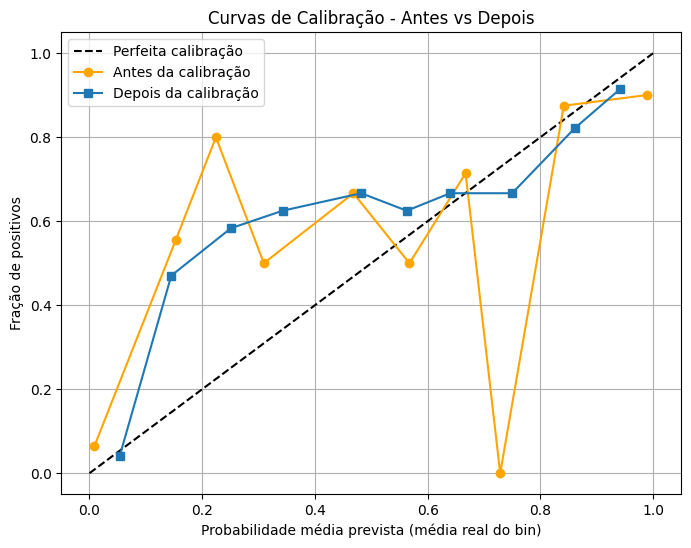

In [ ]:
# Exibir curvas de calibração antes e depois do scaling
plot_calibration_curves(probs_test, scaled_probs_test, labels_test,
                        title="Curvas de Calibração - Antes vs Depois",
                        save_path=os.path.join(experiment_dir,"calibracao_comparacao.png"))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def plot_reliability_comparison(probs_before, probs_after, labels,
                                title="Comparação de Calibração",
                                n_bins=10, save_path=None):
    """
    Plota dois reliability diagrams (barras + gap vermelho + linha diagonal)
    para comparar um modelo antes e depois da calibração.

    Parâmetros:
    - probs_before: probabilidades do modelo original (1D)
    - probs_after : probabilidades do modelo calibrado (1D)
    - labels      : rótulos verdadeiros (0 ou 1)
    - n_bins      : número de intervalos
    - save_path   : caminho para salvar a figura (opcional)
    """
    # Converte para arrays 1D
    probs_before = np.asarray(probs_before).flatten()
    probs_after  = np.asarray(probs_after).flatten()
    labels       = np.asarray(labels).flatten()

    # Função auxiliar para calcular métricas por bin
    def compute_bin_metrics(probs, labels, bins):
        n_bins = len(bins) - 1
        accuracies = np.zeros(n_bins)
        confidences = np.zeros(n_bins)
        counts = np.zeros(n_bins)

        for i in range(n_bins):
            if i == n_bins - 1:
                mask = (probs >= bins[i]) & (probs <= bins[i+1])
            else:
                mask = (probs >= bins[i]) & (probs < bins[i+1])
            n = np.sum(mask)
            if n == 0:
                continue
            acc = np.mean(labels[mask])
            conf = np.mean(probs[mask])
            accuracies[i] = acc
            confidences[i] = conf
            counts[i] = n

        return accuracies, confidences, counts

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    centers = (bins[:-1] + bins[1:]) / 2

    # Calcula para ambos os modelos
    # acc_before, conf_before, _ = compute_bin_metrics(probs_before, labels, bins)
    # acc_after,  conf_after,  _ = compute_bin_metrics(probs_after,  labels, bins)

    acc_before, conf_before, counts_before = compute_bin_metrics(probs_before, labels, bins)
    acc_after, conf_after, counts_after = compute_bin_metrics(probs_after, labels, bins)

    # Cria os subplots lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    width = 0.9 / n_bins  # largura das barras

    # Função para desenhar um subplot
    def draw_reliability_ax(ax, acc, conf, subtitle):
        # Barra azul (acurácia observada)
        ax.bar(centers, acc, width=width, color="royalblue", edgecolor="black",
               label="Acurácia observada")
        # Barra vermelha (gap)
        gap = np.abs(conf - acc)
        ax.bar(centers, gap, width=width, bottom=np.minimum(acc, conf),
               color="lightcoral", edgecolor="red", hatch="/", alpha=0.5,
               label="Gap (erro)")
        # Linha diagonal (perfeita calibração)
        ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label="Perfeita calibração")

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Confiança")
        ax.set_ylabel("Acurácia")
        ax.grid(True, linestyle=':')
        ax.legend(loc='lower right')
        ax.set_title(subtitle)


    draw_reliability_ax(ax1, acc_before, conf_before, "Antes da calibração")
    draw_reliability_ax(ax2, acc_after,  conf_after,  "Depois da calibração")

    # Ajustes finais
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


    print("\n" + "=" * 70)
    print("ANTES DA CALIBRAÇÃO")
    print("=" * 70)

    for i in range(n_bins):

        print(
            f"Bin {bins[i]:.1f}-{bins[i+1]:.1f} | "
            f"n={int(counts_before[i])} | "
            f"acurácia={acc_before[i]:.3f} | "
            f"confiança={conf_before[i]:.3f} | "
            f"gap={abs(conf_before[i] - acc_before[i]):.3f}"
        )

    print("\n" + "=" * 70)
    print("DEPOIS DA CALIBRAÇÃO")
    print("=" * 70)

    for i in range(n_bins):

        print(
            f"Bin {bins[i]:.1f}-{bins[i+1]:.1f} | "
            f"n={int(counts_after[i])} | "
            f"acurácia={acc_after[i]:.3f} | "
            f"confiança={conf_after[i]:.3f} | "
            f"gap={abs(conf_after[i] - acc_after[i]):.3f}"
        )

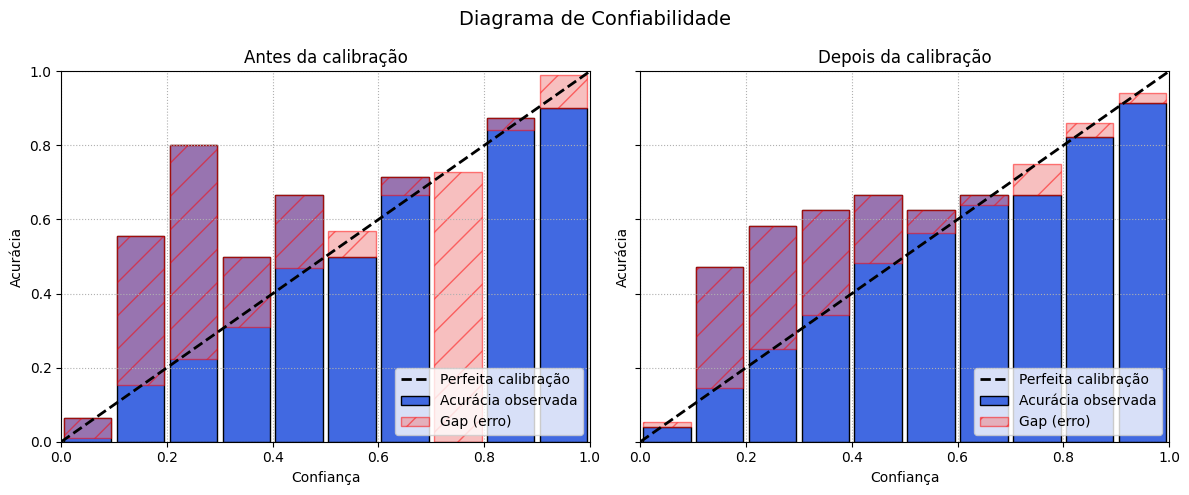


ANTES DA CALIBRAÇÃO
Bin 0.0-0.1 | n=370 | acurácia=0.065 | confiança=0.009 | gap=0.056
Bin 0.1-0.2 | n=9 | acurácia=0.556 | confiança=0.153 | gap=0.402
Bin 0.2-0.3 | n=5 | acurácia=0.800 | confiança=0.224 | gap=0.576
Bin 0.3-0.4 | n=2 | acurácia=0.500 | confiança=0.309 | gap=0.191
Bin 0.4-0.5 | n=3 | acurácia=0.667 | confiança=0.468 | gap=0.198
Bin 0.5-0.6 | n=4 | acurácia=0.500 | confiança=0.568 | gap=0.068
Bin 0.6-0.7 | n=7 | acurácia=0.714 | confiança=0.667 | gap=0.047
Bin 0.7-0.8 | n=1 | acurácia=0.000 | confiança=0.729 | gap=0.729
Bin 0.8-0.9 | n=8 | acurácia=0.875 | confiança=0.841 | gap=0.034
Bin 0.9-1.0 | n=301 | acurácia=0.900 | confiança=0.989 | gap=0.088

DEPOIS DA CALIBRAÇÃO
Bin 0.0-0.1 | n=349 | acurácia=0.040 | confiança=0.053 | gap=0.013
Bin 0.1-0.2 | n=17 | acurácia=0.471 | confiança=0.145 | gap=0.325
Bin 0.2-0.3 | n=12 | acurácia=0.583 | confiança=0.251 | gap=0.332
Bin 0.3-0.4 | n=8 | acurácia=0.625 | confiança=0.343 | gap=0.282
Bin 0.4-0.5 | n=3 | acurácia=0.667 | co

In [ ]:
# Plotar o reliability diagram comparativo
plot_reliability_comparison(probs_test, scaled_probs_test, labels_test,
                            title="Diagrama de Confiabilidade",
                            n_bins=10, save_path=os.path.join(experiment_dir, "reliability_comparison.png"))

In [ ]:
# Salvar a temperatura ótima no arquivo de configuração
import json

TEMPERATURE = T_opt

config_path = experiment_dir + "/config.json"

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

config["temperature"] = TEMPERATURE

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4, ensure_ascii=False)

In [ ]:
# Carregar a temperatura do arquivo config.json
with open(experiment_dir + "/config.json") as f:
    T = json.load(f)["temperature"]

print(f"Temperatura carregada: {T:.4f}")

Temperatura carregada: 1.7763


###### 3.4.3.1 Revalidação com Calibração

Confirmando que a aplicação da temperatura não modifica aclasse prevista nem a ordenação das amostras, as métricas de desempenho (Acurácia, F1, Precisão, Recall e AUC-ROC) permanecem inalteradas em relação à Seção 3.4.2.4.

In [ ]:
# Conf. métricas para avalição
from evaluate import load
from scipy.special import softmax
from sklearn.metrics import roc_auc_score, confusion_matrix
import numpy as np

# Carrega as métricas
metric_f1 = load("f1")
metric_acc = load("accuracy")
metric_precision = load("precision")
metric_recall = load("recall")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)
    probabilities = softmax(logits, axis=-1)

    f1 = metric_f1.compute(predictions=predictions, references=labels)["f1"]
    acc = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    pre = metric_precision.compute(predictions=predictions, references=labels, average="binary")["precision"]
    rec = metric_recall.compute(predictions=predictions, references=labels, average="binary")["recall"]

    roc_auc = roc_auc_score(labels, probabilities[:, 1])

    # Matriz de confusão: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "f1": f1,
        "accuracy": acc,
        "precision": pre,
        "recall": rec,
        "roc_auc": roc_auc,
        "specificity": specificity
    }

In [ ]:
# Usar a função compute_metrics
metrics = compute_metrics((scaled_logits_test, labels_test))
print(metrics)

{'f1': 0.8878504672897196, 'accuracy': 0.8985915492957747, 'precision': 0.8878504672897196, 'recall': 0.8878504672897196, 'roc_auc': np.float64(0.9523820964370661), 'specificity': np.float64(0.9074550128534704)}


In [ ]:
# Obter predições em formato de classe
y_true = labels_test
y_pred = (scaled_probs_test >= 0.5).astype(int)   # threshold padrão 0.5  # Converte probabilidades em classes (0 ou 1) com threshold 0.5

In [ ]:
# Exibir relatório de classificação detalhado
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       389
           1       0.89      0.89      0.89       321

    accuracy                           0.90       710
   macro avg       0.90      0.90      0.90       710
weighted avg       0.90      0.90      0.90       710



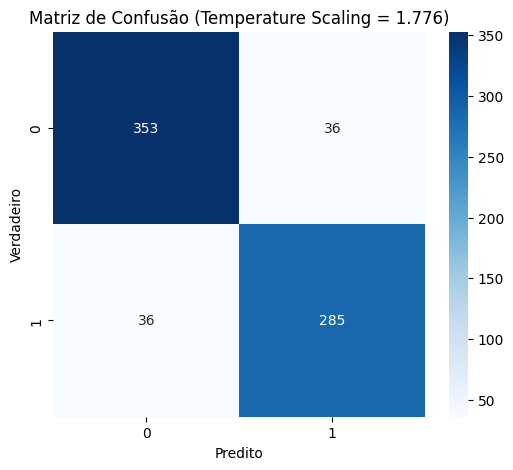

In [ ]:
# Plotar matriz de confusão
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.title(f'Matriz de Confusão (Temperature Scaling = {T:.3f})')
plt.savefig(os.path.join(experiment_dir, f'matriz_confusao_com_temperature_scaling_{T:.3f}.pdf'), bbox_inches='tight')
plt.show()

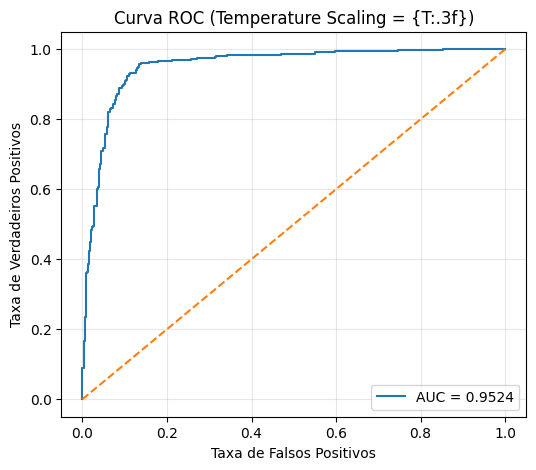

In [ ]:
# Curva ROC e AUC
fpr, tpr, thresholds = roc_curve(labels, probs_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC (Temperature Scaling = {T:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(os.path.join(experiment_dir, f'roc_curve_com_temperature_scaling_{T:.3f}.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
def predict(text="", T=1.0, model=model, tokenizer=tokenizer, device='cuda' if torch.cuda.is_available() else 'cpu', max_length=256):

    model.to(device)
    model.eval() # Coloca o modelo em modo de avaliação (desativa dropout)

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=max_length).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
        scaled_logits = logits / T
        probs = torch.softmax(scaled_logits, dim=1)

    # return probs
    confidence, pred = torch.max(probs, dim=1)
    return pred.item(), confidence.item()

In [ ]:
frase = "Ministros Barroso e Moraes mandaram fabricar chips em Taiwan para fraudar urnas eletrônicas"

In [ ]:
predict(frase)  # sem ajuste de temperatura

(1, 0.9933463335037231)

In [ ]:
predict(frase, T_opt)  # com ajuste de temperatura

(1, 0.9436531066894531)

#### 3.4.4 Limiar de decisão (threshold) da Classe 1 (Desinformação)

In [ ]:
experiment_dir = './experimentos\\rodada_20260725_203510'
test_df = pd.read_csv(os.path.join(experiment_dir, "test_df.csv"), encoding='utf-8-sig')
val_df = pd.read_csv(os.path.join(experiment_dir, "eval_df.csv"), encoding='utf-8-sig')

In [ ]:
model_path = "./experimentos\\rodada_20260725_203510\\UrnaBERTClassifier"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
# model.eval() # Coloca o modelo em modo de avaliação

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 631.18it/s, Materializing param=classifier.weight]                                      


In [ ]:
# Carregar a temperatura do arquivo config.json
with open(experiment_dir + "/config.json") as f:
    T_opt = json.load(f)["temperature"]

print(f"Temperatura carregada: {T_opt:.4f}")

Temperatura carregada: 1.7763


In [ ]:
from types import SimpleNamespace
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

def predict_DF(model, tokenizer, df, text_col="text", label_col="label",
             batch_size=32, temperature=1.0, return_probs=False):
    """
    Executa inferência com possibilidade de aplicar Temperature Scaling.

    Args:
        temperature (float): Fator de escala (T > 0). Padrão = 1.0 (sem efeito).
        return_probs (bool): Se True, retorna probabilidades (softmax com T);
                             se False, retorna as logits escalonadas (logits / T).
    """
    model.eval()
    device = next(model.parameters()).device

    # Tokenização
    encodings = tokenizer(
        df[text_col].tolist(),
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    dataset = TensorDataset(encodings["input_ids"], encodings["attention_mask"])
    dataloader = DataLoader(dataset, batch_size=batch_size)

    predictions = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            predictions.append(outputs.logits.cpu().numpy())

    # Concatena todas as logits
    logits = np.concatenate(predictions, axis=0)

    # Aplica Temperature Scaling (divide as logits por T)
    if temperature != 1.0:
        logits = logits / temperature

    # Se solicitado, converte para probabilidades via softmax
    if return_probs:
        # softmax ao longo da última dimensão (classes)
        probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
        predictions = probs
    else:
        predictions = logits

    # Labels reais (se existirem)
    label_ids = df[label_col].values if label_col in df.columns else None

    return SimpleNamespace(predictions=predictions, label_ids=label_ids)

In [ ]:
val_predictions = predict_DF(model=model, tokenizer=tokenizer, df=val_df, temperature=T_opt, return_probs=False)

In [ ]:
# Corrigindo o linspace (ex: 50 passos entre 0.5 e 0.99)
thresholds = np.linspace(0.5, 0.99, 50)  # 1000 pontos → passo ≈ 0.0005

best_thresh = 0.5
best_precision = 0.0
best_specificity = 0
RECALL_MINIMO = 0.55  # <-- 0.55

logits = val_predictions.predictions
probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
labels = val_predictions.label_ids

for thresh in thresholds:
    y_pred = (probs >= thresh).astype(int)

    if y_pred.sum() == 0:
        continue

    rec = recall_score(labels, y_pred, zero_division=0)
    prec = precision_score(labels, y_pred, zero_division=0)

    # Matriz de confusão
    tn, fp, fn, tp = confusion_matrix(labels, y_pred, labels=[0, 1]).ravel()

    # Especificidade = TN / (TN + FP)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Aplica a restrição e maximiza a PRECISÃO (argmax Precision)
    if rec >= RECALL_MINIMO:
        if prec > best_precision:
            best_precision = prec
            best_thresh = thresh
            best_specificity = specificity

print(f"Limiar escolhido: {best_thresh:.4f} | Recall: >= {RECALL_MINIMO} | Precisão: {best_precision:.4f} | Especificidade: {best_specificity:.4f}")

Limiar escolhido: 0.9400 | Recall: >= 0.55 | Precisão: 0.9750 | Especificidade: 0.9865


In [ ]:
test_predictions = predict_DF(model=model, tokenizer=tokenizer, df=test_df, temperature=T_opt, return_probs=False)

In [ ]:
# Carrega as métricas
metric_f1 = load("f1")
metric_acc = load("accuracy")
metric_precision = load("precision")
metric_recall = load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Temperature scaling: divide os logits pela temperatura
    scaled_logits = logits

    # Probabilidades calibradas
    probabilities = softmax(scaled_logits, axis=-1)

    # Predição com limiar na probabilidade da classe 1
    predictions = (probabilities[:, 1] >= THRESHOLD).astype(int)

    # Cálculo das métricas (todas com average='binary')
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")["f1"]
    acc = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    pre = metric_precision.compute(predictions=predictions, references=labels, average="binary")["precision"]
    rec = metric_recall.compute(predictions=predictions, references=labels, average="binary")["recall"]

    roc_auc = roc_auc_score(labels, probabilities[:, 1])

    # Matriz de confusão
    tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "f1": f1,
        "accuracy": acc,
        "precision": pre,
        "recall": rec,
        "roc_auc": roc_auc,
        "specificity": specificity
    }

In [ ]:
# Extrair os logits e rótulos no conjunto de teste
logits = test_predictions.predictions
true_labels = test_predictions.label_ids


In [ ]:
# aplicar modelo ao conjunto de teste (ORIGINAL)
THRESHOLD = 0.5       # limiar para classe positiva (1) PADRÃO

# Usar a função compute_metrics
metrics = compute_metrics((logits, true_labels))
print(metrics)

{'f1': 0.8878504672897196, 'accuracy': 0.8985915492957747, 'precision': 0.8878504672897196, 'recall': 0.8878504672897196, 'roc_auc': np.float64(0.9523820964370661), 'specificity': np.float64(0.9074550128534704)}


In [ ]:
# aplicar modelo ao conjunto de teste (COM THRESHOLD)
THRESHOLD = best_thresh      # limiar para classe positiva (1)

# Usar a função compute_metrics
metrics = compute_metrics((logits, true_labels))
print(metrics)

{'f1': 0.6954813359528488, 'accuracy': 0.7816901408450704, 'precision': 0.9414893617021277, 'recall': 0.5514018691588785, 'roc_auc': np.float64(0.9523820964370661), 'specificity': np.float64(0.9717223650385605)}


In [ ]:
# Obter predições em formato de classe
y_pred = np.argmax(test_predictions.predictions, axis=1)
y_true = test_predictions.label_ids

In [ ]:
# Relatório de classificação detalhado (ORIGINAL)
print("\nRelatório de classificação:")
print(classification_report(y_true, y_pred, target_names=['Classe 0', 'Classe 1']))


Relatório de classificação:
              precision    recall  f1-score   support

    Classe 0       0.91      0.91      0.91       389
    Classe 1       0.89      0.89      0.89       321

    accuracy                           0.90       710
   macro avg       0.90      0.90      0.90       710
weighted avg       0.90      0.90      0.90       710



In [ ]:
# Calcular probabilidades da classe positiva (classe 1)
probs_class1 = softmax(logits, axis=1)[:, 1]

# Gerar predições discretas usando o limiar
pred_labels = (probs_class1 >= best_thresh).astype(int)

In [ ]:
# Relatório de classificação detalhado (COM THRESHOLD)
print("\nRelatório de classificação:")
print(classification_report(true_labels, pred_labels, target_names=['Classe 0', 'Classe 1']))


Relatório de classificação:
              precision    recall  f1-score   support

    Classe 0       0.72      0.97      0.83       389
    Classe 1       0.94      0.55      0.70       321

    accuracy                           0.78       710
   macro avg       0.83      0.76      0.76       710
weighted avg       0.82      0.78      0.77       710



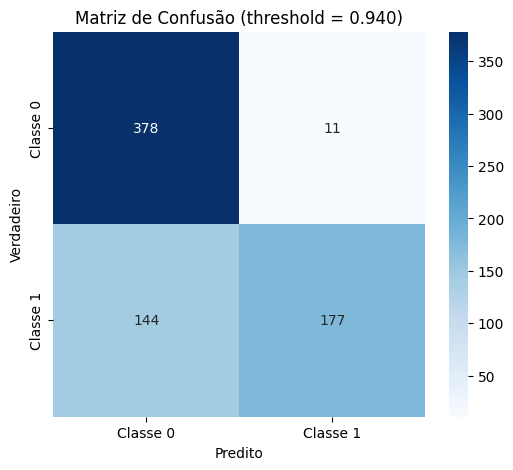

In [ ]:
# Matriz de confusão
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Classe 0', 'Classe 1'],
            yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title(f'Matriz de Confusão (threshold = {best_thresh:.3f})')
plt.savefig(os.path.join(experiment_dir, f'matriz_confusao_thresh_{best_thresh:.3f}.pdf'), bbox_inches='tight')
plt.show()

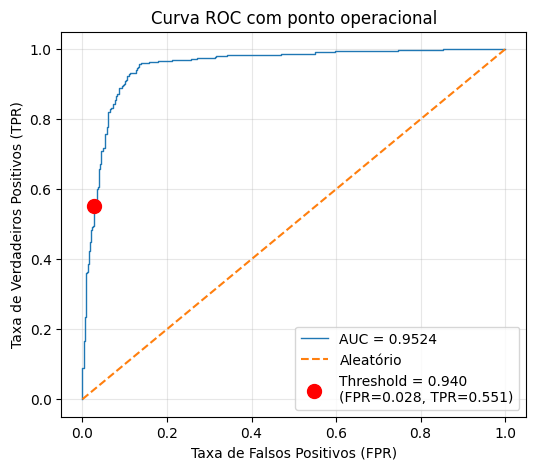

In [ ]:
# Curva ROC com destaque do ponto do limiar
fpr_full, tpr_full, _ = roc_curve(true_labels, probs_class1)
roc_auc = metrics['roc_auc']

# Calcula FPR e TPR especificamente para o limiar escolhido
tn, fp, fn, tp = cm.ravel()
fpr_thresh = fp / (fp + tn) if (fp + tn) > 0 else 0.0
tpr_thresh = tp / (tp + fn) if (tp + fn) > 0 else 0.0

plt.figure(figsize=(6,5))
plt.plot(fpr_full, tpr_full, label=f'AUC = {roc_auc:.4f}', linewidth=1)
plt.plot([0, 1], [0, 1], linestyle='--',  label='Aleatório')
plt.scatter(fpr_thresh, tpr_thresh, color='red', s=100, zorder=5,
            label=f'Threshold = {best_thresh:.3f}\n(FPR={fpr_thresh:.3f}, TPR={tpr_thresh:.3f})')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC com ponto operacional')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig(os.path.join(experiment_dir, f'roc_curve_thresh_{best_thresh:.3f}_auc_{roc_auc:.4f}.pdf'), bbox_inches='tight')
plt.show()

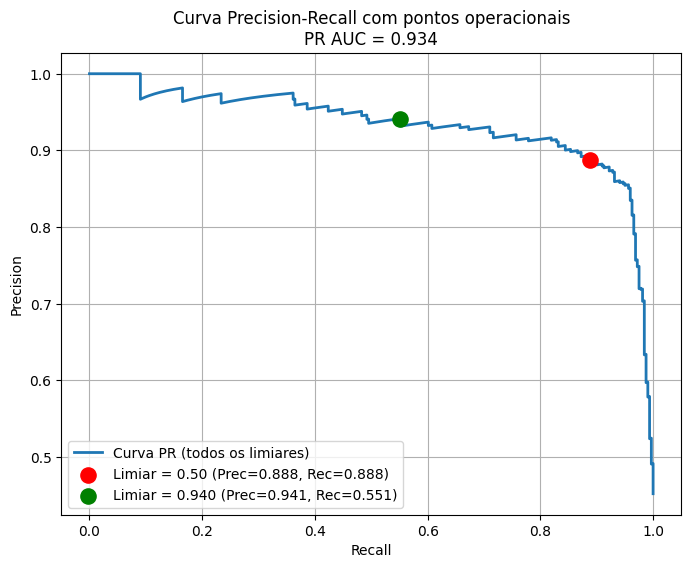

In [ ]:
# true_labels: rótulos reais (0/1)
# probs_class1: probabilidades da classe 1

# Calcular a curva PR completa
precision, recall, thresholds = precision_recall_curve(true_labels, probs_class1)

# Calcular a PR AUC (área sob a curva)
pr_auc = average_precision_score(true_labels, probs_class1)

# Definir os limiares de interesse
threshold_original = 0.5
threshold_otimizado = best_thresh  # valor encontrado na validação

# Encontrar os pontos correspondentes na curva
def find_operating_point(probs, y_true, threshold):
    pred = (probs >= threshold).astype(int)
    prec = precision_score(y_true, pred, zero_division=0)
    rec = recall_score(y_true, pred, zero_division=0)
    return prec, rec

prec_orig, rec_orig = find_operating_point(probs_class1, true_labels, threshold_original)
prec_opt, rec_opt = find_operating_point(probs_class1, true_labels, threshold_otimizado)

# Plotar a curva com os pontos destacados
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, linewidth=2, label='Curva PR (todos os limiares)')
plt.scatter(rec_orig, prec_orig, color='red', s=120, zorder=5,
            label=f'Limiar = {threshold_original:.2f} (Prec={prec_orig:.3f}, Rec={rec_orig:.3f})')
plt.scatter(rec_opt, prec_opt, color='green', s=120, zorder=5,
            label=f'Limiar = {threshold_otimizado:.3f} (Prec={prec_opt:.3f}, Rec={rec_opt:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Curva Precision-Recall com pontos operacionais\nPR AUC = {pr_auc:.3f}')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f"Limiar 0.5    -> Precisão: {prec_orig:.4f}, Recall: {rec_orig:.4f}, F1: {2*prec_orig*rec_orig/(prec_orig+rec_orig):.4f}")
print(f"Limiar ótimo  -> Precisão: {prec_opt:.4f}, Recall: {rec_opt:.4f}, F1: {2*prec_opt*rec_opt/(prec_opt+rec_opt):.4f}")

Limiar 0.5    -> Precisão: 0.8879, Recall: 0.8879, F1: 0.8879
Limiar ótimo  -> Precisão: 0.9415, Recall: 0.5514, F1: 0.6955


In [ ]:
# Função de predição com temperatura e threshold e retorno opcional de todas as informações
from typing import Dict, Union


def predict(
    text: str = '',
    T: float = 1.0,
    threshold: float = 0.5,
    type_return: str = None,
    model=model,
    tokenizer=tokenizer,
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu',
    max_length: int = 256
) -> Union[tuple, Dict]:
    """
    Realiza a predição com ajuste de temperatura e regra de decisão com threshold.

    Args:
        text (str): Texto de entrada.
        T (float): Temperatura para suavização das probabilidades (softmax).
        threshold (float): Limiar mínimo para atribuir classe 1.
        type_return (str, optional): Se for 'all', retorna um dicionário com todas as informações.
        model, tokenizer, device, max_length: parâmetros do modelo.

    Returns:
        Se type_return for None: tupla (pred, confidence)
        Se type_return for 'all': dicionário com chaves:
            - 'prediction': classe predita com threshold (0 ou 1)
            - 'confidence': confiança da classe escolhida (após threshold)
            - 'prob_class_1': probabilidade da classe 1 (com temperatura)
            - 'prob_class_0': probabilidade da classe 0 (com temperatura)
            - 'original_prediction': classe predita sem threshold (argmax)
            - 'original_confidence': confiança da predição original
            - 'temperature': temperatura usada
            - 'threshold': threshold usado
    """
    model.to(device)
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=max_length).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits

        # Probabilidades com temperatura
        scaled_logits = logits / T
        probs = torch.softmax(scaled_logits, dim=1)
        prob_0 = round(probs[0, 0].item(), 4)
        prob_1 = round(probs[0, 1].item(), 4)

        # Decisão com threshold
        if prob_1 >= threshold:
            pred = 1
            confidence = prob_1
        else:
            pred = 0
            confidence = prob_0

        # Se não for solicitado 'all', retorna apenas a tupla básica
        if type_return != 'all':
            return pred, confidence

        # ---- Retorno completo (sempre calculado) ----
        # Probabilidades originais (sem temperatura)
        probs_orig = torch.softmax(logits, dim=1)
        # Predição original (sem threshold, apenas argmax)
        confidence_o, pred_o = torch.max(probs_orig, dim=1)
        confidence_o = confidence_o.item()
        pred_o = pred_o.item()

        # Monta dicionário com todas as informações
        result = {
            'prediction': pred,
            'confidence': confidence,
            'prob_class_1': prob_1,
            'prob_class_0': prob_0,
            'original_prediction': pred_o,
            'original_confidence': round(confidence_o, 4),
            'temperature': T,
            'threshold': threshold
        }
        return result

In [ ]:
predict('FRAUDE NA URNA! ESTÃO ROUBANDO A ELEIÇÃO DO LULA! COMPARTILHE AGORA!' , T=T_opt, threshold=best_thresh, type_return='all')

{'prediction': 1,
 'confidence': 0.9473,
 'prob_class_1': 0.9473,
 'prob_class_0': 0.0527,
 'original_prediction': 1,
 'original_confidence': 0.9941,
 'temperature': 1.7762569189071655,
 'threshold': np.float64(0.94)}

In [ ]:
predict('FRAUDE NA URNA! ESTÃO ROUBANDO A ELEIÇÃO DO LULA! COMPARTILHE AGORA!' , T=T_opt, threshold=best_thresh, type_return='all')

{'prediction': 1,
 'confidence': 0.9473,
 'prob_class_1': 0.9473,
 'prob_class_0': 0.0527,
 'original_prediction': 1,
 'original_confidence': 0.9941,
 'temperature': 1.7762569189071655,
 'threshold': np.float64(0.94)}

In [ ]:
predict('fraude na urna! estão roubando a eleição do lula! compartilhe agora!', T=T_opt, threshold=best_thresh, type_return='all')

{'prediction': 1,
 'confidence': 0.9522,
 'prob_class_1': 0.9522,
 'prob_class_0': 0.0478,
 'original_prediction': 1,
 'original_confidence': 0.9951,
 'temperature': 1.7762569189071655,
 'threshold': np.float64(0.94)}

In [ ]:
predict('FRAUDE NA URNA! ESTÃO ROUBANDO A ELEIÇÃO DO GUGU! COMPARTILHE AGORA!', T=T_opt, threshold=best_thresh, type_return='all')

{'prediction': 1,
 'confidence': 0.9508,
 'prob_class_1': 0.9508,
 'prob_class_0': 0.0492,
 'original_prediction': 1,
 'original_confidence': 0.9948,
 'temperature': 1.7762569189071655,
 'threshold': np.float64(0.94)}

In [ ]:
predict('fraude na urna! estão roubando a eleição do bolsonaro! compartilhe agora!', T=T_opt, threshold=best_thresh, type_return='all')

{'prediction': 1,
 'confidence': 0.9536,
 'prob_class_1': 0.9536,
 'prob_class_0': 0.0464,
 'original_prediction': 1,
 'original_confidence': 0.9954,
 'temperature': 1.7762569189071655,
 'threshold': np.float64(0.94)}

In [ ]:
predict('fraude na urna! estão roubando a eleição do Ciro Gomes! compartilhe agora!', T=T_opt, threshold=best_thresh, type_return='all')

{'prediction': 1,
 'confidence': 0.9514,
 'prob_class_1': 0.9514,
 'prob_class_0': 0.0486,
 'original_prediction': 1,
 'original_confidence': 0.9949,
 'temperature': 1.7762569189071655,
 'threshold': np.float64(0.94)}

In [ ]:
predict('fraude na urna! estão roubando a eleição do Simone Tebet! compartilhe agora!', T=T_opt, threshold=best_thresh, type_return='all')

{'prediction': 1,
 'confidence': 0.9527,
 'prob_class_1': 0.9527,
 'prob_class_0': 0.0473,
 'original_prediction': 1,
 'original_confidence': 0.9952,
 'temperature': 1.7762569189071655,
 'threshold': np.float64(0.94)}

In [ ]:
predict('AS URNAS ELETRONICAS SÃO SEGURAS', T=T_opt, threshold=best_thresh, type_return='all')

{'prediction': 0,
 'confidence': 0.9058,
 'prob_class_1': 0.0942,
 'prob_class_0': 0.9058,
 'original_prediction': 0,
 'original_confidence': 0.9824,
 'temperature': 1.7762569189071655,
 'threshold': np.float64(0.94)}

In [ ]:
predict('as urnas eletronicas são seguras', T=T_opt, threshold=best_thresh, type_return='all')

{'prediction': 0,
 'confidence': 0.8174,
 'prob_class_1': 0.1826,
 'prob_class_0': 0.8174,
 'original_prediction': 0,
 'original_confidence': 0.9348,
 'temperature': 1.7762569189071655,
 'threshold': np.float64(0.94)}

In [ ]:
predict('a urna e frab', T=T_opt, type_return='all') #erro

{'prediction': 0,
 'confidence': 0.9419,
 'prob_class_1': 0.0581,
 'prob_class_0': 0.9419,
 'original_prediction': 0,
 'original_confidence': 0.993,
 'temperature': 1.7762569189071655,
 'threshold': 0.5}

In [ ]:
# Salvar o threshold ótimo no arquivo de configuração
import json

THRESHOLD = best_thresh

config_path = experiment_dir + "/config.json"

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

config["threshold"] = THRESHOLD

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4, ensure_ascii=False)

In [ ]:
# Carregar a temperatura do arquivo config.json
with open(experiment_dir + "/config.json", "r") as f:
    config = json.load(f)
    T = config["temperature"]
    threshold = config["threshold"]

print(f"Temperatura carregada: {T:.4f}")
print(f"Threshold carregado: {threshold:.4f}")

Temperatura carregada: 1.7763
Threshold carregado: 0.9400


#### 3.4.5 Usar modelo

In [ ]:
experiment_dir = '/content/drive/MyDrive/TCC//experimentos/rodada_20260725_203510/'

In [ ]:
model_path = experiment_dir + "/UrnaBERTClassifier"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
# model.eval() # Coloca o modelo em modo de avaliação

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

In [ ]:
# Carregar a temperatura do arquivo config.json
with open(experiment_dir + "/config.json", "r") as f:
    config = json.load(f)   # parse once
    T = config["temperature"]
    threshold = config["threshold"]

print(f"Temperatura carregada: {T:.4f}")
print(f"Threshold carregado: {threshold:.4f}")

Temperatura carregada: 1.7763
Threshold carregado: 0.9400


In [ ]:
df0 = pd.read_csv('/content/drive/MyDrive/TCC/Data/TUEBR22.csv')
text = 'preprocessed_tweet'

In [ ]:
# ------------------------------------------------------------
# Função de predição em lote (batch)
# ------------------------------------------------------------
def predict_batch(
    texts: list,
    model,
    tokenizer,
    T: float = 1.0,
    threshold: float = 0.5,
    batch_size: int = 64,
    max_length: int = 256,
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    Processa uma lista de textos em lotes e retorna:
        - predictions: lista de 0/1
        - confidences: lista de confianças (float) com 4 casas decimais
    """
    model.to(device)
    model.eval()

    if not texts:
        return [], []

    all_preds = []
    all_confs = []

    # Número total de lotes
    total_batches = (len(texts) + batch_size - 1) // batch_size
    # Loop com barra de progresso
    for i in tqdm(range(0, len(texts), batch_size), total=total_batches, desc="Predição em lotes"):
        batch_texts = texts[i:i + batch_size]

        # Tokeniza o lote inteiro com padding dinâmico
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=max_length
        ).to(device)

        with torch.no_grad():
            logits = model(**inputs).logits    # (batch_size, 2)
            scaled_logits = logits / T         # Calibrando
            probs = torch.softmax(scaled_logits, dim=1)

            prob_1 = probs[:, 1]                # probabilidade da classe 1

            preds = (prob_1 >= threshold).int().cpu().numpy()
            prob_1_np = prob_1.cpu().numpy()

             # Confiança: se pred==1, usa prob_1; senão, usa prob_0 (1 - prob_1)
            confs = np.where(preds == 1, prob_1_np, 1 - prob_1_np)

            # Arredonda para 4 casas dentro da função
            confs = np.round(confs, decimals=4)

            all_preds.extend(preds.tolist())
            all_confs.extend(confs.tolist())

    return all_preds, all_confs


# Aplicação no DataFrame
# Normaliza textos
df0[text] = df0[text].fillna('').astype(str)

# Máscara para textos não vazios
mask = df0[text].str.strip().ne('')

# Inicializa colunas (já com valores padrão para vazios)
df0['is_disinformation'] = 0
df0['confidence'] = np.nan

# Se houver pelo menos um texto não vazio, processa em lote
if mask.any():
    textos_validos = df0.loc[mask, text].tolist()


    preds, confs = predict_batch(
        textos_validos,
        model=model,
        tokenizer=tokenizer,
        T=T,              # Ajuste para a sua variável T
        threshold=threshold,
        batch_size=64     # ajuste VRAM
    )

    # Atribui apenas às linhas com texto não vazio
    df0.loc[mask, 'is_disinformation'] = preds


    # ARREDONDAMENTO FINAL para 4 casas decimais
    df0.loc[mask, 'confidence'] = np.round(confs, decimals=4)

# ------------------------------------------------------------
# Arredonda toda a coluna para 4 casas
# (Isso corrige qualquer resquício de erro de ponto flutuante)
# ------------------------------------------------------------
df0['confidence'] = df0['confidence'].round(4)

# (Linhas vazias já permanecem com is_disinformation = 0 e confidence = 0.0)
df0['is_disinformation'] = df0['is_disinformation'].astype('int64')

Predição em lotes: 100%|██████████| 1738/1738 [31:31<00:00,  1.09s/it]


In [ ]:
# Salvando
df0.to_csv("/content/drive/MyDrive/TCC/Data/TUEBR22.csv", index=False)

In [ ]:
df0

,tweet_id,raw_tweet,preprocessed_tweet,urls,hashtags,mentions,emojis,is_retweet,original_author,is_truncated,...,reliability,average_distance,automation_level,sentiment,entities,clean_tweet,topic_num,topic,is_disinformation,confidence
0,TWEET_C45367E285D4,"O Instagram agora virou urna eletrônica, todo ...","O Instagram agora virou urna eletrônica, todo ...",NaN,[],[],[],0,NaN,0,...,0.60,270.0,Baixo,Neutro,"{'PESSOAS': ['Instagram'], 'LOCAIS': [], 'ORGA...",instagram virar urna eletronico mundo votar,0.0,Urna Eletrônica,0,0.8997
1,TWEET_9567BD4E825F,@EXT_USER_07E29D7074A5 Eu sempre voto logo pel...,Eu sempre voto logo pela manhã já deixo meu vo...,NaN,[],['@EXT_USER_07E29D7074A5'],[],0,NaN,0,...,0.66,219.0,Baixo,Neutro,"{'PESSOAS': [], 'LOCAIS': [], 'ORGANIZAÇÕES': ...",votar manha voto confirmar urna eletronico com...,0.0,Urna Eletrônica,0,0.9523
2,TWEET_227633D3B91C,@EXT_USER_C3D65E0C11D1 @EXT_USER_9740BCEF47C9 ...,Vai no Google e busca Simone / urna eletrônica...,NaN,[],"['@EXT_USER_C3D65E0C11D1', '@EXT_USER_9740BCEF...",['🔍'],0,NaN,1,...,0.61,262.0,Baixo,Neutro,"{'PESSOAS': ['Simone'], 'LOCAIS': [], 'ORGANIZ...",google buscar simone urna eletronico terra ind...,0.0,Urna Eletrônica,0,0.8684
3,TWEET_3BC0DF32A97F,A urna eletrônica é segura? Confira neste vídeo.,A urna eletrônica é segura? Confira neste vídeo.,['https://www.youtube.com/watch?v=qlPXj6HkxOo&...,[],[],[],0,NaN,0,...,0.61,257.0,Baixo,Neutro,"{'PESSOAS': [], 'LOCAIS': [], 'ORGANIZAÇÕES': ...",urna eletronico seguro confira video,5.0,Mídias Sociais,0,0.9200
4,TWEET_3CB05BDC9D52,@USER_E64C1091441C @EXT_USER_8C93DA509833 @USE...,"Opa. E seu vizinho chinês, pode votar? Tem urn...",NaN,[],"['@USER_E64C1091441C', '@EXT_USER_8C93DA509833...",[],0,NaN,0,...,0.60,273.0,Baixo,Neutro,"{'PESSOAS': [], 'LOCAIS': [], 'ORGANIZAÇÕES': ...",opa vizinho chines votar urna eletronico celul...,0.0,Urna Eletrônica,0,0.8787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111212,TWEET_DE1CC0DE93AB,RT @USER_FB38FB8D335C: Quando o meio para depo...,Quando o meio para depositar o voto não é a sa...,['https://twitter.com/AugustoNPistola/status/1...,[],[],[],1,@USER_FB38FB8D335C,0,...,0.76,142.0,Baixo,Neutro,"{'PESSOAS': [], 'LOCAIS': ['Ministro Barroso']...",depositar voto sacrossanto urna eletronico min...,0.0,Urna Eletrônica,0,0.1828
111213,TWEET_903CDFA15A3B,RT @USER_FB38FB8D335C: Quando o meio para depo...,Quando o meio para depositar o voto não é a sa...,['https://twitter.com/AugustoNPistola/status/1...,[],[],[],1,@USER_FB38FB8D335C,0,...,0.71,179.0,Baixo,Neutro,"{'PESSOAS': [], 'LOCAIS': ['Ministro Barroso']...",depositar voto sacrossanto urna eletronico min...,0.0,Urna Eletrônica,0,0.1828
111214,TWEET_5F74C7DC8B8A,@USER_7751DB7A3A12 Na minha cessão não registr...,"Na minha cessão não registra ele, ele só ficam...",NaN,[],['@USER_7751DB7A3A12'],[],0,NaN,0,...,0.72,171.0,Baixo,Negativo,"{'PESSOAS': [], 'LOCAIS': [], 'ORGANIZAÇÕES': ...",cessao registrar responsavel predio informar e...,0.0,Urna Eletrônica,0,0.8080
111215,TWEET_3F2FB6CFA826,@USER_9EFC4F694364 @USER_45D2CEC77707 Pergunta...,"Pergunta sincera, porque não teve todo esse tr...",NaN,[],"['@USER_9EFC4F694364', '@USER_45D2CEC77707']",[],0,NaN,0,...,0.84,94.0,Baixo,Negativo,"{'PESSOAS': [], 'LOCAIS': [], 'ORGANIZAÇÕES': ...",perguntar sincero tramite urna ganhar urna per...,0.0,Urna Eletrônica,0,0.3079


In [ ]:
df0['is_disinformation'].value_counts()

,count
is_disinformation,
0,101282
1,9935


In [ ]:
df0['is_disinformation'].value_counts()

,count
is_disinformation,
0,101282
1,9935


In [ ]:
df0.loc[111174]

,111174
tweet_id,TWEET_4B16AEAC1921
raw_tweet,@EXT_USER_0C9CE7A6ADEE Urna não fala...
preprocessed_tweet,Urna não fala...
urls,NaN
hashtags,[]
mentions,['@EXT_USER_0C9CE7A6ADEE']
emojis,[]
is_retweet,0
original_author,NaN
is_truncated,1


In [ ]:
df0.drop_duplicates(subset='text', inplace=True)

In [ ]:
df0['is_disinformation'].value_counts()

,count
is_disinformation,
0,41636
1,4409


# **4. Análise de Redes**

### **Importando Bibliotecas e Carregando Dataset:**

Nesta etapa da pesquisa, voltada para a construção e análise estrutural da rede, utilizaram-se as seguintes bibliotecas Python:

* **Pandas (`pandas`)**: Utilizada para carregar o dataset, realizar filtragens, agregar métricas por usuário (médias, contagens e modas) e consolidar os dados dos nós e arestas em DataFrames auxiliares.

* **NetworkX (`networkx`)**: Biblioteca central para a análise de redes. Foi empregada para construir o grafo multidirecionado (`MultiDiGraph`), extrair o componente gigante, calcular métricas de grau (`indegree`, `outdegree`) e aplicar o algoritmo de detecção de comunidades Louvain. Também foi usada para exportar o grafo no formato GEXF, compatível com o Gephi.

* **NumPy (`numpy`)**: Empregada em operações numéricas e arredondamentos de métricas durante as agregações realizadas no Pandas.

* **AST (`ast.literal_eval`)**: Utilizada para converter colunas com representações textuais de listas (como `mentions` e `hashtags`) em objetos Python, permitindo a iteração sobre esses dados para criação de arestas e cálculo de atributos agregados.

* **Collections (`collections.Counter`)**: Usada para contabilizar a frequência de hashtags, tanto por usuário quanto por cluster, auxiliando na caracterização temática dos grupos identificados pelo Louvain.

In [ ]:
import pandas as pd
import networkx as nx
import numpy as np
from collections import Counter
import ast

path = '/content/drive/MyDrive/TCC/Data/Network/'

# Carreagando dataset
df = pd.read_csv('/content/drive/MyDrive/TCC/Data/TUEBR22.csv',
                 sep=",", low_memory=False,
                 parse_dates=['tweet_created_at', 'user_created_at', 'collection_date'])
#df = df[:80000]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111217 entries, 0 to 111216
Data columns (total 47 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tweet_id              111217 non-null  object        
 1   raw_tweet             111217 non-null  object        
 2   preprocessed_tweet    111193 non-null  object        
 3   urls                  17025 non-null   object        
 4   hashtags              111217 non-null  object        
 5   mentions              111217 non-null  object        
 6   emojis                111217 non-null  object        
 7   is_retweet            111217 non-null  int64         
 8   original_author       69620 non-null   object        
 9   is_truncated          111217 non-null  int64         
 10  is_upper              111217 non-null  int64         
 11  tweet_length          111217 non-null  int64         
 12  has_keywords          111217 non-null  int64         
 13 

### 4.1 *Exportar Estrutura da Rede*

**Nesta etapa, procede-se à extração da estrutura da rede, a qual será analisada posteriormente na ferramenta Gephi.**

Referências:

https://repositorio.ufba.br/bitstream/ri/24759/4/AnaliseDeRedesPDF.pdf

https://www.youtube.com/watch?v=_irKSVT3caA

https://www.youtube.com/watch?v=gxch8mc4B3M

https://www.youtube.com/watch?v=GXtbL8avpik&t=790s

https://www.youtube.com/watch?v=gjUxTAtWRG4

https://www.toptal.com/developers/r/social-network-analysis-in-r-gephi-tutorial

https://www.toptal.com/developers/r/social-network-analysis-in-r-gephi-2

https://www.toptal.com/developers/r/social-network-analysis-in-r-gephi-3

https://doug.specht.co.uk/twitter-research/visualising-twitter-data-with-gephi/

https://mdlutoronto.github.io/gephi-visualize-network-dataset/8-h-export-visualizations-as-interactive-web-pages/

https://medium.com/@vespinozag/how-to-publish-your-gephi-network-to-the-web-7d6a5f84076d

https://files.cercomp.ufg.br/weby/up/771/o/Gephi-Guia_B%C3%A1sico_de_Interface.pdf

https://files.cercomp.ufg.br/weby/up/771/o/Apresenta%C3%A7%C3%A3o_minicurso.pdf

https://escoladedados.org/tutoriais/visualizando-redes-do-youtube-com-o-gephi/

https://james.ashford.phd/2023/02/24/how-to-create-simple-dynamic-graphs-in-gephi/



**Para a análise da estrutura da rede e para as análises subsequentes, os tweets que não possuíam classificação referente ao nível de automação, bem como os tweets vazios, foram excluídos.**

In [ ]:
# Remove valores nulos e strings vazias
df = df[df['preprocessed_tweet'].notna()]
df = df[df['score_final'].notna()]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110978 entries, 0 to 111216
Data columns (total 47 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tweet_id              110978 non-null  object        
 1   raw_tweet             110978 non-null  object        
 2   preprocessed_tweet    110978 non-null  object        
 3   urls                  16986 non-null   object        
 4   hashtags              110978 non-null  object        
 5   mentions              110978 non-null  object        
 6   emojis                110978 non-null  object        
 7   is_retweet            110978 non-null  int64         
 8   original_author       69564 non-null   object        
 9   is_truncated          110978 non-null  int64         
 10  is_upper              110978 non-null  int64         
 11  tweet_length          110978 non-null  int64         
 12  has_keywords          110978 non-null  int64         
 13  twee

In [ ]:
# Conjunto de usuários internos (que publicaram algo no corpus)
internal_users = set(df['user_id'].dropna().unique())
print(f"Usuários internos: {len(internal_users)}")

Usuários internos: 84473


In [ ]:
# 0. CONSTRUIR A REDE

# MultiDiGraph permite múltiplas interações entre os mesmos usuários
G = nx.MultiDiGraph()

# Configuração temporal do GEXF
G.graph["mode"] = "dynamic"
G.graph["timeformat"] = "dateTime"

# Adiciona todos os usuários internos como nós
usuarios = df["user_id"].dropna().unique()
G.add_nodes_from(usuarios)

# Dicionário para registrar quando cada usuário surge na rede
primeira_interacao = {}

# Função para registrar a primeira interação de um usuário
def registrar_primeira_interacao(user, data):
    if pd.isna(data) or data is None:
        return

    # Se ainda não existe registro ou encontrou uma data mais antiga
    if user not in primeira_interacao or data < primeira_interacao[user]:
        primeira_interacao[user] = data

# 1. FUNÇÕES AUXILIARES
def clean_attr(value, default=0):
    """
    Limpa valores NaN/None.
    """
    try:
        if pd.isna(value):
            return default
    except (TypeError, ValueError):
        pass

    if value is None:
        return default

    return value


def parse_lista(valor):
    """
    Converte diferentes formatos de listas armazenadas
    como texto em uma lista Python.
    """

    if valor is None:
        return []

    try:
        if pd.isna(valor):
            return []
    except (TypeError, ValueError):
        pass

    # Já é lista
    if isinstance(valor, list):
        return valor

    # String
    if isinstance(valor, str):

        valor = valor.strip()

        if not valor:
            return []

        try:
            resultado = ast.literal_eval(valor)

            if isinstance(resultado, list):
                return resultado

        except (ValueError, SyntaxError):
            pass

        if "," in valor:
            return [x.strip() for x in valor.split(",") if x.strip()]

        return [valor]

    return []


# 2. CRIAR AS ARESTAS E REGISTRAR A ENTRADA DOS USUÁRIOS
# Itera sobre as linhas do DataFrame
for row in df.itertuples(index=False):

    source = row.user_id

    # Segurança: verifica se o usuário é interno
    if source not in G.nodes:
        continue

    # Data do tweet
    data_tweet = row.tweet_created_at

    # RETWEETS
    if row.is_retweet == 1 and pd.notna(row.original_author):

        target = row.original_author

        # Só considera interações entre usuários internos
        if target in G.nodes:

            # Data como atributo informativo da aresta
            data_string = data_tweet.isoformat() if pd.notna(data_tweet) else None

            G.add_edge(source, target, tipo="retweet", timestamp=data_string)

            # Registra o momento em que ambos participam da rede
            registrar_primeira_interacao(source, data_tweet)
            registrar_primeira_interacao(target, data_tweet)


    # MENÇÕES
    if pd.notna(row.mentions):

        try:
            menc = (
                ast.literal_eval(row.mentions)
                if isinstance(row.mentions, str)
                else row.mentions
            )
        except (ValueError, SyntaxError):
            menc = []

        if isinstance(menc, list):

            for m in menc:

                if m in G.nodes:

                    data_string = (
                        data_tweet.isoformat() if pd.notna(data_tweet) else None
                    )

                    G.add_edge(source, m, tipo="menção", timestamp=data_string)

                    registrar_primeira_interacao(source, data_tweet)
                    registrar_primeira_interacao(m, data_tweet)

    # RESPOSTAS
    if pd.notna(row.reply_to_user_id):

        target = row.reply_to_user_id

        if target in G.nodes:

            data_string = data_tweet.isoformat() if pd.notna(data_tweet) else None

            G.add_edge(source, target, tipo="resposta", timestamp=data_string)

            registrar_primeira_interacao(source, data_tweet)
            registrar_primeira_interacao(target, data_tweet)


print(f"Nós: {G.number_of_nodes()}, Arestas: {G.number_of_edges()}")


# 3. ADICIONAR O TEMPO DE SURGIMENTO AOS NÓS

for user in G.nodes:

    if user in primeira_interacao:
        # O Gephi utiliza 'start' como início da existência do nó
        G.nodes[user]["start"] = primeira_interacao[user].isoformat()

    else:
        # Usuários sem interação não terão um momento de entrada definido.
        # Eles podem ser removidos ou receber a primeira data do dataset.
        G.nodes[user]["start"] = df["tweet_created_at"].min().isoformat()


# 4. FUNÇÃO PARA LIMPAR VALORES NULOS
def clean_attr(value, default=0):
    if pd.isna(value) or value is None:
        return default
    return value


# 5. AGREGAR SENTIMENTO POR USUÁRIO
sentiment_map = {"Negativo": -1, "Neutro": 0, "Positivo": 1}

user_sentiment_score = {}
user_sentiment_mode = {}

for user in G.nodes:

    tweets_user = df[df["user_id"] == user]

    scores = tweets_user["sentiment"].map(sentiment_map).dropna()

    if len(scores) > 0:

        user_sentiment_score[user] = round(scores.mean(), 3)

        mode_sentiment = tweets_user["sentiment"].mode()

        user_sentiment_mode[user] = (
            mode_sentiment[0] if not mode_sentiment.empty else "Neutro"
        )

    else:
        user_sentiment_score[user] = 0.0
        user_sentiment_mode[user] = "Neutro"



# 6. TÓPICOS POR USUÁRIO
user_topic_mode = {}        # Tópico mais frequente

topic_col = "topic"

for user in G.nodes:

    tweets_user = df[df["user_id"] == user]

    # Remove outliers
    topics_valid = tweets_user[~tweets_user[topic_col].isin(["Outlier", -1, "-1"])]

    if len(topics_valid) > 0:

        # Tópico dominante
        mode_topic = topics_valid[topic_col].mode()

        user_topic_mode[user] = mode_topic[0] if not mode_topic.empty else "Outlier"

    else:
        user_topic_mode[user] = "Outlier"

# 6. HASHTAGS POR USUÁRIO
user_main_hashtag = {}

for user in G.nodes:

    tweets_user = df[df["user_id"] == user]

    todas_hashtags = []

    for valor in tweets_user["hashtags"].dropna():

        hashtags = parse_lista(valor)

        for hashtag in hashtags:

            todas_hashtags.append(hashtag)

    if todas_hashtags:

        contador = Counter(todas_hashtags)
        # Hashtag mais utilizada
        user_main_hashtag[user] = contador.most_common(1)[0][0]

    else:

        user_main_hashtag[user] = "Nenhuma"


# 7. AGREGAR OUTROS ATRIBUTOS
# Desinformação
disinfo_dict = df.groupby("user_id")["is_disinformation"].max().to_dict()

disinfo_dict = {k: clean_attr(v, 0) for k, v in disinfo_dict.items() if k in G.nodes}

# Nível de automação
bot_dict = df.groupby("user_id")["automation_level"].first().to_dict()

bot_dict = {
    k: (v if pd.notna(v) else "desconhecido")
    for k, v in bot_dict.items()
    if k in G.nodes
}

# Verificação
verified_dict = df.groupby("user_id")["is_verified"].max().to_dict()

verified_dict = {k: clean_attr(v, 0) for k, v in verified_dict.items() if k in G.nodes}

# Quantidade de tweets
qtde_tweets = df.groupby("user_id")["tweet_id"].count().to_dict()

qtde_tweets = {k: int(v) for k, v in qtde_tweets.items() if k in G.nodes}

# Graus
indeg = dict(G.in_degree())
outdeg = dict(G.out_degree())


# 8. ADICIONAR ATRIBUTOS AOS NÓS
nx.set_node_attributes(G, verified_dict, "verificado")
nx.set_node_attributes(G, qtde_tweets, "total_tweets")
nx.set_node_attributes(G, indeg, "indegree_raw")
nx.set_node_attributes(G, outdeg, "outdegree_raw")

# Desinformação
nx.set_node_attributes(G, disinfo_dict, "disseminador")

# Automação
nx.set_node_attributes(G, bot_dict, "nivel_bot")

# Sentimento
nx.set_node_attributes(G, user_sentiment_mode, "sentimento")
nx.set_node_attributes(G, user_sentiment_score, "polaridade_media")

# Tópicos
nx.set_node_attributes(G, user_topic_mode, "topico_dominante")

# Hashtag
nx.set_node_attributes(G, user_main_hashtag, "hashtag_dominante")

# 9. EXPORTAR PARA O GEPHI
print("Metadados do grafo:", G.graph)

nx.write_gexf(G, path + "rede_urnas_eleicoes_2022_dinamica.gexf")

print("Arquivo dinâmico exportado com sucesso!")

Nós: 84473, Arestas: 66889
Metadados do grafo: {'mode': 'dynamic', 'timeformat': 'dateTime'}
Arquivo dinâmico exportado com sucesso!


In [ ]:
# Validando exportação
#user =  '@USER_65CEAD7794EA'
#user = '@USER_FEFDC8C415CD'
user =  '@USER_FF750C29B9F9'
df[df['user_id'] == user][['user_id','topic','sentiment','automation_level','is_disinformation','mentions','mentions_count','reply_to_user_id','is_retweet','original_author','tweet_created_at']]

,user_id,topic,sentiment,automation_level,is_disinformation,mentions,mentions_count,reply_to_user_id,is_retweet,original_author,tweet_created_at
92107,@USER_FF750C29B9F9,Urna Eletrônica,Neutro,Baixo,0,[],0,NaN,1,@USER_3BBF5BA931F2,2022-11-16 14:57:19
104370,@USER_FF750C29B9F9,Logs da Urna,Negativo,Baixo,0,['@USER_D5970876CB03'],1,NaN,1,@USER_B9FD9C9C4D3B,2022-11-26 10:06:31
104421,@USER_FF750C29B9F9,Urna Eletrônica,Positivo,Baixo,0,[],0,NaN,1,@USER_10854D398D09,2022-11-26 10:51:18


**Para reduzir a complexidade e focar na estrutura mais relevante, aplicou-se um filtro baseado no componente gigante. Considera-se que, em redes sociais, a maioria das interações se concentra em um único componente conectado, enquanto os nós restantes, isolados ou em pequenos grupos, são tratados como ruído. Assim, garantiu-se que as análises seguintes (Louvain e caracterização dos clusters) incidissem sobre a espinha dorsal da rede, evitando distorções causadas por nós desconectados.**

In [ ]:
# Converte conceitualmente a conectividade para ignorar a direção
giant_nodes = max(nx.weakly_connected_components(G), key=len)

nos_before = G.number_of_nodes()
arestas_before = G.number_of_edges()

print(f"Nós antes: {nos_before}")
print(f"Arestas antes: {arestas_before}")

# Mantém apenas os nós do maior componente
G = G.subgraph(giant_nodes).copy()

nos_after = G.number_of_nodes()
arestas_after = G.number_of_edges()

reducao_nos = (1 - nos_after / nos_before) * 100
reducao_arestas = (1 - arestas_after / arestas_before) * 100
print(f"Nós depois: {nos_after} reducao de {reducao_nos:.2f}%")
print(f"Arestas depois: {arestas_after} reducao de {reducao_arestas:.2f}%")

Nós antes: 84473
Arestas antes: 66889
Nós depois: 40818 reducao de 51.68%
Arestas depois: 63318 reducao de 5.34%


In [ ]:
for n in G.nodes:
    G.nodes[n].pop("indegree_raw", None)
    G.nodes[n].pop("outdegree_raw", None)

In [ ]:
# Recalcular Graus
indeg = dict(G.in_degree())
outdeg = dict(G.out_degree())
grau_geral = dict(G.degree())

nx.set_node_attributes(G, indeg, "indegree")
nx.set_node_attributes(G, outdeg, "outdegree")
nx.set_node_attributes(G, grau_geral, "degree")

In [ ]:
# Louvain trabalha sobre Graph não direcionado
G_comunidade = nx.Graph()

# Adicionar nós
G_comunidade.add_nodes_from(
    G.nodes()
)

# Adicionar conexões ignorando direção
for source, target in G.edges():

    if source != target:

        G_comunidade.add_edge(
            source,
            target
        )

**Buscou-se a resolução que melhor equilibrasse a estrutura, evitando a pulverização da rede em clusters de tamanho muito reduzido.**

In [ ]:
def analisar_comunidades(G, resolucoes, seed=42, limite_pequeno=5):
    """
    Para cada resolução, detecta comunidades e retorna:
    - total de clusters
    - tamanho do maior cluster
    - tamanho do menor cluster
    - número de clusters com tamanho < limite_pequeno
    - distribuição completa dos tamanhos
    """
    resultados = []

    for r in resolucoes:
        particoes = nx.community.louvain_communities(G, seed=seed, resolution=r)

        tamanhos = [len(c) for c in particoes]
        total = len(tamanhos)
        min_size = min(tamanhos)
        max_size = max(tamanhos)
        pequenos = sum(1 for t in tamanhos if t < limite_pequeno)

        # Distribuição (contagem de quantos clusters têm cada tamanho)
        dist = Counter(tamanhos)

        resultados.append({
            'resolucao': r,
            'total_clusters': total,
            'maior_cluster': max_size,
            'menor_cluster': min_size,
            f'clusters_com_menos_de_{limite_pequeno}': pequenos,
            'distribuicao_tamanhos': dist
        })

        # Exibe de forma legível
        print(f"Res {r:.2f}: {total} clusters | Menor: {min_size} | Maior: {max_size} | "
              f"Com < {limite_pequeno} nós: {pequenos}")

    return pd.DataFrame(resultados)

# Exemplo de uso:
resolucoes_teste = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5]
df_analise = analisar_comunidades(G_comunidade, resolucoes_teste, limite_pequeno=5)

Res 0.10: 12 clusters | Menor: 25 | Maior: 22352 | Com < 5 nós: 0
Res 0.30: 36 clusters | Menor: 6 | Maior: 15850 | Com < 5 nós: 0
Res 0.50: 39 clusters | Menor: 8 | Maior: 6409 | Com < 5 nós: 0
Res 0.70: 58 clusters | Menor: 11 | Maior: 3346 | Com < 5 nós: 0
Res 1.00: 76 clusters | Menor: 11 | Maior: 2788 | Com < 5 nós: 0
Res 1.50: 106 clusters | Menor: 8 | Maior: 2763 | Com < 5 nós: 0


In [ ]:
"""
Detecção de comunidades (Louvain) e enriquecimento do grafo com métricas por cluster.
"""
# =============================================================================
# 1. DETECTAR COMUNIDADES COM LOUVAIN
# =============================================================================

def detectar_comunidades(G, resolucao, seed=42):
    """
    Converte o grafo direcionado em não direcionado e aplica o algoritmo de Louvain.
    Retorna a lista de comunidades e um dicionário {nó: cluster_id}.
    """
    G_und = nx.Graph()
    G_und.add_nodes_from(G.nodes())
    G_und.add_edges_from((u, v) for u, v in G.edges() if u != v)

    comunidades = nx.community.louvain_communities(
        G_und, seed=seed, resolution=resolucao
    )

    cluster_dict = {}
    for cluster_id, comunidade in enumerate(comunidades):
        for user in comunidade:
            cluster_dict[user] = cluster_id

    return comunidades, cluster_dict


# =============================================================================
# 2. CRIAR DATAFRAME DOS NÓS COM ATRIBUTOS
# =============================================================================

def criar_df_nos(G, cluster_dict):
    """
    Extrai os atributos de cada nó e cria um DataFrame.
    """
    dados = []
    for user, attrs in G.nodes(data=True):
        dados.append({
            'user_id': user,
            'cluster': cluster_dict.get(user, -1),
            'sentimento': attrs.get('sentimento', 'Neutro'),
            'polaridade_media': attrs.get('polaridade_media', 0.0),
            'nivel_bot': attrs.get('nivel_bot', 'desconhecido'),
            'topico_dominante': attrs.get('topico_dominante', 'Outlier'),
            'disseminador': attrs.get('disseminador', 0),
            'verificado': attrs.get('verificado', 0),
            'total_tweets': attrs.get('total_tweets', 0),

        })
    return pd.DataFrame(dados)


# =============================================================================
# 3. IDENTIFICAR BOTS (com base em 'nivel_bot')
# =============================================================================

def marcar_bots(df, valores_bot):
    """
    Cria coluna 'eh_bot' (0/1) a partir dos valores de 'nivel_bot'.
    """
    valores = [v.lower().strip() for v in valores_bot]
    df['eh_bot'] = (
        df['nivel_bot']
        .astype(str)
        .str.lower()
        .str.strip()
        .isin(valores)
        .astype(int)
    )
    return df

# =============================================================================
# 4. PERFIL DOS CLUSTERS (métricas dos usuários)
# =============================================================================

def perfil_usuarios_por_cluster(df):
    """
    Agrupa por cluster e calcula métricas agregadas dos usuários.
    """
    perfil = (
        df.groupby('cluster')
        .agg(
            cluster_tamanho=('user_id', 'count'),
            cluster_polaridade_media_por_usuario=('polaridade_media', 'mean'),
            cluster_prop_disseminadores=('disseminador', 'mean'),
            cluster_prop_verificados=('verificado', 'mean'),
            cluster_prop_bots=('eh_bot', 'mean'),
            cluster_total_tweets=('total_tweets', 'sum')
        )
        .reset_index()
    )
    return perfil


# =============================================================================
# 5. MODO (sentimento e tópico dominante) por cluster
# =============================================================================

def moda_por_cluster(df, coluna, default='Neutro'):
    """
    Retorna um dicionário {cluster: valor_mais_frequente} para a coluna especificada.
    """
    def moda(series):
        moda_ser = series.mode()
        return moda_ser.iloc[0] if not moda_ser.empty else default

    return df.groupby('cluster')[coluna].agg(moda).to_dict()


# =============================================================================
# 6. MÉTRICAS DE CONTEÚDO (tweets) por cluster
# =============================================================================

def metricas_tweets_por_cluster(df_completo, df_clusters, sentiment_map):
    """
    Adiciona a coluna 'cluster' ao DataFrame original de tweets e calcula:
    - polaridade média dos tweets
    - proporção de tweets com desinformação
    - total de tweets analisados
    """
    # Merge
    df_merged = df_completo.merge(
        df_clusters[['user_id', 'cluster']],
        on='user_id',
        how='left'
    )

    # Colunas auxiliares
    df_merged['eh_desinformacao'] = (
        pd.to_numeric(df_merged['is_disinformation'], errors='coerce')
        .fillna(0)
        .gt(0)
        .astype(int)
    )
    df_merged['polaridade_tweet'] = df_merged['sentiment'].map(sentiment_map)

    # Agregação
    metricas = (
        df_merged.groupby('cluster')
        .agg(
            cluster_polaridade_media_por_tweet=('polaridade_tweet', 'mean'),
            cluster_prop_tweets_desinformacao=('eh_desinformacao', 'mean')
        )
        .reset_index()
    )
    return metricas, df_merged  # df_merged será usado para hashtags


# =============================================================================
# 7. HASHTAGS MAIS COMUNS POR CLUSTER
# =============================================================================

def hashtags_por_cluster(df_merged, top_n=20):
    """
    Para cada cluster, conta as hashtags mais frequentes.
    Retorna dicionário {cluster: lista de tuplas (hashtag, contagem)}.
    """
    def parse_lista(valor):

        if isinstance(valor, str):
            return [h.strip() for h in valor.split(',') if h.strip()]
        elif isinstance(valor, list):
            return valor
        return []

    hashtags_dict = {}
    for cluster, grupo in df_merged.groupby('cluster'):
        counter = Counter()
        for valor in grupo['hashtags'].dropna():
            for ht in parse_lista(valor):
                if ht:
                    counter[ht] += 1
        hashtags_dict[cluster] = counter.most_common(top_n)
    return hashtags_dict


# =============================================================================
# 8. ADICIONAR ATRIBUTOS DO CLUSTER A CADA NÓ DO GRAFO
# =============================================================================

def adicionar_atributos_cluster_aos_nos(G, cluster_dict, perfil, sentimento_dict,
                                        topico_dict, hashtags_texto):
    """
    Para cada nó, copia os atributos agregados do seu respectivo cluster.
    """
    for user in G.nodes:
        cluster = cluster_dict.get(user, -1)
        if cluster == -1:
            continue

        # Atributos básicos
        G.nodes[user]['cluster'] = cluster

        # Tamanho
        G.nodes[user]['cluster_tamanho'] = int(perfil.loc[cluster, 'cluster_tamanho'])

        # Sentimento
        G.nodes[user]['cluster_sentimento_dominante'] = sentimento_dict.get(cluster, 'Neutro')
        G.nodes[user]['cluster_polaridade_media_por_usuario'] = perfil.loc[cluster, 'cluster_polaridade_media_por_usuario']
        G.nodes[user]['cluster_polaridade_media_por_tweet'] = perfil.loc[cluster, 'cluster_polaridade_media_por_tweet']

        # Bots
        G.nodes[user]['cluster_prop_bots'] = perfil.loc[cluster, 'cluster_prop_bots']

        # Tópicos
        G.nodes[user]['cluster_topico_dominante'] = topico_dict.get(cluster, 'Outlier')

        # Desinformação
        G.nodes[user]['cluster_prop_disseminadores'] = perfil.loc[cluster, 'cluster_prop_disseminadores']
        G.nodes[user]['cluster_prop_tweets_desinformacao'] = perfil.loc[cluster, 'cluster_prop_tweets_desinformacao']

        # Verificação
        G.nodes[user]['cluster_prop_verificados'] = perfil.loc[cluster, 'cluster_prop_verificados']

        # Tweets
        G.nodes[user]['cluster_total_tweets'] = int(perfil.loc[cluster, 'cluster_total_tweets'])

        # Hashtags
        G.nodes[user]['cluster_hashtags_principais'] = hashtags_texto.get(cluster, 'Nenhuma')


# =============================================================================
# 9. FUNÇÃO PRINCIPAL
# =============================================================================

def executar_analise_clusters(G, df_original, resolucao, sentiment_map,
                              valores_bot, arquivo_saida='rede_clusters.gexf'):
    """
    Orquestra todas as etapas:
    1. Detecção de comunidades
    2. Criação do DataFrame de nós
    3. Marcação de bots
    4. Perfil dos clusters (usuários)
    5. Moda de sentimento e tópico
    6. Métricas de tweets
    7. Hashtags
    8. Adição de atributos ao grafo
    9. Exportação GEXF e impressão de resumo
    """
    print("\nDetectando comunidades...")
    comunidades, cluster_dict = detectar_comunidades(G, resolucao)
    print(f"Clusters encontrados: {len(comunidades)}")

    # DataFrame de nós
    df_nos = criar_df_nos(G, cluster_dict)
    df_nos = marcar_bots(df_nos, valores_bot)

    # Perfil dos usuários por cluster
    perfil = perfil_usuarios_por_cluster(df_nos)

    # Moda de sentimento e tópico
    sentimento_dict = moda_por_cluster(df_nos, 'sentimento', 'Neutro')
    topico_dict = moda_por_cluster(df_nos, 'topico_dominante', 'Outlier')

    # Métricas de tweets
    metricas_tweets, df_merged = metricas_tweets_por_cluster(df_original, df_nos, sentiment_map)

    # Merge com o perfil
    perfil = perfil.merge(metricas_tweets, on='cluster', how='left')

    # Arredondar colunas numéricas
    colunas_numericas = [
        'cluster_polaridade_media_por_usuario', 'cluster_prop_disseminadores',
        'cluster_prop_verificados', 'cluster_prop_bots',
        'cluster_polaridade_media_por_tweet', 'cluster_prop_tweets_desinformacao'
    ]
    for col in colunas_numericas:
        if col in perfil.columns:
            perfil[col] = perfil[col].fillna(0).round(3)

    # Hashtags por cluster (usando df_merged)
    hashtags_dict = hashtags_por_cluster(df_merged, top_n=20)

    # Converter Hashtags para texto
    hashtags_texto = {}
    for cluster, lista in hashtags_dict.items():
        hashtags_validas = []

        for ht, qtd in lista:
            ht = str(ht).strip()

            # Ignora valores vazios
            if ht in ('[]', '', 'nan', 'None'):
                continue

            # Remove [ ], aspas simples e aspas duplas
            ht = ht.strip('[]').strip()
            ht = ht.strip("'").strip('"').strip()

            # Adiciona somente se ainda tiver conteúdo
            if ht:
                hashtags_validas.append(f'{ht} ({qtd})')

        hashtags_texto[cluster] = (
            ', '.join(hashtags_validas)
            if hashtags_validas
            else 'Nenhuma'
        )

    # Adicionar atributos do cluster a cada nó do grafo
    adicionar_atributos_cluster_aos_nos(
        G, cluster_dict, perfil.set_index('cluster'),
        sentimento_dict, topico_dict, hashtags_texto
    )

    # Exportar GEXF
    nx.write_gexf(G, path + arquivo_saida)

    print("GEXF EXPORTADO COM SUCESSO")

    print(f"Arquivo: {arquivo_saida}")
    print(f"Nós: {G.number_of_nodes()}")
    print(f"Arestas: {G.number_of_edges()}")


# =============================================================================
# 10. EXECUÇÃO
# =============================================================================

if __name__ == "__main__":

    executar_analise_clusters(
        G=G,
        df_original=df,
        resolucao=0.10,
        sentiment_map={'Positivo': 1, 'Negativo': -1, 'Neutro': 0},
        valores_bot=['Alto'],
        arquivo_saida='rede_urnas_eleicoes_2022_dinamica_clusters.gexf'
    )
    pass


Detectando comunidades...
Clusters encontrados: 12
GEXF EXPORTADO COM SUCESSO
Arquivo: rede_urnas_eleicoes_2022_dinamica_clusters.gexf
Nós: 40818
Arestas: 63318


In [ ]:
# Extrai todos os nós e seus atributos em um DataFrame
df_nos_do_grafo = pd.DataFrame.from_dict(
    dict(G.nodes(data=True)),
    orient='index'
).reset_index().rename(columns={'index': 'user_id'})

In [ ]:
df_nos_do_grafo

,user_id,start,verificado,total_tweets,disseminador,nivel_bot,sentimento,polaridade_media,topico_dominante,hashtag_dominante,...,cluster_sentimento_dominante,cluster_polaridade_media_por_usuario,cluster_polaridade_media_por_tweet,cluster_prop_bots,cluster_topico_dominante,cluster_prop_disseminadores,cluster_prop_tweets_desinformacao,cluster_prop_verificados,cluster_total_tweets,cluster_hashtags_principais
0,@USER_7BD7F020FA3C,2022-11-12T07:30:34,0,1,0,Baixo,Neutro,0.0,Mídias Sociais,Nenhuma,...,Neutro,-0.208,-0.205,0.001,Urna Eletrônica,0.216,0.157,0.002,35929,"#BrazilWasStolen (78), #Bolsonaro22 (65), #Vot..."
1,@USER_1FDA4B2052C1,2022-10-31T20:36:59,0,1,1,Médio,Negativo,-1.0,Narrativa Política,Nenhuma,...,Neutro,-0.208,-0.205,0.001,Urna Eletrônica,0.216,0.157,0.002,35929,"#BrazilWasStolen (78), #Bolsonaro22 (65), #Vot..."
2,@USER_FD56111877D8,2022-10-15T18:51:03,0,1,0,Baixo,Neutro,0.0,Uso da Urna,Nenhuma,...,Neutro,-0.258,-0.231,0.001,Urna Eletrônica,0.057,0.041,0.012,24739,"#BrasilDaEsperanca (141), #LulaPresidente13 (1..."
3,@USER_D091BF3C8DC8,2022-11-23T22:11:30,0,2,0,Baixo,Negativo,-1.0,Urna Eletrônica,Nenhuma,...,Neutro,-0.258,-0.231,0.001,Urna Eletrônica,0.057,0.041,0.012,24739,"#BrasilDaEsperanca (141), #LulaPresidente13 (1..."
4,@USER_060C14ABD456,2022-10-08T14:54:52,0,1,0,Baixo,Negativo,-1.0,Narrativa Religiosa,Nenhuma,...,Neutro,-0.258,-0.231,0.001,Urna Eletrônica,0.057,0.041,0.012,24739,"#BrasilDaEsperanca (141), #LulaPresidente13 (1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40813,@USER_1C03C588D2D9,2022-11-09T10:03:40,0,1,0,Baixo,Neutro,0.0,Urna Eletrônica,Nenhuma,...,Neutro,-0.208,-0.205,0.001,Urna Eletrônica,0.216,0.157,0.002,35929,"#BrazilWasStolen (78), #Bolsonaro22 (65), #Vot..."
40814,@USER_8C7ECE0581BF,2022-12-02T08:37:27,0,1,0,Baixo,Neutro,0.0,Urna Eletrônica,Nenhuma,...,Neutro,-0.208,-0.205,0.001,Urna Eletrônica,0.216,0.157,0.002,35929,"#BrazilWasStolen (78), #Bolsonaro22 (65), #Vot..."
40815,@USER_8BEBFE6D6E29,2022-11-24T06:21:44,0,1,0,Baixo,Neutro,0.0,Urna Eletrônica,Nenhuma,...,Neutro,-0.258,-0.231,0.001,Urna Eletrônica,0.057,0.041,0.012,24739,"#BrasilDaEsperanca (141), #LulaPresidente13 (1..."
40816,@USER_D1A1C9308697,2022-09-27T04:55:37,0,1,0,Baixo,Positivo,1.0,Urna Eletrônica,#BrasilDaEsperanca,...,Neutro,-0.258,-0.231,0.001,Urna Eletrônica,0.057,0.041,0.012,24739,"#BrasilDaEsperanca (141), #LulaPresidente13 (1..."


In [ ]:
df_arestas = nx.to_pandas_edgelist(G)
df_arestas

,source,target,tipo,timestamp
0,@USER_7BD7F020FA3C,@USER_046DD9CDFEE7,retweet,2022-11-12T07:30:34
1,@USER_7BD7F020FA3C,@USER_7D99B738F202,menção,2022-11-12T07:30:34
2,@USER_1FDA4B2052C1,@USER_772875336776,menção,2022-10-31T20:36:59
3,@USER_FD56111877D8,@USER_7A8F59F36D85,retweet,2022-10-15T18:51:03
4,@USER_D091BF3C8DC8,@USER_81CDD33BBF4A,retweet,2022-11-23T22:11:30
...,...,...,...,...
63313,@USER_1C03C588D2D9,@USER_87A4FB0CE8E0,retweet,2022-11-09T10:03:40
63314,@USER_1C03C588D2D9,@USER_632790508B3E,menção,2022-11-09T10:03:40
63315,@USER_8C7ECE0581BF,@USER_FB38FB8D335C,retweet,2022-12-02T08:37:27
63316,@USER_8BEBFE6D6E29,@USER_45D2CEC77707,menção,2022-11-24T06:21:44


In [ ]:
# Salvar nós
df_nos_do_grafo.to_csv(path + 'nos_do_grafo.csv', index=False, encoding='utf-8')

# Salvar arestas
df_arestas.to_csv(path + 'arestas_do_grafo.csv', index=False, encoding='utf-8')

In [ ]:
# Juntar com os tweets
colunas_selecionadas = [
    'user_id',
    'indegree',
    'outdegree',
    'degree',
    'cluster',
    'cluster_tamanho',
    'cluster_sentimento_dominante',
    'cluster_polaridade_media_por_usuario',
    'cluster_polaridade_media_por_tweet',
    'cluster_prop_bots',
    'cluster_topico_dominante',
    'cluster_prop_disseminadores',
    'cluster_prop_tweets_desinformacao',
    'cluster_prop_verificados',
    'cluster_total_tweets',
    'cluster_hashtags_principais'
]

# Cria um subset do df_nos_do_grafo com apenas essas colunas
df_nos_filtrado = df_nos_do_grafo[colunas_selecionadas]

# Faz o merge normalmente
df_original_completo = df.merge(
    df_nos_filtrado,
    on='user_id',
    how='left'
)

In [ ]:
df_original_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111217 entries, 0 to 111216
Data columns (total 62 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   tweet_id                              111217 non-null  object        
 1   raw_tweet                             111217 non-null  object        
 2   preprocessed_tweet                    111193 non-null  object        
 3   urls                                  17025 non-null   object        
 4   hashtags                              111217 non-null  object        
 5   mentions                              111217 non-null  object        
 6   emojis                                111217 non-null  object        
 7   is_retweet                            111217 non-null  int64         
 8   original_author                       69620 non-null   object        
 9   is_truncated                          111217 non-null  int6

In [ ]:
# Salvando
df_original_completo.to_csv("/content/drive/MyDrive/TCC/Data/TUEBR222.csv", index=False)

# **6. Converter para Latex**

In [ ]:
!apt-get update
!apt-get install texlive-xetex pandoc

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,902 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,299 kB]
Ge

In [ ]:
!jupyter nbconvert raspagem.ipynb --to latex

[NbConvertApp] Converting notebook raspagem.ipynb to latex
[NbConvertApp] Writing 101887 bytes to raspagem.tex


In [ ]:
!zip -r my_folder_archive.zip /content/raspagem_files

  adding: content/raspagem_files/ (stored 0%)
  adding: content/raspagem_files/raspagem_394_1.png (deflated 14%)
  adding: content/raspagem_files/raspagem_422_0.png (deflated 3%)
  adding: content/raspagem_files/raspagem_428_0.png (deflated 12%)
  adding: content/raspagem_files/raspagem_436_0.png (deflated 24%)
  adding: content/raspagem_files/raspagem_416_0.png (deflated 9%)
  adding: content/raspagem_files/raspagem_430_0.png (deflated 9%)
  adding: content/raspagem_files/raspagem_427_0.png (deflated 27%)
  adding: content/raspagem_files/raspagem_401_1.png (deflated 3%)
  adding: content/raspagem_files/raspagem_395_1.png (deflated 4%)
  adding: content/raspagem_files/raspagem_424_0.png (deflated 24%)
  adding: content/raspagem_files/raspagem_403_0.png (deflated 12%)
  adding: content/raspagem_files/raspagem_433_0.png (deflated 23%)
  adding: content/raspagem_files/raspagem_421_0.png (deflated 7%)
  adding: content/raspagem_files/raspagem_429_0.png (deflated 7%)
  adding: content/raspa